In [ ]:
import pandas as pd
from pathlib import Path
import string
import glob
import numpy as np
import nltk

import matplotlib.pyplot as plt
import re

import seaborn as sns
import contractions
import json

from autocorrect import Speller
from nltk.corpus import stopwords, words
from nltk.tokenize import word_tokenize
from string import punctuation
from datetime import datetime

from sklearn.metrics import r2_score
from collections import Counter

# Dataset loading


In [17]:
data_path = Path("./data/processed/new/BELC")
dataframes = []

# We're only interested in the interview datadea

dir_name = "2-interview_10-16"
sub_dirs = [Path(data_path / dir_name)]
while sub_dirs:
    current_dir = sub_dirs.pop()
    for sub_dir in current_dir.iterdir():
        if sub_dir.is_dir():
            sub_dirs.append(sub_dir)
        else:
            if sub_dir.suffix == ".pkl":
                # Sub dir is a pickle file
                df = pd.read_pickle(sub_dir)
                dataframes.append(df)

# Exploratory Data Analysis


In [18]:
print(f"Total number of dialogues: {len(dataframes)}")

Total number of dialogues: 118


In [19]:
master_df = pd.concat(
    dataframes, ignore_index=True
)  # Dataframe conatining everything for stats
master_df.head()

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,UtteranceNo,PosInTurn,Utterance,InterSwitch,IntraSwitch,PrevSwitchDistance,LastCS,MatrixLangWords,EmbedLangWords,Translation
0,3AiL021,3AiL02,BELC,Group A,3,INV,,english,Matrix Language,1,1,1,and how old are you,False,False,1,False,and how old are you,,None
1,3AiL022,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,2,2,1,can you repeat,False,False,2,False,can you repeat,,None
2,3AiL023,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,3,3,1,yes how old are you,False,False,3,False,yes how old are you,,None
3,3AiL024,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,4,4,1,hm old,False,False,4,False,hm old,,None
4,3AiL025,3AiL02,BELC,Group A,3,PAR,PAR,english,Matrix Language,4,5,2,sixteen years old,False,False,5,False,sixteen years old,,None


In [20]:
total_utts = master_df
print(f"Total number of utterances: {str(len(total_utts))}")
total_tutor_utts = master_df[master_df["Participant"] == "INV"]
print("Total number of tutor utterances: " + str(len(total_tutor_utts)))
total_student_utts = master_df[master_df["Participant"] == "PAR"]
print("Total number of student utterances: " + str(len(total_student_utts)))

Total number of utterances: 14811
Total number of tutor utterances: 9045
Total number of student utterances: 5715


In [21]:
print(
    f"Average number of utterances per dialogue: {str(round(len(master_df) / len(dataframes), 2))}"
)
print(
    f'Average number of tutor utterances per dialogue: {str(round(len(master_df[master_df["Participant"] == "INV"]) / len(dataframes), 2))}'
)
print(
    f"Average number of student utterances per dialogue: {str(round(len(master_df[master_df['Participant'] == 'PAR']) / len(dataframes), 2))}"
)

Average number of utterances per dialogue: 125.52
Average number of tutor utterances per dialogue: 76.65
Average number of student utterances per dialogue: 48.43


## Tokenization function


In [22]:
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\szach\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\szach\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
allowed_chars = (
    string.ascii_lowercase + "'" + "-" + "." + "/"
)  # special characters occuring in words



# Function to tokenise and perform preprocessing on the utterances



def tokenize_and_preprocess(utt, english=False):

    res = []

    contractions_removed = []


    if english:

        for word in utt.split():

            contractions_removed.append(contractions.fix(word))

        contractions_removed = " ".join(contractions_removed)


        for el in contractions_removed:

            if el in list(punctuation):

                contractions_removed = contractions_removed.replace(el, " ")

        for el in utt:

            if el in list(punctuation):

                utt = utt.replace(el, " ")

    else:

        contractions_removed = utt


    for token in word_tokenize(contractions_removed):

        token = token.lower()

        if (
            token not in list(punctuation)

            and re.search("[A-Za-zÁáÉéÍíÓóÚúÜüÑñ]", token)
            and all(char in allowed_chars for char in token)
        ):

            res.append(token)
    return res

In [24]:
master_df["nWords"] = master_df["Utterance"].apply(
    lambda x: len(tokenize_and_preprocess(x))
)
master_df.head()

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,...,PosInTurn,Utterance,InterSwitch,IntraSwitch,PrevSwitchDistance,LastCS,MatrixLangWords,EmbedLangWords,Translation,nWords
0,3AiL021,3AiL02,BELC,Group A,3,INV,,english,Matrix Language,1,...,1,and how old are you,False,False,1,False,and how old are you,,None,5
1,3AiL022,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,2,...,1,can you repeat,False,False,2,False,can you repeat,,None,3
2,3AiL023,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,3,...,1,yes how old are you,False,False,3,False,yes how old are you,,None,5
3,3AiL024,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,4,...,1,hm old,False,False,4,False,hm old,,None,2
4,3AiL025,3AiL02,BELC,Group A,3,PAR,PAR,english,Matrix Language,4,...,2,sixteen years old,False,False,5,False,sixteen years old,,None,3


In [25]:
# Converting utterances into turns

i = 0
while i < len(master_df):
    turn = master_df.iloc[i]["Utterance"]
    j = i + 1
    while j < len(master_df) and master_df.iloc[j]["PosInTurn"] > 1:
        turn += " " + master_df.iloc[j]["Utterance"]
        j += 1
    for x in range(i, j):
        master_df.at[x, "Turn"] = turn
    i = j

In [26]:
master_df

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,...,Utterance,InterSwitch,IntraSwitch,PrevSwitchDistance,LastCS,MatrixLangWords,EmbedLangWords,Translation,nWords,Turn
0,3AiL021,3AiL02,BELC,Group A,3,INV,,english,Matrix Language,1,...,and how old are you,False,False,1,False,and how old are you,,None,5,and how old are you
1,3AiL022,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,2,...,can you repeat,False,False,2,False,can you repeat,,None,3,can you repeat
2,3AiL023,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,3,...,yes how old are you,False,False,3,False,yes how old are you,,None,5,yes how old are you
3,3AiL024,3AiL02,BELC,Group A,3,PAR,INV,english,Matrix Language,4,...,hm old,False,False,4,False,hm old,,None,2,hm old sixteen years old
4,3AiL025,3AiL02,BELC,Group A,3,PAR,PAR,english,Matrix Language,4,...,sixteen years old,False,False,5,False,sixteen years old,,None,3,hm old sixteen years old
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14806,1AiL4766,1AiL47,BELC,Group A,1,PAR,INV,english,Matrix Language,52,...,hm how many brothers or sisters,False,False,66,False,hm how many brothers or sisters,,None,6,hm how many brothers or sisters
14807,1AiL4767,1AiL47,BELC,Group A,1,INV,PAR,english,Matrix Language,53,...,I have one brother and one sister,False,False,67,False,I have one brother and one sister,,None,7,I have one brother and one sister one more que...
14808,1AiL4768,1AiL47,BELC,Group A,1,INV,INV,english,Matrix Language,53,...,one more question,False,False,68,False,one more question,,None,3,I have one brother and one sister one more que...
14809,1AiL4769,1AiL47,BELC,Group A,1,PAR,INV,english,Matrix Language,54,...,hm tell me your room,False,False,69,False,hm tell me your room,,None,5,hm tell me your room


In [27]:
master_df["nWords"].describe()

count    14811.000000
mean         4.377152
std          3.880831
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         49.000000
Name: nWords, dtype: float64

In [28]:
print(f"Total number of words: {str(master_df['nWords'].sum())}")
print(
    f"Total number of student words: {str(master_df[master_df['Participant'] == 'PAR']['nWords'].sum())}"
)
print(
    f"Total number of tutor words: {str(master_df[master_df['Participant'] == 'INV']['nWords'].sum())}\n"
)

print(
    f'Average number of words per utterance: {str(round(master_df["nWords"].mean(), 2))}'
)
print(
    f"Average number of words per student utterance: {str(round(master_df[master_df['Participant'] == 'PAR']['nWords'].mean(), 2))}"
)
print(
    f"Average number of words per tutor utterance: {str(round(master_df[master_df['Participant'] == 'INV']['nWords'].mean(), 2))}\n"
)

print(
    f"Average number of words per dialogue: {str(round(master_df['nWords'].sum() / len(dataframes), 2))}"
)
print(
    f"Average number of words per student dialogue: {str(round(master_df[master_df['Participant'] == 'PAR']['nWords'].sum() / len(dataframes), 2))}"
)
print(
    f"Average number of words per tutor dialogue: {str(round(master_df[master_df['Participant'] == 'INV']['nWords'].sum() / len(dataframes), 2))}\n"
)

Total number of words: 64830
Total number of student words: 19429
Total number of tutor words: 45300

Average number of words per utterance: 4.38
Average number of words per student utterance: 3.4
Average number of words per tutor utterance: 5.01

Average number of words per dialogue: 549.41
Average number of words per student dialogue: 164.65
Average number of words per tutor dialogue: 383.9



## Number of code-switched utterances


In [29]:
inter_switched_utts = master_df[master_df["InterSwitch"] == True]
print(
    f"Total number of utterances with inter-sentential code-switch: {str(len(inter_switched_utts))} ({str(round(len(inter_switched_utts) / len(master_df) * 100, 2))}%)"
)

intra_switched_utts = master_df[master_df["IntraSwitch"] == True]
all_switched_utts = master_df[
    (master_df["InterSwitch"] == True) | (master_df["IntraSwitch"] == True)
]
both_switched_utts = master_df[
    (master_df["InterSwitch"] == True) & (master_df["IntraSwitch"] == True)
]
print(
    f"Total number of utterances with intra-sentential code-switch: {str(len(intra_switched_utts))} ({str(round(len(intra_switched_utts) / len(master_df) * 100, 2))}%)"
)
print(
    f"Total number of utterances with both inter and intra-sentential code-switch: {str(len(both_switched_utts))} ({str(round(len(both_switched_utts) / len(master_df) * 100, 2))}%)"
)
print(
    f"Total number of utterances with any code-switch: {str(len(all_switched_utts))} ({str(round((len(all_switched_utts)) / len(master_df) * 100, 2))}%)"
)

Total number of utterances with inter-sentential code-switch: 2375 (16.04%)
Total number of utterances with intra-sentential code-switch: 1021 (6.89%)
Total number of utterances with both inter and intra-sentential code-switch: 233 (1.57%)
Total number of utterances with any code-switch: 3163 (21.36%)


## Code switch statistics

Is it learner or teacher who code switches more? Does it depend on student level?


In [30]:
all_learner_switched_utts = all_switched_utts[all_switched_utts["Participant"] == "PAR"]
all_tutor_switched_utts = all_switched_utts[all_switched_utts["Participant"] == "INV"]

intra_learner_switched_utts = intra_switched_utts[
    intra_switched_utts["Participant"] == "PAR"
]
intra_tutor_switched_utts = intra_switched_utts[
    intra_switched_utts["Participant"] == "INV"
]

inter_learner_switched_utts = inter_switched_utts[
    inter_switched_utts["Participant"] == "PAR"
]
inter_tutor_switched_utts = inter_switched_utts[
    inter_switched_utts["Participant"] == "INV"
]

both_learner_switched_utts = both_switched_utts[
    both_switched_utts["Participant"] == "PAR"
]
both_tutor_switched_utts = both_switched_utts[
    both_switched_utts["Participant"] == "INV"
]

print(
    f"""
Total number of learner utterances with intra-sentential code-switch: {str(len(intra_learner_switched_utts))} ({(round(len(intra_learner_switched_utts) / len(total_student_utts) * 100, 2))}%)
Total number of tutor utterances with intra-sentential code-switch: {str(len(intra_tutor_switched_utts))} ({(round(len(intra_tutor_switched_utts) / len(total_tutor_utts) * 100, 2))}%)
Total number of learner utterances with inter-sentential code-switch: {str(len(inter_learner_switched_utts))} ({(round(len(inter_learner_switched_utts) / len(total_student_utts) * 100, 2))}%)
Total number of tutor utterances with inter-sentential code-switch: {str(len(inter_tutor_switched_utts))} ({(round(len(inter_tutor_switched_utts) / len(total_tutor_utts) * 100, 2))}%)
Total number of learner utterances with any code-switch: {str(len(all_learner_switched_utts))} ({(round(len(all_learner_switched_utts) / len(total_student_utts) * 100, 2))}%)
Total number of tutor utterances with any code-switch: {str(len(all_tutor_switched_utts))} ({(round(len(all_tutor_switched_utts) / len(total_tutor_utts) * 100, 2))}%)
"""
)


Total number of learner utterances with intra-sentential code-switch: 687 (12.02%)
Total number of tutor utterances with intra-sentential code-switch: 334 (3.69%)
Total number of learner utterances with inter-sentential code-switch: 1103 (19.3%)
Total number of tutor utterances with inter-sentential code-switch: 1261 (13.94%)
Total number of learner utterances with any code-switch: 1643 (28.75%)
Total number of tutor utterances with any code-switch: 1509 (16.68%)



In [31]:
# Gropuing the analysis by student's proficiency level

proficiency_groups = master_df.groupby("Proficiency")
proficiency_groups.describe()

nWords                                              
              count      mean       std  min  25%  50%  75%   max
Proficiency                                                      
1            4188.0  4.028892  3.482444  0.0  1.0  3.0  6.0  28.0
2            5991.0  4.294775  3.800655  0.0  1.0  3.0  6.0  49.0
3            2739.0  4.815626  4.078838  0.0  2.0  4.0  7.0  34.0
4            1893.0  4.773904  4.529865  0.0  1.0  4.0  7.0  44.0

In [32]:
proficiency_counts = {1: 0, 2: 0, 3: 0, 4: 0}
for dataframe in dataframes:
    proficiency_counts[dataframe["Proficiency"].iloc[0]] += 1

print(proficiency_counts)

{1: 36, 2: 44, 3: 24, 4: 14}


In [33]:
proficiency_stats = {}

for group in proficiency_groups:
    proficiency_stats[group[0]] = {
        # "Number of dialogues": len(dataframes[dataframes["Proficiency"] == group[0]]),
        "Total number of utterances": len(group[1]),
        "Total number of tutor utterances": len(
            group[1][group[1]["Participant"] == "INV"]
        ),
        "Total number of student utterances": len(
            group[1][group[1]["Participant"] == "PAR"]
        ),
        "Average number of words per utterance": round(group[1]["nWords"].mean(), 2),
        "Average number of tutor words per utterance": round(
            group[1][group[1]["Participant"] == "INV"]["nWords"].mean(), 2
        ),
        "Average number of student words per utterance": round(
            group[1][group[1]["Participant"] == "PAR"]["nWords"].mean(), 2
        ),
        "Average number of words per dialogue": round(
            group[1]["nWords"].sum() / len(dataframes), 2
        ),
        "Average number of student words per dialogue": round(
            group[1][group[1]["Participant"] == "PAR"]["nWords"].sum()
            / len(dataframes),
            2,
        ),
        "Average number of tutor words per dialogue": round(
            group[1][group[1]["Participant"] == "INV"]["nWords"].sum()
            / len(dataframes),
            2,
        ),
        "Average number of utterances per dialogue": round(
            len(group[1]) / len(dataframes), 2
        ),
        "Average number of tutor utterances per dialogue": round(
            len(group[1][group[1]["Participant"] == "INV"]) / len(dataframes), 2
        ),
        "Average number of student utterances per dialogue": round(
            len(group[1][group[1]["Participant"] == "PAR"]) / len(dataframes), 2
        ),
        "Total number of utterances with inter-sentential code-switch": len(
            group[1][group[1]["InterSwitch"] == True]
        ),
        "Total number of learner utterances with inter-sentential code-switch": len(
            group[1][group[1]["Participant"] == "PAR"][group[1]["InterSwitch"] == True]
        ),
        "Total number of tutor utterances with inter-sentential code-switch": len(
            group[1][group[1]["Participant"] == "INV"][group[1]["InterSwitch"] == True]
        ),
        "Total number of utterances with intra-sentential code-switch": len(
            group[1][group[1]["IntraSwitch"] == True]
        ),
        "Total number of learner utterances with intra-sentential code-switch": len(
            group[1][group[1]["Participant"] == "PAR"][group[1]["IntraSwitch"] == True]
        ),
        "Total number of tutor utterances with intra-sentential code-switch": len(
            group[1][group[1]["Participant"] == "INV"][group[1]["IntraSwitch"] == True]
        ),
        # "Total number of utterances with both inter and intra-sentential code-switch": len(
        #     group[1][
        #         (group[1]["InterSwitch"] == True) & (group[1]["IntraSwitch"] == True)
        #     ]
        # ),
        "Total number of utterances with any code-switch": len(
            group[1][
                (group[1]["InterSwitch"] == True) | (group[1]["IntraSwitch"] == True)
            ]
        ),
        # "Total number of learner utterances with both inter and intra-sentential code-switch": len(
        #     group[1][group[1]["Participant"] == "PAR"][
        #         (group[1]["InterSwitch"] == True) & (group[1]["IntraSwitch"] == True)
        #     ]
        # ),
        # "Total number of tutor utterances with both inter and intra-sentential code-switch": len(
        #     group[1][group[1]["Participant"] == "INV"][
        #         (group[1]["InterSwitch"] == True) & (group[1]["IntraSwitch"] == True)
        #     ]
        # ),
        "Total number of learner utterances with any code-switch": len(
            group[1][group[1]["Participant"] == "PAR"][
                (group[1]["InterSwitch"] == True) | (group[1]["IntraSwitch"] == True)
            ]
        ),
        "Total number of tutor utterances with any code-switch": len(
            group[1][group[1]["Participant"] == "INV"][
                (group[1]["InterSwitch"] == True) | (group[1]["IntraSwitch"] == True)
            ]
        ),
    }
pd.DataFrame(proficiency_stats)

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\667733563.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group[1][group[1]["Participant"] == "PAR"][group[1]["InterSwitch"] == True]
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\667733563.py:49: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group[1][group[1]["Participant"] == "INV"][group[1]["InterSwitch"] == True]
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\667733563.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group[1][group[1]["Participant"] == "PAR"][group[1]["IntraSwitch"] == True]
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\667733563.py:58: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group[1][group[1]["Participant"] == "INV"][group[1]["IntraSwitch"] == True]
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\667733563.py:81: UserWarning: Boolean Series key will be reindexed

,1,2,3,4
Total number of utterances,4188.00,5991.00,2739.00,1893.00
Total number of tutor utterances,2759.00,3628.00,1556.00,1102.00
Total number of student utterances,1378.00,2363.00,1183.00,791.00
Average number of words per utterance,4.03,4.29,4.82,4.77
Average number of tutor words per utterance,4.83,5.07,5.18,4.99
Average number of student words per utterance,2.49,3.10,4.34,4.47
Average number of words per dialogue,142.99,218.05,111.78,76.58
Average number of student words per dialogue,29.14,62.03,43.52,29.97
Average number of tutor words per dialogue,113.00,156.02,68.26,46.62
Average number of utterances per dialogue,35.49,50.77,23.21,16.04


# Miami corpus

Same statistics for the Miami corpus


1. Load the corpus into dataframes


In [34]:
miami_data_path = Path("./data/processed/new/Miami")
miami_eng_dataframes = []
miami_spa_dataframes = []

miami_eng_dir = Path(miami_data_path / "eng")
miami_spa_dir = Path(miami_data_path / "spa")
for eng_dir, spa_dir in zip(miami_eng_dir.iterdir(), miami_spa_dir.iterdir()):
    if eng_dir.suffix == ".pkl":
        # dir is a pickle file
        df = pd.read_pickle(eng_dir)
        miami_eng_dataframes.append(df)
    if spa_dir.suffix == ".pkl":
        # dir is a pickle file
        df = pd.read_pickle(spa_dir)
        miami_spa_dataframes.append(df)

In [35]:
miami_eng_dataframes[0].head()

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,UtteranceNo,PosInTurn,Utterance,InterSwitch,IntraSwitch,PrevSwitchDistance,LastCS,MatrixLangWords,EmbedLangWords,Translation
1,herring011,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,,english,Matrix Language,1,1,1,well she was telling me about this thing with ...,False,False,1,False,well she was telling me about this thing with ...,,None
2,herring012,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,CHL,english,Matrix Language,1,2,2,that she's a new age thing,False,False,2,False,that she's a new age thing,,None
3,herring013,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,CHL,english,Matrix Language,1,3,3,and she's a book,False,False,3,False,and she's a book,,None
4,herring014,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,CHL,english,Matrix Language,1,4,4,and she has a video blog,False,False,4,False,and she has a video blog,,None
5,herring015,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,CHL,english,Matrix Language,1,5,5,and she's promoting her book after her show,False,False,5,False,and she's promoting her book after her show,,None


In [36]:
miami_all_dataframes = miami_eng_dataframes + miami_spa_dataframes
miami_master_df = pd.concat(
    miami_all_dataframes, ignore_index=True
)  # Dataframe conatining everything for stats

In [37]:
miami_spanish_master_df = pd.concat(miami_spa_dataframes, ignore_index=True)
miami_english_master_df = pd.concat(miami_eng_dataframes, ignore_index=True)

In [38]:
print("MIAMI")
print(f"Total number of dialogues: {len(miami_all_dataframes)}")

MIAMI
Total number of dialogues: 30


In [39]:
miami_total_utts = miami_master_df
print(f"Total number of utterances: {str(len(miami_total_utts))}")

Total number of utterances: 19774


In [40]:
print(
    f"Average number of utterances per dialogue: {str(round(len(miami_master_df) / len(miami_all_dataframes), 2))}"
)
print(
    f"English Average number of utterances per dialogue: {str(round(len(miami_english_master_df) / len(miami_eng_dataframes), 2))}"
)
print(
    f"Spanish Average number of utterances per dialogue: {str(round(len(miami_spanish_master_df) / len(miami_spa_dataframes), 2))}"
)

Average number of utterances per dialogue: 659.13
English Average number of utterances per dialogue: 463.27
Spanish Average number of utterances per dialogue: 855.0


In [41]:
miami_master_df["nWords"] = miami_master_df["Utterance"].apply(
    lambda x: len(tokenize_and_preprocess(x))
)

print(f"Total number of words: {str(miami_master_df['nWords'].sum())}")
print(
    f"Spanish total number of words: {str(miami_master_df[miami_master_df['UtteranceLang'] == 'spanish']['nWords'].sum())}"
)
print(
    f"English total number of words: {str(miami_master_df[miami_master_df['UtteranceLang'] == 'english']['nWords'].sum())}\n"
)

print(
    f'Average number of words per utterance: {str(round(miami_master_df["nWords"].mean(), 2))}'
)
print(
    f'Average number of Spanish words per utterance: {str(round(miami_master_df[miami_master_df["UtteranceLang"] == "spanish"]["nWords"].mean(), 2))}'
)
print(
    f'Average number of English words per utterance: {str(round(miami_master_df[miami_master_df["UtteranceLang"] == "english"]["nWords"].mean(), 2))}\n'
)


print(
    f"Average number of words per dialogue: {str(round(miami_master_df['nWords'].sum() / len(miami_all_dataframes), 2))}"
)
print(
    f"Average number of Spanish words per dialogue: {str(round(miami_master_df[miami_master_df['UtteranceLang'] == 'spanish']['nWords'].sum() / len(miami_all_dataframes), 2))}"
)
print(
    f"Average number of English words per dialogue: {str(round(miami_master_df[miami_master_df['UtteranceLang'] == 'english']['nWords'].sum() / len(miami_all_dataframes), 2))}\n"
)

Total number of words: 115693
Spanish total number of words: 59903
English total number of words: 55790

Average number of words per utterance: 5.85
Average number of Spanish words per utterance: 5.49
Average number of English words per utterance: 6.29

Average number of words per dialogue: 3856.43
Average number of Spanish words per dialogue: 1996.77
Average number of English words per dialogue: 1859.67



In [42]:
miami_inter_switched_utts = miami_master_df[miami_master_df["InterSwitch"] == True]
miami_eng_inter_switched_utts = miami_english_master_df[
    miami_english_master_df["InterSwitch"] == True
]
miami_spa_inter_switched_utts = miami_spanish_master_df[
    miami_spanish_master_df["InterSwitch"] == True
]
print(
    f"Total number of utterances with inter-sentential code-switch: {str(len(miami_inter_switched_utts))} ({str(round(len(miami_inter_switched_utts) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"Total number of English utterances with inter-sentential code-switch: {str(len(miami_eng_inter_switched_utts))} ({str(round(len(miami_eng_inter_switched_utts) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Total number of Spanish utterances with inter-sentential code-switch: {str(len(miami_spa_inter_switched_utts))} ({str(round(len(miami_spa_inter_switched_utts) / len(miami_spanish_master_df) * 100, 2))}%)"
)

miami_intra_switched_utts = miami_master_df[miami_master_df["IntraSwitch"] == True]
miami_eng_intra_switched_utts = miami_english_master_df[
    miami_english_master_df["IntraSwitch"] == True
]
miami_spa_intra_switched_utts = miami_spanish_master_df[
    miami_spanish_master_df["IntraSwitch"] == True
]

miami_all_switched_utts = miami_master_df[
    (miami_master_df["InterSwitch"] == True) | (miami_master_df["IntraSwitch"] == True)
]
miami_eng_all_switched_utts = miami_english_master_df[
    (miami_english_master_df["InterSwitch"] == True)
    | (miami_english_master_df["IntraSwitch"] == True)
]
miami_spa_all_switched_utts = miami_spanish_master_df[
    (miami_spanish_master_df["InterSwitch"] == True)
    | (miami_spanish_master_df["IntraSwitch"] == True)
]

print(
    f"Total number of utterances with intra-sentential code-switch: {str(len(miami_intra_switched_utts))} ({str(round(len(miami_intra_switched_utts) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"Total number of English utterances with intra-sentential code-switch: {str(len(miami_eng_intra_switched_utts))} ({str(round(len(miami_eng_intra_switched_utts) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Total number of Spanish utterances with intra-sentential code-switch: {str(len(miami_spa_intra_switched_utts))} ({str(round(len(miami_spa_intra_switched_utts) / len(miami_spanish_master_df) * 100, 2))}%)"
)

print(
    f"Total number of utterances with any code-switch: {str(len(miami_all_switched_utts))} ({str(round((len(miami_all_switched_utts)) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"English total number of utterances with any code-switch: {str(len(miami_eng_all_switched_utts))} ({str(round((len(miami_eng_all_switched_utts)) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Spanish Total number of utterances with any code-switch: {str(len(miami_spa_all_switched_utts))} ({str(round((len(miami_spa_all_switched_utts)) / len(miami_spanish_master_df) * 100, 2))}%)"
)

Total number of utterances with inter-sentential code-switch: 2767 (13.99%)
Total number of English utterances with inter-sentential code-switch: 887 (12.76%)
Total number of Spanish utterances with inter-sentential code-switch: 1880 (14.66%)
Total number of utterances with intra-sentential code-switch: 1505 (7.61%)
Total number of English utterances with intra-sentential code-switch: 422 (6.07%)
Total number of Spanish utterances with intra-sentential code-switch: 1083 (8.44%)
Total number of utterances with any code-switch: 3892 (19.68%)
English total number of utterances with any code-switch: 1181 (17.0%)
Spanish Total number of utterances with any code-switch: 2711 (21.14%)


In [43]:
miami_master_df["Proficiency"].value_counts()

Proficiency
5    19774
Name: count, dtype: int64

In [44]:
miami_master_df["UtteranceLang"].value_counts()

UtteranceLang
spanish    10906
english     8868
Name: count, dtype: int64

# Translation


In [45]:
# Assuming the translations are already created and the translation files are in the same directory as the script

translated = []
with open("translated.txt", "r", encoding="utf-8") as f:
    translated.append(f.read())
with open("translated_2.txt", "r", encoding="utf-8") as f:
    translated.append(f.read())
with open("translated_3.txt", "r", encoding="utf-8") as f:
    translated.append(f.read())
with open("translated_4.txt", "r", encoding="utf-8") as f:
    translated.append(f.read())

# Appending translations to the dataframe
for batch in translated:
    all_utts = batch.split("Original:")[1:]
    for utt in all_utts:
        original = utt.split("Translated:")[0].strip()
        translation = utt.split("Translated:")[1].strip().split("\n")[0].strip()
        master_df.loc[
            (master_df["UtteranceLang"] == "spanish/catalan")
            & (master_df["Utterance"].str.strip() == original),
            "Translation",
        ] = translation

Save the translated DF to pickle


In [46]:
# It goes to the data folder

target_folder = "./data/processed/new/BELC/translated/"
Path(target_folder).mkdir(parents=True, exist_ok=True)
master_df.to_pickle(Path(target_folder + "belc_translated" + ".pkl"))

# Embedding


In [47]:
from transformers import BertTokenizer, BertModel

# Monolingual BERT model for translated utterances

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

c:\Users\szach\OneDrive - University of Aberdeen\Desktop\studies\year 5\thesis\TutorCodeSwitchThesisPublic\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [48]:
import torch

In [ ]:
# Embedding calculation function



def get_bert_embeddings(text, model, tokenizer):

    tokens = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

    with torch.no_grad():

        outputs = model(**tokens)

    # Extract the embeddings from the last hidden state

    return outputs.last_hidden_state.mean(dim=1)  # Averaging over token embeddings

# Relationship between cs utts and context


In [50]:
# First, join the switched utterancs into turns
master_df.columns

Index(['UtteranceID', 'FileID', 'Corpus', 'Group', 'Proficiency',
       'Participant', 'PrevPar', 'UtteranceLang', 'LangRole', 'TurnNo',
       'UtteranceNo', 'PosInTurn', 'Utterance', 'InterSwitch', 'IntraSwitch',
       'PrevSwitchDistance', 'LastCS', 'MatrixLangWords', 'EmbedLangWords',
       'Translation', 'nWords', 'Turn'],
      dtype='object')

Creating turn translations and assigning turn languages


In [51]:
i = 0
while i < len(master_df):
    languages = []
    turn_translation = (
        master_df.iloc[i]["Translation"]
        if master_df.iloc[i]["Translation"]
        else master_df.iloc[i]["Utterance"]
    )
    languages.append(master_df.iloc[i]["UtteranceLang"])
    j = i + 1
    while j < len(master_df) and master_df.iloc[j]["PosInTurn"] > 1:
        turn_translation += " " + (
            master_df.iloc[j]["Translation"]
            if master_df.iloc[j]["Translation"]
            else master_df.iloc[j]["Utterance"]
        )
        languages.append(master_df.iloc[j]["UtteranceLang"])
        j += 1

    turn_language = (
        "english"
        if all([lang == "english" for lang in languages])
        else (
            "spanish/catalan"
            if all([lang == "spanish/catalan" for lang in languages])
            else "mixed"
        )
    )

    for x in range(i, j):
        master_df.at[x, "TurnTranslation"] = turn_translation
        master_df.at[x, "TurnLanguage"] = turn_language
    i = j

In [52]:
# Creating dataframes specific for code-switched and translated utterances

all_switched_utts = master_df[
    (master_df["InterSwitch"] == True) | (master_df["IntraSwitch"] == True)
]
all_tutor_switched_utts = all_switched_utts[all_switched_utts["Participant"] == "INV"]
all_tutor_cs_translated_utts = []

for utt in all_tutor_switched_utts[
    all_tutor_switched_utts["UtteranceLang"] == "english"
]["Utterance"]:
    all_tutor_cs_translated_utts.append(utt)

for utt in all_tutor_switched_utts[
    all_tutor_switched_utts["UtteranceLang"] == "spanish/catalan"
]["Translation"]:
    all_tutor_cs_translated_utts.append(utt)

len(all_tutor_cs_translated_utts)

1509

In [53]:
# Appending previous turn information to each turn for context analysis

for i, utt in all_tutor_switched_utts.iterrows():
    full_turn = utt["Turn"]
    full_file = master_df[master_df["FileID"] == utt["FileID"]]
    if utt["TurnNo"] == 1:
        prev_turn = None
        prev_turn_trans = None
    else:
        prev_turn = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1]["Turn"].values[
            0
        ]
        prev_turn_trans = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1][
            "TurnTranslation"
        ].values[0]

    all_tutor_switched_utts.at[i, "PrevTurn"] = prev_turn
    all_tutor_switched_utts.at[i, "PrevTurnTrans"] = prev_turn_trans

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3378561300.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_tutor_switched_utts.at[i, "PrevTurn"] = prev_turn
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3378561300.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_tutor_switched_utts.at[i, "PrevTurnTrans"] = prev_turn_trans


In [ ]:
all_tutor_switched_utts["PrevTurn"].isnull().sum()

np.int64(11)

Populating the translation columns with English text, whether the original was Catalan or English.


In [55]:
all_tutor_switched_utts["TurnTranslation"] = all_tutor_switched_utts.apply(
    lambda row: (
        row["Turn"] if pd.isna(row["TurnTranslation"]) else row["TurnTranslation"]
    ),
    axis=1,
)
all_tutor_switched_utts["PrevTurnTrans"] = all_tutor_switched_utts.apply(
    lambda row: (
        row["PrevTurn"] if pd.isna(row["PrevTurnTrans"]) else row["PrevTurnTrans"]
    ),
    axis=1,
)

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2934691850.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_tutor_switched_utts["TurnTranslation"] = all_tutor_switched_utts.apply(
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2934691850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_tutor_switched_utts["PrevTurnTrans"] = all_tutor_switched_utts.apply(


In [ ]:
all_tutor_switched_utts["PrevTurn"].isnull().sum()

np.int64(11)

In [57]:
all_tutor_switched_utts.head()

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,...,LastCS,MatrixLangWords,EmbedLangWords,Translation,nWords,Turn,TurnTranslation,TurnLanguage,PrevTurn,PrevTurnTrans
33,3AiL0234,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,23,...,True,hm like the,vanguardia elpaís,None,4,hm like the vanguardia elpaís what okay what d...,hm like the vanguardia elpaís what okay what d...,english,no news,no news
40,3AiL0241,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,27,...,True,what did you do last weekend,,None,6,what did you do last weekend weekend saturday ...,what did you do last weekend weekend saturday ...,english,però,But
64,3AiL0265,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,45,...,True,right hm where do you live,,None,6,right hm where do you live,right hm where do you live,english,sí,"Yes, I know."
81,3AiL0282,3AiL02,BELC,Group A,3,INV,INV,spanish/catalan,Embedded Language,57,...,True,,and no lo sé,And I don't know,3,okay and no lo sé,okay And I don't know,mixed,describe your bedroom oh yes is is hm hm have ...,describe your bedroom oh yes is is hm hm have ...
109,3AiL02110,3AiL02,BELC,Group A,3,INV,PAR,english,Matrix Language,73,...,True,something you wanna know about me,,None,7,something you wanna know about me seguro then ...,something you wanna know about me Insurance th...,mixed,how old are you I'm twenty six years old no sé,how old are you I'm twenty six years old I don...


In [ ]:
# Multilingual model to be used for original utterances

multi_tokenizer = BertTokenizer.from_pretrained(
    "google-bert/bert-base-multilingual-cased"
)
multi_model = BertModel.from_pretrained("google-bert/bert-base-multilingual-cased")

In [59]:
# Caculating embeddings for each tutor code-switchet utteance and its context (previous turn)
# It will be used for cosine similarity analysis

tutor_cs_embeddings = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer)
    for utt in all_tutor_switched_utts["Turn"]
]
context_embeddings = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
    for utt in all_tutor_switched_utts["PrevTurn"]
]

In [60]:
# Making turns for Miami - same steps are followed as for BELC

i = 0
while i < len(miami_master_df):
    turn = miami_master_df.iloc[i]["Utterance"]
    j = i + 1
    while j < len(miami_master_df) and miami_master_df.iloc[j]["PosInTurn"] > 1:
        turn += " " + miami_master_df.iloc[j]["Utterance"]
        j += 1
    for x in range(i, j):
        miami_master_df.at[x, "Turn"] = turn
    i = j

In [61]:
i = 0
while i < len(miami_master_df):
    languages = []
    turn_translation = (
        miami_master_df.iloc[i]["Translation"]
        if miami_master_df.iloc[i]["Translation"]
        else miami_master_df.iloc[i]["Utterance"]
    )
    languages.append(miami_master_df.iloc[i]["UtteranceLang"])
    j = i + 1
    while j < len(miami_master_df) and miami_master_df.iloc[j]["PosInTurn"] > 1:
        turn_translation += " " + (
            miami_master_df.iloc[j]["Translation"]
            if miami_master_df.iloc[j]["Translation"]
            else miami_master_df.iloc[j]["Utterance"]
        )
        languages.append(miami_master_df.iloc[j]["UtteranceLang"])
        j += 1

    turn_language = (
        "english"
        if all([lang == "english" for lang in languages])
        else (
            "spanish/catalan"
            if all([lang == "spanish/catalan" for lang in languages])
            else "mixed"
        )
    )

    for x in range(i, j):
        miami_master_df.at[x, "TurnTranslation"] = turn_translation
        miami_master_df.at[x, "TurnLanguage"] = turn_language
    i = j

In [62]:
for i, utt in miami_master_df.iterrows():
    full_turn = utt["Turn"]
    full_file = miami_master_df[miami_master_df["FileID"] == utt["FileID"]]
    if utt["TurnNo"] == 1:
        prev_turn = None
        prev_turn_trans = None
    else:
        prev_turn = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1]["Turn"].values[
            0
        ]
        prev_turn_trans = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1][
            "TurnTranslation"
        ].values[0]

    miami_master_df.at[i, "PrevTurn"] = prev_turn
    miami_master_df.at[i, "PrevTurnTrans"] = prev_turn_trans

In [63]:
miami_master_df["TurnTranslation"] = miami_master_df.apply(
    lambda row: (
        row["Turn"] if pd.isna(row["TurnTranslation"]) else row["TurnTranslation"]
    ),
    axis=1,
)
miami_master_df["PrevTurnTrans"] = miami_master_df.apply(
    lambda row: (
        row["PrevTurn"] if pd.isna(row["PrevTurnTrans"]) else row["PrevTurnTrans"]
    ),
    axis=1,
)

In [64]:
# Some more Miami exploratory statistics

miami_inter_switched_utts = miami_master_df[miami_master_df["InterSwitch"] == True]
miami_eng_inter_switched_utts = miami_english_master_df[
    miami_english_master_df["InterSwitch"] == True
]
miami_spa_inter_switched_utts = miami_spanish_master_df[
    miami_spanish_master_df["InterSwitch"] == True
]
print(
    f"Total number of utterances with inter-sentential code-switch: {str(len(miami_inter_switched_utts))} ({str(round(len(miami_inter_switched_utts) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"Total number of English utterances with inter-sentential code-switch: {str(len(miami_eng_inter_switched_utts))} ({str(round(len(miami_eng_inter_switched_utts) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Total number of Spanish utterances with inter-sentential code-switch: {str(len(miami_spa_inter_switched_utts))} ({str(round(len(miami_spa_inter_switched_utts) / len(miami_spanish_master_df) * 100, 2))}%)"
)

miami_intra_switched_utts = miami_master_df[miami_master_df["IntraSwitch"] == True]
miami_eng_intra_switched_utts = miami_english_master_df[
    miami_english_master_df["IntraSwitch"] == True
]
miami_spa_intra_switched_utts = miami_spanish_master_df[
    miami_spanish_master_df["IntraSwitch"] == True
]

miami_all_switched_utts = miami_master_df[
    (miami_master_df["InterSwitch"] == True) | (miami_master_df["IntraSwitch"] == True)
]
miami_eng_all_switched_utts = miami_english_master_df[
    (miami_english_master_df["InterSwitch"] == True)
    | (miami_english_master_df["IntraSwitch"] == True)
]
miami_spa_all_switched_utts = miami_spanish_master_df[
    (miami_spanish_master_df["InterSwitch"] == True)
    | (miami_spanish_master_df["IntraSwitch"] == True)
]

print(
    f"Total number of utterances with intra-sentential code-switch: {str(len(miami_intra_switched_utts))} ({str(round(len(miami_intra_switched_utts) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"Total number of English utterances with intra-sentential code-switch: {str(len(miami_eng_intra_switched_utts))} ({str(round(len(miami_eng_intra_switched_utts) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Total number of Spanish utterances with intra-sentential code-switch: {str(len(miami_spa_intra_switched_utts))} ({str(round(len(miami_spa_intra_switched_utts) / len(miami_spanish_master_df) * 100, 2))}%)"
)

print(
    f"Total number of utterances with any code-switch: {str(len(miami_all_switched_utts))} ({str(round((len(miami_all_switched_utts)) / len(miami_master_df) * 100, 2))}%)"
)
print(
    f"English total number of utterances with any code-switch: {str(len(miami_eng_all_switched_utts))} ({str(round((len(miami_eng_all_switched_utts)) / len(miami_english_master_df) * 100, 2))}%)"
)
print(
    f"Spanish Total number of utterances with any code-switch: {str(len(miami_spa_all_switched_utts))} ({str(round((len(miami_spa_all_switched_utts)) / len(miami_spanish_master_df) * 100, 2))}%)"
)

Total number of utterances with inter-sentential code-switch: 2767 (13.99%)
Total number of English utterances with inter-sentential code-switch: 887 (12.76%)
Total number of Spanish utterances with inter-sentential code-switch: 1880 (14.66%)
Total number of utterances with intra-sentential code-switch: 1505 (7.61%)
Total number of English utterances with intra-sentential code-switch: 422 (6.07%)
Total number of Spanish utterances with intra-sentential code-switch: 1083 (8.44%)
Total number of utterances with any code-switch: 3892 (19.68%)
English total number of utterances with any code-switch: 1181 (17.0%)
Spanish Total number of utterances with any code-switch: 2711 (21.14%)


In [65]:
miami_all_switched_utts.head()

,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,TurnNo,...,LastCS,MatrixLangWords,EmbedLangWords,Translation,nWords,Turn,TurnTranslation,TurnLanguage,PrevTurn,PrevTurnTrans
39,herring0140,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,LAU,LAU,spanish,Embedded Language,20,...,True,,pero,but,1,it's like Bono you know yeah pero,it's like Bono you know yeah but,mixed,very influential or something,very influential or something
40,herring0141,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,LAU,english,Matrix Language,21,...,True,I've never watched Oprah,,None,5,I've never watched Oprah,I've never watched Oprah,english,it's like Bono you know yeah pero,it's like Bono you know yeah but
43,herring0144,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,LAU,CHL,english,Matrix Language,24,...,True,Fernando,y,None,2,y Fernando,y Fernando,english,da and the drama conti nues,da and the drama conti nues
61,herring0162,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,LAU,LAU,spanish,Embedded Language,32,...,True,,se jaló la cara de nuevo,she got a face lift,5,okay I'll email it sorry I keep right and I sa...,okay I'll email it sorry I keep right and I sa...,mixed,I rather yeah email it to me,I rather yeah email it to me
62,herring0163,herring01,Bangor Miami Corpus,Bangor Miami Corpus (eng),5,CHL,LAU,english,Matrix Language,33,...,True,ah my lord,,None,3,ah my lord,ah my lord,english,okay I'll email it sorry I keep right and I sa...,okay I'll email it sorry I keep right and I sa...


## Splitting by level


In [66]:
# Splitting the code-switched tutor utterance dataframe by proficiency level

proficiency_groups = all_tutor_switched_utts.groupby("Proficiency")
proficiency_groups.describe()

nWords                                              
             count      mean       std  min  25%  50%  75%   max
Proficiency                                                     
1            576.0  5.147569  4.116659  0.0  2.0  4.0  7.0  24.0
2            729.0  5.085048  3.841061  0.0  2.0  4.0  7.0  23.0
3            127.0  5.212598  4.056408  1.0  2.0  4.0  7.0  24.0
4             77.0  6.337662  6.868330  0.0  2.0  5.0  8.0  42.0

## First, checking cosine sims for the original utterances using multilingual embeddings


In [67]:
from sklearn.metrics.pairwise import cosine_similarity

In [68]:
proficiency_groups = all_tutor_switched_utts.groupby("Proficiency")
sorted_similarities_per_group = {}
for proficiency, group in proficiency_groups:
    print(f"Proficiency Level: {proficiency}")

    # Extracting embeddings for the current group
    tutor_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) for utt in group["Turn"]
    ]
    context_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
        for utt in group["PrevTurn"]
    ]

    # Calculating cosine similarities
    similarities = [
        (
            i,
            (
                cosine_similarity(tutor_emb, context_emb)[0][0]
                if context_emb is not None
                else 0
            ),
        )
        for (i, (tutor_emb, context_emb)) in enumerate(
            zip(tutor_embeddings, context_embeddings)
        )
    ]

    sorted_similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
    sorted_similarities_per_group[proficiency] = sorted_similarities

    # Printing top results for the current proficiency level for visual analysis
    for sim in sorted_similarities[:10]:
        best_match_index = sim[0]
        best_match_utts = (
            group["Turn"].iloc[best_match_index],
            group["PrevTurn"].iloc[best_match_index],
        )

        print(f"Tutor utterance: {best_match_utts[0]}")
        print(f"Context: {best_match_utts[1]}")
        print(f"Cosine similarity: {sim[1]:.3f}")
        print("-" * 40)

Proficiency Level: 1
Tutor utterance: reyescatólicos dacord
Context: hm reyescatólicos
Cosine similarity: 0.802
----------------------------------------
Tutor utterance: arrive arribar
Context: arrive
Cosine similarity: 0.771
----------------------------------------
Tutor utterance: Una habitació
Context: a room
Cosine similarity: 0.734
----------------------------------------
Tutor utterance: you like gimnàstica
Context: sí molta calor it's class també gimnàstica
Cosine similarity: 0.732
----------------------------------------
Tutor utterance: where where is it you understand where on on és casa teva on vius
Context: where is your house què faig a casa meva
Cosine similarity: 0.728
----------------------------------------
Tutor utterance: where where is it you understand where on on és casa teva on vius
Context: where is your house què faig a casa meva
Cosine similarity: 0.728
----------------------------------------
Tutor utterance: two o'clock okay and then you eat here et quedes a

In [69]:
# Same for Miami (5th level)

tutor_embeddings = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer)
    for utt in miami_all_switched_utts["Turn"]
]
context_embeddings = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
    for utt in miami_all_switched_utts["PrevTurn"]
]

# Calculating cosine similarities
similarities = [
    (
        i,
        (
            cosine_similarity(tutor_emb, context_emb)[0][0]
            if context_emb is not None
            else 0
        ),
    )
    for (i, (tutor_emb, context_emb)) in enumerate(
        zip(tutor_embeddings, context_embeddings)
    )
]

sorted_similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
sorted_similarities_per_group[5] = sorted_similarities

# Printing top results for visual analysis
for sim in sorted_similarities[:10]:
    best_match_index = sim[0]
    best_match_utts = (
        miami_all_switched_utts["Turn"].iloc[best_match_index],
        miami_all_switched_utts["PrevTurn"].iloc[best_match_index],
    )

    print(f"Tutor utterance: {best_match_utts[0]}")
    print(f"Context: {best_match_utts[1]}")
    print(f"Cosine similarity: {sim[1]:.3f}")
    print("-" * 40)

Tutor utterance: no that's not bad pero right now
Context: no that's not bad
Cosine similarity: 0.892
----------------------------------------
Tutor utterance: they don't know what it's like to do the work that's why they ask so much and they like it happens to me sometimes at work it's like you know they give me something they don't even sometimes they don't understand that it's a lot of coordinating and a lot of you know flipping back and forth and they're like oh can you have it by tomorrow and I'm like no you know I can try but I'm not I gonna lie to you and tell you that it's possible
Context: it's in there's a when they thank god it wasn't me we went we we had our morning meeting whatever we went to the office Mari and Maricarmen had to do you know she had an assignment that day and no habían pasado diez minutos and she calls and she's like ya ya les puedo ver Maricarmen was like acabo de comenzar
Cosine similarity: 0.877
----------------------------------------
Tutor utterance: 

## Now, for the translations


In [70]:
sorted_similarities_per_group_trans = {}
for proficiency, group in proficiency_groups:
    print(f"Proficiency Level: {proficiency}")

    # Extracting embeddings for the current group using the English BERT model
    tutor_embeddings = [
        get_bert_embeddings(utt, bert_model, bert_tokenizer)
        for utt in group["TurnTranslation"]
    ]
    context_embeddings = [
        get_bert_embeddings(utt, bert_model, bert_tokenizer) if utt else None
        for utt in group["PrevTurnTrans"]
    ]

    similarities = [
        (
            i,
            (
                cosine_similarity(tutor_emb, context_emb)[0][0]
                if context_emb is not None
                else 0
            ),
        )
        for (i, (tutor_emb, context_emb)) in enumerate(
            zip(tutor_embeddings, context_embeddings)
        )
    ]

    sorted_similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
    sorted_similarities_per_group_trans[proficiency] = sorted_similarities

    for sim in sorted_similarities[:10]:

        best_match_index = sim[0]

        best_match_utts = (
            (
                group["TurnTranslation"].iloc[best_match_index]
                if group["TurnTranslation"].iloc[best_match_index] is not None
                else group["Turn"].iloc[best_match_index]
            ),
            (
                group["PrevTurnTrans"].iloc[best_match_index]
                if group["PrevTurnTrans"].iloc[best_match_index] is not None
                else group["PrevTurn"].iloc[best_match_index]
            ),
            group["Turn"].iloc[best_match_index],
            group["PrevTurn"].iloc[best_match_index],
        )

        # Calculating cosine similarity for the original versions for comparison with the multilingual model
        if context_embeddings[best_match_index] is not None:
            tutor_emb = get_bert_embeddings(
                best_match_utts[2], multi_model, multi_tokenizer
            )
            context_emb = get_bert_embeddings(
                best_match_utts[3], multi_model, multi_tokenizer
            )
            original_similarity = cosine_similarity(tutor_emb, context_emb)[0][0]

        else:
            original_similarity = 0

        print(f"Tutor utterance: {best_match_utts[0]}")
        print(f"Context: {best_match_utts[1]}")
        print(f"Tutor original utterance: {best_match_utts[2]}")
        print(f"Context original: {best_match_utts[3]}")
        print(f"Cosine similarity (translated): {sim[1]:.3f}")
        print(f"Cosine similarity (original): {original_similarity:.3f}")

        print("-" * 40)

Proficiency Level: 1
Tutor utterance: There you go. okay
Context: There you go.
Tutor original utterance: ja està okay
Context original: ja està
Cosine similarity (translated): 0.895
Cosine similarity (original): 0.664
----------------------------------------
Tutor utterance: No, I did not. okay
Context: No, I did not.
Tutor original utterance: no okay
Context original: no
Cosine similarity (translated): 0.890
Cosine similarity (original): 0.565
----------------------------------------
Tutor utterance: One room
Context: a room
Tutor original utterance: Una habitació
Context original: a room
Cosine similarity (translated): 0.844
Cosine similarity (original): 0.734
----------------------------------------
Tutor utterance: two two hundred
Context: Two hundred and forty
Tutor original utterance: two two hundred
Context original: doscentsquaranta
Cosine similarity (translated): 0.830
Cosine similarity (original): 0.418
----------------------------------------
Tutor utterance: Catalan
Contex

In [71]:
tutor_embeddings_miami = tutor_embeddings
context_embeddings_miami = context_embeddings

In [72]:
# For Miami (5th level) - following the same steps as above

print(f"Proficiency Level: 5")

# Extracting embeddings for the Miami translations with the English BERT model
tutor_embeddings_miami_trans = [
    get_bert_embeddings(utt, bert_model, bert_tokenizer)
    for utt in miami_all_switched_utts["TurnTranslation"]
]
context_embeddings_miami_trans = [
    get_bert_embeddings(utt, bert_model, bert_tokenizer) if utt else None
    for utt in miami_all_switched_utts["PrevTurnTrans"]
]

similarities = [
    (
        i,
        (
            cosine_similarity(tutor_emb, context_emb)[0][0]
            if context_emb is not None
            else 0
        ),
    )
    for (i, (tutor_emb, context_emb)) in enumerate(
        zip(tutor_embeddings_miami_trans, context_embeddings_miami_trans)
    )
]

sorted_similarities = sorted(similarities, key=lambda x: x[1], reverse=True)
sorted_similarities_per_group_trans[5] = sorted_similarities

# for sim in sorted_similarities[:10]:

#     best_match_index = sim[0]

#     best_match_utts = (
#         (
#             group["TurnTranslation"].iloc[best_match_index]
#             if group["TurnTranslation"].iloc[best_match_index] is not None
#             else group["Turn"].iloc[best_match_index]
#         ),
#         (
#             group["PrevTurnTrans"].iloc[best_match_index]
#             if group["PrevTurnTrans"].iloc[best_match_index] is not None
#             else group["PrevTurn"].iloc[best_match_index]
#         ),
#         group["Turn"].iloc[best_match_index],
#         group["PrevTurn"].iloc[best_match_index],
#     )

#     # Calculate cosine similarity for the original versions
#     if context_embeddings[best_match_index] is not None:
#         tutor_emb = get_bert_embeddings(
#             best_match_utts[2], multi_model, multi_tokenizer
#         )
#         context_emb = get_bert_embeddings(
#             best_match_utts[3], multi_model, multi_tokenizer
#         )
#         original_similarity = cosine_similarity(tutor_emb, context_emb)[0][0]

#     else:
#         original_similarity = 0

#     # Print results
#     print(f"Tutor utterance: {best_match_utts[0]}")
#     print(f"Context: {best_match_utts[1]}")
#     print(f"Tutor original utterance: {best_match_utts[2]}")
#     print(f"Context original: {best_match_utts[3]}")
#     print(f"Cosine similarity (translated): {sim[1]:.3f}")
#     print(f"Cosine similarity (original): {original_similarity:.3f}")
#     print("-" * 40)

Proficiency Level: 5


In [73]:
# Average cosine similarity analysis

print("Original")
for group, sims in sorted_similarities_per_group.items():
    print(f"Proficiency Level: {group}")
    print(
        "Average cosine sim for original language: ",
        np.mean([sim[1] for sim in sims]),
    )
print("Translated")
for group, sims in sorted_similarities_per_group_trans.items():
    print(f"Proficiency Level: {group}")
    print(
        "Average cosine sim for original language: ",
        np.mean([sim[1] for sim in sims]),
    )

Original
Proficiency Level: 1
Average cosine sim for original language:  0.4224751125245045
Proficiency Level: 2
Average cosine sim for original language:  0.4339288383190851
Proficiency Level: 3
Average cosine sim for original language:  0.47425675
Proficiency Level: 4
Average cosine sim for original language:  0.44423953
Proficiency Level: 5
Average cosine sim for original language:  0.4675787294442399
Translated
Proficiency Level: 1
Average cosine sim for original language:  0.49076418330272037
Proficiency Level: 2
Average cosine sim for original language:  0.5070111332525115
Proficiency Level: 3
Average cosine sim for original language:  0.53788304
Proficiency Level: 4
Average cosine sim for original language:  0.5119129
Proficiency Level: 5
Average cosine sim for original language:  0.5072165493798831


In [77]:
# Extract similarity values grouped by proficiency level
proficiency_levels = sorted_similarities_per_group.keys()
sorted_sim_values = {
    proficiency: [sim[1] for sim in sims]
    for proficiency, sims in sorted_similarities_per_group.items()
}
sorted_sim_values_trans = {
    proficiency: [sim[1] for sim in sims]
    for proficiency, sims in sorted_similarities_per_group_trans.items()
}

In [78]:
# Box plot for cosine similarities - DISUSED, hence commented out

# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch

# plt.figure(figsize=(16, 7))
# legend_elements = [
#     Patch(facecolor="skyblue", edgecolor="black", label="Original"),
#     Patch(facecolor="blue", edgecolor="black", label="Translated"),
#     Patch(facecolor="red", edgecolor="black", label="Bilingual reference (original)"),
#     Patch(
#         facecolor="darkred", edgecolor="black", label="Bilingual reference (translated)"
#     ),
# ]

# plt.suptitle(
#     "Cosine Similarities Between Tutor Code-Switched Turns and Their Context",
#     fontsize=20,
#     position=(0.5, 1.05),
# )
# plt.rcParams.update({"font.size": 18})

# # Box plot for original model
# colors = ["skyblue" if level != 5 else "red" for level in sorted_sim_values.keys()]
# plt.subplot(1, 2, 1)
# box_orig = plt.boxplot(
#     sorted_sim_values.values(),
#     patch_artist=True,
#     labels=sorted_sim_values.keys(),
# )
# for patch, color in zip(box_orig["boxes"], colors):
#     patch.set_facecolor(color)
# plt.title("Original Turns")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.ylim(0, 1)
# plt.ylabel("Cosine Similarity")
# plt.xlabel("Proficiency Level")

# colors = [
#     "blue" if level != 5 else "darkred" for level in sorted_sim_values_trans.keys()
# ]

# # Box plot for translated model
# plt.subplot(1, 2, 2)
# box_trans = plt.boxplot(
#     sorted_sim_values_trans.values(),
#     patch_artist=True,
#     labels=sorted_sim_values_trans.keys(),
# )
# for patch, color in zip(box_trans["boxes"], colors):
#     patch.set_facecolor(color)
# plt.title("Translated Turns")
# plt.ylabel("Cosine Similarity")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.ylim(0, 1)

# plt.xlabel("Proficiency Level")


# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.legend(
#     handles=legend_elements,
#     title="Turn Type",
#     fontsize=12,
#     loc="upper center",
#     bbox_to_anchor=(-0.1, 1.28),
#     ncol=4,
# )

# plt.show()

### Cosine similarity analysis with scaling


In [79]:
from sklearn.preprocessing import MinMaxScaler

# Joining the groups for scaling
all_original_sims = [sim for sublist in sorted_sim_values.values() for sim in sublist]
all_translated_sims = [
    sim for sublist in sorted_sim_values_trans.values() for sim in sublist
]

scaler = MinMaxScaler()

# Scaling cosine sims for original utteranes
normalized_all_original = (
    scaler.fit_transform(np.array(all_original_sims).reshape(-1, 1)).flatten().tolist()
)

scaler = MinMaxScaler()

# Scaling cosine sims for translated utteranes
normalized_all_translated = (
    scaler.fit_transform(np.array(all_translated_sims).reshape(-1, 1))
    .flatten()
    .tolist()
)

# Regrouping back into proficiency levels
normalized_sorted_sim_values = {}
normalized_sorted_sim_values_trans = {}

original_index = 0
for proficiency, sims in sorted_sim_values.items():
    normalized_sorted_sim_values[proficiency] = normalized_all_original[
        original_index : original_index + len(sims)
    ]
    original_index += len(sims)

translated_index = 0
for proficiency, sims in sorted_sim_values_trans.items():
    normalized_sorted_sim_values_trans[proficiency] = normalized_all_translated[
        translated_index : translated_index + len(sims)
    ]
    translated_index += len(sims)

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\194384958.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


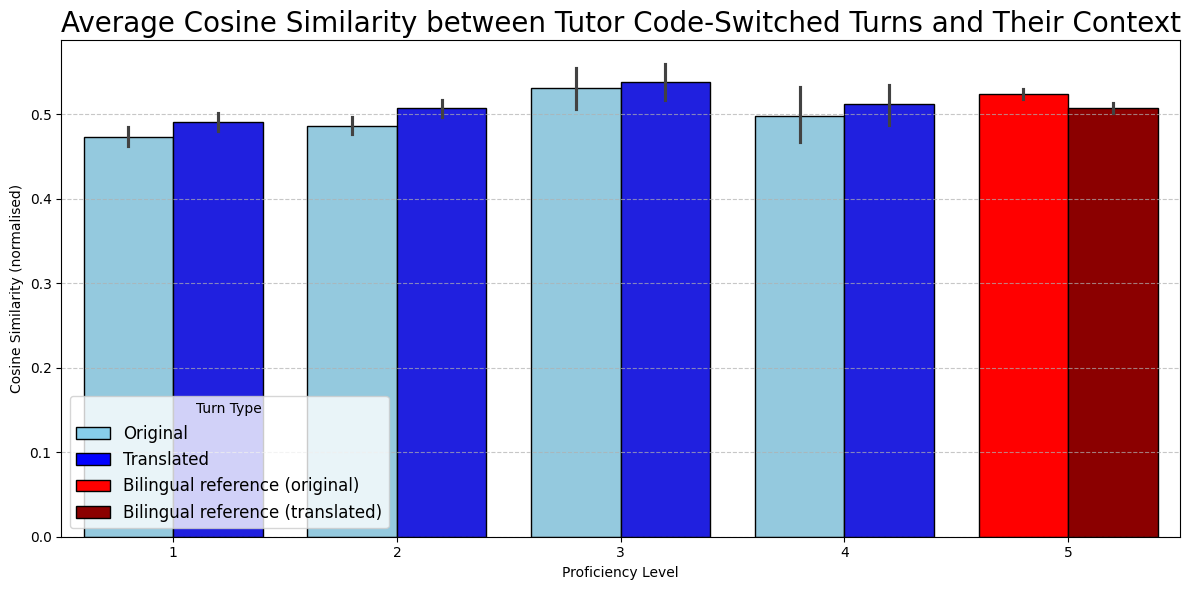

In [80]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns

data = []


for proficiency, sims in normalized_sorted_sim_values.items():
    data.extend(
        [{"Proficiency": proficiency, "Sim": sim, "Type": "Original"} for sim in sims]
    )

for proficiency, sims in normalized_sorted_sim_values_trans.items():
    data.extend(
        [{"Proficiency": proficiency, "Sim": sim, "Type": "Translated"} for sim in sims]
    )

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Proficiency",
    y="Sim",
    hue="Type",
    ci=95,
    palette={"Original": "skyblue", "Translated": "blue"},
    edgecolor="black",
)

for i, bar in enumerate(plt.gca().patches):
    if i == 4:
        bar.set_color("red")
        bar.set_edgecolor("black")
    elif i == 9:
        bar.set_color("darkred")
        bar.set_edgecolor("black")

legend_elements = [
    Patch(facecolor="skyblue", edgecolor="black", label="Original"),
    Patch(facecolor="blue", edgecolor="black", label="Translated"),
    Patch(facecolor="red", edgecolor="black", label="Bilingual reference (original)"),
    Patch(
        facecolor="darkred", edgecolor="black", label="Bilingual reference (translated)"
    ),
]

plt.xlabel("Proficiency Level")
plt.ylabel("Cosine Similarity (normalised)")
plt.title(
    "Average Cosine Similarity between Tutor Code-Switched Turns and Their Context",
    fontsize=20,
)
plt.xticks()
plt.yticks()
plt.legend(handles=legend_elements, title="Turn Type", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### T-tables generation for the plot using scipy


In [81]:
from scipy.stats import ttest_ind, sem
import numpy as np

# Levels vs other levels for original and translated utterances

data_original = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in normalized_sorted_sim_values.items()
    for sim in sims
]
data_translated = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in normalized_sorted_sim_values_trans.items()
    for sim in sims
]


df_original = pd.DataFrame(data_original)
df_translated = pd.DataFrame(data_translated)

# Original data

latex_table_data = []
unique_proficiencies = df_original["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df_original[df_original["Proficiency"] == prof1]["Similarity"]
        group2 = df_original[df_original["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculating confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        latex_table_data.append(
            [
                prof1,
                prof2,
                f"{t_stat:.3f}",
                f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                f"[{ci_low:.3f}, {ci_high:.3f}]",
            ]
        )
print(
    pd.DataFrame(
        latex_table_data,
        columns=["Proficiency 1", "Proficiency 2", "T-statistic", "P-value", "95% CI"],
    ).to_latex(index=False)
)

# Translations

latex_table_data = []
unique_proficiencies = df_translated["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df_translated[df_translated["Proficiency"] == prof1]["Similarity"]
        group2 = df_translated[df_translated["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculating confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        latex_table_data.append(
            [
                prof1,
                prof2,
                f"{t_stat:.3f}",
                f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                f"[{ci_low:.3f}, {ci_high:.3f}]",
            ]
        )
print(
    pd.DataFrame(
        latex_table_data,
        columns=["Proficiency 1", "Proficiency 2", "T-statistic", "P-value", "95% CI"],
    ).to_latex(index=False)
)

\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95% CI \\
\midrule
1 & 2 & -1.674 & 0.0944 & [-0.028, 0.002] \\
1 & 3 & -4.284 & 0.0000* & [-0.086, -0.030] \\
1 & 4 & -1.459 & 0.1450 & [-0.059, 0.010] \\
1 & 5 & -6.613 & 0.0000* & [-0.063, -0.038] \\
2 & 3 & -3.368 & 0.0008* & [-0.072, -0.018] \\
2 & 4 & -0.692 & 0.4890 & [-0.046, 0.023] \\
2 & 5 & -5.483 & 0.0000* & [-0.049, -0.026] \\
3 & 4 & 1.591 & 0.1132 & [-0.008, 0.075] \\
3 & 5 & 0.475 & 0.6351 & [-0.018, 0.033] \\
4 & 5 & -1.297 & 0.1948 & [-0.060, 0.007] \\
\bottomrule
\end{tabular}

\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95% CI \\
\midrule
1 & 2 & -2.246 & 0.0249* & [-0.030, -0.002] \\
1 & 3 & -3.738 & 0.0002* & [-0.071, -0.023] \\
1 & 4 & -1.376 & 0.1692 & [-0.047, 0.005] \\
1 & 5 & -2.075 & 0.0380* & [-0.028, -0.004] \\
2 & 3 & -2.476 & 0.0135* & [-0.055, -0.007] \\
2 & 4 & -0.319 & 0.7498 & [-0.030, 0.021] \\
2 & 5 & -0.029 & 0.9770 &

In [82]:
# Original vs Translated per levels

results = []
for level in normalized_sorted_sim_values:
    group1 = normalized_sorted_sim_values[level]
    group2 = normalized_sorted_sim_values_trans[level]

    t_stat, p_value = ttest_ind(group1, group2)

    # Calculate confidence intervals
    mean_diff = np.mean(group1) - np.mean(group2)
    pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
    ci_low = mean_diff - 1.96 * pooled_se
    ci_high = mean_diff + 1.96 * pooled_se

    results.append(
        {
            "Level": level,
            "T-statistic": f"{t_stat:.3f}",
            "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
            "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
        }
    )

results_df = pd.DataFrame(results)
print(
    results_df.to_latex(
        index=False,
        caption="Pairwise t-tests for normalised cosine similarities of original vs translated turns within levels",
    )
)

\begin{table}
\caption{Pairwise t-tests for normalised cosine similarities of original vs translated turns within levels}
\begin{tabular}{rlll}
\toprule
Level & T-statistic & P-value & 95\% CI \\
\midrule
1 & -2.209 & 0.027* & [-0.033, -0.002] \\
2 & -2.940 & 0.003* & [-0.035, -0.007] \\
3 & -0.372 & 0.710 & [-0.040, 0.027] \\
4 & -0.678 & 0.499 & [-0.055, 0.027] \\
5 & 4.124 & 0.000* & [0.009, 0.025] \\
\bottomrule
\end{tabular}
\end{table}



<>:21: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3620176262.py:21: SyntaxWarning: invalid escape sequence '\%'
  "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",


## Now, vocabulary overlap (Lexical similarity)


In [83]:
overlaps_per_group_trans = {}
overlaps_per_group_original = {}

# Measuring Jaccard Similarity Index for original and transalted utterances for each proficiency level

for proficiency, group in proficiency_groups:

    overlaps_per_group_trans[proficiency] = []
    overlaps_per_group_original[proficiency] = []

    for i, utt in group.iterrows():

        if utt["PrevTurnTrans"] is None or utt["TurnTranslation"] is None:
            continue

        # I'm comparing word tokens, so I tokenise all turns

        student_tokens = set(tokenize_and_preprocess(utt["PrevTurnTrans"]))

        teacher_tokens = set(tokenize_and_preprocess(utt["TurnTranslation"]))

        student_tokens_original = set(tokenize_and_preprocess(utt["PrevTurn"]))
        teacher_tokens_original = set(tokenize_and_preprocess(utt["Turn"]))

        # Calculating Jaccard Overlaps

        intersect = student_tokens.intersection(teacher_tokens)

        union = student_tokens.union(teacher_tokens)

        intersect_original = student_tokens_original.intersection(
            teacher_tokens_original
        )
        union_original = student_tokens_original.union(teacher_tokens_original)

        if len(union) > 0:

            overlaps_per_group_trans[proficiency].append(len(intersect) / len(union))

        if len(union_original) > 0:
            overlaps_per_group_original[proficiency].append(
                len(intersect_original) / len(union_original)
            )


# Miami (level 5) - same steps as above

overlaps_per_group_trans[5] = []
overlaps_per_group_original[5] = []


for i, utt in miami_all_switched_utts.iterrows():

    if utt["PrevTurnTrans"] is None or utt["TurnTranslation"] is None:
        continue

    # Tokenisation

    student_tokens = set(tokenize_and_preprocess(utt["PrevTurnTrans"]))

    teacher_tokens = set(tokenize_and_preprocess(utt["TurnTranslation"]))

    student_tokens_original = set(tokenize_and_preprocess(utt["PrevTurn"]))
    teacher_tokens_original = set(tokenize_and_preprocess(utt["Turn"]))

    # Jaccard calculation

    intersect = student_tokens.intersection(teacher_tokens)
    union = student_tokens.union(teacher_tokens)

    intersect_original = student_tokens_original.intersection(teacher_tokens_original)
    union_original = student_tokens_original.union(teacher_tokens_original)

    if len(union) > 0:
        overlaps_per_group_trans[5].append(len(intersect) / len(union))

    if len(union_original) > 0:
        overlaps_per_group_original[5].append(
            len(intersect_original) / len(union_original)
        )


print("Average Jaccard similarities per group for translated utterances:")


for group, sims in overlaps_per_group_trans.items():

    print(f"Proficiency Level: {group}")

    print("Average Jaccard similarity: ", np.mean(sims))

print("Average Jaccard similarities per group for original utterances:")
for group, sims in overlaps_per_group_original.items():
    print(f"Proficiency Level: {group}")
    print("Average Jaccard similarity: ", np.mean(sims))

Average Jaccard similarities per group for translated utterances:
Proficiency Level: 1
Average Jaccard similarity:  0.05515207327023076
Proficiency Level: 2
Average Jaccard similarity:  0.053632254642572784
Proficiency Level: 3
Average Jaccard similarity:  0.0714893340106248
Proficiency Level: 4
Average Jaccard similarity:  0.06106452271031063
Proficiency Level: 5
Average Jaccard similarity:  0.04278604974809873
Average Jaccard similarities per group for original utterances:
Proficiency Level: 1
Average Jaccard similarity:  0.038775728461825185
Proficiency Level: 2
Average Jaccard similarity:  0.031318648117140975
Proficiency Level: 3
Average Jaccard similarity:  0.03903779175895897
Proficiency Level: 4
Average Jaccard similarity:  0.026060991912787178
Proficiency Level: 5
Average Jaccard similarity:  0.02635369986714696


C:\Users\szach\AppData\Local\Temp\ipykernel_17256\739918651.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


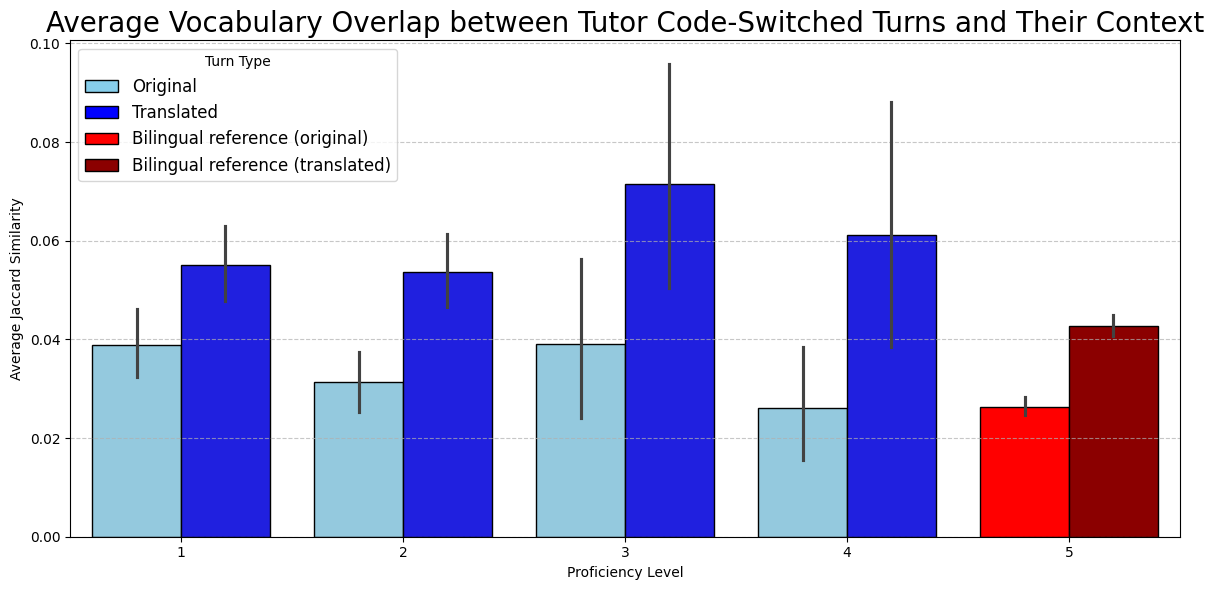

In [84]:
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.pyplot as plt


# Plotting the Jaccard similarities for original and translated utterances

data = []


for proficiency, sims in overlaps_per_group_original.items():

    data.extend(
        [
            {"Proficiency": proficiency, "Overlap": sim, "Type": "Original"}
            for sim in sims
        ]
    )


for proficiency, sims in overlaps_per_group_trans.items():

    data.extend(
        [
            {"Proficiency": proficiency, "Overlap": sim, "Type": "Translated"}
            for sim in sims
        ]
    )


df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Proficiency",
    y="Overlap",
    hue="Type",
    ci=95,
    palette={"Original": "skyblue", "Translated": "blue"},
    edgecolor="black",
    # dodge=False
)

# Highlight the 5th level
for i, bar in enumerate(plt.gca().patches):
    if i == 4:
        bar.set_color("red")
        bar.set_edgecolor("black")
    elif i == 9:
        bar.set_color("darkred")
        bar.set_edgecolor("black")

legend_elements = [
    Patch(facecolor="skyblue", edgecolor="black", label="Original"),
    Patch(facecolor="blue", edgecolor="black", label="Translated"),
    Patch(facecolor="red", edgecolor="black", label="Bilingual reference (original)"),
    Patch(
        facecolor="darkred", edgecolor="black", label="Bilingual reference (translated)"
    ),
]


plt.xlabel("Proficiency Level")
plt.ylabel("Average Jaccard Similarity")
plt.title(
    "Average Vocabulary Overlap between Tutor Code-Switched Turns and Their Context",
    fontsize=20,
)
plt.xticks()
plt.yticks()
plt.legend(handles=legend_elements, title="Turn Type", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [85]:
# Inspecting differenes between means for each level

jaccard_df_grouped = df.groupby(["Proficiency"])
for proficiency, group in jaccard_df_grouped:
    print(f"Proficiency Level: {proficiency}")
    print(
        f"Difference between means: {group[group['Type'] == 'Translated']['Overlap'].mean() - group[group['Type'] == 'Original']['Overlap'].mean():.3f}"
    )
    print("-" * 40)

Proficiency Level: (1,)
Difference between means: 0.016
----------------------------------------
Proficiency Level: (2,)
Difference between means: 0.022
----------------------------------------
Proficiency Level: (3,)
Difference between means: 0.032
----------------------------------------
Proficiency Level: (4,)
Difference between means: 0.035
----------------------------------------
Proficiency Level: (5,)
Difference between means: 0.016
----------------------------------------


### T-tables generation for overlaps


In [86]:
from scipy.stats import ttest_ind, sem
import numpy as np
import pandas as pd

# Level vs level for original utterances

data = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in overlaps_per_group_original.items()
    for sim in sims
]

df = pd.DataFrame(data)

results = []
unique_proficiencies = df["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df[df["Proficiency"] == prof1]["Similarity"]
        group2 = df[df["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculate confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        results.append(
            {
                "Proficiency 1": prof1,
                "Proficiency 2": prof2,
                "T-statistic": f"{t_stat:.3f}",
                "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
                "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            }
        )

results_df = pd.DataFrame(results)
print(
    results_df.to_latex(
        index=False,
        position="h!",
        caption="Pairwise t-tests for Jaccard Similarities for original turns",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Jaccard Similarities for original turns}
\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & 1.600 & 0.110 & [-0.002, 0.017] \\
1 & 3 & -0.031 & 0.975 & [-0.018, 0.017] \\
1 & 4 & 1.286 & 0.199 & [-0.001, 0.026] \\
1 & 5 & 4.557 & 0.000* & [0.005, 0.020] \\
2 & 3 & -0.958 & 0.339 & [-0.025, 0.009] \\
2 & 4 & 0.549 & 0.583 & [-0.008, 0.019] \\
2 & 5 & 1.999 & 0.046* & [-0.001, 0.011] \\
3 & 4 & 1.128 & 0.261 & [-0.007, 0.033] \\
3 & 5 & 2.437 & 0.015* & [-0.003, 0.029] \\
4 & 5 & -0.045 & 0.964 & [-0.012, 0.012] \\
\bottomrule
\end{tabular}
\end{table}



<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:35: SyntaxWarning: invalid escape sequence '\%'
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\4032504889.py:35: SyntaxWarning: invalid escape sequence '\%'
  "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",


In [87]:
from scipy.stats import ttest_ind, sem
import numpy as np
import pandas as pd

# Level vs level for translated utterances

data = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in overlaps_per_group_trans.items()
    for sim in sims
]

df = pd.DataFrame(data)

results = []
unique_proficiencies = df["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df[df["Proficiency"] == prof1]["Similarity"]
        group2 = df[df["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculate confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        results.append(
            {
                "Proficiency 1": prof1,
                "Proficiency 2": prof2,
                "T-statistic": f"{t_stat:.3f}",
                "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
                "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            }
        )

results_df = pd.DataFrame(results)
print(
    results_df.to_latex(
        index=False,
        position="h!",
        caption="Pairwise t-tests for Jaccard Similarities for translated turns",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Jaccard Similarities for translated turns}
\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & 0.266 & 0.790 & [-0.010, 0.013] \\
1 & 3 & -1.566 & 0.118 & [-0.040, 0.008] \\
1 & 4 & -0.475 & 0.635 & [-0.034, 0.022] \\
1 & 5 & 3.739 & 0.000* & [0.004, 0.021] \\
2 & 3 & -1.718 & 0.086 & [-0.042, 0.006] \\
2 & 4 & -0.590 & 0.556 & [-0.035, 0.020] \\
2 & 5 & 3.540 & 0.000* & [0.003, 0.019] \\
3 & 4 & 0.571 & 0.568 & [-0.025, 0.045] \\
3 & 5 & 4.446 & 0.000* & [0.006, 0.052] \\
4 & 5 & 2.267 & 0.023* & [-0.008, 0.045] \\
\bottomrule
\end{tabular}
\end{table}



<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:35: SyntaxWarning: invalid escape sequence '\%'
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2500289705.py:35: SyntaxWarning: invalid escape sequence '\%'
  "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",


In [88]:
results = []

# Original vs transalted for each level

for level in overlaps_per_group_trans:
    group1 = overlaps_per_group_trans[level]
    group2 = overlaps_per_group_original[level]

    t_stat, p_value = ttest_ind(group1, group2)

    # Calculate confidence intervals
    mean_diff = np.mean(group1) - np.mean(group2)
    pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
    ci_low = mean_diff - 1.96 * pooled_se
    ci_high = mean_diff + 1.96 * pooled_se

    results.append(
        {
            "Level": level,
            "T-statistic": f"{t_stat:.3f}",
            "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
            "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
        }
    )

results_df = pd.DataFrame(results)
print(
    results_df.to_latex(
        index=False,
        caption="Pairwise t-tests for jaccard overlaps of original vs translated turns within levels",
    )
)

\begin{table}
\caption{Pairwise t-tests for jaccard overlaps of original vs translated turns within levels}
\begin{tabular}{rlll}
\toprule
Level & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2.986 & 0.003* & [0.006, 0.027] \\
2 & 4.536 & 0.000* & [0.013, 0.032] \\
3 & 2.289 & 0.023* & [0.005, 0.060] \\
4 & 2.361 & 0.020* & [0.006, 0.064] \\
5 & 11.341 & 0.000* & [0.014, 0.019] \\
\bottomrule
\end{tabular}
\end{table}



<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3468022528.py:22: SyntaxWarning: invalid escape sequence '\%'
  "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",


# Topic clusters


In [89]:
# Topic clustering with BERTopic

from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

representation_model = KeyBERTInspired()

# Multilingual model for original turns

multilingual_topic_model = BERTopic(
    representation_model=representation_model, language="multilingual"
)
multi_topics, multi_probs = multilingual_topic_model.fit_transform(
    all_tutor_switched_utts["Turn"]
)

In [90]:
# English model for translated turns

english_topic_model = BERTopic(
    representation_model=representation_model, language="english"
)
english_topics, english_probs = english_topic_model.fit_transform(
    all_tutor_switched_utts["TurnTranslation"]
)

In [91]:
# Visualising the topics for the english model

english_topic_model.visualize_topics()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'rooms | bedrooms | bedroom | room | livingroom', 158],
                                   [1, 'weekend | weekends | friday | saturday | sunday', 92],
                                   [2, 'age | older | thirteen | old | younger', 89],
                                   [3, 'asking | ask | questions | asked | okay', 77],
                                   [4, 'yes |  |  |  | ', 60],
                                   [5, 'family | sisters | brothers | sister | cousins', 59],
                                   [6, 'spanish | language | languages | catalan | speak', 56],
                                   [7, 'thirty | twenty | fifteen | quarter | three', 55],
                                   [8, 'father | dad | grandfather | parents | and', 41],
                                   [9, 'okay | fine | good | well | now', 41],
                                   [10, 'school | teachers | do | about | okay', 40],
                                   [11, 'doing | hobbies | hours | hobby | lexpressi', 39],
                                   [12, 'understand | know | explain | do | yes', 36],
                                   [13, 'dinar | casa | lunch | dinner | eat', 35],
                                   [14, 'street | outside | where | house | park', 35],
                                   [15, 'leaving | ten | afternoon | school | eleven', 34],
                                   [16, 'english | philology | learns | teach | estudiant', 33],
                                   [17, 'morning | arrive | early | arrived | today', 28],
                                   [18, 'uhhuh | village | away | place | where', 28],
                                   [19, 'tagrada | tagraden | gimnstica | tagged | xador', 26],
                                   [20, 'school | finish | doing | going | lunch', 24],
                                   [21, 'where | home | live | street | house', 21],
                                   [22, 'barcelona | catalan | street | spain | where', 20],
                                   [23, 'yeah | yes |  |  | ', 19],
                                   [24, 'house | home | people | many | three', 18],
                                   [25, 'scholarship | academia | university | study | studying', 17],
                                   [26, 'afternoon | time | today | morning | at', 17],
                                   [27, 'english | in | court | say | calle', 16],
                                   [28, 'television | tv | watching | cinema | studying', 13],
                                   [29, 'home | house | where | at | tv', 12],
                                   [30, 'went | go | walk | walking | did', 11],
                                   [31, 'did | no | okay | questionnaire | information', 11],
                                   [32, 'morning | breakfast | school | arrive | wake', 10]], dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': ('ngBcAFkATQA8ADsAOAA3ACkAKQAoAC' ... 'AUABMAEgARABEAEAANAAwACwALAAoA'),
                                  'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 0.09875,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('8OavQUGHOkFLnwPBIqkYQQtVDUE79Y' ... 'oMQM6LP0Ehmsw+tvk9PtKrF0FPhEJA'),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('H5KMQBwMecGxKrFAg7I9QYAWT0HX4G' ... 'uSQBwxeMFGHZ9A/gSlQFmzP0EDEq3A'),
                    'dtype': 'f4'},
              'yaxis': 'y'}],
    'l

Not very informative


## Now, the multilingual model


In [92]:
# First, performing agglomerative clustering on the multilingual model
# In order to do this some code from the BERTopic package is used and modified

from bertopic._utils import select_topic_representation
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler
from bertopic.plotting._topics import _plotly_topic_visualization
from sklearn.cluster import AgglomerativeClustering

width = 650
height = 650
# Select topics based on top_n and topics args
freq_df = multilingual_topic_model.get_topic_freq()
freq_df = freq_df.loc[freq_df.Topic != -1, :]
topics = sorted(freq_df.Topic.to_list())

# Extract topic words and their frequencies
topic_list = sorted(topics)
frequencies = [multilingual_topic_model.topic_sizes_[topic] for topic in topic_list]
words = [
    " | ".join([word[0] for word in multilingual_topic_model.get_topic(topic)[:5]])
    for topic in topic_list
]

# Embed c-TF-IDF into 2D
all_topics = sorted(list(multilingual_topic_model.get_topics().keys()))
indices = np.array([all_topics.index(topic) for topic in topics])

embeddings, c_tfidf_used = select_topic_representation(
    multilingual_topic_model.c_tf_idf_,
    multilingual_topic_model.topic_embeddings_,
    use_ctfidf=False,
    output_ndarray=True,
)
embeddings = embeddings[indices]

if c_tfidf_used:
    embeddings = MinMaxScaler().fit_transform(embeddings)
    embeddings = UMAP(
        n_neighbors=2, n_components=2, metric="hellinger", random_state=42
    ).fit_transform(embeddings)
else:
    embeddings = UMAP(
        n_neighbors=2, n_components=2, metric="cosine", random_state=42
    ).fit_transform(embeddings)


# Aglomerative clustering

clustering = AgglomerativeClustering(n_clusters=8)
clustering.fit(embeddings)

# get cluster labels
clustered_labels = (
    clustering.labels_
)  # Holds the assignments of original clusteres to the clustered ones

# Calculating new cluster centroids

num_clusters = len(set(clustered_labels))
clustered_centroids = np.array(
    [embeddings[clustered_labels == i].mean(axis=0) for i in range(num_clusters)]
)

clustered_topic_list = sorted(list(set([int(label) for label in clustered_labels])))

clustered_frequencies = [0 for i in range(num_clusters)]
clustered_words = [[] for i in range(num_clusters)]

for i in range(len(topic_list)):
    clustered_cluster = clustered_labels[i]
    clustered_frequencies[clustered_cluster] += frequencies[i]
    for word in multilingual_topic_model.get_topic(topic_list[i])[:5]:
        clustered_words[clustered_cluster].append(word)

for i in range(len(clustered_words)):
    clustered_words[i] = " | ".join(
        [
            word[0]
            for word in sorted(clustered_words[i], key=lambda x: x[1], reverse=True)[
                :10
            ]
        ]
    )

# Visualise

df_clustered = pd.DataFrame(
    {
        "x": clustered_centroids[:, 0],
        "y": clustered_centroids[:, 1],
        "Topic": clustered_topic_list,
        "Words": clustered_words,
        "Size": clustered_frequencies,
    }
)
df = pd.DataFrame(
    {
        "x": embeddings[:, 0],
        "y": embeddings[:, 1],
        "Topic": topic_list,
        "Words": words,
        "Size": frequencies,
    }
)

_plotly_topic_visualization(
    df_clustered,
    clustered_topic_list,
    "Agglomeratively clustered intertopic distance map",
    650,
    650,
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0,
                                    'home | faràs | casa | rooms | habitaciones | habitacions | bedrooms | house | will | evening',
                                    303],
                                   [1,
                                    'yes | yeah | ah | games | right |  |  | one | videogames | exactly',
                                    241],
                                   [2,
                                    'sister | germana | sisters | age | father | padre | youngest | pares | brother | família',
                                    238],
                                   [3,
                                    'hora | time | matí | clock | morning | tuesday | today | gustar | hora | gusta',
                                    185],
                                   [4,
                                    'english | anglès | paraula | words | said | ensenyar | tecnològic | classroom | technological | technology',
                                    83],
                                   [5,
                                    'change | preguntarme | now | me | preguntas | preguntar | asked | demanar | questions | ask',
                                    81],
                                   [6,
                                    'street | calle | carrer | city | where | where | where | live | house | somewhere',
                                    83],
                                   [7,
                                    'weekend | saturday | weekends | football | sunday | won | guanyar | yesterday | win | vosotros',
                                    113]], dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': 'LwHxAO4AuQBTAFEAUwBxAA==', 'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 0.189375,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': '35kIQGsI6EBCWQdBZttMwd8bi0HkvhzA6eevQQmGQUE=', 'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': 'QpfLP2nyrUHNcRFAyh3QQHvuLEE6bvFA/DiEwRcxm0E=', 'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-14.724099),
                                'y': np.float32(2.9989357),
                                'yshift': 10},
                               {'showarrow': False,
                                'text': 'D2',
                                'x': np.float32(5.2811866),
                                'xshift': 10,
                                'y': np.float32(25.00487)}],
               'height': 650,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'margin': {'t': 60},
               'shapes': [{'line': {'color': '#CFD8DC', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(5.2811866),
                           'x1': np.float32(5.2811866),
                           'y0': np.float32(-19.006998),
                           'y1': np.float32(25.00487)},
                          {'line': {'color': '#9E9E9E', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-14.724099),
                           'x1': np.float32(25.286472),
                           'y0': np.float32(2.9989357),
                           'y1': np.float

In [93]:
# Assigning labels to the clustered topics
# NOTE, this is a manual process, so in order for this to represent the clusters correctly,
# each cluster has to be inspected and the order of labels might need to be shuffled

topic_labels = [
    "family",
    "places",
    "time",
    "home",
    "backchannel",
    "questions",
    "free time",
    "school",
]

In [94]:
# Visualising unclustered topics obtained using the multilingual model

_plotly_topic_visualization(df, topic_list, "Intertopic distance map", 650, 650)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'rooms | habitaciones | habitacions | bedrooms | lhabitació', 153],
                                   [1, 'age | youngest | older | younger | old', 83],
                                   [2, 'school | escola | linstitut | students | teacher', 66],
                                   [3, 'yes | exactly | okay | uhhuh | ', 65],
                                   [4, 'castellà | spanish | catalán | languages | language', 61],
                                   [5, 'weekend | saturday | weekends | sunday | yesterday', 60],
                                   [6, 'família | family | cousins | cusins | brother', 51],
                                   [7, 'bé | good | that | fine | okay', 46],
                                   [8, 'marxaràs | hora | time | clock | marcháis', 43],
                                   [9, 'gustar | gusta | enjoy | tagrada | sé', 40],
                                   [10, 'ensenyar | tecnològic | technological | technology | specialty',
                                    39],
                                   [11, 'hobbies | sundays | vacances | saturdays | free', 38],
                                   [12, 'matí | morning | hora | early | arrived', 35],
                                   [13, 'where | somewhere | place | tu | casa', 33],
                                   [14, 'father | padre | pares | brother | parents', 31],
                                   [15, 'evening | tarda | dines | afternoon | faràs', 29],
                                   [16, 'saps | això | parles | és | explicam', 29],
                                   [17, 'preocupis | mal | porque | hurt | jo', 27],
                                   [18, 'preguntantte | ask | preguntar | asking | preguntado', 27],
                                   [19, 'preguntarme | preguntas | preguntar | demanar | preguntes', 24],
                                   [20, 'hora | time | clock | tuesday | today', 23],
                                   [21, 'classroom | english | educational | professora | teacher', 22],
                                   [22, 'english | anglès | paraula | words | said', 22],
                                   [23, 'school | time | matí | morning | day', 21],
                                   [24, 'won | guanyar | win | vosotros | you', 21],
                                   [25, 'football | sports | sport | player | played', 19],
                                   [26, 'where | live | you | your | here', 19],
                                   [27, 'number | five | four | pilotes | eight', 19],
                                   [28, 'yeah | ah | right |  | ', 19],
                                   [29, 'house | neighbor | casa | home | live', 18],
                                   [30, 'asked | questions | ask | asking | okay', 18],
                                   [31, 'home | casa | house | at | do', 17],
                                   [32, 'saturday | weekend | sunday | did | past', 13],
                                   [33, 'tv | television | watch | watching | coses', 13],
                                   [34, 'faràs | finish | you | today | when', 13],
                                   [35, 'street | calle | carrer | city | where', 13],
                                   [36, 'change | now | me | venga | vulguis', 12],
                                   [37, 'sister | germana | sisters | brother | germà', 12],
                                   [38, 'one | more | más | ésta | other', 12],
                                   [39, 'games | videogames | play | toys | peli', 11],
                                   [40, 'faràs | will | you | fas | acabes', 10]], dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
              

## Do clusters of tutor CS utterances have different levels of cosine sim?


### Checking cosine similarities within clusters


In [95]:
doc_cluster_df = multilingual_topic_model.get_document_info(
    all_tutor_switched_utts["Turn"]
)
doc_cluster_df.head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,hm like the vanguardia elpaís what okay what d...,5,5_weekend_saturday_weekends_sunday,"[weekend, saturday, weekends, sunday, yesterda...",[last weekend weekend saturday and sunday okay...,weekend - saturday - weekends - sunday - yeste...,1.000000,False
1,what did you do last weekend weekend saturday ...,5,5_weekend_saturday_weekends_sunday,"[weekend, saturday, weekends, sunday, yesterda...",[last weekend weekend saturday and sunday okay...,weekend - saturday - weekends - sunday - yeste...,0.658388,False
2,right hm where do you live,26,26_where_live_you_your,"[where, live, you, your, here, ask, house, que...","[where do you live, where do you live, where d...",where - live - you - your - here - ask - house...,1.000000,False
3,okay and no lo sé,17,17_preocupis_mal_porque_hurt,"[preocupis, mal, porque, hurt, jo, bueno, bé, ...","[does it hurt fa mal, does it hurt fa mal, por...",preocupis - mal - porque - hurt - jo - bueno -...,1.000000,False
4,something you wanna know about me seguro then ...,36,36_change_now_me_venga,"[change, now, me, venga, vulguis, wanna, my, p...",[something you wanna know about me seguro then...,change - now - me - venga - vulguis - wanna - ...,1.000000,True


In [96]:
# Splitting all the tutor code-switched turns into clusters based on the clustered topic labels

turns_per_topic = []
for clustered_topic in clustered_topic_list:
    topic_indices = [i for i, x in enumerate(clustered_labels) if x == clustered_topic]
    relevant_utts = doc_cluster_df.loc[doc_cluster_df["Topic"].isin(topic_indices)][
        "Document"
    ].values
    turns_per_topic.append(relevant_utts)

In [97]:
print([len(topic) for topic in turns_per_topic])

[303, 241, 238, 185, 83, 81, 83, 113]


## Now, we find the previous utterances and calculate the cosine similaraties.

### We do it for both translated and original versions.

We also check their lexical overlap


In [98]:
# First, originals

all_cosine_sims = []
utterance_pairs_per_topic = []
for topic_utts in turns_per_topic:
    utterance_pairs = []
    for utt in topic_utts:
        prev_utt_candidates = all_tutor_switched_utts.loc[
            all_tutor_switched_utts["Turn"] == utt
        ]["PrevTurn"].values

        proficiency_candidates = all_tutor_switched_utts.loc[
            all_tutor_switched_utts["Turn"] == utt
        ]["Proficiency"].values

        utterance_pairs.append(
            {
                "Tutor": utt,
                "Context": prev_utt_candidates,
                "Proficiency": proficiency_candidates,
            }
        )
    utterance_pairs_per_topic.append(utterance_pairs)

Examples with the context, which can be used in the survey


In [99]:
master_df["Proficiency"].unique()

array([3, 4, 2, 1], dtype=object)

In [100]:
topics_per_level = {
    level: {"Backchannel": [], "Questions": [], "Topics": []}
    for level in master_df["Proficiency"].unique()
}

In [101]:
# Preparing samples for the survey

context_samples = {
    "backchannel": {
        "tutor-en": [],
        "tutor-es": [],
        "tutor-mixed": [],
    },
    "questions": {
        "tutor-en": [],
        "tutor-mixed": [],
    },
    "topics": {
        "tutor-en": [],
        "tutor-es": [],
        "tutor-mixed": [],
    },
}

In [102]:
# Backchannel examples
used_row_indices = []

tutor_en_examples = []
tutor_spa_examples = []
tutor_mixed_examples = []

for i in range(len(utterance_pairs_per_topic[topic_labels.index("backchannel")])):

    tutor_example = utterance_pairs_per_topic[topic_labels.index("backchannel")][i][
        "Tutor"
    ]
    print(
        f"=======================\nTutor turn {i}: {tutor_example} \n======================="
    )

    # Finding the previous turn

    index_to_use = 0
    row_index = master_df.loc[
        (master_df["Turn"] == tutor_example) & (master_df["Participant"] == "INV")
    ].index[index_to_use]

    while row_index in used_row_indices:
        index_to_use += 1
        row_index = master_df.loc[
            (master_df["Turn"] == tutor_example) & (master_df["Participant"] == "INV")
        ].index[index_to_use]
    used_row_indices.append(row_index)

    student_proficiency = master_df.loc[row_index, "Proficiency"]

    tutor_language = master_df.loc[row_index, "TurnLanguage"]
    tutor_translated = master_df.loc[row_index, "TurnTranslation"]

    all_context = []

    last_context_turn = ""
    prev_speaker = ""
    for idx in range(max(0, row_index - 10), row_index + 1):
        if master_df.iloc[idx]["Participant"] == prev_speaker:
            continue
        if master_df.iloc[idx]["Participant"] == "PAR":
            last_context_turn = master_df.iloc[idx]["Turn"]
        print(f"{master_df.iloc[idx]['Participant']}: {master_df.iloc[idx]['Turn']}")
        all_context.append(
            {
                "Speaker": master_df.iloc[idx]["Participant"],
                "Turn": master_df.iloc[idx]["Turn"],
            }
        )
        prev_speaker = master_df.iloc[idx]["Participant"]

    # For analysis

    topics_per_level[student_proficiency]["Backchannel"].append(
        {"Tutor": tutor_example, "Context": last_context_turn}
    )

    # 5 previous turns

    if tutor_language == "spanish/catalan":
        tutor_spa_examples.append(
            {"Tutor": tutor_example, "Context": all_context[-6:-1]}
        )
    elif tutor_language == "english":
        tutor_en_examples.append(
            {"Tutor": tutor_example, "Context": all_context[-6:-1]}
        )
    else:
        tutor_mixed_examples.append(
            {"Tutor": tutor_example, "Context": all_context[-6:-1]}
        )

context_samples["backchannel"]["tutor-en"] = tutor_en_examples
context_samples["backchannel"]["tutor-es"] = tutor_spa_examples
context_samples["backchannel"]["tutor-mixed"] = tutor_mixed_examples

Tutor turn 0: ya por you came here when you were studying to study first of eso 
INV: okay how old are you
PAR: sixteen
INV: sixteen right do you like this school
PAR: yes
INV: what does yes mean
PAR: is not too bad but this school
INV: and what about the other schools you went to when you were a little girl how long have you been here in this school
PAR: five years
INV: ya por you came here when you were studying to study first of eso
Tutor turn 1: and do you like english the extraescolar 
INV: ah you have studied for two months okay what is the name of the school you study in
PAR: Saxon
INV: is it near the school
PAR: yes
INV: okay and what level are you in in the school in Saxon
PAR: hm I don't know the level
INV: you don't know the level primer segon tercer o funciona per noms
PAR: no no sé com va
INV: and do you like english the extraescolar
Tutor turn 2: english philology 
INV: is she older or younger
PAR: is older
INV: how old is she
PAR: twenty
INV: twenty is she studying at un

In [ ]:
# Questions examples


used_row_indices = []

tutor_en_examples = []



# tutor_spa_examples = []
tutor_mixed_examples = []



for i in range(len(utterance_pairs_per_topic[topic_labels.index("questions")])):

    tutor_example = utterance_pairs_per_topic[topic_labels.index("questions")][i][
        "Tutor"
    ]

    print(
        f"=======================\nTutor turn {i}: {tutor_example} \n======================="
    )

    index_to_use = 0

    row_index = master_df.loc[
        (master_df["Turn"] == tutor_example) & (master_df["Participant"] == "INV")
    ].index[index_to_use]


    while row_index in used_row_indices:

        index_to_use += 1

        row_index = master_df.loc[

            (master_df["Turn"] == tutor_example) & (master_df["Participant"] == "INV")
        ].index[index_to_use]

    used_row_indices.append(row_index)


    student_proficiency = master_df.loc[row_index, "Proficiency"]


    tutor_language = master_df.loc[row_index, "TurnLanguage"]

    all_context = []

    # finding last student turn


    prev_speaker = ""
    last_context_turn = ""


    for idx in range(max(0, row_index - 10), row_index + 1):

        if master_df.iloc[idx]["Participant"] == prev_speaker:
            continue


        if master_df.iloc[idx]["Participant"] == "PAR":

            last_context_turn = master_df.iloc[idx]["Turn"]

        print(f"{master_df.iloc[idx]['Participant']}: {master_df.iloc[idx]['Turn']}")

        all_context.append(
            {
                "Speaker": master_df.iloc[idx]["Participant"],
                "Turn": master_df.iloc[idx]["Turn"],
            }
        )

        prev_speaker = master_df.iloc[idx]["Participant"]


    topics_per_level[student_proficiency]["Questions"].append(
        {
            "Tutor": tutor_example,
            "Context": last_context_turn,
        }
    )

    # 5 previous turns


    if tutor_language == "english":

        tutor_en_examples.append(

            {"Tutor": tutor_example, "Context": all_context[-6:-1]}
        )

    else:

        tutor_mixed_examples.append(
            {"Tutor": tutor_example, "Context": all_context[-6:-1]}
        )



context_samples["questions"]["tutor-en"] = tutor_en_examples


context_samples["questions"]["tutor-mixed"] = tutor_mixed_examples

Tutor turn 0: something you wanna know about me seguro then let's change now 
INV: I've been asking you questions
PAR: yes
INV: now you can ask me if you want you can ask me make me a question
PAR: hm hm what are what what is your name
INV: Gisela
PAR: how old are you I'm twenty six years old no sé
INV: something you wanna know about me seguro then let's change now
Tutor turn 1: something you wanna know about me seguro then let's change now 
PAR: yes
INV: now you can ask me if you want you can ask me make me a question
PAR: hm hm what are what what is your name
INV: Gisela
PAR: how old are you I'm twenty six years old no sé
INV: something you wanna know about me seguro then let's change now
Tutor turn 2: something you wanna know about me seguro then let's change now 
INV: now you can ask me if you want you can ask me make me a question
PAR: hm hm what are what what is your name
INV: Gisela
PAR: how old are you I'm twenty six years old no sé
INV: something you wanna know about me seguro

In [104]:
# Topic examples - all other topics clustered into the "topic" intent

tutor_en_examples = []
tutor_spa_examples = []
tutor_mixed_examples = []


for topic in [
    topic_labels.index(t) for t in topic_labels if t not in ["backchannel", "questions"]
]:

    print(
        f"\n\n++++++++++++++++++++++++++++++TOPIC {topic} ({topic_labels[topic]})++++++++++++++++++++++++++++++\n\n"
    )

    used_row_indices = []

    for i in range(len(utterance_pairs_per_topic[topic])):

        tutor_example = utterance_pairs_per_topic[topic][i]["Tutor"]

        print(
            f"=======================\nTutor turn {i}: {tutor_example} \n======================="
        )

        index_to_use = 0

        row_index = master_df.loc[
            (master_df["Turn"] == tutor_example) & (master_df["Participant"] == "INV")
        ].index[index_to_use]

        while row_index in used_row_indices:

            index_to_use += 1

            row_index = master_df.loc[
                (master_df["Turn"] == tutor_example)
                & (master_df["Participant"] == "INV")
            ].index[index_to_use]

        used_row_indices.append(row_index)

        student_proficiency = master_df.loc[row_index, "Proficiency"]

        tutor_language = master_df.loc[row_index, "TurnLanguage"]
        all_context = []

        # finding previous student turn

        prev_speaker = ""
        last_context_turn = ""

        for idx in range(max(0, row_index - 10), row_index + 1):

            if master_df.iloc[idx]["Participant"] == prev_speaker:
                continue

            if master_df.iloc[idx]["Participant"] == "PAR":

                last_context_turn = master_df.iloc[idx]["Turn"]

            print(
                f"{master_df.iloc[idx]['Participant']}: {master_df.iloc[idx]['Turn']}"
            )
            all_context.append(
                {
                    "Speaker": master_df.iloc[idx]["Participant"],
                    "Turn": master_df.iloc[idx]["Turn"],
                }
            )

            prev_speaker = master_df.iloc[idx]["Participant"]

        topics_per_level[student_proficiency]["Topics"].append(
            {
                "Tutor": tutor_example,
                "Context": last_context_turn,
            }
        )

        # previous 5 turns

        if tutor_language == "spanish/catalan":
            tutor_spa_examples.append(
                {"Tutor": tutor_example, "Context": all_context[-6:-1]}
            )
        elif tutor_language == "english":
            tutor_en_examples.append(
                {"Tutor": tutor_example, "Context": all_context[-6:-1]}
            )
        else:
            tutor_mixed_examples.append(
                {"Tutor": tutor_example, "Context": all_context[-6:-1]}
            )

context_samples["topics"]["tutor-en"] = tutor_en_examples
context_samples["topics"]["tutor-es"] = tutor_spa_examples
context_samples["topics"]["tutor-mixed"] = tutor_mixed_examples



++++++++++++++++++++++++++++++TOPIC 0 (family)++++++++++++++++++++++++++++++


Tutor turn 0: hm no sé now it's ten to two what time will you leave 
INV: hm I like the no sé
PAR: no sé qué me gusta
INV: what don't you like
PAR: this is easier hm I don't like some teachers because he well no comment about the teachers
INV: okay okay let's talk about today what time did you arrive this morning
PAR: eight o'clock hm and what time will you leave
INV: hm no sé now it's ten to two what time will you leave
Tutor turn 1: hm no sé now it's ten to two what time will you leave 
INV: hm I like the no sé
PAR: no sé qué me gusta
INV: what don't you like
PAR: this is easier hm I don't like some teachers because he well no comment about the teachers
INV: okay okay let's talk about today what time did you arrive this morning
PAR: eight o'clock hm and what time will you leave
INV: hm no sé now it's ten to two what time will you leave
Tutor turn 2: okay at at at what time did you leave home 
INV: and hm

## Samples selection for survey


In [ ]:
selected_samples = {}
import random
import json

# First, sampling an equal number of examples for each language and topic

for topic, examples in context_samples.items():
    selected_samples[topic] = {}
    for language, turns in examples.items():
        number_of_samples = 10 if topic == "questions" or language == "tutor-en" else 5
        sampled_examples = random.sample(turns, number_of_samples)
        selected_samples[topic][language] = sampled_examples

In [106]:
selected_samples_first = json.loads(
    json.dumps(selected_samples, ensure_ascii=False, indent=4)
)

# Checking if every sample has the same number of turns in the context

for topic, examples in selected_samples_first.items():
    for language, turns in examples.items():
        print(topic, language, [len(turn["Context"]) for turn in turns])

backchannel tutor-en [5, 5, 3, 5, 5, 5, 5, 5, 5, 5]
backchannel tutor-es [5, 5, 5, 5, 5]
backchannel tutor-mixed [5, 5, 5, 5, 5]
questions tutor-en [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
questions tutor-mixed [5, 5, 4, 5, 4, 5, 5, 5, 5, 5]
topics tutor-en [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
topics tutor-es [5, 5, 5, 5, 5]
topics tutor-mixed [4, 5, 5, 5, 5]


### Swapping faulty examples


The following cells show my manual process of ensuring the correctness of survey samples.
They are commented out, since it requires manual inspection and will most likely not work by simply running the cells again.
Values have been manually adjusted.


In [107]:
# # First, 3 new examples of backchannel tutor-en

# new_b_en = random.sample(context_samples["backchannel"]["tutor-en"], 3)
# new_b_en

In [108]:
# selected_samples_first["backchannel"]["tutor-en"][2] = new_b_en[0]
# selected_samples_first["backchannel"]["tutor-en"][4] = new_b_en[1]
# selected_samples_first["backchannel"]["tutor-en"][8] = new_b_en[2]

In [109]:
# new_q_en = random.sample(context_samples["questions"]["tutor-en"], 2)
# new_q_en

In [110]:
# selected_samples_first["questions"]["tutor-en"][3] = new_q_en[0]

In [111]:
# new_q_en = random.sample(context_samples["questions"]["tutor-en"], 1)
# new_q_en

In [112]:
# selected_samples_first["questions"]["tutor-en"][7] = new_q_en[0]

In [113]:
# new_q_mix = random.sample(context_samples["questions"]["tutor-mixed"], 2)
# new_q_mix

In [114]:
# selected_samples_first["questions"]["tutor-mixed"][1] = new_q_mix[0]
# selected_samples_first["questions"]["tutor-mixed"][8] = new_q_mix[1]

In [115]:
# new_t_en = random.sample(context_samples["topics"]["tutor-en"], 3)
# new_t_en

In [116]:
# selected_samples_first["topics"]["tutor-en"][0] = new_t_en[0]
# selected_samples_first["topics"]["tutor-en"][1] = new_t_en[1]

In [117]:
# new_t_en = random.sample(context_samples["topics"]["tutor-en"], 1)
# new_t_en

In [118]:
# selected_samples_first["topics"]["tutor-en"][6] = new_t_en[0]

In [119]:
# new_t_es = random.sample(context_samples["topics"]["tutor-es"], 1)
# new_t_es

In [120]:
# selected_samples_first["topics"]["tutor-es"][4] = new_t_es[0]

In [121]:
# new_t_mix = random.sample(context_samples["topics"]["tutor-mixed"], 2)
# new_t_mix

In [122]:
# selected_samples_first["topics"]["tutor-mixed"][2] = new_t_mix[0]
# selected_samples_first["topics"]["tutor-mixed"][4] = new_t_mix[1]

In [123]:
# selected_samples_first["topics"]["tutor-mixed"]

In [124]:
# with open("selected_samples_final.json", "w", encoding="utf-8") as f:
#     json.dump(selected_samples_first, f, ensure_ascii=False, indent=4)

In [125]:
# for topic, examples in selected_samples_first.items():
#     for language, turns in examples.items():
#         print(topic, language, [len(turn["Context"]) for turn in turns])

# Continuing the intent analysis


In [ ]:
# Topics per profciency level

level_topic_stats = {}


for level in topics_per_level:

    level_topic_stats[level] = {}

    total_len = sum(
        [len(topics_per_level[level][topic]) for topic in topics_per_level[level]]
    )


    level_topic_stats[level]["Total"] = total_len

    for topic in topics_per_level[level]:

        level_topic_stats[level][topic] = (
            len(topics_per_level[level][topic]),

            f"{len(topics_per_level[level][topic])/total_len*100:.2f}%",
        )



# for prof in topics_per_level:



#     print(f"Proficiency level: {prof}")


#     for topic in topics_per_level[prof]:


#         print(f"{topic} examples: ")


#         print(len(topics_per_level[prof][topic]))
level_topic_stats

{3: {'Total': 160,
  'Backchannel': (22, '13.75%'),
  'Questions': (7, '4.38%'),
  'Topics': (131, '81.88%')},
 4: {'Total': 104,
  'Backchannel': (11, '10.58%'),
  'Questions': (6, '5.77%'),
  'Topics': (87, '83.65%')},
 2: {'Total': 586,
  'Backchannel': (34, '5.80%'),
  'Questions': (25, '4.27%'),
  'Topics': (527, '89.93%')},
 1: {'Total': 477,
  'Backchannel': (16, '3.35%'),
  'Questions': (43, '9.01%'),
  'Topics': (418, '87.63%')}}

In [127]:
# Calculating cosine simliarities for each topic and level for original utterances

cosine_sims_per_level = {}


for level in topics_per_level:

    cosine_sims_per_topic = {}

    for topic in topics_per_level[level]:

        cosine_sims = []

        for pair in topics_per_level[level][topic]:

            # print(pair)

            tutor_emb = get_bert_embeddings(pair["Tutor"], multi_model, multi_tokenizer)

            context_emb = get_bert_embeddings(
                pair["Context"], multi_model, multi_tokenizer
            )

            cosine_sims.append(cosine_similarity(tutor_emb, context_emb)[0][0])

        cosine_sims_per_topic[topic] = cosine_sims

    cosine_sims_per_level[level] = cosine_sims_per_topic

In [128]:
cosine_sims_per_level.keys()

dict_keys([3, 4, 2, 1])

In [ ]:
# Making turn pairs per topic label for translated utterances

utterance_pairs_per_topic_trans = []



for topic_utts in turns_per_topic:
    utterance_pairs = []


    for utt in topic_utts:

        prev_utt_candidates = all_tutor_switched_utts.loc[
            all_tutor_switched_utts["Turn"] == utt

        ]["PrevTurnTrans"].values


        proficiency_candidates = all_tutor_switched_utts.loc[
            all_tutor_switched_utts["Turn"] == utt

        ]["Proficiency"].values


        current_utt_trans = all_tutor_switched_utts.loc[
            all_tutor_switched_utts["Turn"] == utt

        ]["TurnTranslation"].values[0]


        utterance_pairs.append(
            {
                "Tutor": current_utt_trans,
                "Context": prev_utt_candidates,
                "Proficiency": proficiency_candidates,
            }
        )

    utterance_pairs_per_topic_trans.append(utterance_pairs)

In [ ]:
# Calculating Jaccard Overlaps for each topic and proficiency level for translated utterances

all_overlaps_trans_by_level = {1: [], 2: [], 3: [], 4: []}


for topic in utterance_pairs_per_topic_trans:

    topic_overlaps_by_level = {1: [], 2: [], 3: [], 4: []}

    duplicate_tutor = [pair["Tutor"] for pair in topic if len(pair["Context"]) > 1]

    # Finding previous turn

    unique_duplicates = {}

    for item in duplicate_tutor:

        if item in unique_duplicates:

            unique_duplicates[item] += 1

        else:

            unique_duplicates[item] = 1


    unique_duplicates_counts = [list(item) for item in unique_duplicates.items()]


    for pair in topic:

        context = ""

        if pair["Tutor"] in [x[0] for x in unique_duplicates_counts]:

            tutor_index = [x[0] for x in unique_duplicates_counts].index(pair["Tutor"])


            context = pair["Context"][unique_duplicates_counts[tutor_index][1] - 1]

            proficiency = pair["Proficiency"][
                unique_duplicates_counts[tutor_index][1] - 1
            ]


            unique_duplicates_counts[tutor_index][1] -= 1

        else:

            context = pair["Context"][0]

            proficiency = pair["Proficiency"][0]

        if context:

            # Tokenisation

            student_tokens = set(tokenize_and_preprocess(context))

            teacher_tokens = set(tokenize_and_preprocess(pair["Tutor"]))

            # Jaccard Overlap calculation

            intersect = student_tokens.intersection(teacher_tokens)

            union = student_tokens.union(teacher_tokens)


            if len(union) > 0:

                topic_overlaps_by_level[proficiency].append(len(intersect) / len(union))


    for prof in topic_overlaps_by_level.keys():

        all_overlaps_trans_by_level[prof].append(topic_overlaps_by_level[prof])

In [ ]:
# Same thing done for original utterances

all_overlaps_by_level = {1: [], 2: [], 3: [], 4: []}


for topic in utterance_pairs_per_topic:


    topic_overlaps_by_level = {1: [], 2: [], 3: [], 4: []}

    duplicate_tutor = [pair["Tutor"] for pair in topic if len(pair["Context"]) > 1]


    unique_duplicates = {}


    for item in duplicate_tutor:

        if item in unique_duplicates:

            unique_duplicates[item] += 1

        else:

            unique_duplicates[item] = 1


    unique_duplicates_counts = [list(item) for item in unique_duplicates.items()]


    for pair in topic:

        context = ""

        if pair["Tutor"] in [x[0] for x in unique_duplicates_counts]:


            tutor_index = [x[0] for x in unique_duplicates_counts].index(pair["Tutor"])


            context = pair["Context"][unique_duplicates_counts[tutor_index][1] - 1]

            proficiency = pair["Proficiency"][
                unique_duplicates_counts[tutor_index][1] - 1
            ]


            unique_duplicates_counts[tutor_index][1] -= 1

        else:

            context = pair["Context"][0]

            proficiency = pair["Proficiency"][0]

        if context:
            # Tokenisation

            student_tokens = set(tokenize_and_preprocess(context))

            teacher_tokens = set(tokenize_and_preprocess(pair["Tutor"]))

            # Jaccard Overlap calculation

            intersect = student_tokens.intersection(teacher_tokens)

            union = student_tokens.union(teacher_tokens)


            if len(union) > 0:

                topic_overlaps_by_level[proficiency].append(len(intersect) / len(union))


    for prof in topic_overlaps_by_level.keys():

        all_overlaps_by_level[prof].append(topic_overlaps_by_level[prof])

In [ ]:
# Calculating cosine simliarities for each topic and level for translated utterances

all_cosine_sims_trans_by_level = {1: [], 2: [], 3: [], 4: []}



for topic in utterance_pairs_per_topic_trans:

    cosine_sims_by_level = {1: [], 2: [], 3: [], 4: []}

    duplicate_tutor = [pair["Tutor"] for pair in topic if len(pair["Context"]) > 1]


    unique_duplicates = {}

    for item in duplicate_tutor:

        if item in unique_duplicates:

            unique_duplicates[item] += 1

        else:

            unique_duplicates[item] = 1


    unique_duplicates_counts = [list(item) for item in unique_duplicates.items()]


    for pair in topic:

        context = ""

        if pair["Tutor"] in [x[0] for x in unique_duplicates_counts]:

            tutor_index = [x[0] for x in unique_duplicates_counts].index(pair["Tutor"])


            context = pair["Context"][unique_duplicates_counts[tutor_index][1] - 1]

            proficiency = pair["Proficiency"][
                unique_duplicates_counts[tutor_index][1] - 1
            ]


            unique_duplicates_counts[tutor_index][1] -= 1

        else:

            context = pair["Context"][0]

            proficiency = pair["Proficiency"][0]

        if context:

            tutor_emb = get_bert_embeddings(pair["Tutor"], bert_model, bert_tokenizer)

            context_emb = get_bert_embeddings(context, bert_model, bert_tokenizer)

            cosine_sims_by_level[proficiency].append(
                cosine_similarity(tutor_emb, context_emb)[0][0]
            )


    for prof in cosine_sims_by_level.keys():

        all_cosine_sims_trans_by_level[prof].append(cosine_sims_by_level[prof])

Combine now.


In [133]:
topics_indices = [
    i
    for i in range(len(topic_labels))
    if i != topic_labels.index("backchannel") and i != topic_labels.index("questions")
]
topics_indices

[0, 1, 2, 3, 6, 7]

In [ ]:
# Combining topics that are not backchannel or questions into one category - "topics" intent label
# For cosine sim analysis

all_cosine_sims_trans_by_level_combined = {
    level: [

        all_cosine_sims_trans_by_level[level][
            topic_labels.index("backchannel")
        ],  # backchannel

        all_cosine_sims_trans_by_level[level][
            topic_labels.index("questions")
        ],  # questions
        np.concatenate(
            [all_overlaps_by_level[level][i] for i in topics_indices]
        ),  # topics
    ]

    for level in all_cosine_sims_trans_by_level.keys()
}



all_overlaps_by_level_combined = {
    level: [

        all_overlaps_by_level[level][topic_labels.index("backchannel")],  # backchannel

        all_overlaps_by_level[level][topic_labels.index("questions")],  # questions
        np.concatenate(
            [all_overlaps_by_level[level][i] for i in topics_indices]
        ),  # topics
    ]

    for level in all_overlaps_by_level.keys()
}



all_overlaps_trans_by_level_combined = {
    level: [
        all_overlaps_trans_by_level[level][
            topic_labels.index("backchannel")
        ],  # backchannel
        all_overlaps_trans_by_level[level][
            topic_labels.index("questions")
        ],  # questions
        np.concatenate(
            [all_overlaps_by_level[level][i] for i in topics_indices]
        ),  # topics
    ]

    for level in all_overlaps_trans_by_level.keys()
}

In [ ]:
import pickle



# Since the calculation of cosine similarities and overlaps is time costly, they are pickled to be used for later analysis


pickle.dump(
    all_cosine_sims_trans_by_level_combined,

    open("pickle/all_cosine_sims_trans_by_level_combined.pkl", "wb"),
)


pickle.dump(
    all_overlaps_by_level_combined,
    open("pickle/all_overlaps_by_level_combined.pkl", "wb"),
)


pickle.dump(
    all_overlaps_trans_by_level_combined,

    open("pickle/all_overlaps_trans_by_level_combined.pkl", "wb"),
)

In [136]:
from scipy.stats import ttest_ind, sem

### T-tables generation


In [ ]:
# T tables for cosine similarities for intent vs intent for original utterances

cos_sim_original_data = sorted(
    [
        {
            "Level": level,
            "Data": [
                {"Topic": topic, "Similarity": sim}
                for topic, sims in cosine_sims_per_level[level].items()
                for sim in sims

            ],
        }
        for level in cosine_sims_per_level.keys()
    ],
    key=lambda x: x["Level"],
)



for level in cos_sim_original_data:


    df_original = pd.DataFrame(level["Data"])


    latex_table_data = []

    unique_proficiencies = df_original["Topic"].unique()

    for i, prof1 in enumerate(unique_proficiencies):


        for prof2 in unique_proficiencies[i + 1 :]:

            group1 = df_original[df_original["Topic"] == prof1]["Similarity"]

            group2 = df_original[df_original["Topic"] == prof2]["Similarity"]

            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)

            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    prof1,
                    prof2,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

    print(
        pd.DataFrame(
            latex_table_data,
            columns=["Topic 1", "Topic 2", "T-statistic", "P-value", "95\% CI"],
        ).to_latex(
            index=False,
            caption=f"Pairwise t-tests for Cosine Similarities for Original Utterances for Level {level['Level']}",
            position="h!",
            label=f'tab-stats-sim-level-{level["Level"]}',
        )
    )

<>:69: SyntaxWarning:

invalid escape sequence '\%'

<>:69: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2856014145.py:69: SyntaxWarning:

invalid escape sequence '\%'



\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Original Utterances for Level 1}
\label{tab-stats-sim-level-1}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & 1.232 & 0.2232 & [-0.018, 0.100] \\
Backchannel & Topics & 0.227 & 0.8202 & [-0.041, 0.055] \\
Questions & Topics & -1.762 & 0.0788 & [-0.072, 0.004] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Original Utterances for Level 2}
\label{tab-stats-sim-level-2}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -2.812 & 0.0067* & [-0.146, -0.020] \\
Backchannel & Topics & -3.170 & 0.0016* & [-0.094, -0.036] \\
Questions & Topics & 0.758 & 0.4489 & [-0.039, 0.076] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Original Utterances for L

In [138]:
topic_labels_combined = ["backchannel", "questions", "topics"]
clustered_topic_list_combined = [0, 1, 2]

In [ ]:
# T tables for cosine similarities for intent vs intent for translated utterances

cos_sim_trans_data = [
    {
        "Level": level,
        "Data": [
            {"Topic": topic_labels_combined[i].capitalize(), "Similarity": sim}
            for i, sims in enumerate(all_cosine_sims_trans_by_level_combined[level])
            for sim in sims

        ],
    }
    for level in all_cosine_sims_trans_by_level_combined.keys()
]



for level in cos_sim_trans_data:


    df_original = pd.DataFrame(level["Data"])


    latex_table_data = []

    unique_proficiencies = df_original["Topic"].unique()

    for i, prof1 in enumerate(unique_proficiencies):


        for prof2 in unique_proficiencies[i + 1 :]:

            group1 = df_original[df_original["Topic"] == prof1]["Similarity"]

            group2 = df_original[df_original["Topic"] == prof2]["Similarity"]

            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)

            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    prof1,
                    prof2,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

    print(
        pd.DataFrame(
            latex_table_data,
            columns=["Topic 1", "Topic 2", "T-statistic", "P-value", "95\% CI"],
        ).to_latex(
            index=False,
            caption=f"Pairwise t-tests for Cosine Similarities for Translated Utterances for Level {level['Level']}",
            position="h!",
            label=f'tab-stats-sim-trans-level-{level["Level"]}',
        )
    )

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Translated Utterances for Level 1}
\label{tab-stats-sim-trans-level-1}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & 2.758 & 0.0077* & [0.034, 0.145] \\
Backchannel & Topics & 23.820 & 0.0000* & [0.451, 0.535] \\
Questions & Topics & 28.113 & 0.0000* & [0.366, 0.442] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Translated Utterances for Level 2}
\label{tab-stats-sim-trans-level-2}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -0.776 & 0.4408 & [-0.090, 0.040] \\
Backchannel & Topics & 27.413 & 0.0000* & [0.395, 0.474] \\
Questions & Topics & 25.548 & 0.0000* & [0.407, 0.512] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Translated 

<>:66: SyntaxWarning:

invalid escape sequence '\%'

<>:66: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\1540275092.py:66: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# T tables for overlaps for intent vs intent for original utterances

overlaps_original_data = [
    {
        "Level": level,
        "Data": [
            {"Topic": topic_labels_combined[i].capitalize(), "Similarity": sim}
            for i, sims in enumerate(all_overlaps_by_level_combined[level])
            for sim in sims

        ],
    }
    for level in all_overlaps_by_level_combined.keys()
]



for level in overlaps_original_data:


    df_original = pd.DataFrame(level["Data"])


    latex_table_data = []

    unique_proficiencies = df_original["Topic"].unique()

    for i, prof1 in enumerate(unique_proficiencies):


        for prof2 in unique_proficiencies[i + 1 :]:

            group1 = df_original[df_original["Topic"] == prof1]["Similarity"]

            group2 = df_original[df_original["Topic"] == prof2]["Similarity"]

            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)

            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    prof1,
                    prof2,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

    print(
        pd.DataFrame(
            latex_table_data,
            columns=["Topic 1", "Topic 2", "T-statistic", "P-value", "95\% CI"],
        ).to_latex(
            index=False,
            caption=f"Pairwise t-tests for Overlaps for Original Utterances for Level {level['Level']}",
            position="h!",
            label=f'tab-stats-overlaps-level-{level["Level"]}',
        )
    )

\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Original Utterances for Level 1}
\label{tab-stats-overlaps-level-1}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -1.143 & 0.2578 & [-0.048, 0.012] \\
Backchannel & Topics & -1.036 & 0.3006 & [-0.047, 0.005] \\
Questions & Topics & -0.259 & 0.7954 & [-0.022, 0.015] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Original Utterances for Level 2}
\label{tab-stats-overlaps-level-2}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -3.082 & 0.0032* & [-0.058, -0.010] \\
Backchannel & Topics & -1.607 & 0.1086 & [-0.034, -0.015] \\
Questions & Topics & 0.552 & 0.5809 & [-0.015, 0.034] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Original Utterances for Level 3}
\label{tab-sta

<>:66: SyntaxWarning:

invalid escape sequence '\%'

<>:66: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\88066695.py:66: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# T tables for overlaps for intent vs intent for translated utterances

overlaps_trans_data = [
    {
        "Level": level,
        "Data": [
            {"Topic": topic_labels_combined[i].capitalize(), "Similarity": sim}
            for i, sims in enumerate(all_overlaps_trans_by_level_combined[level])
            for sim in sims

        ],
    }
    for level in all_overlaps_trans_by_level_combined.keys()
]



for level in overlaps_trans_data:


    df_original = pd.DataFrame(level["Data"])


    latex_table_data = []

    unique_proficiencies = df_original["Topic"].unique()

    for i, prof1 in enumerate(unique_proficiencies):


        for prof2 in unique_proficiencies[i + 1 :]:

            group1 = df_original[df_original["Topic"] == prof1]["Similarity"]

            group2 = df_original[df_original["Topic"] == prof2]["Similarity"]

            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)

            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    prof1,
                    prof2,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

    print(
        pd.DataFrame(
            latex_table_data,
            columns=["Topic 1", "Topic 2", "T-statistic", "P-value", "95\% CI"],
        ).to_latex(
            index=False,
            caption=f"Pairwise t-tests for Overlaps for Translated Utterances for Level {level['Level']}",
            position="h!",
            label=f'tab-stats-overlaps-trans-level-{level["Level"]}',
        )
    )

<>:66: SyntaxWarning:

invalid escape sequence '\%'

<>:66: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2066786161.py:66: SyntaxWarning:

invalid escape sequence '\%'



\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Translated Utterances for Level 1}
\label{tab-stats-overlaps-trans-level-1}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -1.446 & 0.1536 & [-0.054, 0.004] \\
Backchannel & Topics & -1.065 & 0.2875 & [-0.044, 0.000] \\
Questions & Topics & 0.248 & 0.8043 & [-0.018, 0.025] \\
\bottomrule
\end{tabular}
\end{table}



\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Translated Utterances for Level 2}
\label{tab-stats-overlaps-trans-level-2}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & -1.671 & 0.1003 & [-0.079, 0.010] \\
Backchannel & Topics & -0.556 & 0.5783 & [-0.027, 0.010] \\
Questions & Topics & 1.496 & 0.1351 & [-0.015, 0.068] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Translated Utterances for Level 3}
\label{tab-stats-overlaps-trans-level-3}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & 0.595 & 0.5565 & [-0.047, 0.146] \\
Backchannel & Topics & 1.623 & 0.1076 & [-0.043, 0.141] \\
Questions & Topics & -0.009 & 0.9929 & [-0.040, 0.039] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Overlaps for Translated Utterances for Level 4}
\

In [ ]:
# Scaling cosine sims to so that they can be shown on the same axis (for original utterances)

all_values = []


locations = []


for level, inner_dict in cosine_sims_per_level.items():

    for key, value_list in inner_dict.items():

        for val in value_list:

            all_values.append(val)

            locations.append((level, key))



all_values_np = np.array(all_values).reshape(-1, 1)



scaler = MinMaxScaler()


normalized_values_np = scaler.fit_transform(all_values_np)


normalized_values = normalized_values_np.flatten().tolist()


# Creating a normalised dict


normalized_cosine_sims_per_level = {}


value_index = 0


for level in cosine_sims_per_level.keys():

    normalized_cosine_sims_per_level[level] = {}


    for key in cosine_sims_per_level[level].keys():

        original_length = len(cosine_sims_per_level[level][key])

        normalized_cosine_sims_per_level[level][key] = normalized_values[
            value_index : value_index + original_length
        ]

        value_index += original_length



normalized_cosine_sims_per_level

{3: {'Backchannel': [0.27774280309677124,
   0.36893826723098755,
   0.7387709617614746,
   0.4743879437446594,
   0.47660696506500244,
   0.47660696506500244,
   0.3650245666503906,
   0.3650245666503906,
   0.4143889546394348,
   0.1653372198343277,
   0.4088999032974243,
   0.47679948806762695,
   0.47679948806762695,
   0.47679948806762695,
   0.1928209811449051,
   0.29387766122817993,
   0.5220598578453064,
   0.6481233239173889,
   0.29913461208343506,
   0.4424324631690979,
   0.4067613482475281,
   0.4055817127227783],
  'Questions': [0.6212846040725708,
   0.6212846040725708,
   0.6212846040725708,
   0.5062308311462402,
   0.5062308311462402,
   0.4420816898345947,
   0.5137898921966553],
  'Topics': [0.8147468566894531,
   0.8147468566894531,
   0.12706057727336884,
   0.328554630279541,
   0.3183080554008484,
   0.4321909546852112,
   0.5783123970031738,
   0.3400799632072449,
   0.24971379339694977,
   0.4396016597747803,
   0.4227214455604553,
   0.3556709289550781,
   0

In [143]:
# Scaling cosine sims to so that they can be shown on the same axis (for translated utterances)

all_values = []


locations = []


for level, outer_list in all_cosine_sims_trans_by_level_combined.items():

    for i, inner_list in enumerate(outer_list):

        for val in inner_list:

            all_values.append(val)

            locations.append((level, i))



all_values_np = np.array(all_values).reshape(-1, 1)



scaler = MinMaxScaler()
normalized_values_np = scaler.fit_transform(all_values_np)
normalized_values = normalized_values_np.flatten().tolist()

normalized_all_cosine_sims_trans_by_level_combined = {}


value_index = 0


for level in sorted(all_cosine_sims_trans_by_level_combined.keys()):

    normalized_all_cosine_sims_trans_by_level_combined[level] = []

    for i in range(len(all_cosine_sims_trans_by_level_combined[level])):

        original_length = len(all_cosine_sims_trans_by_level_combined[level][i])

        normalized_all_cosine_sims_trans_by_level_combined[level].append(
            normalized_values[value_index : value_index + original_length]
        )


        value_index += original_length



normalized_all_cosine_sims_trans_by_level_combined

{1: [[0.4374428987503052,
   0.4456392228603363,
   0.54278165102005,
   0.5742636322975159,
   0.434408575296402,
   0.5035147070884705,
   0.40585511922836304,
   0.52211993932724,
   0.6325961351394653,
   0.5921764969825745,
   0.7129533290863037,
   0.6040593385696411,
   0.6693213582038879,
   0.5122092962265015,
   0.4487888514995575,
   0.5612215995788574,
   0.5612215995788574,
   0.4266396760940552],
  [0.6498737335205078,
   0.4112177789211273,
   0.22901563346385956,
   0.5680546164512634,
   0.5002532601356506,
   0.5002532601356506,
   0.4130840301513672,
   0.5001847743988037,
   0.2876371741294861,
   0.4493832588195801,
   0.5569925308227539,
   0.5569925308227539,
   0.30464863777160645,
   0.37117356061935425,
   0.37117356061935425,
   0.4645949900150299,
   0.3183901906013489,
   0.40396833419799805,
   0.6292797923088074,
   0.38130494952201843,
   0.33807381987571716,
   0.5925683975219727,
   0.5188238024711609,
   0.25662270188331604,
   0.25662270188331604,
  

In [ ]:
# Calculate everything by level - means and standard deviations for the plot


cosine_means = {
    level: [np.mean(sims) for sims in normalized_cosine_sims_per_level[level].values()]
    for level in normalized_cosine_sims_per_level.keys()
}



cosine_stds = {
    level: [np.std(sims) for sims in normalized_cosine_sims_per_level[level].values()]
    for level in normalized_cosine_sims_per_level.keys()
}



overlaps_means = {
    level: [np.mean(overlaps) for overlaps in all_overlaps_by_level_combined[level]]
    for level in all_overlaps_by_level_combined.keys()
}


overlaps_stds = {
    level: [np.std(overlaps) for overlaps in all_overlaps_by_level_combined[level]]
    for level in all_overlaps_by_level_combined.keys()
}



cosine_means_trans = {
    level: [
        np.mean(sims)

        for sims in normalized_all_cosine_sims_trans_by_level_combined[level]
    ]
    for level in normalized_all_cosine_sims_trans_by_level_combined.keys()
}


cosine_stds_trans = {
    level: [
        np.std(sims)

        for sims in normalized_all_cosine_sims_trans_by_level_combined[level]
    ]
    for level in normalized_all_cosine_sims_trans_by_level_combined.keys()
}


overlaps_means_trans = {
    level: [
        np.mean(overlaps) for overlaps in all_overlaps_trans_by_level_combined[level]
    ]
    for level in all_overlaps_trans_by_level_combined.keys()
}


overlaps_stds_trans = {
    level: [
        np.std(overlaps) for overlaps in all_overlaps_trans_by_level_combined[level]
    ]
    for level in all_overlaps_trans_by_level_combined.keys()
}

In [145]:
import matplotlib.pyplot as plt

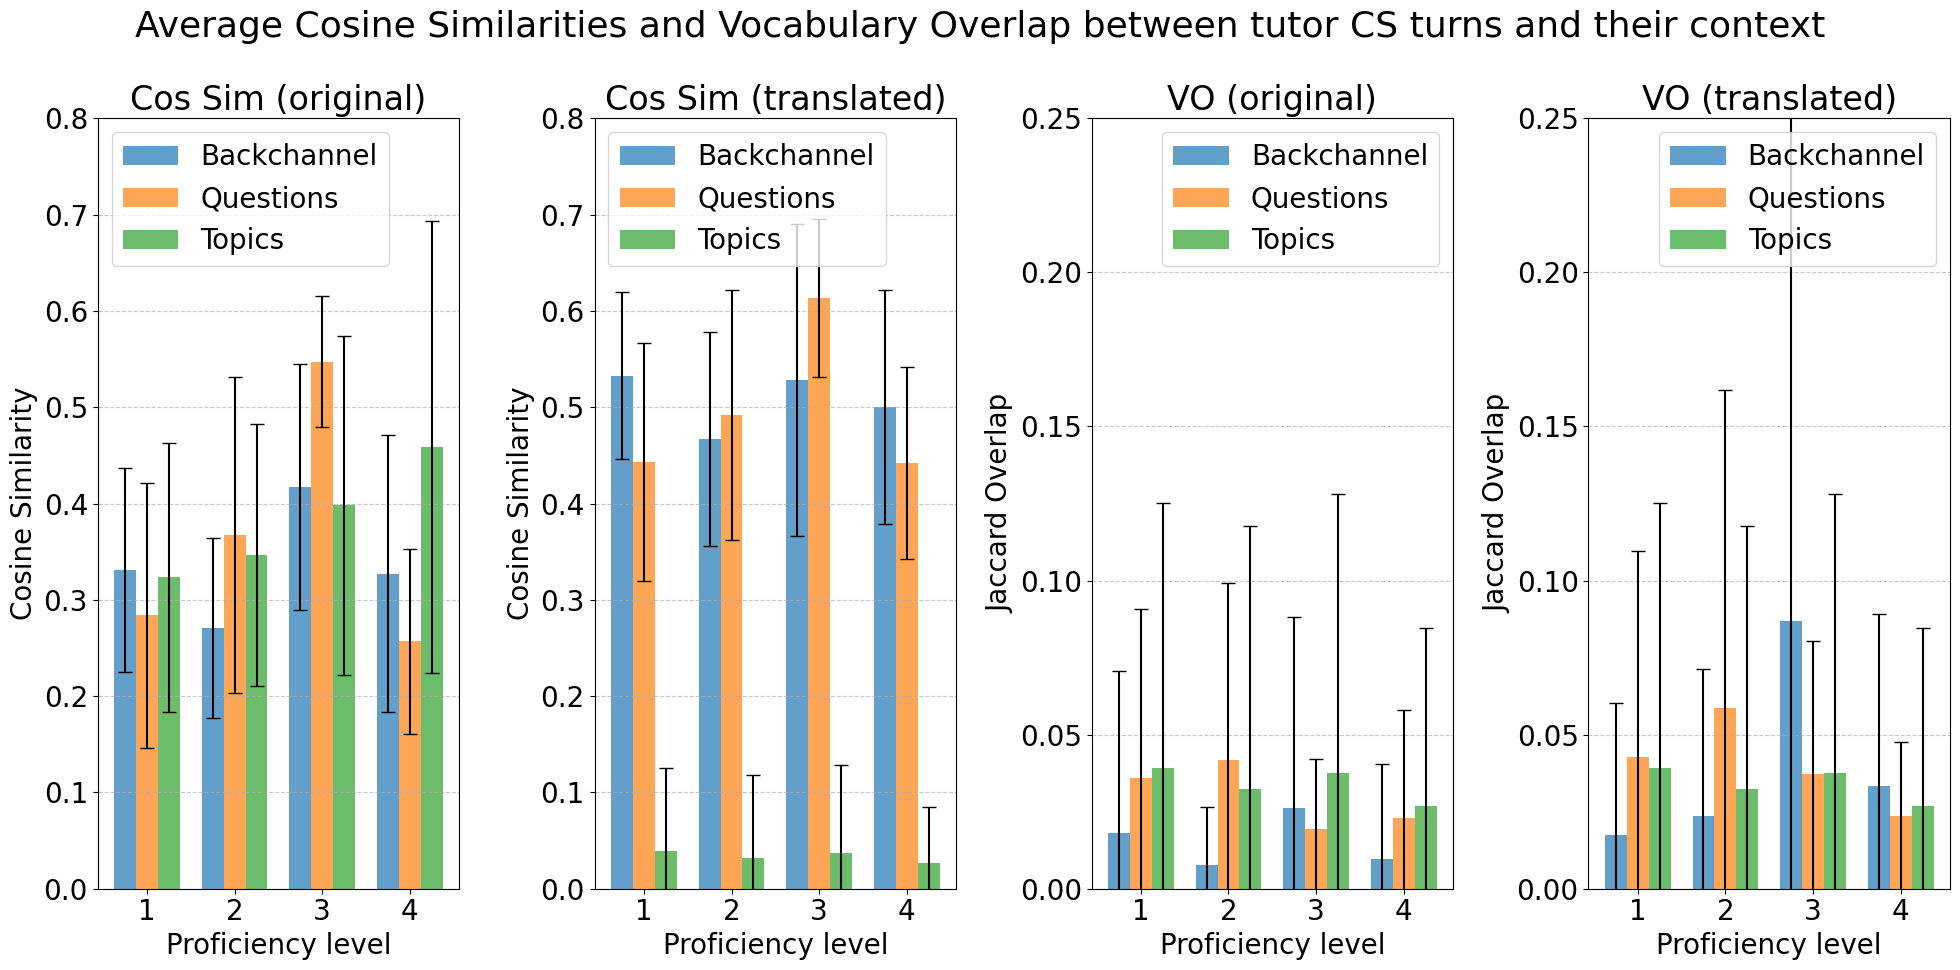

In [146]:
sorted_levels = sorted(cosine_means.keys())
sorted_x_positions = np.arange(len(sorted_levels))
plt.rcParams.update({"font.size": 20})

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10), sharey=False)

bar_width = 0.25

for i, topic in enumerate(topic_labels_combined):
    ax1.bar(
        sorted_x_positions + i * bar_width,
        [cosine_means[level][i] for level in sorted_levels],
        yerr=[cosine_stds[level][i] for level in sorted_levels],
        capsize=5,
        width=bar_width,
        label=f"{topic.capitalize()}",
        alpha=0.7,
    )
plt.grid(axis="y", linestyle="--", alpha=0.7)
ax1.set_title("Cos Sim (original)")
ax1.set_xlabel("Proficiency level")
ax1.set_ylabel("Cosine Similarity")
ax1.set_ylim(0, 0.8)
ax1.set_xticks(sorted_x_positions + (len(topic_labels_combined) - 1) * bar_width / 2)
ax1.set_xticklabels(
    [f"{level}" for level in sorted_levels],
)
ax1.legend(loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

for i, topic in enumerate(topic_labels_combined):
    ax2.bar(
        sorted_x_positions + i * bar_width,
        [cosine_means_trans[level][i] for level in sorted_levels],
        yerr=[cosine_stds_trans[level][i] for level in sorted_levels],
        capsize=5,
        width=bar_width,
        label=f"{topic.capitalize()}",
        alpha=0.7,
    )

ax2.set_title("Cos Sim (translated)")
ax2.set_xlabel("Proficiency level")
ax2.set_ylabel("Cosine Similarity")
ax2.set_ylim(0, 0.8)
ax2.set_xticks(sorted_x_positions + (len(topic_labels_combined) - 1) * bar_width / 2)
ax2.set_xticklabels(
    [f"{level}" for level in sorted_levels],
)
ax2.legend(loc="upper left")

for i, topic in enumerate(topic_labels_combined):
    ax3.bar(
        sorted_x_positions + i * bar_width,
        [overlaps_means[level][i] for level in sorted_levels],
        yerr=[overlaps_stds[level][i] for level in sorted_levels],
        capsize=5,
        width=bar_width,
        label=f"{topic.capitalize()}",
        alpha=0.7,
    )

ax3.set_title("VO (original)")
ax3.set_xlabel("Proficiency level")
ax3.set_ylabel("Jaccard Overlap")
ax3.set_ylim(0, 0.25)
ax3.set_xticks(sorted_x_positions + (len(topic_labels_combined) - 1) * bar_width / 2)
ax3.set_xticklabels(
    [f"{level}" for level in sorted_levels],
)
ax3.legend(loc="upper right")
ax3.set_ylim(0)

for i, topic in enumerate(topic_labels_combined):
    ax4.bar(
        sorted_x_positions + i * bar_width,
        [overlaps_means_trans[level][i] for level in sorted_levels],
        yerr=[overlaps_stds_trans[level][i] for level in sorted_levels],
        capsize=5,
        width=bar_width,
        label=f"{topic.capitalize()}",
        alpha=0.7,
    )

ax4.set_title("VO (translated)")
ax4.set_xlabel("Proficiency level")
ax4.set_ylabel("Jaccard Overlap")
ax4.set_ylim(0, 0.25)
ax4.set_xticks(sorted_x_positions + (len(topic_labels_combined) - 1) * bar_width / 2)
ax4.set_xticklabels(
    [f"{level}" for level in sorted_levels],
)
ax4.legend(loc="upper right")
ax4.set_ylim(0)

fig.suptitle(
    "Average Cosine Similarities and Vocabulary Overlap between tutor CS turns and their context",
    fontsize=26,
)

ax2.grid(axis="y", linestyle="--", alpha=0.7)
ax3.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

This will be a general table to display averages. Not split by levels - for that see graphs


In [147]:
clusters_info_df = pd.DataFrame(
    {
        "Topic": [
            topic_labels_combined[clustered_topic_list_combined[i]]
            for i in range(len(clustered_topic_list_combined))
        ],
        "Cos Sim (original)": [
            np.mean([x[i] for x in [level[1] for level in cosine_means.items()]])
            for i in range(len(clustered_topic_list_combined))
        ],
        "VO (original)": [
            np.mean([x[i] for x in [level[1] for level in overlaps_means.items()]])
            for i in range(len(clustered_topic_list_combined))
        ],
        "Cos Sim (translated)": [
            np.mean([x[i] for x in [level[1] for level in cosine_means_trans.items()]])
            for i in range(len(clustered_topic_list_combined))
        ],
        "VO (translated)": [
            np.mean(
                [x[i] for x in [level[1] for level in overlaps_means_trans.items()]]
            )
            for i in range(len(clustered_topic_list_combined))
        ],
    }
).sort_values(by="Cos Sim (original)", ascending=False)

In [148]:
clusters_info_df

,Topic,Cos Sim (original),VO (original),Cos Sim (translated),VO (translated)
2,topics,0.381530,0.033982,0.033982,0.033982
1,questions,0.363905,0.030036,0.497757,0.040508
0,backchannel,0.336655,0.015483,0.507050,0.040346


In [149]:
print(clusters_info_df.to_latex(float_format="%.3f", index=False))

\begin{tabular}{lrrrr}
\toprule
Topic & Cos Sim (original) & VO (original) & Cos Sim (translated) & VO (translated) \\
\midrule
topics & 0.382 & 0.034 & 0.034 & 0.034 \\
questions & 0.364 & 0.030 & 0.498 & 0.041 \\
backchannel & 0.337 & 0.015 & 0.507 & 0.040 \\
\bottomrule
\end{tabular}



In [ ]:
# T-tables for cosine similarities for original utterances for level vs level in each intent

all_topics = set()


for level_data in cosine_sims_per_level.values():

    all_topics.update(level_data.keys())


all_topics = sorted(list(all_topics))  # sort for consistency



all_levels = sorted(list(cosine_sims_per_level.keys()))



latex_table_data = []



for topic in all_topics:

    for i, level1 in enumerate(all_levels):


        for level2 in all_levels[i + 1 :]:

            try:

                group1 = [sim for sim in cosine_sims_per_level[level1][topic]]

                group2 = [sim for sim in cosine_sims_per_level[level2][topic]]

            except KeyError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals

            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    level1,
                    level2,
                    topic,

                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(

    pd.DataFrame(
        latex_table_data,
        columns=["Level 1", "Level 2", "Topic", "T-statistic", "P-value", "95\% CI"],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for Cosine Similarities for Original Turns across Levels (by Topic)",
        position="h!",
        label="tab-stats-simrisals-levels-by-topic",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Original Turns across Levels (by Topic)}
\label{tab-stats-simrisals-levels-by-topic}
\begin{tabular}{rrllll}
\toprule
Level 1 & Level 2 & Topic & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Backchannel & 1.999 & 0.0513 & [-0.002, 0.106] \\
1 & 3 & Backchannel & -2.128 & 0.0403* & [-0.140, -0.008] \\
1 & 4 & Backchannel & 0.083 & 0.9347 & [-0.086, 0.094] \\
2 & 3 & Backchannel & -4.839 & 0.0000* & [-0.181, -0.071] \\
2 & 4 & Backchannel & -1.468 & 0.1493 & [-0.130, 0.033] \\
3 & 4 & Backchannel & 1.765 & 0.0874 & [-0.013, 0.168] \\
1 & 2 & Questions & -2.221 & 0.0298* & [-0.140, -0.005] \\
1 & 3 & Questions & -4.877 & 0.0000* & [-0.287, -0.169] \\
1 & 4 & Questions & 0.456 & 0.6507 & [-0.058, 0.105] \\
2 & 3 & Questions & -2.747 & 0.0101* & [-0.229, -0.082] \\
2 & 4 & Questions & 1.539 & 0.1347 & [0.003, 0.188] \\
3 & 4 & Questions & 5.858 & 0.0001* & [0.165, 0.338] \\
1 & 2 & Topics & -2.537 & 0.0113* & [-0

<>:72: SyntaxWarning:

invalid escape sequence '\%'

<>:72: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3845190490.py:72: SyntaxWarning:

invalid escape sequence '\%'



In [151]:
topic_labels_combined = [x.capitalize() for x in topic_labels_combined]

In [ ]:
# T-tables for cosine similarities for translated utterances for level vs level in each intent

all_levels = sorted(list(all_cosine_sims_trans_by_level_combined.keys()))



latex_table_data_list = []



for i, level1 in enumerate(all_levels):


    for level2 in all_levels[i + 1 :]:

        for topic_index, topic in enumerate(topic_labels_combined):

            try:

                group1 = all_cosine_sims_trans_by_level_combined[level1][topic_index]

                group2 = all_cosine_sims_trans_by_level_combined[level2][topic_index]

            except IndexError:

                continue  # Skip if a level doesn't have three inner lists


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)

            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data_list.append(
                [
                    level1,
                    level2,
                    topic,

                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )



print(
    pd.DataFrame(
        latex_table_data_list,
        columns=[
            "Level 1",
            "Level 2",
            "Intent",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for Cosine Similarities for Translated Turns across Levels ",
        position="h!",
        label="tab-stats-simrisals-levels-by-intent",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Cosine Similarities for Translated Turns across Levels }
\label{tab-stats-simrisals-levels-by-intent}
\begin{tabular}{rrllll}
\toprule
Level 1 & Level 2 & Intent & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Backchannel & 2.126 & 0.0386* & [0.009, 0.122] \\
1 & 2 & Questions & -1.529 & 0.1311 & [-0.113, 0.015] \\
1 & 2 & Topics & 1.295 & 0.1957 & [-0.004, 0.018] \\
1 & 3 & Backchannel & 0.106 & 0.9164 & [-0.076, 0.085] \\
1 & 3 & Questions & -3.458 & 0.0011* & [-0.246, -0.095] \\
1 & 3 & Topics & 0.162 & 0.8714 & [-0.019, 0.023] \\
1 & 4 & Backchannel & 0.798 & 0.4320 & [-0.054, 0.118] \\
1 & 4 & Questions & 0.014 & 0.9888 & [-0.094, 0.096] \\
1 & 4 & Topics & 1.020 & 0.3080 & [-0.005, 0.030] \\
2 & 3 & Backchannel & -1.614 & 0.1126 & [-0.141, 0.018] \\
2 & 3 & Questions & -2.264 & 0.0310* & [-0.205, -0.037] \\
2 & 3 & Topics & -0.530 & 0.5965 & [-0.026, 0.015] \\
2 & 4 & Backchannel & -0.826 & 0.4133 & [-0.118, 0.051] \\
2 & 4 & 

<>:68: SyntaxWarning:

invalid escape sequence '\%'

<>:68: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3513820031.py:68: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# T-tables for overlaps for original utterances for level vs level in each intent


all_levels = sorted(list(all_overlaps_by_level_combined.keys()))



latex_table_data_list = []



for i, level1 in enumerate(all_levels):


    for level2 in all_levels[i + 1 :]:

        for topic_index, topic in enumerate(topic_labels_combined):

            try:

                group1 = all_overlaps_by_level_combined[level1][topic_index]

                group2 = all_overlaps_by_level_combined[level2][topic_index]

            except IndexError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data_list.append(
                [
                    level1,
                    level2,
                    topic,

                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )



print(
    pd.DataFrame(
        latex_table_data_list,
        columns=[
            "Level 1",
            "Level 2",
            "Intent",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for VO Original Turns across Levels ",
        position="h!",
        label="tab-stats-simrisals-levels-by-intent",
    )
)

<>:69: SyntaxWarning:

invalid escape sequence '\%'

<>:69: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2476269560.py:69: SyntaxWarning:

invalid escape sequence '\%'



\begin{table}[h!]
\caption{Pairwise t-tests for VO Original Turns across Levels }
\label{tab-stats-simrisals-levels-by-intent}
\begin{tabular}{rrllll}
\toprule
Level 1 & Level 2 & Intent & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Backchannel & 0.975 & 0.3345 & [-0.016, 0.036] \\
1 & 2 & Questions & -0.421 & 0.6751 & [-0.034, 0.022] \\
1 & 2 & Topics & 1.295 & 0.1957 & [-0.004, 0.018] \\
1 & 3 & Backchannel & -0.437 & 0.6642 & [-0.045, 0.028] \\
1 & 3 & Questions & 0.757 & 0.4527 & [-0.008, 0.041] \\
1 & 3 & Topics & 0.162 & 0.8714 & [-0.019, 0.023] \\
1 & 4 & Backchannel & 0.460 & 0.6491 & [-0.023, 0.040] \\
1 & 4 & Questions & 0.538 & 0.5931 & [-0.022, 0.048] \\
1 & 4 & Topics & 1.020 & 0.3080 & [-0.005, 0.030] \\
2 & 3 & Backchannel & -1.561 & 0.1246 & [-0.046, 0.009] \\
2 & 3 & Questions & 0.973 & 0.3383 & [-0.007, 0.052] \\
2 & 3 & Topics & -0.530 & 0.5965 & [-0.026, 0.015] \\
2 & 4 & Backchannel & -0.238 & 0.8129 & [-0.022, 0.018] \\
2 & 4 & Questions & 0.738 & 0.4662 &

In [ ]:
# T-tables for cosine similarities for translated utterances for level vs level in each intent

all_levels = sorted(list(all_overlaps_trans_by_level_combined.keys()))



latex_table_data_list = []



for i, level1 in enumerate(all_levels):


    for level2 in all_levels[i + 1 :]:

        for topic_index, topic in enumerate(topic_labels_combined):

            try:

                group1 = all_overlaps_trans_by_level_combined[level1][topic_index]

                group2 = all_overlaps_trans_by_level_combined[level2][topic_index]

            except IndexError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals
            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data_list.append(
                [
                    level1,
                    level2,
                    topic,

                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )



print(
    pd.DataFrame(
        latex_table_data_list,
        columns=[
            "Level 1",
            "Level 2",
            "Intent",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for VO Translated Turns across Levels by Intent",
        position="h!",
        label="tab-stats-simrisals-levels-by-intent",
    )
)

<>:66: SyntaxWarning:

invalid escape sequence '\%'

<>:66: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\183494765.py:66: SyntaxWarning:

invalid escape sequence '\%'



\begin{table}[h!]
\caption{Pairwise t-tests for VO Translated Turns across Levels by Intent}
\label{tab-stats-simrisals-levels-by-intent}
\begin{tabular}{rrllll}
\toprule
Level 1 & Level 2 & Intent & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Backchannel & -0.449 & 0.6551 & [-0.033, 0.020] \\
1 & 2 & Questions & -0.768 & 0.4450 & [-0.062, 0.030] \\
1 & 2 & Topics & 1.295 & 0.1957 & [-0.004, 0.018] \\
1 & 3 & Backchannel & -1.336 & 0.1895 & [-0.162, 0.023] \\
1 & 3 & Questions & 0.200 & 0.8423 & [-0.035, 0.045] \\
1 & 3 & Topics & 0.162 & 0.8714 & [-0.019, 0.023] \\
1 & 4 & Backchannel & -0.831 & 0.4131 & [-0.056, 0.024] \\
1 & 4 & Questions & 0.680 & 0.4997 & [-0.010, 0.048] \\
1 & 4 & Topics & 1.020 & 0.3080 & [-0.005, 0.030] \\
2 & 3 & Backchannel & -1.602 & 0.1153 & [-0.155, 0.029] \\
2 & 3 & Questions & 0.520 & 0.6068 & [-0.032, 0.075] \\
2 & 3 & Topics & -0.530 & 0.5965 & [-0.026, 0.015] \\
2 & 4 & Backchannel & -0.541 & 0.5913 & [-0.048, 0.029] \\
2 & 4 & Questions & 0.8

## Now, let's compare inter-switched utterances to the intra-switched ones. Which ones show more similarity to the context?


In [155]:
all_tutor_switched_utts.columns

Index(['UtteranceID', 'FileID', 'Corpus', 'Group', 'Proficiency',
       'Participant', 'PrevPar', 'UtteranceLang', 'LangRole', 'TurnNo',
       'UtteranceNo', 'PosInTurn', 'Utterance', 'InterSwitch', 'IntraSwitch',
       'PrevSwitchDistance', 'LastCS', 'MatrixLangWords', 'EmbedLangWords',
       'Translation', 'nWords', 'Turn', 'TurnTranslation', 'TurnLanguage',
       'PrevTurn', 'PrevTurnTrans'],
      dtype='object')

In [ ]:
# Grouping the code-switched tutor turns into two categories - intra and inter switched

all_tutor_intra_switched_utts = all_tutor_switched_utts[

    all_tutor_switched_utts["IntraSwitch"] == True
]


all_tutor_inter_switched_utts = all_tutor_switched_utts[
    all_tutor_switched_utts["InterSwitch"] == True
]

In [157]:
proficiency_groups_intra = all_tutor_intra_switched_utts.groupby("Proficiency")

# Finding cosine similarities for the intra switched utterances

sorted_intra_similarities_per_group = {}
for proficiency, group in proficiency_groups_intra:
    print(f"Proficiency Level: {proficiency}")

    tutor_intra_cs_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) for utt in group["Turn"]
    ]
    context_intra_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
        for utt in group["PrevTurn"]
    ]

    intra_similarities = [
        (
            i,
            (
                cosine_similarity(tutor_emb, context_emb)[0][0]
                if context_emb is not None
                else 0
            ),
        )
        for (i, (tutor_emb, context_emb)) in enumerate(
            zip(tutor_intra_cs_embeddings, context_intra_embeddings)
        )
    ]

    sorted_intra_similarities = sorted(
        intra_similarities, key=lambda x: x[1], reverse=True
    )

    sorted_intra_similarities_per_group[proficiency] = sorted_intra_similarities

    for sim in sorted_intra_similarities[:30]:

        best_match_index = sim[0]

        best_match_utts = (
            group["Turn"].iloc[best_match_index],
            group["PrevTurn"].iloc[best_match_index],
        )

        print(f"Tutor utterance: {best_match_utts[0]}")

        print(f"Context: {best_match_utts[1]}")

        print(f"Cosine similarity: {sim[1]}")

        print("-" * 40)

Proficiency Level: 1
Tutor utterance: arrive arribar
Context: arrive
Cosine similarity: 0.7705099582672119
----------------------------------------
Tutor utterance: you like gimnàstica
Context: sí molta calor it's class també gimnàstica
Cosine similarity: 0.7321295738220215
----------------------------------------
Tutor utterance: two o'clock okay and then you eat here et quedes aquí a dinar
Context: he is two o'clock
Cosine similarity: 0.7150551676750183
----------------------------------------
Tutor utterance: entenza what number
Context: he is entenza
Cosine similarity: 0.6808703541755676
----------------------------------------
Tutor utterance: el teu pare et dóna classes danglès so he talks to you in english
Context: no només el meu pare em dóna classes
Cosine similarity: 0.6764329671859741
----------------------------------------
Tutor utterance: okay where do you live where do you live you go home to have lunch vas a casa a dinar
Context: go home lunch
Cosine similarity: 0.67566

In [158]:
# same for Miami

print(f"Proficiency Level: {5}")

tutor_intra_cs_embeddings_miami = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer)
    for utt in miami_intra_switched_utts["Turn"]
]
context_intra_embeddings_miami = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
    for utt in miami_intra_switched_utts["PrevTurn"]
]

intra_similarities = [
    (
        i,
        (
            cosine_similarity(tutor_emb, context_emb)[0][0]
            if context_emb is not None
            else 0
        ),
    )
    for (i, (tutor_emb, context_emb)) in enumerate(
        zip(tutor_intra_cs_embeddings_miami, context_intra_embeddings_miami)
    )
]

sorted_intra_similarities = sorted(intra_similarities, key=lambda x: x[1], reverse=True)

sorted_intra_similarities_per_group[5] = sorted_intra_similarities

Proficiency Level: 5


In [ ]:
proficiency_groups_inter = all_tutor_inter_switched_utts.groupby("Proficiency")


# Finding cosine similarities for the inter switched utterances


sorted_inter_similarities_per_group = {}


for proficiency, group in proficiency_groups_inter:

    print(f"Proficiency Level: {proficiency}")


    tutor_inter_cs_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) for utt in group["Turn"]
    ]


    context_inter_embeddings = [
        get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None

        for utt in group["PrevTurn"]
    ]


    inter_similarities = [
        (

            i,
            (

                cosine_similarity(tutor_emb, context_emb)[0][0]
                if context_emb is not None
                else 0
            ),
        )

        for (i, (tutor_emb, context_emb)) in enumerate(
            zip(tutor_inter_cs_embeddings, context_inter_embeddings)
        )
    ]


    sorted_inter_similarities = sorted(

        inter_similarities, key=lambda x: x[1], reverse=True
    )


    sorted_inter_similarities_per_group[proficiency] = sorted_inter_similarities


    for sim in sorted_inter_similarities[:30]:


        best_match_index = sim[0]


        best_match_utts = (
            group["Turn"].iloc[best_match_index],

            group["PrevTurn"].iloc[best_match_index],
        )


        print(f"Tutor utterance: {best_match_utts[0]}")


        print(f"Context: {best_match_utts[1]}")


        print(f"Cosine similarity: {sim[1]}")


        print("-" * 40)

Proficiency Level: 1
Tutor utterance: reyescatólicos dacord
Context: hm reyescatólicos
Cosine similarity: 0.8018726110458374
----------------------------------------
Tutor utterance: Una habitació
Context: a room
Cosine similarity: 0.7343437671661377
----------------------------------------
Tutor utterance: you like gimnàstica
Context: sí molta calor it's class també gimnàstica
Cosine similarity: 0.7321295738220215
----------------------------------------
Tutor utterance: where where is it you understand where on on és casa teva on vius
Context: where is your house què faig a casa meva
Cosine similarity: 0.7278628349304199
----------------------------------------
Tutor utterance: where where is it you understand where on on és casa teva on vius
Context: where is your house què faig a casa meva
Cosine similarity: 0.7278628349304199
----------------------------------------
Tutor utterance: Catalan
Context: català
Cosine similarity: 0.7119355201721191
-------------------------------------

In [160]:
# same for Miami (level 5)

print(f"Proficiency Level: 5")

tutor_inter_cs_embeddings_miami = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer)
    for utt in miami_inter_switched_utts["Turn"]
]
context_inter_embeddings_miami = [
    get_bert_embeddings(utt, multi_model, multi_tokenizer) if utt else None
    for utt in miami_inter_switched_utts["PrevTurn"]
]

inter_similarities = [
    (
        i,
        (
            cosine_similarity(tutor_emb, context_emb)[0][0]
            if context_emb is not None
            else 0
        ),
    )
    for (i, (tutor_emb, context_emb)) in enumerate(
        zip(tutor_inter_cs_embeddings_miami, context_inter_embeddings_miami)
    )
]

sorted_inter_similarities = sorted(inter_similarities, key=lambda x: x[1], reverse=True)

sorted_inter_similarities_per_group[5] = sorted_inter_similarities

Proficiency Level: 5


In [161]:
print("Intra")
for group, sims in sorted_intra_similarities_per_group.items():
    print(f"Proficiency Level: {group}")
    print(
        "Average cosine sim for intra-switched utterances: ",
        np.mean([sim[1] for sim in sims]),
    )
print("Inter")
for group, sims in sorted_inter_similarities_per_group.items():
    print(f"Proficiency Level: {group}")
    print(
        "Average cosine sim for inter-switched utterances: ",
        np.mean([sim[1] for sim in sims]),
    )

Intra
Proficiency Level: 1
Average cosine sim for intra-switched utterances:  0.44060152452292406
Proficiency Level: 2
Average cosine sim for intra-switched utterances:  0.4606190373500188
Proficiency Level: 3
Average cosine sim for intra-switched utterances:  0.49435848
Proficiency Level: 4
Average cosine sim for intra-switched utterances:  0.43422055
Proficiency Level: 5
Average cosine sim for intra-switched utterances:  0.48441097168035285
Inter
Proficiency Level: 1
Average cosine sim for inter-switched utterances:  0.41855040617914413
Proficiency Level: 2
Average cosine sim for inter-switched utterances:  0.4282227862572324
Proficiency Level: 3
Average cosine sim for inter-switched utterances:  0.46610472
Proficiency Level: 4
Average cosine sim for inter-switched utterances:  0.4452514
Proficiency Level: 5
Average cosine sim for inter-switched utterances:  0.45882362034138163


In [162]:
proficiency_levels = sorted_intra_similarities_per_group.keys()

sorted_intra_sim_values = {
    proficiency: [sim[1] for sim in sims]
    for proficiency, sims in sorted_intra_similarities_per_group.items()
}

sorted_inter_sim_values = {
    proficiency: [sim[1] for sim in sims]
    for proficiency, sims in sorted_inter_similarities_per_group.items()
}

In [ ]:
# Boxplot - DISUSED, hence commented out



# plt.figure(figsize=(16, 7))

# plt.suptitle(



#     "Cosine Similarities Between Tutor Original inter- and intra- Code-Switched Utterances and Their Context",


#     fontsize=18,


#     position=(0.5, 1.05),
# )



# colors = [


#     "purple" if proficiency != 5 else "firebrick"


#     for proficiency in sorted_intra_sim_values.keys()


# ]



# plt.subplot(1, 2, 1)


# box_trans = plt.boxplot(


#     sorted_intra_sim_values.values(),


#     patch_artist=True,


#     boxprops=dict(facecolor="lightblue"),


#     labels=sorted_intra_sim_values.keys(),
# )



# plt.grid(axis="y", linestyle="--", alpha=0.7)



# for patch, color in zip(box_trans["boxes"], colors):

#     patch.set_facecolor(color)



# plt.title("Intra-Switched Turns")


# plt.ylim(0, 1)


# plt.ylabel("Cosine Similarity")


# plt.xlabel("Proficiency Level")



# colors = [


#     "orange" if proficiency != 5 else "orangered"


#     for proficiency in sorted_inter_sim_values.keys()


# ]



# plt.subplot(1, 2, 2)


# box_orig = plt.boxplot(


#     sorted_inter_sim_values.values(),


#     patch_artist=True,


#     boxprops=dict(facecolor="orange"),


#     labels=sorted_inter_sim_values.keys(),
# )



# for patch, color in zip(box_orig["boxes"], colors):

#     patch.set_facecolor(color)



# plt.title("Inter-Switched Turns")


# plt.ylim(0, 1)


# plt.ylabel("Cosine Similarity")


# plt.xlabel("Proficiency Level")



# plt.tight_layout(rect=[0, 0, 1, 0.95])


# plt.grid(axis="y", linestyle="--", alpha=0.7)



# legend_elements = [


#     Patch(facecolor="purple", edgecolor="black", label="Intra-switched"),


#     Patch(facecolor="orange", edgecolor="black", label="Inter-switched"),


#     Patch(


#         facecolor="firebrick",


#         edgecolor="black",


#         label="Bilingual reference (Intra-switched)",
#     ),



#     Patch(


#         facecolor="orangered",


#         edgecolor="black",


#         label="Bilingual reference (Inter-switched)",
#     ),



# ]



# plt.legend(


#     handles=legend_elements,



#     title="Turn Type",


#     fontsize=12,
#     loc="upper center",



#     bbox_to_anchor=(-0.1, 1.28),


#     ncol=4,
# )



# plt.show()

## Bar plot for cosine similarities intra vs inter


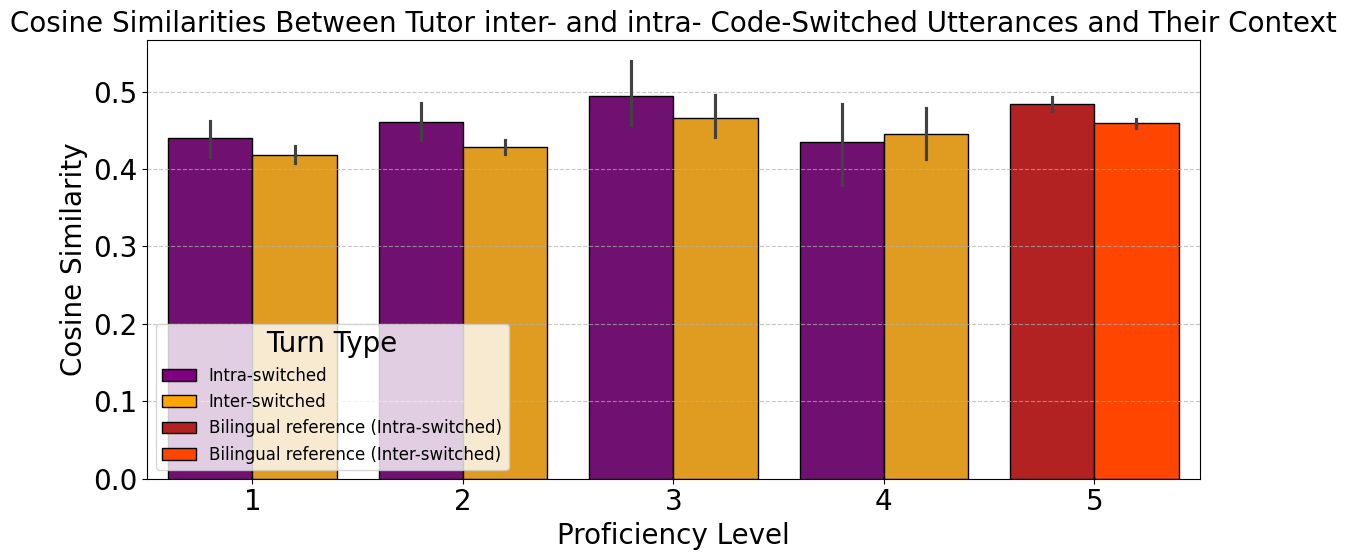

In [164]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns

data = []

for proficiency, sims in sorted_intra_sim_values.items():
    data.extend(
        [{"Proficiency": proficiency, "Sim": sim, "Type": "Intra"} for sim in sims]
    )

for proficiency, sims in sorted_inter_sim_values.items():
    data.extend(
        [{"Proficiency": proficiency, "Sim": sim, "Type": "Inter"} for sim in sims]
    )

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Proficiency",
    y="Sim",
    hue="Type",
    ci=95,
    palette={"Intra": "purple", "Inter": "orange"},
    edgecolor="black",
)

for i, bar in enumerate(plt.gca().patches):
    if i == 4:
        bar.set_color("firebrick")
        bar.set_edgecolor("black")
    elif i == 9:
        bar.set_color("orangered")
        bar.set_edgecolor("black")

legend_elements = [
    Patch(facecolor="purple", edgecolor="black", label="Intra-switched"),
    Patch(facecolor="orange", edgecolor="black", label="Inter-switched"),
    Patch(
        facecolor="firebrick",
        edgecolor="black",
        label="Bilingual reference (Intra-switched)",
    ),
    Patch(
        facecolor="orangered",
        edgecolor="black",
        label="Bilingual reference (Inter-switched)",
    ),
]
plt.xlabel("Proficiency Level")
plt.ylabel("Cosine Similarity")
plt.title(
    "Cosine Similarities Between Tutor inter- and intra- Code-Switched Utterances and Their Context",
    fontsize=20,
)
plt.xticks()
plt.yticks()
plt.legend(handles=legend_elements, title="Turn Type", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [165]:
from scipy.stats import ttest_ind
from scipy.stats import ttest_ind, sem
import numpy as np

# T-test for cosine similarities for inter- and intra-switched utterances
data_inter = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in sorted_inter_sim_values.items()
    for sim in sims
]
data_intra = [
    {"Proficiency": level, "Similarity": sim}
    for level, sims in sorted_intra_sim_values.items()
    for sim in sims
]


df_inter = pd.DataFrame(data_inter)
df_intra = pd.DataFrame(data_intra)

# Level vs level for inter-switched

latex_table_data = []
unique_proficiencies = df_inter["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df_inter[df_inter["Proficiency"] == prof1]["Similarity"]
        group2 = df_inter[df_inter["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculate confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        latex_table_data.append(
            [
                prof1,
                prof2,
                f"{t_stat:.3f}",
                f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                f"[{ci_low:.3f}, {ci_high:.3f}]",
            ]
        )
print(
    pd.DataFrame(
        latex_table_data,
        columns=["Proficiency 1", "Proficiency 2", "T-statistic", "P-value", "95% CI"],
    ).to_latex(index=False)
)

# Level vs level for intra-switched

latex_table_data = []
unique_proficiencies = df_intra["Proficiency"].unique()
for i, prof1 in enumerate(unique_proficiencies):
    for prof2 in unique_proficiencies[i + 1 :]:
        group1 = df_intra[df_intra["Proficiency"] == prof1]["Similarity"]
        group2 = df_intra[df_intra["Proficiency"] == prof2]["Similarity"]
        t_stat, p_value = ttest_ind(group1, group2)

        # Calculate confidence intervals
        mean_diff = np.mean(group1) - np.mean(group2)
        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
        ci_low = mean_diff - 1.96 * pooled_se
        ci_high = mean_diff + 1.96 * pooled_se

        latex_table_data.append(
            [
                prof1,
                prof2,
                f"{t_stat:.3f}",
                f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                f"[{ci_low:.3f}, {ci_high:.3f}]",
            ]
        )
print(
    pd.DataFrame(
        latex_table_data,
        columns=["Proficiency 1", "Proficiency 2", "T-statistic", "P-value", "95% CI"],
    ).to_latex(index=False)
)

\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95% CI \\
\midrule
1 & 2 & -1.366 & 0.1721 & [-0.024, 0.004] \\
1 & 3 & -3.565 & 0.0004* & [-0.076, -0.019] \\
1 & 4 & -1.608 & 0.1084 & [-0.063, 0.010] \\
1 & 5 & -5.690 & 0.0000* & [-0.052, -0.029] \\
2 & 3 & -2.887 & 0.0040* & [-0.066, -0.010] \\
2 & 4 & -1.034 & 0.3016 & [-0.054, 0.019] \\
2 & 5 & -4.814 & 0.0000* & [-0.041, -0.020] \\
3 & 4 & 0.927 & 0.3555 & [-0.023, 0.065] \\
3 & 5 & 0.474 & 0.6353 & [-0.020, 0.035] \\
4 & 5 & -0.685 & 0.4935 & [-0.049, 0.022] \\
\bottomrule
\end{tabular}

\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95% CI \\
\midrule
1 & 2 & -1.166 & 0.2445 & [-0.053, 0.013] \\
1 & 3 & -2.117 & 0.0358* & [-0.101, -0.007] \\
1 & 4 & 0.200 & 0.8414 & [-0.051, 0.064] \\
1 & 5 & -2.833 & 0.0047* & [-0.069, -0.018] \\
2 & 3 & -1.274 & 0.2042 & [-0.081, 0.013] \\
2 & 4 & 0.787 & 0.4323 & [-0.031, 0.084] \\
2 & 5 & -1.657 & 0.0977 & [-0.0

## Now, I inspect translations


In [166]:
# We find Catalan tutor utterances which are translations of previous student utterances
# We find examples in which at least one word is a translation

all_tutor_catalan_switched_utts = all_tutor_switched_utts[
    all_tutor_switched_utts["UtteranceLang"] == "spanish/catalan"
]
all_tutor_eng_switched_utts = all_tutor_switched_utts[
    all_tutor_switched_utts["UtteranceLang"] == "english"
]

print(
    f"""Total number of tutor Catalan cs utterances: {len(all_tutor_catalan_switched_utts)}\n
    Total number of tutor English cs utterances: {len(all_tutor_eng_switched_utts)}"""
)

Total number of tutor Catalan cs utterances: 329

    Total number of tutor English cs utterances: 1180


In [167]:
all_tutor_catalan_switched_utts_grouped = all_tutor_catalan_switched_utts.groupby(
    "Proficiency"
)
all_tutor_eng_switched_utts_grouped = all_tutor_eng_switched_utts.groupby("Proficiency")

In [168]:
translated_into_catalan_examples = []
for i, utt in all_tutor_catalan_switched_utts.iterrows():

    # Detecting translations from English to Catalan

    if utt["PrevTurn"] and utt["PrevTurnTrans"] is not None:
        student_tokens = set(tokenize_and_preprocess(utt["PrevTurn"]))
        tutor_tokens = set(tokenize_and_preprocess(utt["Turn"]))
        student_trans_tokens = set(
            tokenize_and_preprocess(utt["PrevTurnTrans"], english=True)
        )
        tutor_trans_tokens = set(
            tokenize_and_preprocess(utt["TurnTranslation"], english=True)
        )

        words_translated_by_tutor = tutor_trans_tokens.intersection(
            student_tokens
        ).difference(tutor_tokens)

        if words_translated_by_tutor:
            translated_into_catalan_examples.append(
                {
                    "Tutor turn": utt["Turn"],
                    "Tutor translated turn": utt["TurnTranslation"],
                    "Student turn": utt["PrevTurn"],
                    "Student translated turn": utt["PrevTurnTrans"],
                    "Translated words": words_translated_by_tutor,
                    "Translated into": "Catalan",
                }
            )

translated_into_catalan_examples = pd.DataFrame(translated_into_catalan_examples)
translated_into_catalan_examples

,Tutor turn,Tutor translated turn,Student turn,Student translated turn,Translated words,Translated into
0,hm I like the no sé,hm I like the I don't know.,hm hm what do you like about it,hm hm what do you like about it,{do},Catalan
1,okay y tú en qué idioma Le hablas a Ella,okay And what language do you speak to her?,three català spanish and english,three català spanish and english,{and},Catalan
2,Les classes danglès Les fas a lescola o fora d...,Les classes danglès You do them at school or o...,I wednesday hm three at five,I wednesday hm three at five,{at},Catalan
3,where where is it you understand where on on é...,where where is it you understand where Where i...,where is your house què faig a casa meva,Where is your house? What do I do at my house?,{your},Catalan
4,no if you wanna ask me questions el que testic...,no if you wanna ask me questions The one I tes...,si Jo the entès,If Jo the entès,{the},Catalan
5,mhas entès què tagrada de la RamonLlull,You know What's the story with Ramon Llull?,what do you like about it,what do you like about it,"{what, you}",Catalan
6,a casa jugues a futbol,Home playing football,hm playing football I watch tv watch tv,hm playing football I watch tv watch tv,"{playing, football}",Catalan
7,quan quan la professora et parla en anglès a l...,"When the teacher speaks English to the class, ...",com the teacher,com the teacher,"{teacher, the}",Catalan
8,aquest cap de setmana espera okay my question ...,This weekend espera okay my question is what d...,no the entenc,No the entenc,{the},Catalan
9,Una habitació,One room,a room,a room,{room},Catalan


In [169]:
translated_into_english_examples = []


for i, utt in all_tutor_eng_switched_utts.iterrows():

    if utt["PrevTurn"] and utt["PrevTurnTrans"] is not None:

        # detecting translations from Catalan into English

        student_tokens = set(tokenize_and_preprocess(utt["PrevTurn"]))

        tutor_tokens = set(tokenize_and_preprocess(utt["Turn"]))

        student_trans_tokens = set(
            tokenize_and_preprocess(utt["PrevTurnTrans"], english=True)
        )

        tutor_trans_tokens = set(
            tokenize_and_preprocess(utt["TurnTranslation"], english=True)
        )

        words_translated_by_tutor = student_trans_tokens.intersection(
            tutor_tokens
        ).difference(student_tokens)

        if words_translated_by_tutor:

            translated_into_english_examples.append(
                {
                    "Tutor turn": utt["Turn"],
                    "Tutor translated turn": utt["TurnTranslation"],
                    "Student turn": utt["PrevTurn"],
                    "Student translated turn": utt["PrevTurnTrans"],
                    "Translated words": words_translated_by_tutor,
                    "Translated into": "English",
                }
            )


translated_into_english_examples = pd.DataFrame(translated_into_english_examples)


translated_into_english_examples

,Tutor turn,Tutor translated turn,Student turn,Student translated turn,Translated words,Translated into
0,something you wanna know about me seguro then ...,something you wanna know about me Insurance th...,how old are you I'm twenty six years old no sé,how old are you I'm twenty six years old I don...,{know},English
1,something you wanna know about me seguro then ...,something you wanna know about me Insurance th...,how old are you I'm twenty six years old no sé,how old are you I'm twenty six years old I don...,{know},English
2,and do you like english the extraescolar,and do you like english the extraescolar,no no sé com va,I don't know how it goes.,{do},English
3,english philology,english philology,filología inglesa,English philology,"{philology, english}",English
4,what don't you like,what don't you like,no sé qué me gusta,I don't know what I like.,"{what, like, do}",English
...,...,...,...,...,...,...
266,how many people are there in your family,how many people are there in your family,quantes persones,How many people,"{people, how, many}",English
267,older than you,older than you,hm alt és més gran que Jo,You're older than Jo.,"{you, older, than}",English
268,no why not,no why not,no,"No, I did not.",{not},English
269,Catalan too okay,Catalan too okay,catalán,Catalan,{catalan},English


In [ ]:
# Concatenating all translations

all_translated_examples = pd.concat(

    [translated_into_catalan_examples, translated_into_english_examples]
)


all_translated_examples

,Tutor turn,Tutor translated turn,Student turn,Student translated turn,Translated words,Translated into
0,hm I like the no sé,hm I like the I don't know.,hm hm what do you like about it,hm hm what do you like about it,{do},Catalan
1,okay y tú en qué idioma Le hablas a Ella,okay And what language do you speak to her?,three català spanish and english,three català spanish and english,{and},Catalan
2,Les classes danglès Les fas a lescola o fora d...,Les classes danglès You do them at school or o...,I wednesday hm three at five,I wednesday hm three at five,{at},Catalan
3,where where is it you understand where on on é...,where where is it you understand where Where i...,where is your house què faig a casa meva,Where is your house? What do I do at my house?,{your},Catalan
4,no if you wanna ask me questions el que testic...,no if you wanna ask me questions The one I tes...,si Jo the entès,If Jo the entès,{the},Catalan
...,...,...,...,...,...,...
266,how many people are there in your family,how many people are there in your family,quantes persones,How many people,"{people, how, many}",English
267,older than you,older than you,hm alt és més gran que Jo,You're older than Jo.,"{you, older, than}",English
268,no why not,no why not,no,"No, I did not.",{not},English
269,Catalan too okay,Catalan too okay,catalán,Catalan,{catalan},English


In [ ]:
# Finding all unique translated words

all_translated_words = set(
    [word for words in all_translated_examples["Translated words"] for word in words]
)


print(f"Total number of unique translated words: {len(all_translated_words)}")

Total number of unique translated words: 110


In [172]:
# Age of Acquisition data

AoA_list = pd.read_excel("AoA/AoA_51715_words.xlsx")[["Word", "AoA_Kup_lem"]]

In [173]:
AoA_list.head()

,Word,AoA_Kup_lem
0,a,2.893384
1,aardvark,9.890000
2,abacus,8.690000
3,abacuses,8.690000
4,abalone,12.230000


In [174]:
WF_list_billion = pd.read_csv(
    "unigram_freq.csv/unigram_freq.csv"
)  # Word frequency data

In [ ]:
# Calculating AoA and WF for all the unique words

translated_words_stats = [
    {
        "Word": word,
        "AoA": (
            AoA_list[AoA_list["Word"] == word]["AoA_Kup_lem"].values[0]
            if word in AoA_list["Word"].values
            else None
        ),
        "WF": (
            WF_list_billion.index[WF_list_billion["word"] == word].tolist()[0]
            if word in WF_list_billion["word"].values
            else None
        ),
    }
    for word in all_translated_words
]



translated_words_stats_df = pd.DataFrame(translated_words_stats)

Outlier Coordinates:
           Word     WF        AoA
20      sixteen  12988   4.804336
53    philology  60547  15.535935
60  hairdresser  38727   6.650000
80      shelves  10686   5.500000
91  grandmother  12145   3.670000


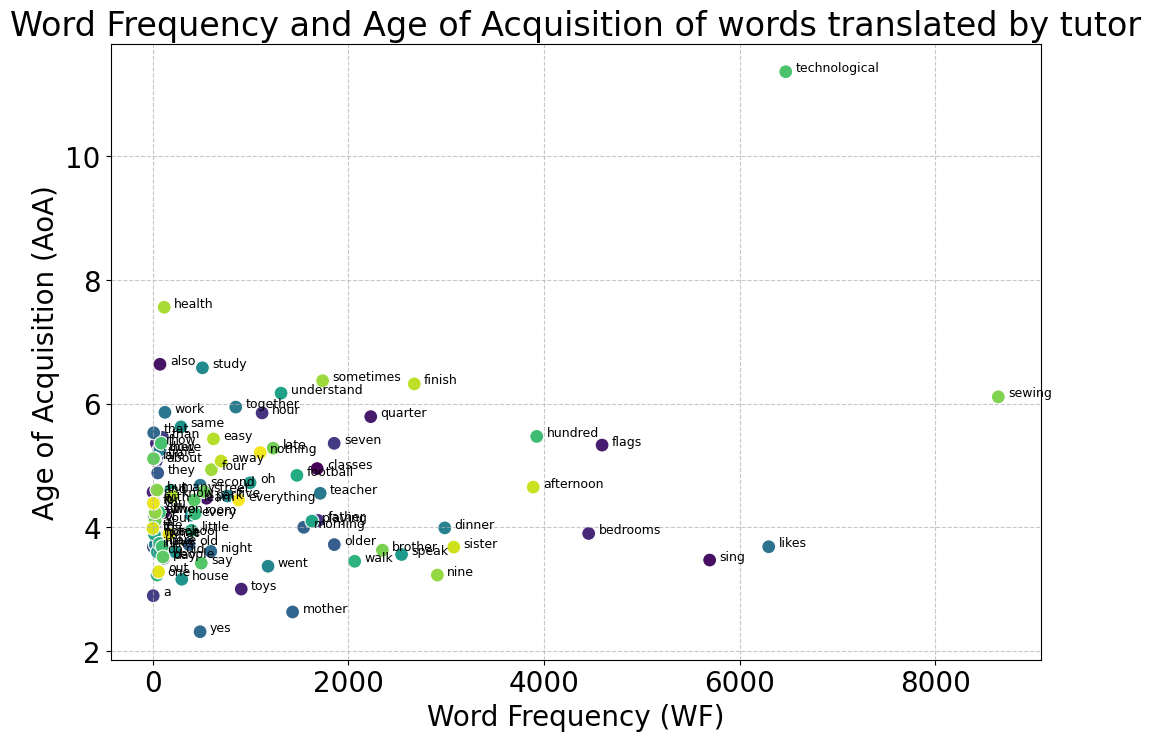

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with NaN values for better visualisation
translated_words_stats_df_clean = translated_words_stats_df.dropna()

# Thresholds for outliers for better visualisation
wf_threshold = 10000
aoa_threshold = 15

outliers = translated_words_stats_df_clean[
    (translated_words_stats_df_clean["WF"] > wf_threshold)
    | (translated_words_stats_df_clean["AoA"] > aoa_threshold)
]

# Saving outlier coordinates
outlier_coordinates = outliers[["Word", "WF", "AoA"]]
print("Outlier Coordinates:")
print(outlier_coordinates)

# Removing outliers from the dataset
translated_words_stats_df_zoomed = translated_words_stats_df_clean[
    (translated_words_stats_df_clean["WF"] <= wf_threshold)
    & (translated_words_stats_df_clean["AoA"] <= aoa_threshold)
]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=translated_words_stats_df_zoomed,
    x="WF",
    y="AoA",
    hue="Word",
    palette="viridis",
    s=100,
    legend=False,
)

plt.xlabel("Word Frequency (WF)")
plt.ylabel("Age of Acquisition (AoA)")
plt.title("Word Frequency and Age of Acquisition of words translated by tutor")
plt.grid(True, linestyle="--", alpha=0.7)
for i in range(translated_words_stats_df_zoomed.shape[0]):
    plt.text(
        translated_words_stats_df_zoomed["WF"].iloc[i] + 100,
        translated_words_stats_df_zoomed["AoA"].iloc[i],
        translated_words_stats_df_zoomed["Word"].iloc[i],
        fontsize=9,
    )

plt.show()

In [177]:
translated_words_stats_df_clean

,Word,AoA,WF
0,classes,4.950000,1680
1,two,4.239515,115
2,with,4.441998,12
3,sing,3.470000,5693
4,also,6.637340,73
...,...,...,...
105,school,3.890000,164
106,out,3.280385,59
107,for,4.388713,6
108,nothing,5.209302,1098


In [178]:
avg_translated_aoa = translated_words_stats_df_clean["AoA"].mean()
avg_translated_wf = translated_words_stats_df_clean["WF"].mean()

print(f"Average Age of Acquisition for translated words: {avg_translated_aoa:.2f}")
print(f"Average Word Frequency for translated words: {avg_translated_wf:.2f}")

Average Age of Acquisition for translated words: 4.68
Average Word Frequency for translated words: 2306.77


In [179]:
all_english_words = set(
    [word for words in master_df["MatrixLangWords"] for word in words.split()]
)  # finding all English words in the dataset

In [180]:
# Calculate mean AoA and WF for all English word tokens for comparison

english_words_stats = [
    {
        "Word": word,
        "AoA": (
            AoA_list[AoA_list["Word"] == word]["AoA_Kup_lem"].values[0]
            if word in AoA_list["Word"].values
            else None
        ),
        "WF": (
            WF_list_billion.index[WF_list_billion["word"] == word].tolist()[0]
            if word in WF_list_billion["word"].values
            else None
        ),
    }
    for word in all_english_words
]

In [181]:
all_english_words_stats_df = pd.DataFrame(english_words_stats)
all_english_words_stats_df_clean = all_english_words_stats_df.dropna()

avg_english_aoa = all_english_words_stats_df_clean["AoA"].mean()
avg_english_wf = all_english_words_stats_df_clean["WF"].mean()

print(f"Average Age of Acquisition for all English words: {avg_english_aoa:.2f}")
print(f"Average Word Frequency for all English words: {avg_english_wf:.2f}")

Average Age of Acquisition for all English words: 5.85
Average Word Frequency for all English words: 4577.21


In [182]:
all_english_words_stats_df_clean

,Word,AoA,WF
0,science,7.320000,439.0
2,minutes,7.260000,831.0
3,hello,3.759950,2419.0
4,must,4.580000,217.0
5,photography,7.840000,1499.0
...,...,...,...
1669,school,3.890000,164.0
1670,helped,3.650000,3562.0
1672,bed,2.890000,1259.0
1674,around,5.944635,425.0


In [183]:
translated_words_stats_df_clean

,Word,AoA,WF
0,classes,4.950000,1680
1,two,4.239515,115
2,with,4.441998,12
3,sing,3.470000,5693
4,also,6.637340,73
...,...,...,...
105,school,3.890000,164
106,out,3.280385,59
107,for,4.388713,6
108,nothing,5.209302,1098


## First, AoA only analysis


In [184]:
english_aoa_only = all_english_words_stats_df_clean[["Word", "AoA"]]
translated_aoa_only = translated_words_stats_df_clean[["Word", "AoA"]]


--- Counts and Percentages per Bin ---
                all_count  translated_count  percentage_translated
(2.29, 3.63]          135                19              14.074074
(3.63, 4.96]          342                51              14.912281
(4.96, 6.28]          284                25               8.802817
(6.28, 7.6]           175                 6               3.428571
(7.6, 8.92]            99                 0               0.000000
(8.92, 10.25]          51                 0               0.000000
(10.25, 11.57]         25                 1               4.000000
(11.57, 12.89]         17                 0               0.000000
(12.89, 14.21]          6                 0               0.000000
(14.21, 15.54]          7                 1              14.285714
------------------------------


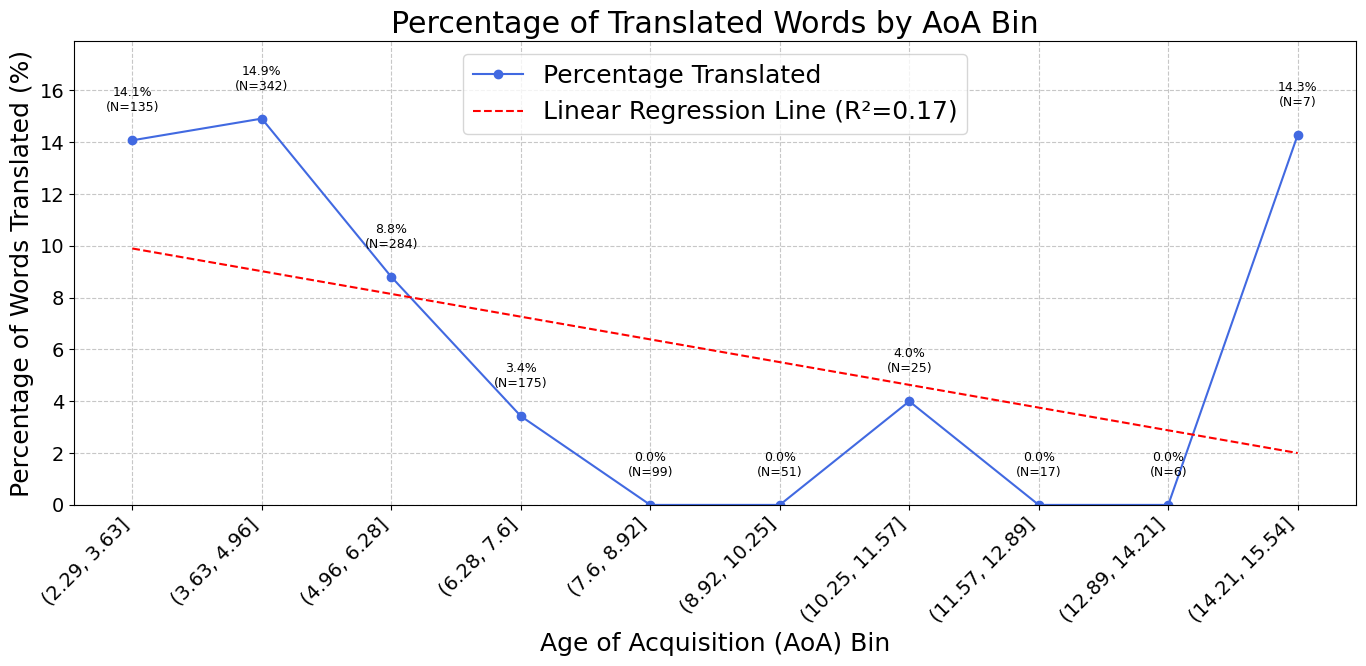

In [ ]:
# Translated word proportion calculation

import pandas as pd


import matplotlib.pyplot as plt


import numpy as np


from scipy.stats import (
    linregress,
)



# binning AoA values



num_bins = 10



plt.rcParams.update({"font.size": 18})



try:

    english_aoa_only["AoA_bin"], bins = pd.cut(
        english_aoa_only["AoA"],
        bins=num_bins,

        precision=2,
        retbins=True,
        include_lowest=True,
    )


    translated_aoa_only["AoA_bin"] = pd.cut(
        translated_aoa_only["AoA"], bins=bins, precision=2, include_lowest=True
    )


    bin_labels = english_aoa_only["AoA_bin"].cat.categories.astype(str)



except ValueError as e:

    print(f"Error creating bins: {e}")

    print("This might happen if AoA range is too small or num_bins is too high.")


except Exception as e:

    print(f"An unexpected error occurred during binning: {e}")


# count values within bins

all_counts = (

    english_aoa_only.groupby("AoA_bin", observed=False).size().rename("all_count")
)
translated_counts = (

    translated_aoa_only.groupby("AoA_bin", observed=False)
    .size()
    .rename("translated_count")
)



# Combine the counts into a single DataFrame


comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")



comparison_df = comparison_df.reindex(english_aoa_only["AoA_bin"].cat.categories)


comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)



comparison_df["all_count"] = comparison_df["all_count"].fillna(0)



# percentage of transalted words calculated


comparison_df["percentage_translated"] = comparison_df.apply(

    lambda row: (

        (row["translated_count"] / row["all_count"] * 100)
        if row["all_count"] > 0
        else 0
    ),

    axis=1,
)



print("\n--- Counts and Percentages per Bin ---")
print(comparison_df)



print("-" * 30)



plt.figure(figsize=(14, 7))



x_labels = comparison_df.index.astype(str)


x_values = np.arange(len(comparison_df))

plt.plot(

    x_values,
    comparison_df["percentage_translated"],
    marker="o",
    linestyle="-",
    color="royalblue",
    label="Percentage Translated",
)



slope, intercept, r_value, p_value, std_err = linregress(
    x_values, comparison_df["percentage_translated"]
)



regression_line = slope * x_values + intercept

plt.plot(

    x_values,
    regression_line,
    color="red",

    linestyle="--",

    label=f"Linear Regression Line (R²={r_value**2:.2f})",
)



for i, row in comparison_df.iterrows():

    x_pos = x_values[comparison_df.index.get_loc(i)]

    y_pos = row["percentage_translated"]

    annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"

    plt.text(x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9)



plt.xlabel("Age of Acquisition (AoA) Bin")


plt.ylabel("Percentage of Words Translated (%)")


plt.title("Percentage of Translated Words by AoA Bin")



plt.yticks(fontsize=14)


plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)



plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)



plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.legend()



plt.tight_layout()


plt.show()

In [186]:
translated_words_stats_df_clean["WF"].describe()

count      103.000000
mean      2306.766990
std       7280.401254
min          0.000000
25%         52.500000
50%        432.000000
75%       1685.500000
max      60547.000000
Name: WF, dtype: float64

### Same analysis for Word Frequency


In [187]:
english_wf_only = all_english_words_stats_df_clean[["Word", "WF"]]
translated_wf_only = translated_words_stats_df_clean[["Word", "WF"]]

In [188]:
translated_wf_only.sort_values("WF", ascending=False).head(10)

,Word,WF
53,philology,60547
60,hairdresser,38727
20,sixteen,12988
91,grandmother,12145
80,shelves,10686
90,sewing,8644
79,technological,6471
40,likes,6297
3,sing,5693
7,flags,4593


In [189]:
english_wf_only.sort_values("WF", ascending=False).head(10)

,Word,WF
939,foots,105281.0
1545,discotheques,104475.0
1068,swimmingpool,100706.0
1100,splay,88023.0
1494,curs,82245.0
1410,discotheque,72283.0
1337,grandfathers,66799.0
759,spaceships,64570.0
983,philology,60547.0
1129,armchairs,57391.0



--- Counts and Percentages per Bin ---
                     all_count  translated_count  percentage_translated
(-105.29, 10528.1]        1027                98               9.542356
(10528.1, 21056.2]          73                 3               4.109589
(21056.2, 31584.3]          17                 0               0.000000
(31584.3, 42112.4]           7                 1              14.285714
(42112.4, 52640.5]           7                 0               0.000000
(52640.5, 63168.6]           2                 1              50.000000
(63168.6, 73696.7]           3                 0               0.000000
(73696.7, 84224.8]           1                 0               0.000000
(84224.8, 94752.9]           1                 0               0.000000
(94752.9, 105281.0]          3                 0               0.000000
------------------------------


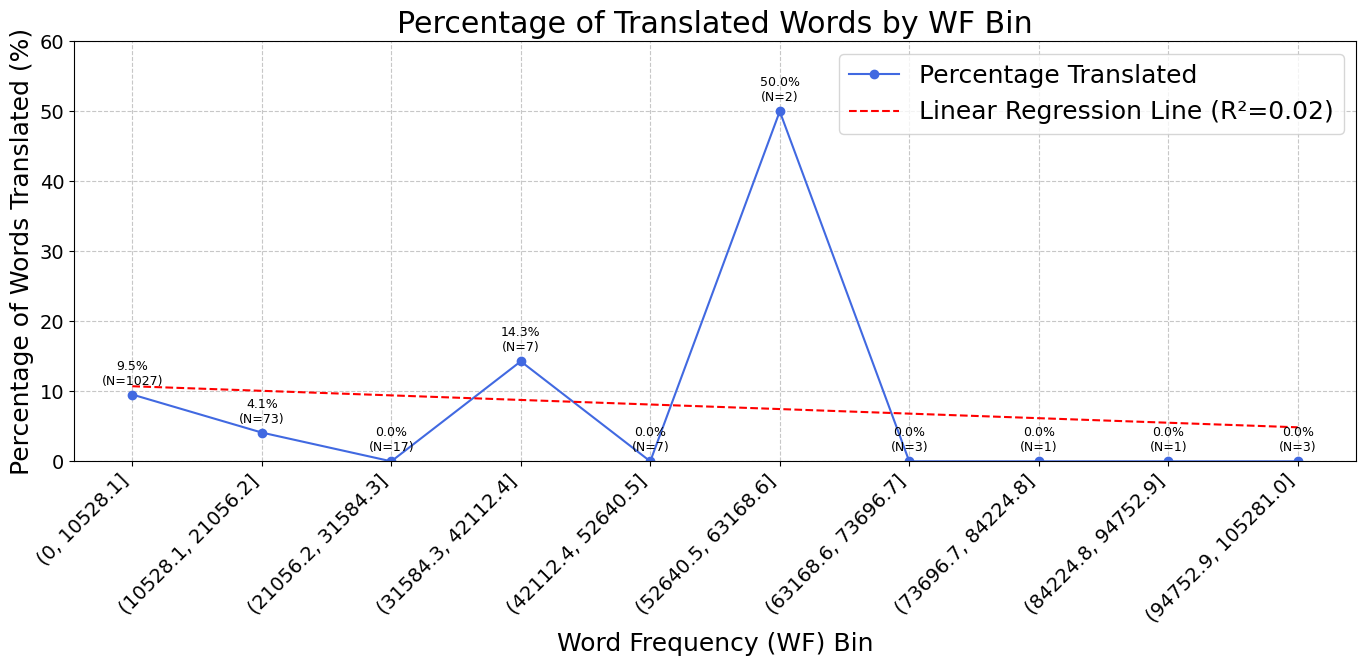

In [190]:
num_bins = 10

try:
    english_wf_only["WF_bin"], bins = pd.cut(
        english_wf_only["WF"],
        bins=num_bins,
        precision=2,
        retbins=True,
        include_lowest=True,
    )
    translated_wf_only["WF_bin"] = pd.cut(
        translated_wf_only["WF"], bins=bins, precision=2, include_lowest=True
    )
    bin_labels = english_wf_only["WF_bin"].cat.categories.astype(str)

except ValueError as e:
    print(f"Error creating bins: {e}")
    print("This might happen if WF range is too small or num_bins is too high.")
except Exception as e:
    print(f"An unexpected error occurred during binning: {e}")

all_counts = (
    english_wf_only.groupby("WF_bin", observed=False).size().rename("all_count")
)
translated_counts = (
    translated_wf_only.groupby("WF_bin", observed=False)
    .size()
    .rename("translated_count")
)

comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")

comparison_df = comparison_df.reindex(english_wf_only["WF_bin"].cat.categories)
comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)
comparison_df["all_count"] = comparison_df["all_count"].fillna(0)

comparison_df["percentage_translated"] = comparison_df.apply(
    lambda row: (
        (row["translated_count"] / row["all_count"] * 100)
        if row["all_count"] > 0
        else 0
    ),
    axis=1,
)
print("\n--- Counts and Percentages per Bin ---")
print(comparison_df)
print("-" * 30)

plt.figure(figsize=(14, 7))

x_labels = comparison_df.index.astype(str)
x_values = np.arange(len(comparison_df))

x_labels = list(x_labels)
x_labels[0] = x_labels[0].replace("-105.29", "0")

plt.plot(
    x_values,
    comparison_df["percentage_translated"],
    marker="o",
    linestyle="-",
    color="royalblue",
    label="Percentage Translated",
)

slope, intercept, r_value, p_value, std_err = linregress(
    x_values, comparison_df["percentage_translated"]
)

regression_line = slope * x_values + intercept

plt.plot(
    x_values,
    regression_line,
    color="red",
    linestyle="--",
    label=f"Linear Regression Line (R²={r_value**2:.2f})",
)

for i, row in comparison_df.iterrows():
    x_pos = x_values[comparison_df.index.get_loc(i)]
    y_pos = row["percentage_translated"]
    annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"
    plt.text(x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9)


plt.xlabel("Word Frequency (WF) Bin")
plt.ylabel("Percentage of Words Translated (%)")
plt.title("Percentage of Translated Words by WF Bin")
plt.yticks(fontsize=14)
plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)
plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [191]:
# Cutting outliers and plotting again

english_wf_only_cut = english_wf_only[english_wf_only["WF"] <= 21056.2]


translated_wf_only_cut = translated_wf_only[translated_wf_only["WF"] <= 21056.2]

In [192]:
translated_wf_only_cut.sort_values("WF", ascending=False).head(10)

,Word,WF,WF_bin
20,sixteen,12988,"(10528.1, 21056.2]"
91,grandmother,12145,"(10528.1, 21056.2]"
80,shelves,10686,"(10528.1, 21056.2]"
90,sewing,8644,"(-105.29, 10528.1]"
79,technological,6471,"(-105.29, 10528.1]"
40,likes,6297,"(-105.29, 10528.1]"
3,sing,5693,"(-105.29, 10528.1]"
7,flags,4593,"(-105.29, 10528.1]"
11,bedrooms,4456,"(-105.29, 10528.1]"
76,hundred,3925,"(-105.29, 10528.1]"



--- Counts and Percentages per Bin ---
                               all_count  translated_count  \
(-20.650000000000002, 2064.4]        630                83   
(2064.4, 4128.8]                     202                 9   
(4128.8, 6193.2]                     101                 3   
(6193.2, 8257.6]                      50                 2   
(8257.6, 10322.0]                     40                 1   
(10322.0, 12386.4]                    27                 2   
(12386.4, 14450.8]                    16                 1   
(14450.8, 16515.2]                    14                 0   
(16515.2, 18579.6]                    15                 0   
(18579.6, 20644.0]                     5                 0   

                               percentage_translated  
(-20.650000000000002, 2064.4]              13.174603  
(2064.4, 4128.8]                            4.455446  
(4128.8, 6193.2]                            2.970297  
(6193.2, 8257.6]                            4.000000  
(8

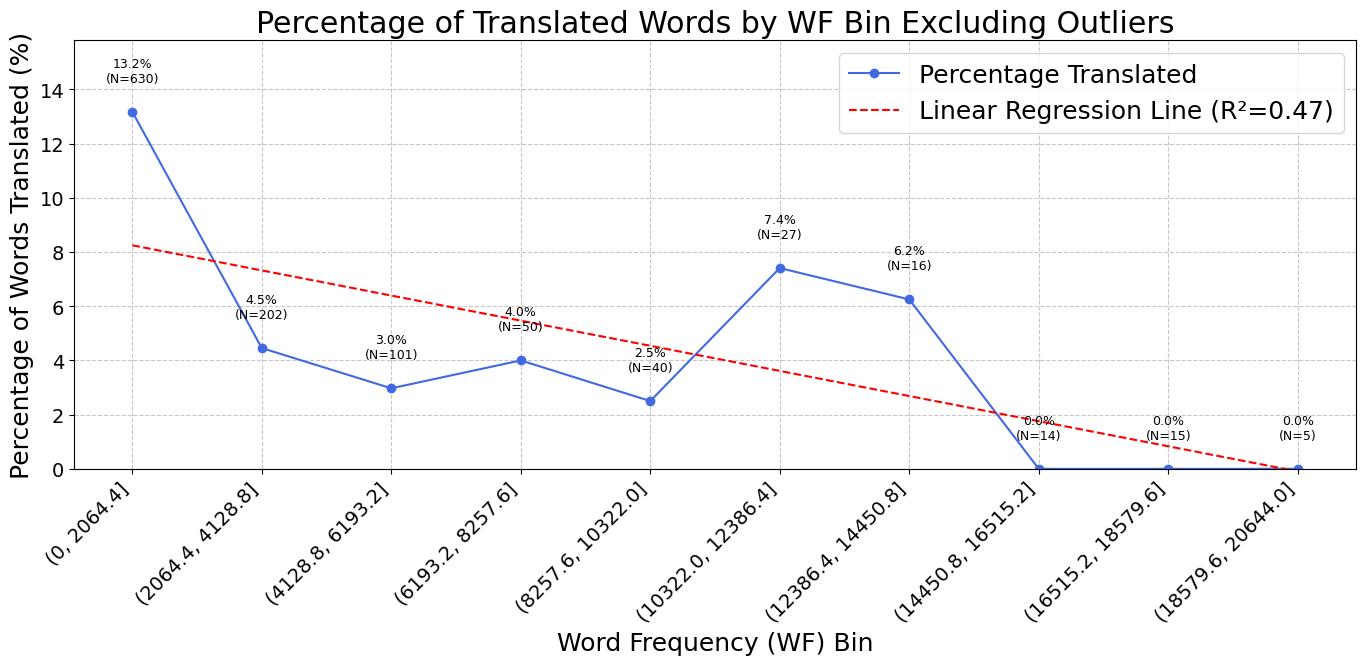

In [ ]:
num_bins = 10


try:

    english_wf_only_cut["WF_bin"], bins = pd.cut(
        english_wf_only_cut["WF"],
        bins=num_bins,
        precision=2,
        retbins=True,
        include_lowest=True,
    )


    translated_wf_only_cut["WF_bin"] = pd.cut(
        translated_wf_only_cut["WF"], bins=bins, precision=2, include_lowest=True
    )


    bin_labels = english_wf_only_cut["WF_bin"].cat.categories.astype(str)



except ValueError as e:

    print(f"Error creating bins: {e}")


    print("This might happen if WF range is too small or num_bins is too high.")


except Exception as e:

    print(f"An unexpected error occurred during binning: {e}")

all_counts = (

    english_wf_only_cut.groupby("WF_bin", observed=False).size().rename("all_count")
)
translated_counts = (

    translated_wf_only_cut.groupby("WF_bin", observed=False)
    .size()
    .rename("translated_count")
)



comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")



comparison_df = comparison_df.reindex(english_wf_only_cut["WF_bin"].cat.categories)


comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)



comparison_df["all_count"] = comparison_df["all_count"].fillna(0)



comparison_df["percentage_translated"] = comparison_df.apply(
    lambda row: (
        (row["translated_count"] / row["all_count"] * 100)
        if row["all_count"] > 0
        else 0
    ),

    axis=1,
)



print("\n--- Counts and Percentages per Bin ---")


print(comparison_df)


print("-" * 30)



plt.figure(figsize=(14, 7))



x_labels = comparison_df.index.astype(str)


x_values = np.arange(len(comparison_df))



x_labels = list(x_labels)


x_labels[0] = x_labels[0].replace("-20.650000000000002", "0")

plt.plot(

    x_values,
    comparison_df["percentage_translated"],
    marker="o",
    linestyle="-",
    color="royalblue",
    label="Percentage Translated",
)



slope, intercept, r_value, p_value, std_err = linregress(
    x_values, comparison_df["percentage_translated"]
)



regression_line = slope * x_values + intercept

plt.plot(

    x_values,
    regression_line,
    color="red",

    linestyle="--",
    label=f"Linear Regression Line (R²={r_value**2:.2f})",
)



for i, row in comparison_df.iterrows():

    x_pos = x_values[comparison_df.index.get_loc(i)]


    y_pos = row["percentage_translated"]


    annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"

    plt.text(x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9)



plt.xlabel("Word Frequency (WF) Bin")


plt.ylabel("Percentage of Words Translated (%)")


plt.title("Percentage of Translated Words by WF Bin Excluding Outliers")


plt.yticks(fontsize=14)


plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)



plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)



plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.legend()



plt.tight_layout()


plt.show()

In [194]:
translated_words_stats_df_clean["WF"].max()

np.int64(60547)

In [195]:
translated_words_stats_df_clean.sort_values(by="WF")

,Word,AoA,WF
104,the,3.983747,0
8,and,4.569882,2
27,to,3.951776,3
18,a,2.893384,4
24,in,3.685351,5
...,...,...,...
80,shelves,5.500000,10686
91,grandmother,3.670000,12145
20,sixteen,4.804336,12988
60,hairdresser,6.650000,38727


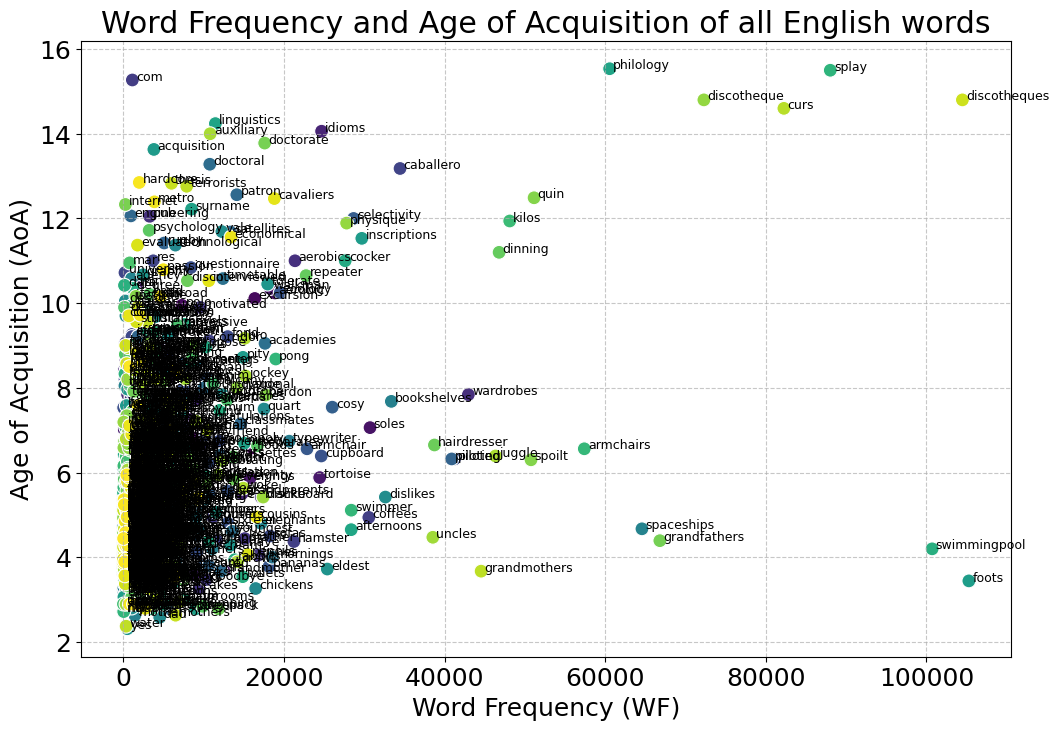

In [196]:
# Plotting WF and AoA of all English words

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=all_english_words_stats_df_clean,
    x="WF",
    y="AoA",
    hue="Word",
    palette="viridis",
    s=100,
    legend=False,
)

plt.xlabel("Word Frequency (WF)")
plt.ylabel("Age of Acquisition (AoA)")
plt.title("Word Frequency and Age of Acquisition of all English words")

for i in range(all_english_words_stats_df_clean.shape[0]):
    plt.text(
        all_english_words_stats_df_clean["WF"].iloc[i] + 450,
        all_english_words_stats_df_clean["AoA"].iloc[i],
        all_english_words_stats_df_clean["Word"].iloc[i],
        fontsize=9,
    )
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Translated words grouped by level


In [197]:
translated_into_catalan_examples_by_level = {}
for proficiency, group in all_tutor_catalan_switched_utts_grouped:

    # Finding translations in each level - into Catalan

    print(f"Proficiency Level: {proficiency}")
    print(
        f"Number of tutor Catalan CS utterances: {len(group)}\n"
        f"Number of tutor English CS utterances: {len(all_tutor_eng_switched_utts_grouped.get_group(proficiency))}"
    )
    translated_into_catalan_examples = []
    for i, utt in group.iterrows():
        if utt["PrevTurn"] and utt["PrevTurnTrans"] is not None:
            student_tokens = set(tokenize_and_preprocess(utt["PrevTurn"]))
            tutor_tokens = set(tokenize_and_preprocess(utt["Turn"]))
            student_trans_tokens = set(
                tokenize_and_preprocess(utt["PrevTurnTrans"], english=True)
            )
            tutor_trans_tokens = set(
                tokenize_and_preprocess(utt["TurnTranslation"], english=True)
            )

            words_translated_by_tutor = tutor_trans_tokens.intersection(
                student_tokens
            ).difference(tutor_tokens)

            if words_translated_by_tutor:
                translated_into_catalan_examples.append(
                    {
                        "Tutor turn": utt["Turn"],
                        "Tutor translated turn": utt["TurnTranslation"],
                        "Student turn": utt["PrevTurn"],
                        "Student translated turn": utt["PrevTurnTrans"],
                        "Translated words": words_translated_by_tutor,
                        "Translated into": "Catalan",
                    }
                )

    translated_into_catalan_examples = pd.DataFrame(translated_into_catalan_examples)
    translated_into_catalan_examples_by_level[proficiency] = (
        translated_into_catalan_examples
    )

Proficiency Level: 1
Number of tutor Catalan CS utterances: 160
Number of tutor English CS utterances: 416
Proficiency Level: 2
Number of tutor Catalan CS utterances: 144
Number of tutor English CS utterances: 585
Proficiency Level: 3
Number of tutor Catalan CS utterances: 21
Number of tutor English CS utterances: 106
Proficiency Level: 4
Number of tutor Catalan CS utterances: 4
Number of tutor English CS utterances: 73


In [198]:
translated_into_english_examples_by_level = {}
for proficiency, group in all_tutor_eng_switched_utts_grouped:

    # Finding translations in each level - into English

    print(f"Proficiency Level: {proficiency}")
    print(
        f"Number of tutor English CS utterances: {len(group)}\n"
        f"Number of tutor Catalan CS utterances: {len(all_tutor_catalan_switched_utts_grouped.get_group(proficiency))}"
    )

    translated_into_english_examples = []
    for i, utt in group.iterrows():
        if utt["PrevTurn"] and utt["PrevTurnTrans"] is not None:
            student_tokens = set(tokenize_and_preprocess(utt["PrevTurn"]))
            tutor_tokens = set(tokenize_and_preprocess(utt["Turn"]))
            student_trans_tokens = set(
                tokenize_and_preprocess(utt["PrevTurnTrans"], english=True)
            )
            tutor_trans_tokens = set(
                tokenize_and_preprocess(utt["TurnTranslation"], english=True)
            )

            words_translated_by_tutor = student_trans_tokens.intersection(
                tutor_tokens
            ).difference(student_tokens)
            if words_translated_by_tutor:
                translated_into_english_examples.append(
                    {
                        "Tutor turn": utt["Turn"],
                        "Tutor translated turn": utt["TurnTranslation"],
                        "Student turn": utt["PrevTurn"],
                        "Student translated turn": utt["PrevTurnTrans"],
                        "Translated words": words_translated_by_tutor,
                        "Translated into": "English",
                    }
                )

    translated_into_english_examples = pd.DataFrame(translated_into_english_examples)
    translated_into_english_examples_by_level[proficiency] = (
        translated_into_english_examples
    )

Proficiency Level: 1
Number of tutor English CS utterances: 416
Number of tutor Catalan CS utterances: 160
Proficiency Level: 2
Number of tutor English CS utterances: 585
Number of tutor Catalan CS utterances: 144
Proficiency Level: 3
Number of tutor English CS utterances: 106
Number of tutor Catalan CS utterances: 21
Proficiency Level: 4
Number of tutor English CS utterances: 73
Number of tutor Catalan CS utterances: 4


In [ ]:
# concatenating

all_translated_examples_by_level = {

    proficiency: pd.concat([catalan, english], ignore_index=True)
    for proficiency, (catalan, english) in zip(
        translated_into_catalan_examples_by_level.keys(),
        zip(
            translated_into_catalan_examples_by_level.values(),
            translated_into_english_examples_by_level.values(),
        ),
    )

}

In [200]:
all_translated_words_by_level = {
    proficiency: set([word for words in df["Translated words"] for word in words])
    for proficiency, df in all_translated_examples_by_level.items()
}
for proficiency, words in all_translated_words_by_level.items():
    print(
        f"Proficiency Level: {proficiency}, Total number of unique translated words: {len(words)}"
    )

Proficiency Level: 1, Total number of unique translated words: 56
Proficiency Level: 2, Total number of unique translated words: 65
Proficiency Level: 3, Total number of unique translated words: 20
Proficiency Level: 4, Total number of unique translated words: 17


In [201]:
translated_words_stats_by_level = {
    proficiency: pd.DataFrame(
        [
            {
                "Word": word,
                "AoA": (
                    AoA_list[AoA_list["Word"] == word]["AoA_Kup_lem"].values[0]
                    if word in AoA_list["Word"].values
                    else None
                ),
                "WF": (
                    WF_list_billion.index[WF_list_billion["word"] == word].tolist()[0]
                    if word in WF_list_billion["word"].values
                    else None
                ),
            }
            for word in words
        ]
    )
    for proficiency, words in all_translated_words_by_level.items()
}
translated_words_stats_by_level[1].head()

,Word,AoA,WF
0,now,5.251930,74
1,catalan,NaN,19300
2,to,3.951776,3
3,have,3.720000,25
4,twenty,NaN,3548


Outlier Coordinates:
Empty DataFrame
Columns: [Word, WF, AoA]
Index: []


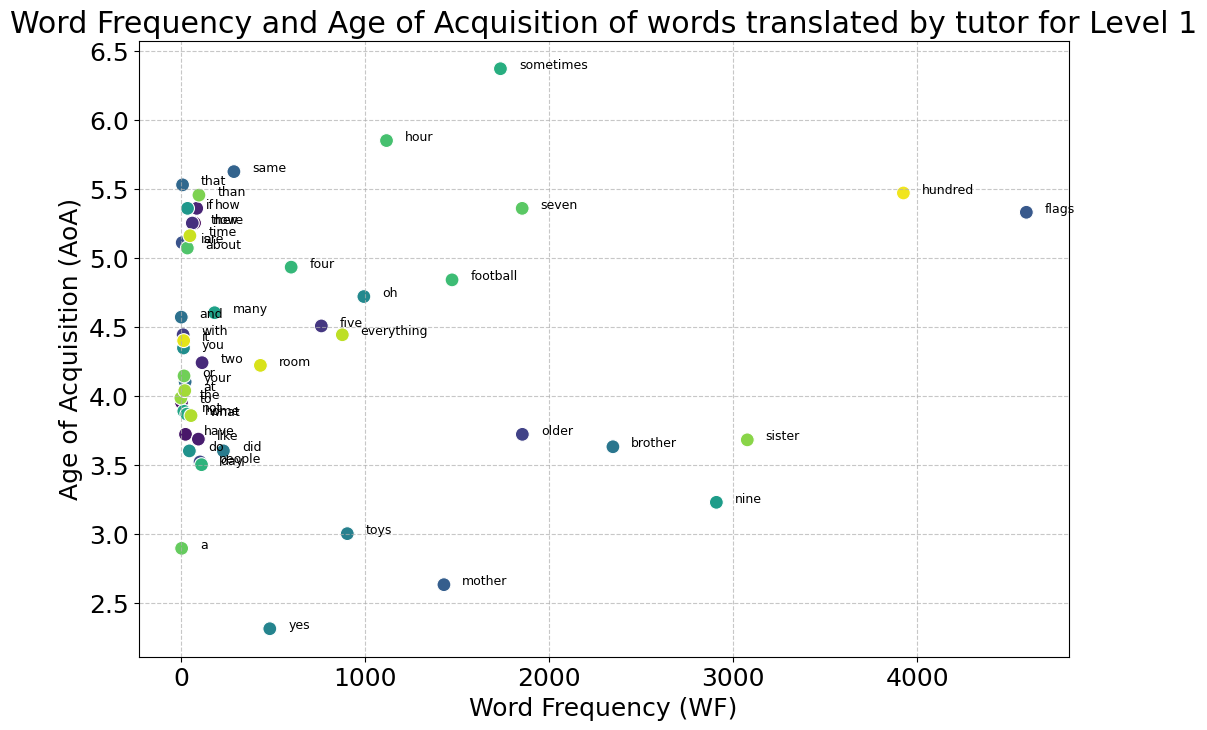

Outlier Coordinates:
           Word     WF       AoA
22  hairdresser  38727  6.650000
25  grandmother  12145  3.670000
47      sixteen  12988  4.804336


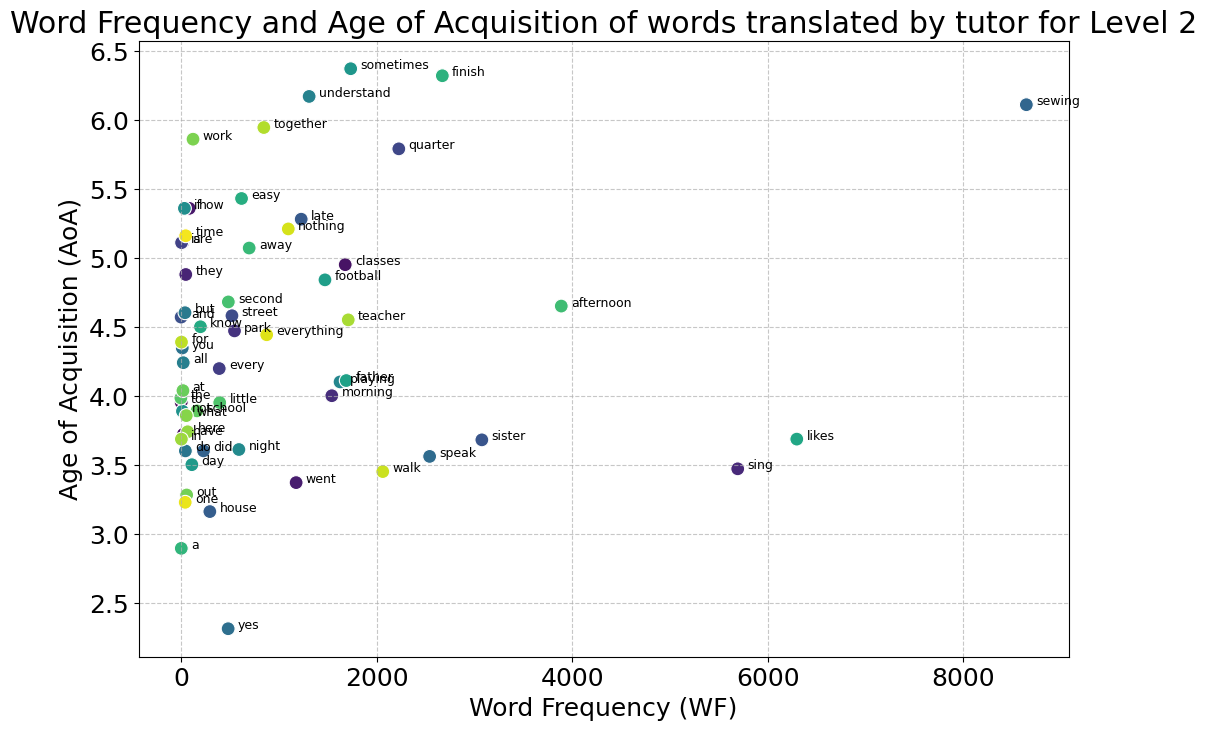

Outlier Coordinates:
        Word     WF        AoA
3    shelves  10686   5.500000
7  philology  60547  15.535935


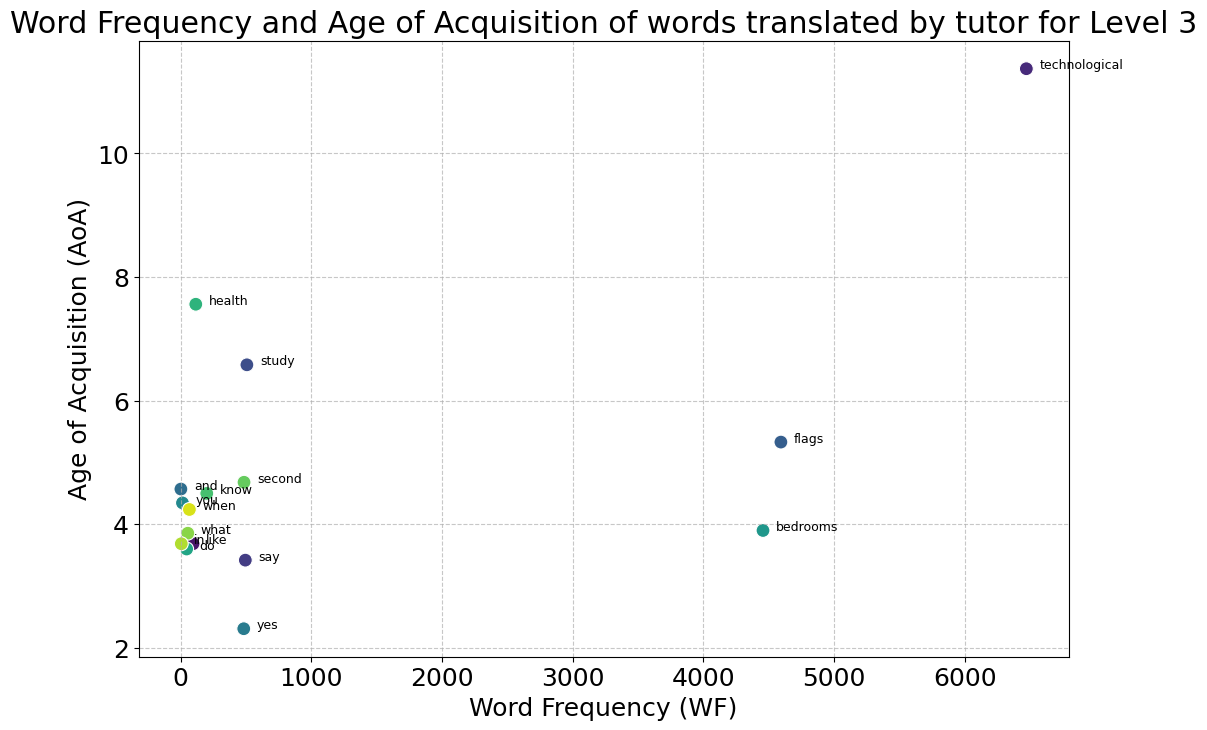

Outlier Coordinates:
Empty DataFrame
Columns: [Word, WF, AoA]
Index: []


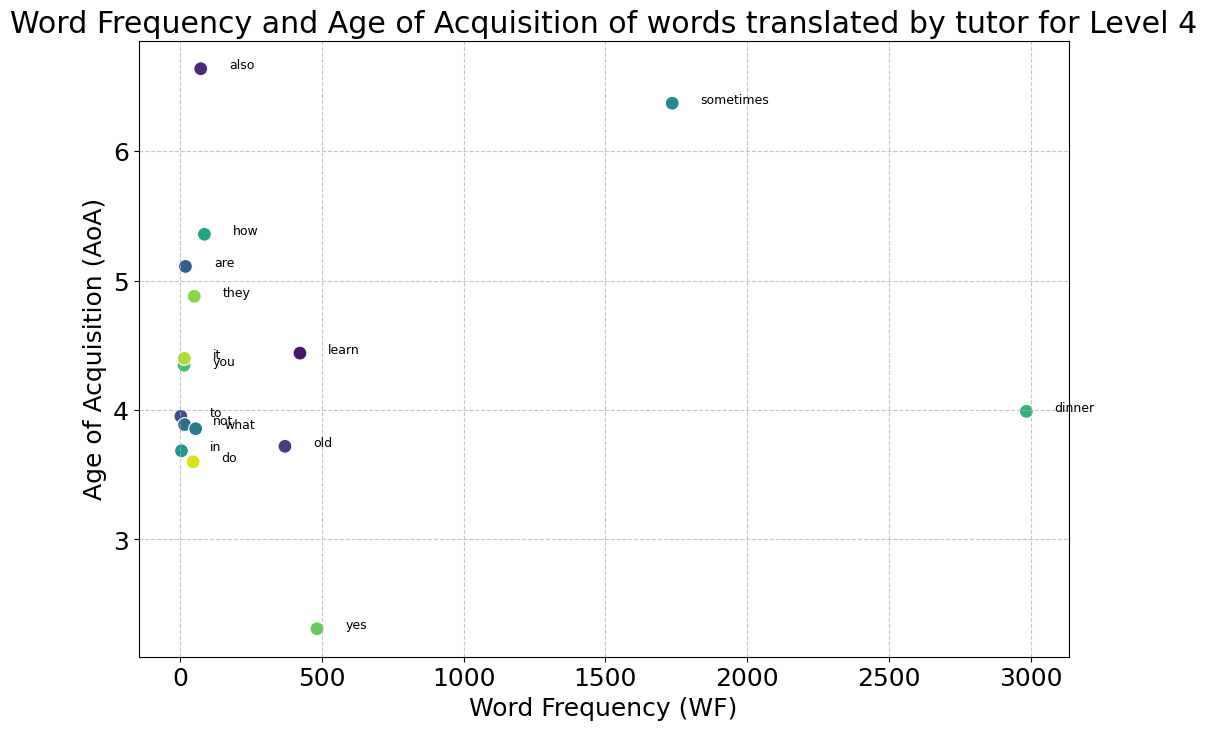

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

# plotting AoA and WF of translated words by proficiency level

for proficiency, group_df in translated_words_stats_by_level.items():
    translated_words_stats_df_clean = group_df.dropna()

    # Define thresholds for outliers
    wf_threshold = 10000  # Adjust this value based on your data
    aoa_threshold = 15  # Adjust this value based on your data

    # Identify outliers
    outliers = translated_words_stats_df_clean[
        (translated_words_stats_df_clean["WF"] > wf_threshold)
        | (translated_words_stats_df_clean["AoA"] > aoa_threshold)
    ]

    # Save outlier coordinates
    outlier_coordinates = outliers[["Word", "WF", "AoA"]]
    print("Outlier Coordinates:")
    print(outlier_coordinates)

    # Remove outliers from the dataset
    translated_words_stats_df_zoomed = translated_words_stats_df_clean[
        (translated_words_stats_df_clean["WF"] <= wf_threshold)
        & (translated_words_stats_df_clean["AoA"] <= aoa_threshold)
    ]

    # Set the figure size
    plt.figure(figsize=(12, 8))

    # Create a scatter plot without outliers
    sns.scatterplot(
        data=translated_words_stats_df_zoomed,
        x="WF",
        y="AoA",
        hue="Word",
        palette="viridis",
        s=100,
        legend=False,
    )

    # Add labels and title
    plt.xlabel("Word Frequency (WF)")
    plt.ylabel("Age of Acquisition (AoA)")
    plt.title(
        "Word Frequency and Age of Acquisition of words translated by tutor for Level "
        + str(proficiency)
    )
    plt.grid(True, linestyle="--", alpha=0.7)
    # Annotate each point with the word
    for i in range(translated_words_stats_df_zoomed.shape[0]):
        plt.text(
            translated_words_stats_df_zoomed["WF"].iloc[i] + 100,
            translated_words_stats_df_zoomed["AoA"].iloc[i],
            translated_words_stats_df_zoomed["Word"].iloc[i],
            fontsize=9,
        )

    # Show the plot
    plt.show()

In [203]:
for proficiency, group in translated_words_stats_by_level.items():
    avg_translated_aoa = group["AoA"].mean()
    avg_translated_wf = group["WF"].mean()
    print(f"Proficiency Level: {proficiency}")
    print(f"Average Age of Acquisition for translated words: {avg_translated_aoa:.2f}")
    print(f"Average Word Frequency for translated words: {avg_translated_wf:.2f}\n")

Proficiency Level: 1
Average Age of Acquisition for translated words: 4.39
Average Word Frequency for translated words: 1321.86

Proficiency Level: 2
Average Age of Acquisition for translated words: 4.43
Average Word Frequency for translated words: 1958.49

Proficiency Level: 3
Average Age of Acquisition for translated words: 5.48
Average Word Frequency for translated words: 4489.10

Proficiency Level: 4
Average Age of Acquisition for translated words: 4.41
Average Word Frequency for translated words: 376.00



In [204]:
# All english words by proficiency level
master_df_grouped = master_df.groupby("Proficiency")
all_english_words_by_level = {
    proficiency: set(
        [word for words in df["MatrixLangWords"] for word in words.split()]
    )
    for proficiency, df in master_df_grouped
}

In [205]:
english_words_stats_by_level = {
    proficiency: pd.DataFrame(
        [
            {
                "Word": word,
                "AoA": (
                    AoA_list[AoA_list["Word"] == word]["AoA_Kup_lem"].values[0]
                    if word in AoA_list["Word"].values
                    else None
                ),
                "WF": (
                    WF_list_billion.index[WF_list_billion["word"] == word].tolist()[0]
                    if word in WF_list_billion["word"].values
                    else None
                ),
            }
            for word in words
        ]
    )
    for proficiency, words in all_english_words_by_level.items()
}

In [206]:
english_words_stats_by_level_clean = {
    proficiency: group.dropna()
    for proficiency, group in english_words_stats_by_level.items()
}
for proficiency, group in english_words_stats_by_level_clean.items():
    avg_english_aoa = group["AoA"].mean()
    avg_english_wf = group["WF"].mean()
    print(f"Proficiency Level: {proficiency}")
    print(f"Average Age of Acquisition for all English words: {avg_english_aoa:.2f}")
    print(f"Average Word Frequency for all English words: {avg_english_wf:.2f}\n")

Proficiency Level: 1
Average Age of Acquisition for all English words: 4.99
Average Word Frequency for all English words: 2776.24

Proficiency Level: 2
Average Age of Acquisition for all English words: 5.45
Average Word Frequency for all English words: 3564.66

Proficiency Level: 3
Average Age of Acquisition for all English words: 5.58
Average Word Frequency for all English words: 3589.06

Proficiency Level: 4
Average Age of Acquisition for all English words: 5.53
Average Word Frequency for all English words: 2816.00




--- Counts and Percentages per Bin ---
                all_count  translated_count  percentage_translated
(2.29, 3.3]            41                 5              12.195122
(3.3, 4.29]           139                19              13.669065
(4.29, 5.28]          111                16              14.414414
(5.28, 6.27]           85                 9              10.588235
(6.27, 7.27]           40                 1               2.500000
(7.27, 8.26]           18                 0               0.000000
(8.26, 9.25]           10                 0               0.000000
(9.25, 10.24]           4                 0               0.000000
(10.24, 11.23]          4                 0               0.000000
(11.23, 12.22]          2                 0               0.000000
------------------------------


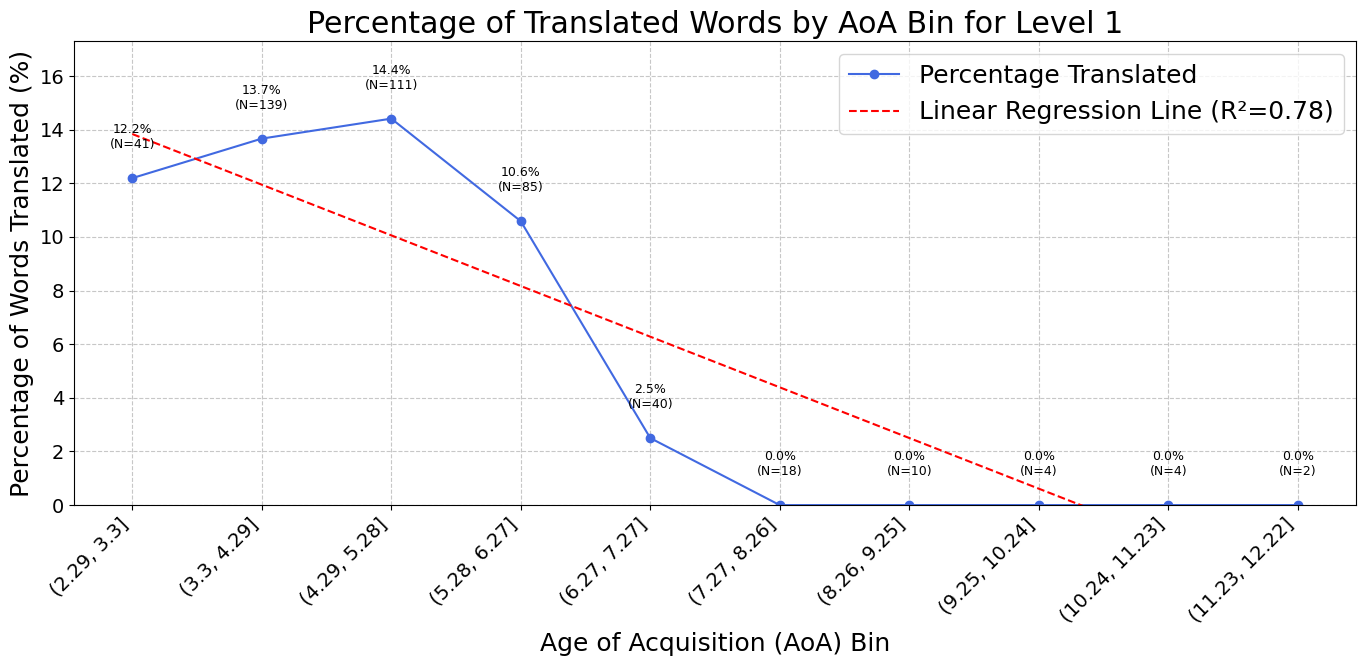


--- Counts and Percentages per Bin ---
                all_count  translated_count  percentage_translated
(2.29, 3.63]           99                13              13.131313
(3.63, 4.95]          245                32              13.061224
(4.95, 6.27]          189                15               7.936508
(6.27, 7.59]           96                 3               3.125000
(7.59, 8.91]           50                 0               0.000000
(8.91, 10.22]          17                 0               0.000000
(10.22, 11.54]         11                 0               0.000000
(11.54, 12.86]          7                 0               0.000000
(12.86, 14.18]          1                 0               0.000000
(14.18, 15.5]           3                 0               0.000000
------------------------------


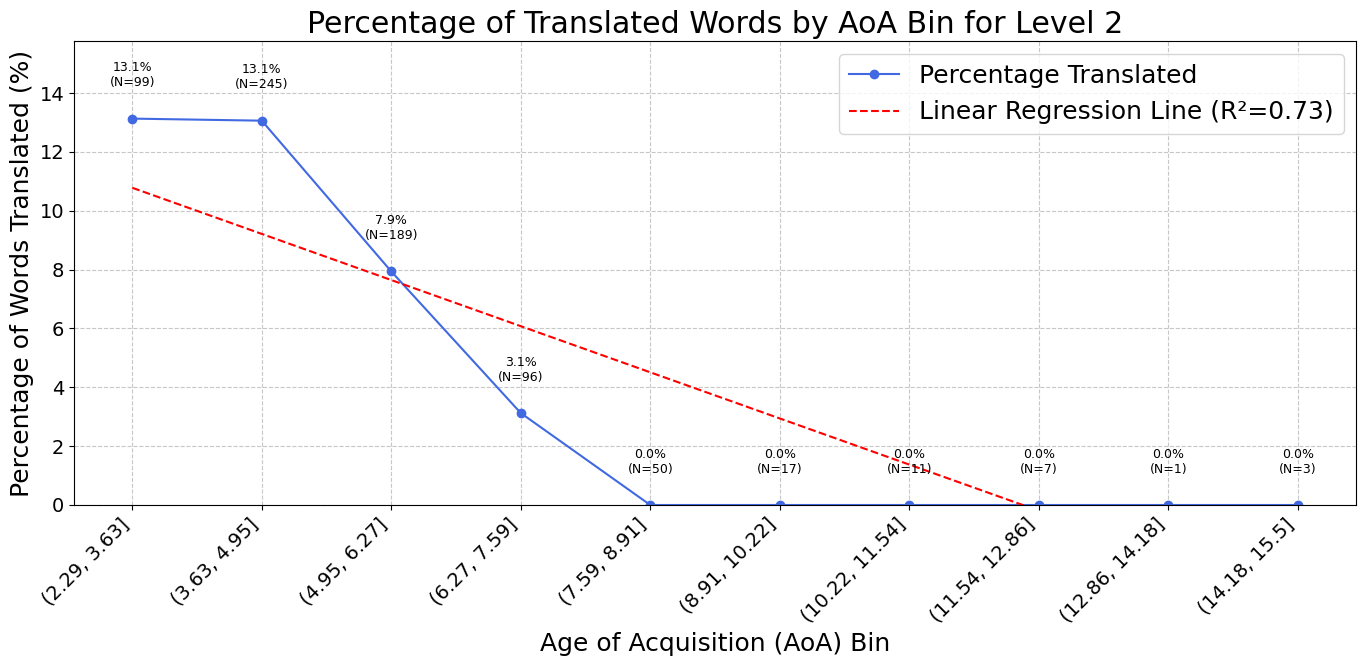


--- Counts and Percentages per Bin ---
                all_count  translated_count  percentage_translated
(2.29, 3.63]           94                 3               3.191489
(3.63, 4.96]          229                 9               3.930131
(4.96, 6.28]          185                 2               1.081081
(6.28, 7.6]            89                 2               2.247191
(7.6, 8.92]            50                 0               0.000000
(8.92, 10.25]          30                 0               0.000000
(10.25, 11.57]          8                 1              12.500000
(11.57, 12.89]          8                 0               0.000000
(12.89, 14.21]          2                 0               0.000000
(14.21, 15.54]          4                 1              25.000000
------------------------------


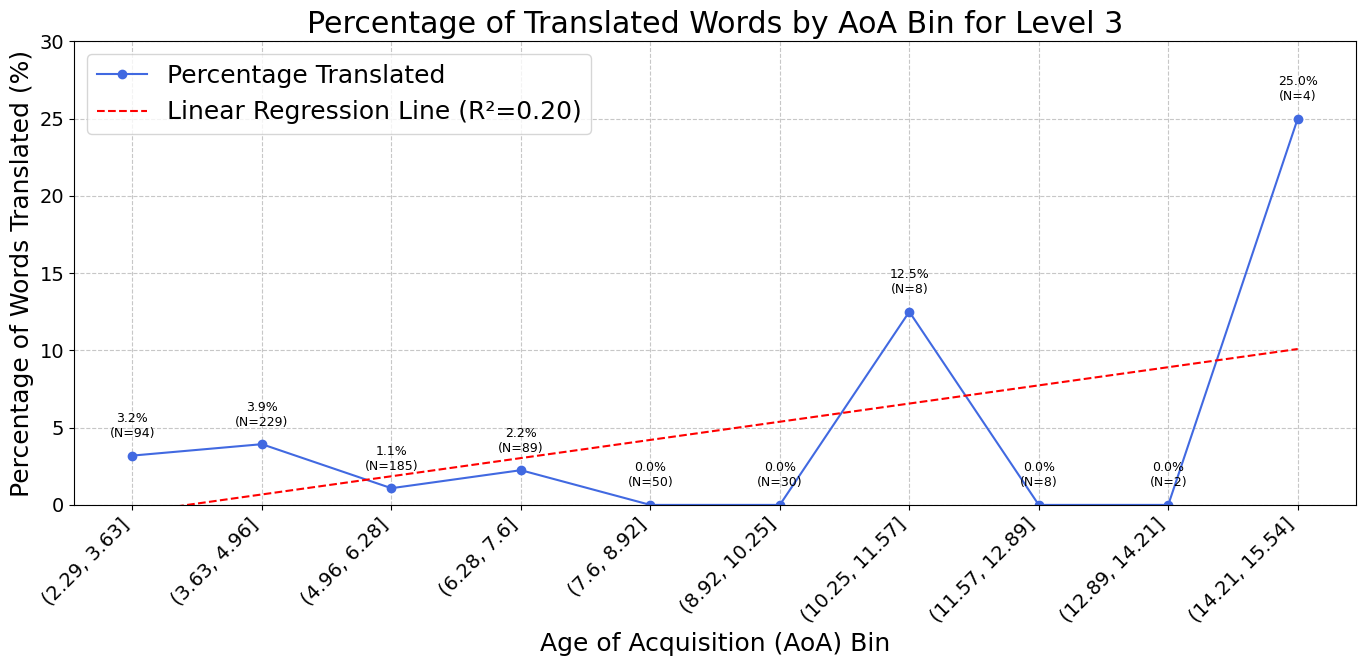


--- Counts and Percentages per Bin ---
                all_count  translated_count  percentage_translated
(2.29, 3.63]           76                 2               2.631579
(3.63, 4.96]          184                10               5.434783
(4.96, 6.28]          144                 2               1.388889
(6.28, 7.6]            75                 2               2.666667
(7.6, 8.92]            37                 0               0.000000
(8.92, 10.25]          11                 0               0.000000
(10.25, 11.57]         11                 0               0.000000
(11.57, 12.89]          6                 0               0.000000
(12.89, 14.21]          3                 0               0.000000
(14.21, 15.54]          3                 0               0.000000
------------------------------


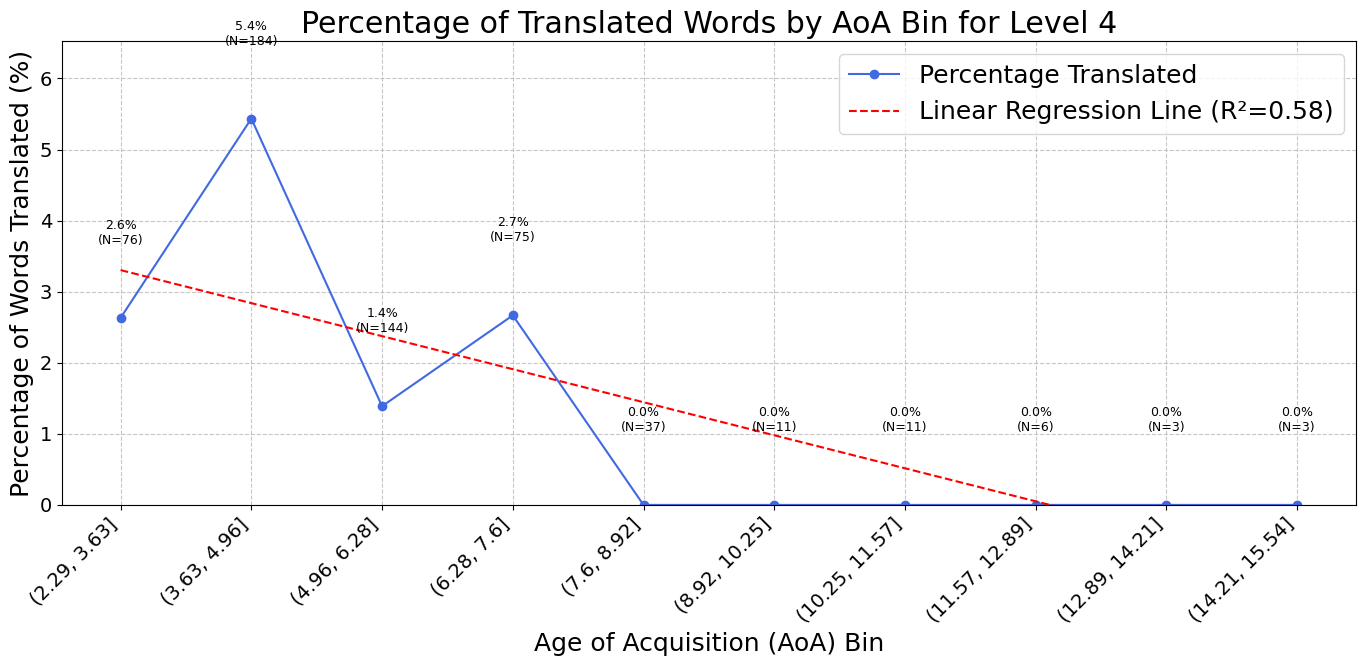

In [207]:
# Translated words proportion by AoA bins per level

for proficiency, group_df in translated_words_stats_by_level.items():
    all_group_df = english_words_stats_by_level_clean[proficiency]
    english_aoa_only = all_group_df[["Word", "AoA"]]
    translated_aoa_only = group_df[["Word", "AoA"]]

    num_bins = 10
    plt.rcParams.update({"font.size": 18})

    try:
        english_aoa_only["AoA_bin"], bins = pd.cut(
            english_aoa_only["AoA"],
            bins=num_bins,
            precision=2,
            retbins=True,
            include_lowest=True,
        )
        translated_aoa_only["AoA_bin"] = pd.cut(
            translated_aoa_only["AoA"], bins=bins, precision=2, include_lowest=True
        )

        bin_labels = english_aoa_only["AoA_bin"].cat.categories.astype(str)

    except ValueError as e:
        print(f"Error creating bins: {e}")
        print("This might happen if AoA range is too small or num_bins is too high.")

    except Exception as e:
        print(f"An unexpected error occurred during binning: {e}")

    all_counts = (
        english_aoa_only.groupby("AoA_bin", observed=False).size().rename("all_count")
    )
    translated_counts = (
        translated_aoa_only.groupby("AoA_bin", observed=False)
        .size()
        .rename("translated_count")
    )

    comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")

    comparison_df = comparison_df.reindex(english_aoa_only["AoA_bin"].cat.categories)
    comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)
    comparison_df["all_count"] = comparison_df["all_count"].fillna(0)

    comparison_df["percentage_translated"] = comparison_df.apply(
        lambda row: (
            (row["translated_count"] / row["all_count"] * 100)
            if row["all_count"] > 0
            else 0
        ),
        axis=1,
    )

    print("\n--- Counts and Percentages per Bin ---")
    print(comparison_df)
    print("-" * 30)

    plt.figure(figsize=(14, 7))

    x_labels = comparison_df.index.astype(str)
    x_values = np.arange(len(comparison_df))

    plt.plot(
        x_values,
        comparison_df["percentage_translated"],
        marker="o",
        linestyle="-",
        color="royalblue",
        label="Percentage Translated",
    )

    slope, intercept, r_value, p_value, std_err = linregress(
        x_values, comparison_df["percentage_translated"]
    )

    regression_line = slope * x_values + intercept

    plt.plot(
        x_values,
        regression_line,
        color="red",
        linestyle="--",
        label=f"Linear Regression Line (R²={r_value**2:.2f})",
    )

    for i, row in comparison_df.iterrows():
        x_pos = x_values[comparison_df.index.get_loc(i)]
        y_pos = row["percentage_translated"]
        annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"
        plt.text(
            x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9
        )

    plt.xlabel("Age of Acquisition (AoA) Bin")
    plt.ylabel("Percentage of Words Translated (%)")
    plt.title("Percentage of Translated Words by AoA Bin for Level " + str(proficiency))
    plt.yticks(fontsize=14)
    plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)
    plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)
    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


--- Counts and Percentages per Bin ---
                    all_count  translated_count  percentage_translated
(-57.4, 5739.1]           392                54              13.775510
(5739.1, 11478.2]          37                 0               0.000000
(11478.2, 17217.3]         18                 1               5.555556
(17217.3, 22956.4]          4                 1              25.000000
(22956.4, 28695.5]          0                 0               0.000000
(28695.5, 34434.6]          1                 0               0.000000
(34434.6, 40173.7]          0                 0               0.000000
(40173.7, 45912.8]          1                 0               0.000000
(45912.8, 51651.9]          0                 0               0.000000
(51651.9, 57391.0]          1                 0               0.000000
------------------------------


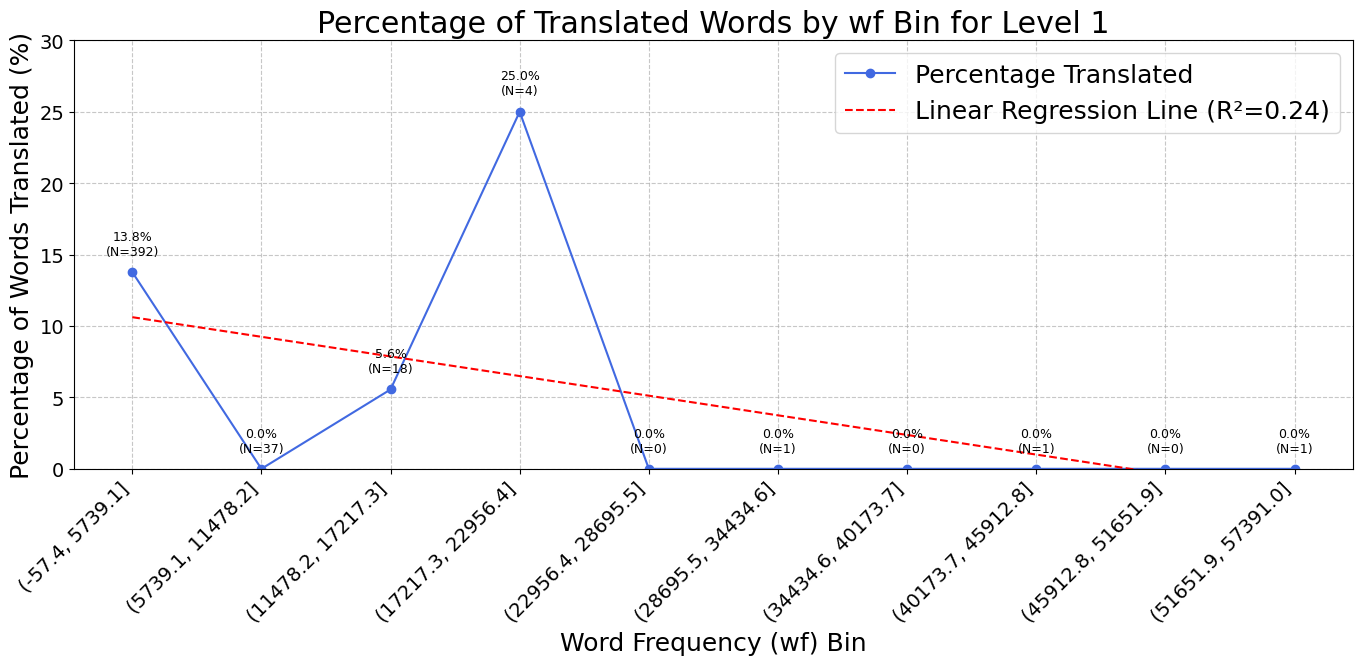


--- Counts and Percentages per Bin ---
                     all_count  translated_count  percentage_translated
(-105.29, 10528.1]         667                62               9.295352
(10528.1, 21056.2]          35                 2               5.714286
(21056.2, 31584.3]           4                 0               0.000000
(31584.3, 42112.4]           4                 1              25.000000
(42112.4, 52640.5]           3                 0               0.000000
(52640.5, 63168.6]           1                 0               0.000000
(63168.6, 73696.7]           1                 0               0.000000
(73696.7, 84224.8]           0                 0               0.000000
(84224.8, 94752.9]           1                 0               0.000000
(94752.9, 105281.0]          2                 0               0.000000
------------------------------


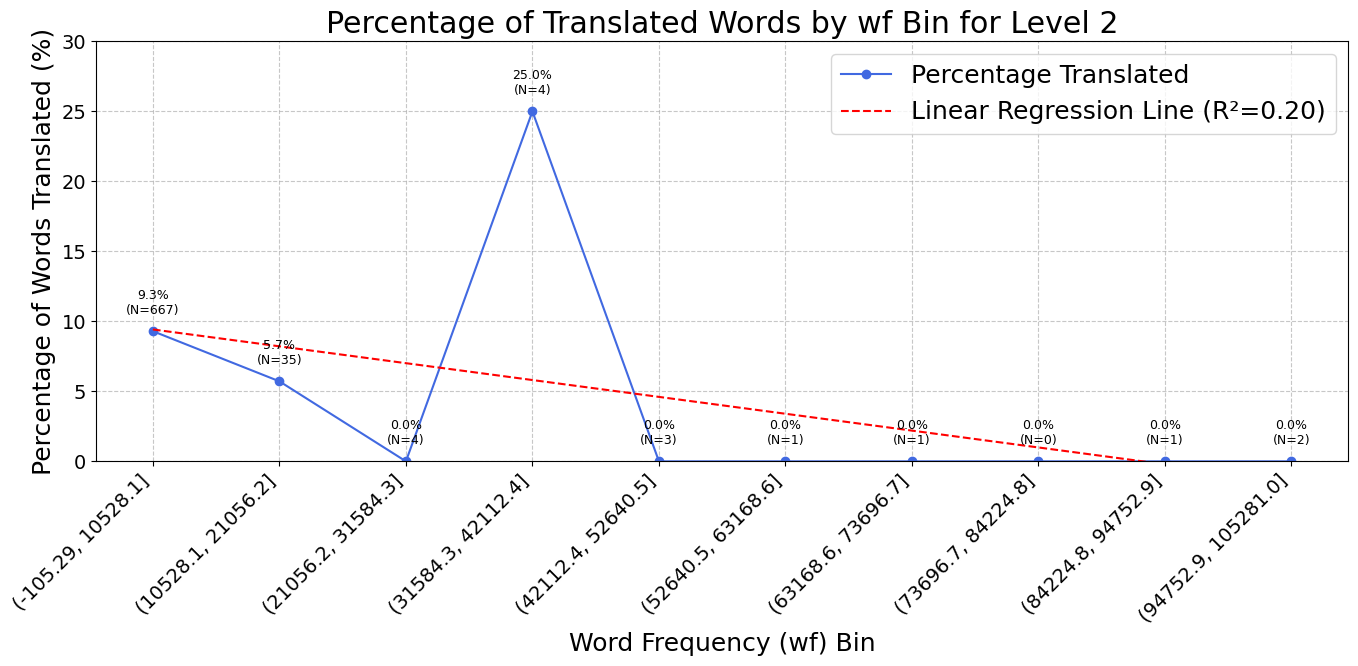


--- Counts and Percentages per Bin ---
                                all_count  translated_count  \
(-104.49000000000001, 10447.5]        650                18   
(10447.5, 20895.0]                     29                 1   
(20895.0, 31342.5]                      9                 0   
(31342.5, 41790.0]                      3                 0   
(41790.0, 52237.5]                      3                 0   
(52237.5, 62685.0]                      1                 1   
(62685.0, 73132.5]                      2                 0   
(73132.5, 83580.0]                      0                 0   
(83580.0, 94027.5]                      0                 0   
(94027.5, 104475.0]                     2                 0   

                                percentage_translated  
(-104.49000000000001, 10447.5]               2.769231  
(10447.5, 20895.0]                           3.448276  
(20895.0, 31342.5]                           0.000000  
(31342.5, 41790.0]                        

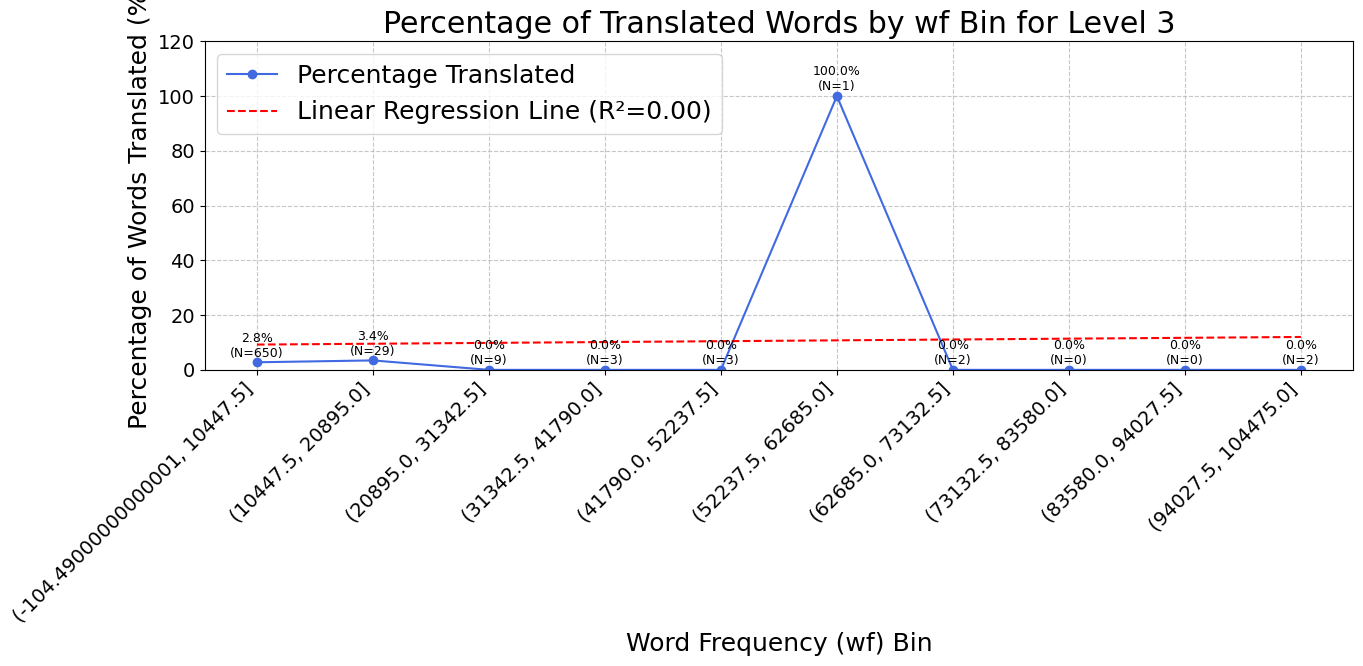


--- Counts and Percentages per Bin ---
                    all_count  translated_count  percentage_translated
(-82.25, 8224.5]          513                17                3.31384
(8224.5, 16449.0]          22                 0                0.00000
(16449.0, 24673.5]          8                 0                0.00000
(24673.5, 32898.0]          3                 0                0.00000
(32898.0, 41122.5]          0                 0                0.00000
(41122.5, 49347.0]          0                 0                0.00000
(49347.0, 57571.5]          0                 0                0.00000
(57571.5, 65796.0]          2                 0                0.00000
(65796.0, 74020.5]          1                 0                0.00000
(74020.5, 82245.0]          1                 0                0.00000
------------------------------


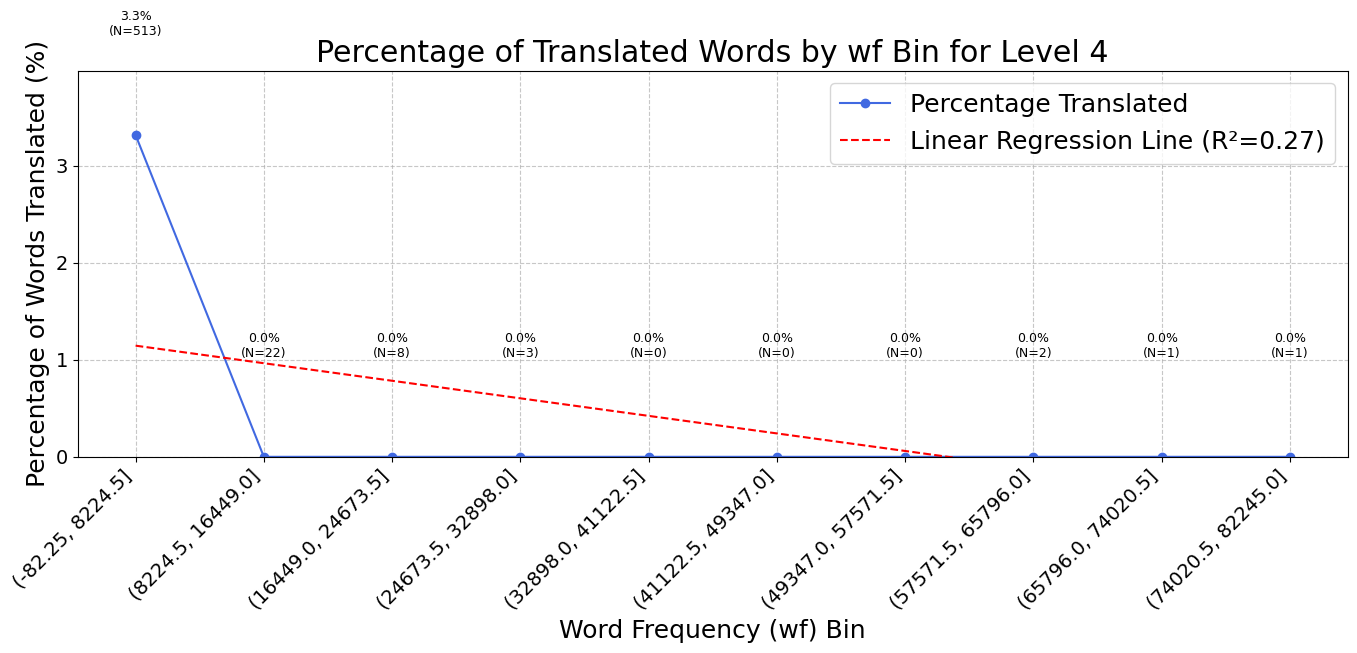

In [ ]:
# Translated words proportion by WF bin by level

for proficiency, group_df in translated_words_stats_by_level.items():

    all_group_df = english_words_stats_by_level_clean[proficiency]

    english_wf_only = all_group_df[["Word", "WF"]]

    translated_wf_only = group_df[["Word", "WF"]]


    num_bins = 10

    plt.rcParams.update({"font.size": 18})


    try:

        english_wf_only["wf_bin"], bins = pd.cut(
            english_wf_only["WF"],
            bins=num_bins,
            precision=2,
            retbins=True,
            include_lowest=True,
        )


        translated_wf_only["wf_bin"] = pd.cut(
            translated_wf_only["WF"], bins=bins, precision=2, include_lowest=True
        )


        bin_labels = english_wf_only["wf_bin"].cat.categories.astype(str)


    except ValueError as e:

        print(f"Error creating bins: {e}")

        print("This might happen if wf range is too small or num_bins is too high.")


    except Exception as e:

        print(f"An unexpected error occurred during binning: {e}")

    all_counts = (

        english_wf_only.groupby("wf_bin", observed=False).size().rename("all_count")
    )
    translated_counts = (

        translated_wf_only.groupby("wf_bin", observed=False)
        .size()
        .rename("translated_count")
    )


    comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")


    comparison_df = comparison_df.reindex(english_wf_only["wf_bin"].cat.categories)

    comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)


    comparison_df["all_count"] = comparison_df["all_count"].fillna(0)


    comparison_df["percentage_translated"] = comparison_df.apply(

        lambda row: (

            (row["translated_count"] / row["all_count"] * 100)
            if row["all_count"] > 0
            else 0
        ),

        axis=1,
    )


    print("\n--- Counts and Percentages per Bin ---")

    print(comparison_df)

    print("-" * 30)


    plt.figure(figsize=(14, 7))


    x_labels = comparison_df.index.astype(str)

    x_values = np.arange(len(comparison_df))

    plt.plot(

        x_values,
        comparison_df["percentage_translated"],
        marker="o",
        linestyle="-",
        color="royalblue",
        label="Percentage Translated",
    )


    slope, intercept, r_value, p_value, std_err = linregress(
        x_values, comparison_df["percentage_translated"]
    )


    regression_line = slope * x_values + intercept

    plt.plot(

        x_values,
        regression_line,
        color="red",

        linestyle="--",

        label=f"Linear Regression Line (R²={r_value**2:.2f})",
    )


    for i, row in comparison_df.iterrows():

        x_pos = x_values[comparison_df.index.get_loc(i)]

        y_pos = row["percentage_translated"]

        annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"

        plt.text(
            x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9
        )


    plt.xlabel("Word Frequency (wf) Bin")

    plt.ylabel("Percentage of Words Translated (%)")

    plt.title("Percentage of Translated Words by wf Bin for Level " + str(proficiency))

    plt.yticks(fontsize=14)

    plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)


    plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)


    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend()


    plt.tight_layout()

    plt.show()


--- Counts and Percentages per Bin ---
                               all_count  translated_count  \
(-20.650000000000002, 2064.4]        305                47   
(2064.4, 4128.8]                      57                 6   
(4128.8, 6193.2]                      34                 1   
(6193.2, 8257.6]                      18                 0   
(8257.6, 10322.0]                     10                 0   
(10322.0, 12386.4]                    11                 0   
(12386.4, 14450.8]                     5                 1   
(14450.8, 16515.2]                     5                 0   
(16515.2, 18579.6]                     3                 0   
(18579.6, 20644.0]                     1                 1   

                               percentage_translated  
(-20.650000000000002, 2064.4]              15.409836  
(2064.4, 4128.8]                           10.526316  
(4128.8, 6193.2]                            2.941176  
(6193.2, 8257.6]                            0.000000  
(8

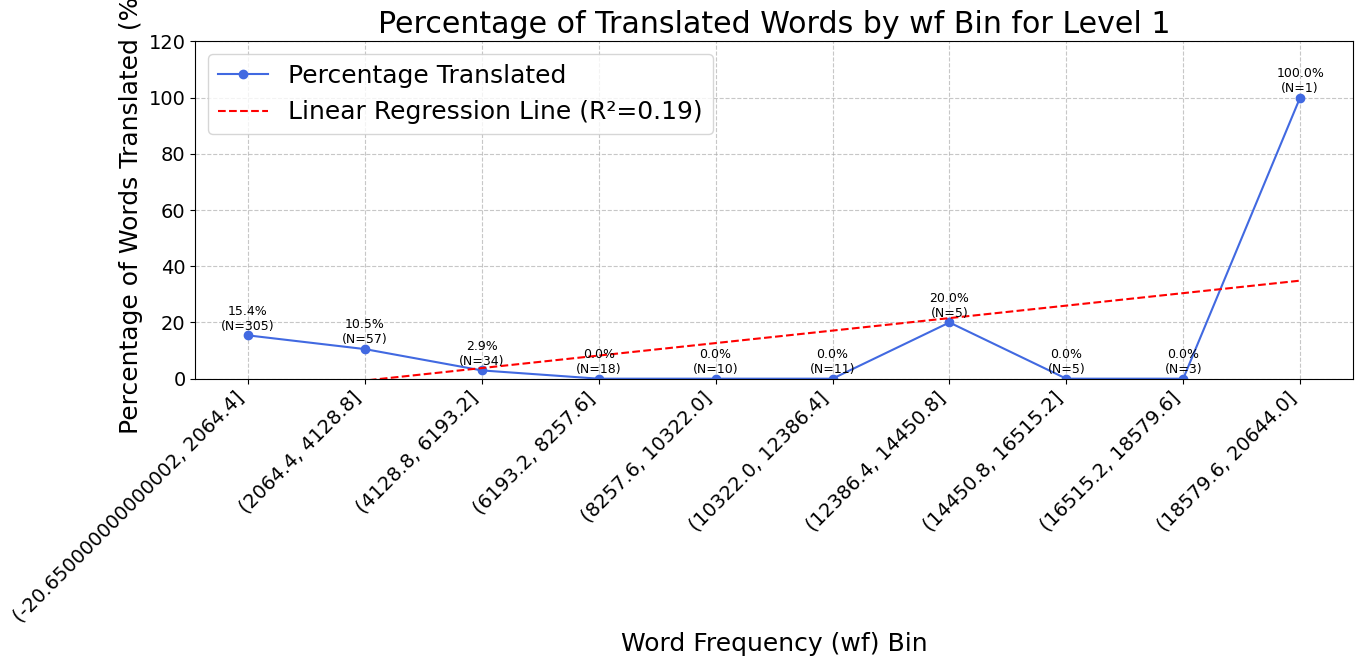


--- Counts and Percentages per Bin ---
                    all_count  translated_count  percentage_translated
(-18.98, 1896.8]          444                53              11.936937
(1896.8, 3793.6]          115                 5               4.347826
(3793.6, 5690.4]           58                 1               1.724138
(5690.4, 7587.2]           26                 2               7.692308
(7587.2, 9484.0]           16                 1               6.250000
(9484.0, 11380.8]          11                 0               0.000000
(11380.8, 13277.6]         12                 2              16.666667
(13277.6, 15174.4]          8                 0               0.000000
(15174.4, 17071.2]          3                 0               0.000000
(17071.2, 18968.0]          9                 0               0.000000
------------------------------


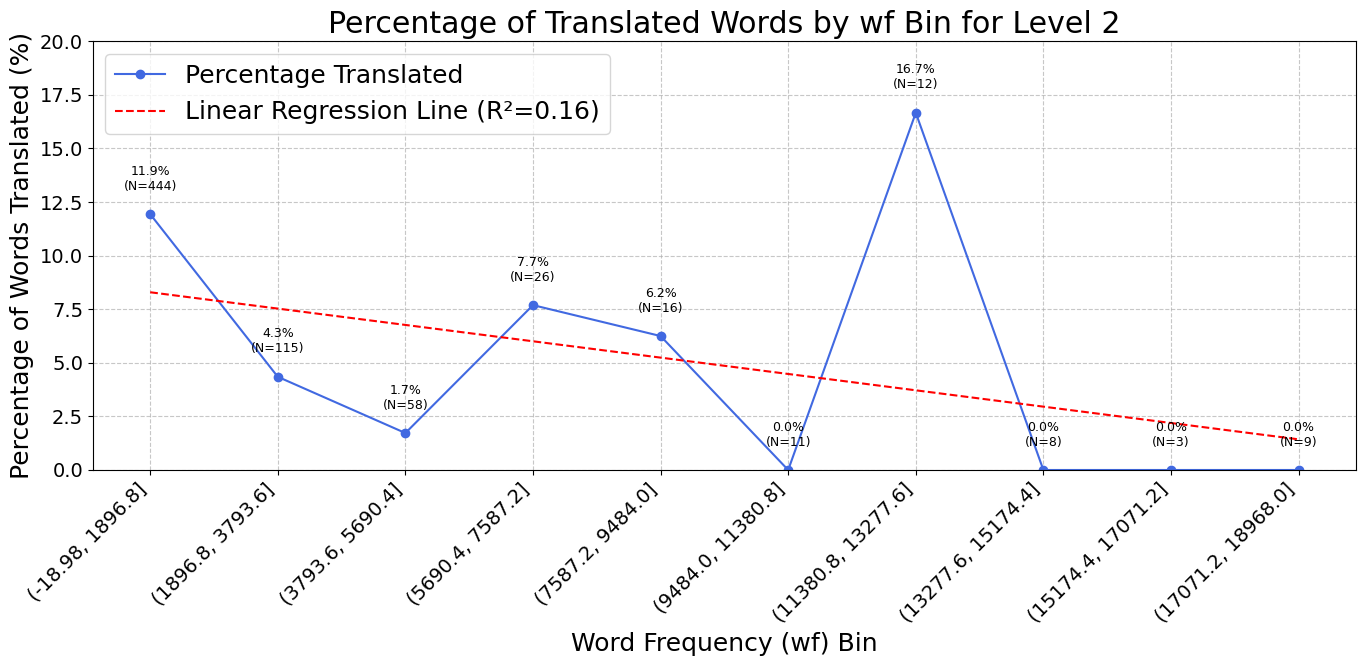


--- Counts and Percentages per Bin ---
                               all_count  translated_count  \
(-18.270000000000003, 1825.7]        429                15   
(1825.7, 3651.4]                     105                 0   
(3651.4, 5477.1]                      67                 2   
(5477.1, 7302.8]                      24                 1   
(7302.8, 9128.5]                      17                 0   
(9128.5, 10954.2]                     12                 1   
(10954.2, 12779.9]                     8                 0   
(12779.9, 14605.6]                     6                 0   
(14605.6, 16431.3]                     4                 0   
(16431.3, 18257.0]                     7                 0   

                               percentage_translated  
(-18.270000000000003, 1825.7]               3.496503  
(1825.7, 3651.4]                            0.000000  
(3651.4, 5477.1]                            2.985075  
(5477.1, 7302.8]                            4.166667  
(7

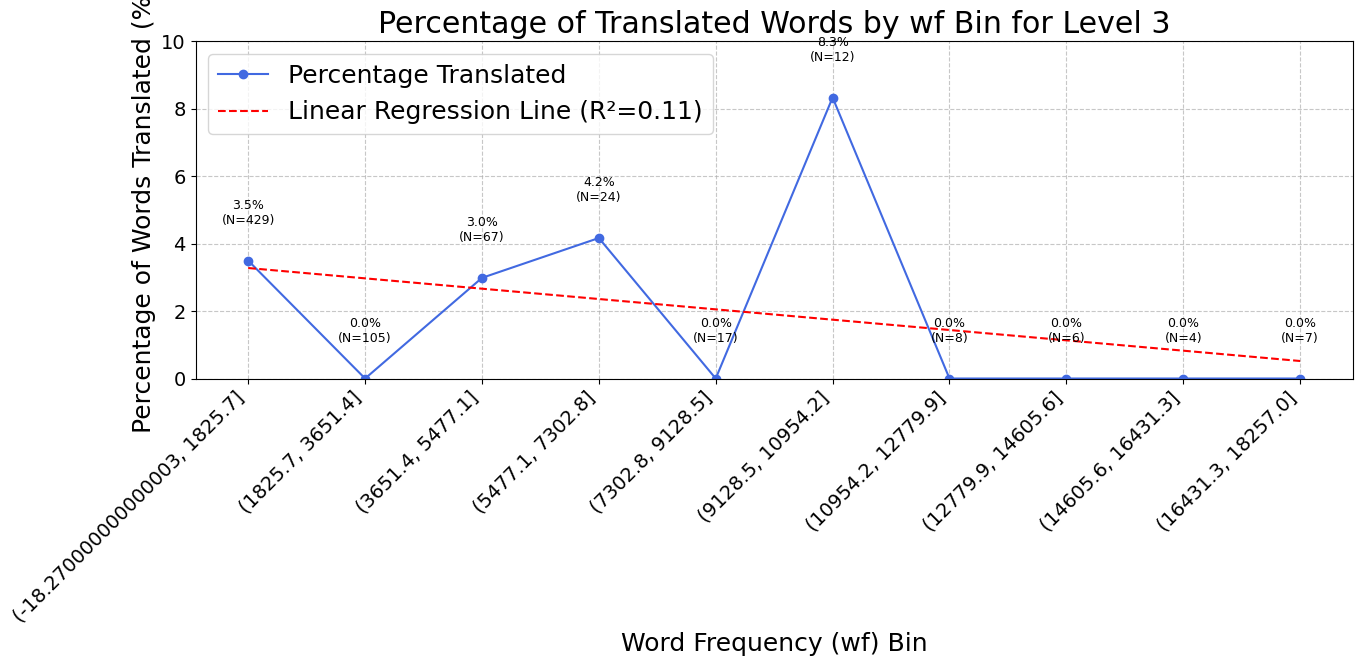


--- Counts and Percentages per Bin ---
                    all_count  translated_count  percentage_translated
(-19.55, 1953.5]          368                16               4.347826
(1953.5, 3907.0]           86                 1               1.162791
(3907.0, 5860.5]           37                 0               0.000000
(5860.5, 7814.0]           20                 0               0.000000
(7814.0, 9767.5]           11                 0               0.000000
(9767.5, 11721.0]           4                 0               0.000000
(11721.0, 13674.5]          7                 0               0.000000
(13674.5, 15628.0]          2                 0               0.000000
(15628.0, 17581.5]          2                 0               0.000000
(17581.5, 19535.0]          4                 0               0.000000
------------------------------


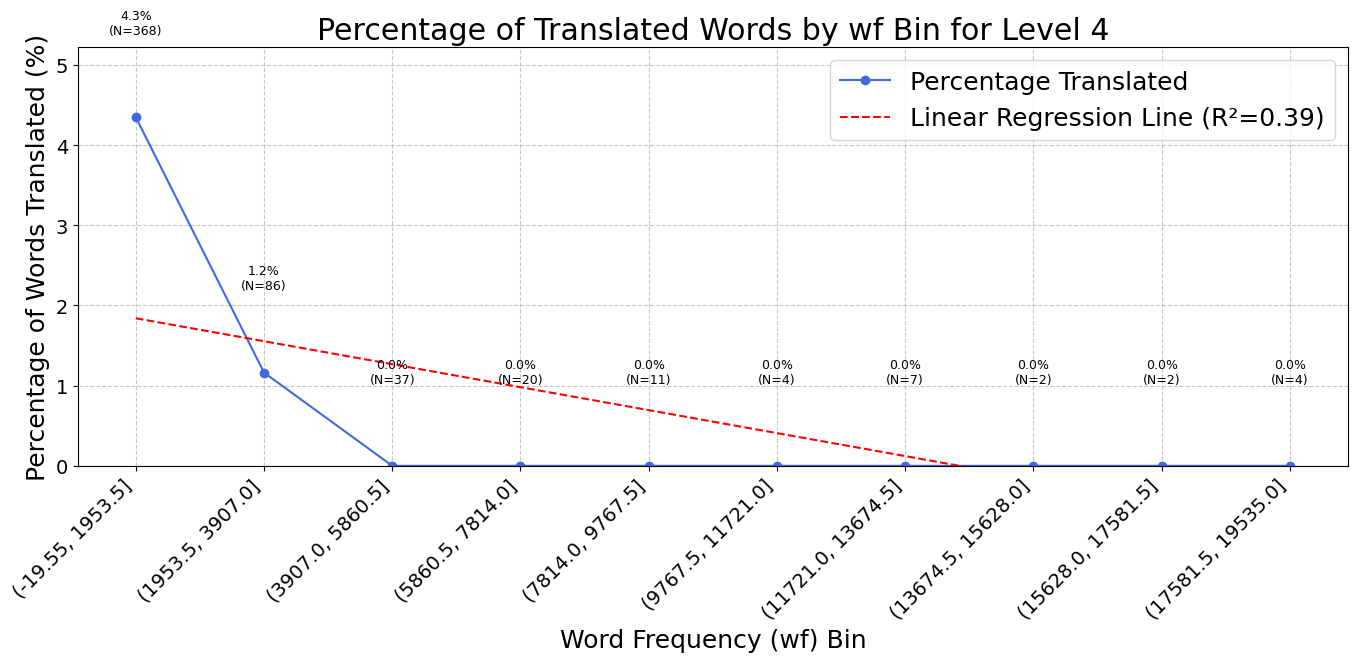

In [ ]:
# translated words proportion by WF bins with outliers removed

for proficiency, group_df in translated_words_stats_by_level.items():

    all_group_df = english_words_stats_by_level_clean[proficiency]

    english_wf_only = all_group_df[["Word", "WF"]]

    translated_wf_only = group_df[["Word", "WF"]]


    english_wf_only = english_wf_only[english_wf_only["WF"] <= 21056.2]

    translated_wf_only = translated_wf_only[translated_wf_only["WF"] <= 21056.2]


    num_bins = 10


    plt.rcParams.update({"font.size": 18})


    try:

        english_wf_only["wf_bin"], bins = pd.cut(
            english_wf_only["WF"],
            bins=num_bins,
            precision=2,
            retbins=True,
            include_lowest=True,
        )


        translated_wf_only["wf_bin"] = pd.cut(
            translated_wf_only["WF"], bins=bins, precision=2, include_lowest=True
        )


        bin_labels = english_wf_only["wf_bin"].cat.categories.astype(str)


    except ValueError as e:

        print(f"Error creating bins: {e}")


        print("This might happen if wf range is too small or num_bins is too high.")


    except Exception as e:

        print(f"An unexpected error occurred during binning: {e}")

    all_counts = (

        english_wf_only.groupby("wf_bin", observed=False).size().rename("all_count")
    )
    translated_counts = (

        translated_wf_only.groupby("wf_bin", observed=False)
        .size()
        .rename("translated_count")
    )


    comparison_df = pd.DataFrame(all_counts).join(translated_counts, how="left")


    comparison_df = comparison_df.reindex(english_wf_only["wf_bin"].cat.categories)

    comparison_df["translated_count"] = comparison_df["translated_count"].fillna(0)


    comparison_df["all_count"] = comparison_df["all_count"].fillna(0)


    comparison_df["percentage_translated"] = comparison_df.apply(
        lambda row: (
            (row["translated_count"] / row["all_count"] * 100)
            if row["all_count"] > 0
            else 0
        ),

        axis=1,
    )


    print("\n--- Counts and Percentages per Bin ---")

    print(comparison_df)

    print("-" * 30)


    plt.figure(figsize=(14, 7))


    x_labels = comparison_df.index.astype(str)

    x_values = np.arange(len(comparison_df))

    plt.plot(

        x_values,
        comparison_df["percentage_translated"],
        marker="o",
        linestyle="-",
        color="royalblue",
        label="Percentage Translated",
    )


    slope, intercept, r_value, p_value, std_err = linregress(
        x_values, comparison_df["percentage_translated"]
    )


    regression_line = slope * x_values + intercept

    plt.plot(

        x_values,
        regression_line,
        color="red",

        linestyle="--",
        label=f"Linear Regression Line (R²={r_value**2:.2f})",
    )


    for i, row in comparison_df.iterrows():

        x_pos = x_values[comparison_df.index.get_loc(i)]

        y_pos = row["percentage_translated"]


        annotation_text = f"{y_pos:.1f}%\n(N={int(row['all_count'])})"

        plt.text(
            x_pos, y_pos + 1, annotation_text, ha="center", va="bottom", fontsize=9
        )


    plt.xlabel("Word Frequency (wf) Bin")

    plt.ylabel("Percentage of Words Translated (%)")

    plt.title("Percentage of Translated Words by wf Bin for Level " + str(proficiency))


    plt.yticks(fontsize=14)

    plt.xticks(ticks=x_values, labels=x_labels, rotation=45, ha="right", fontsize=14)


    plt.ylim(0, comparison_df["percentage_translated"].max() * 1.2)


    plt.grid(axis="both", linestyle="--", alpha=0.7)
    plt.legend()


    plt.tight_layout()

    plt.show()

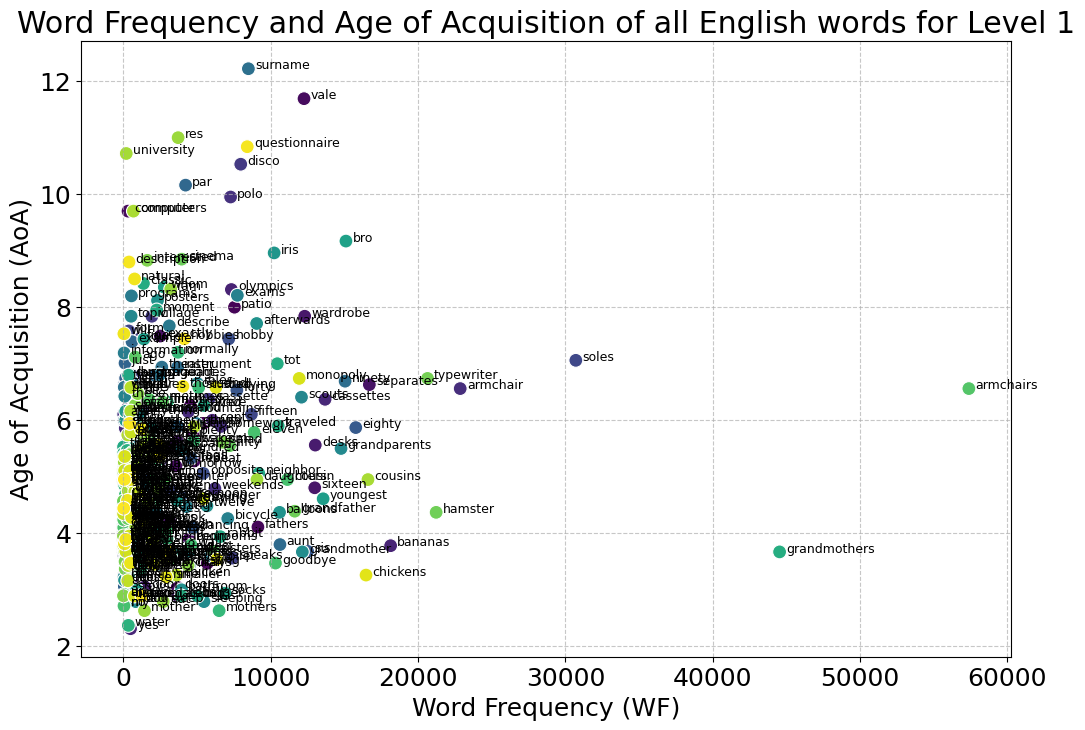

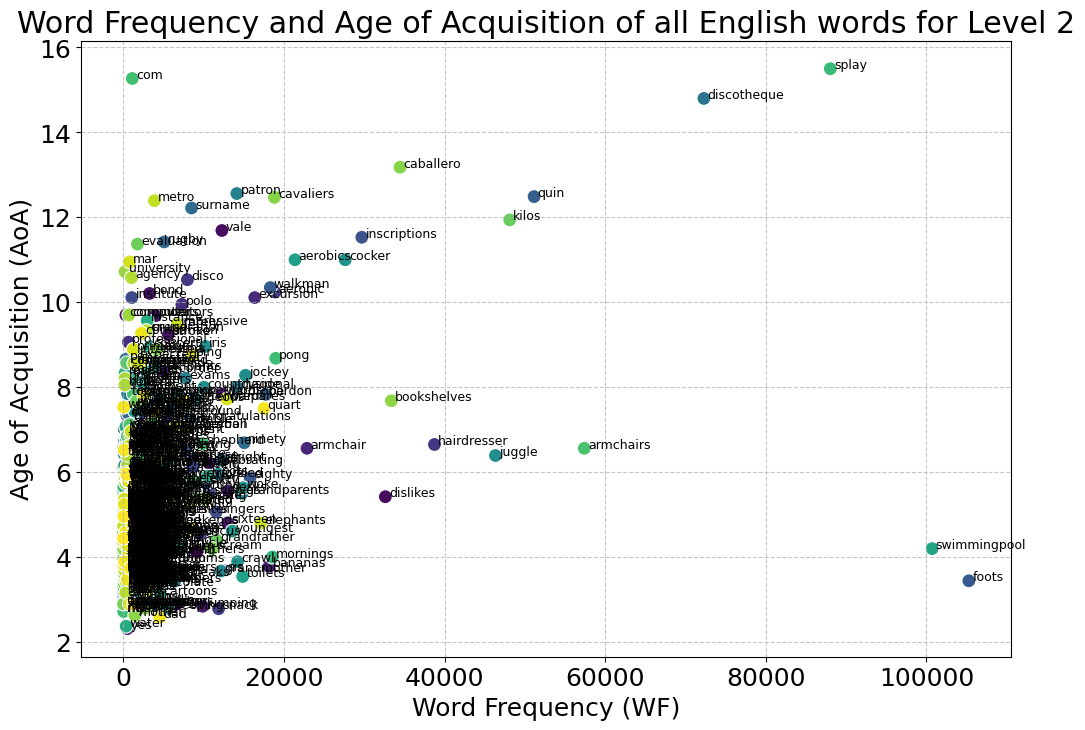

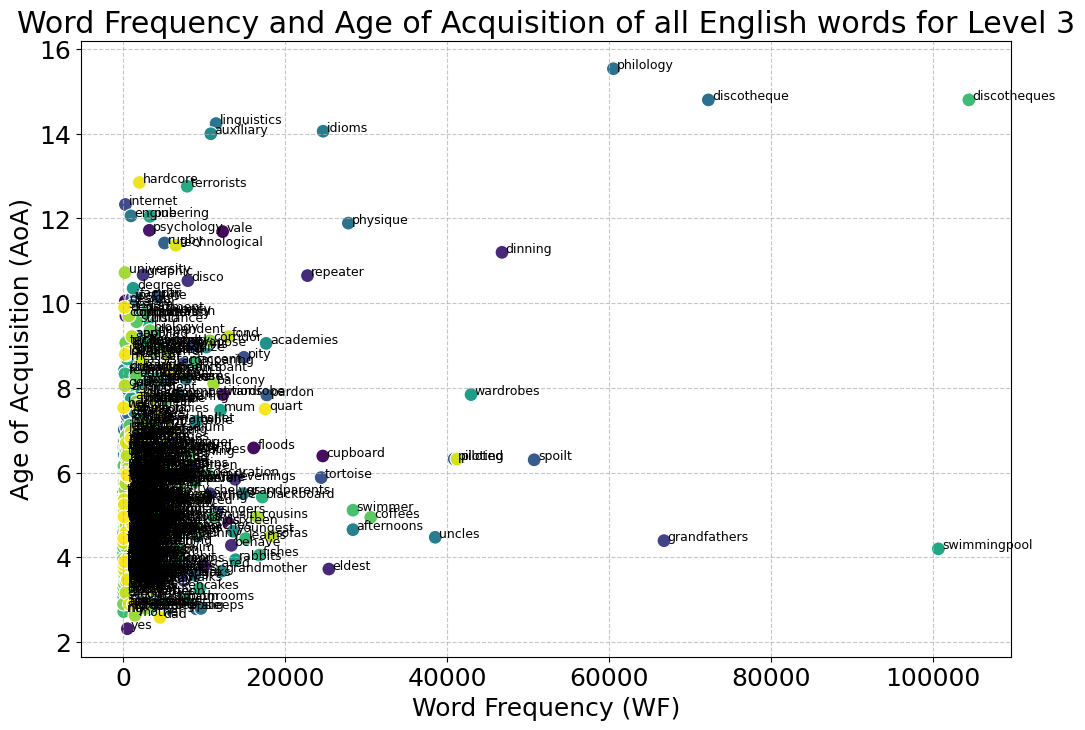

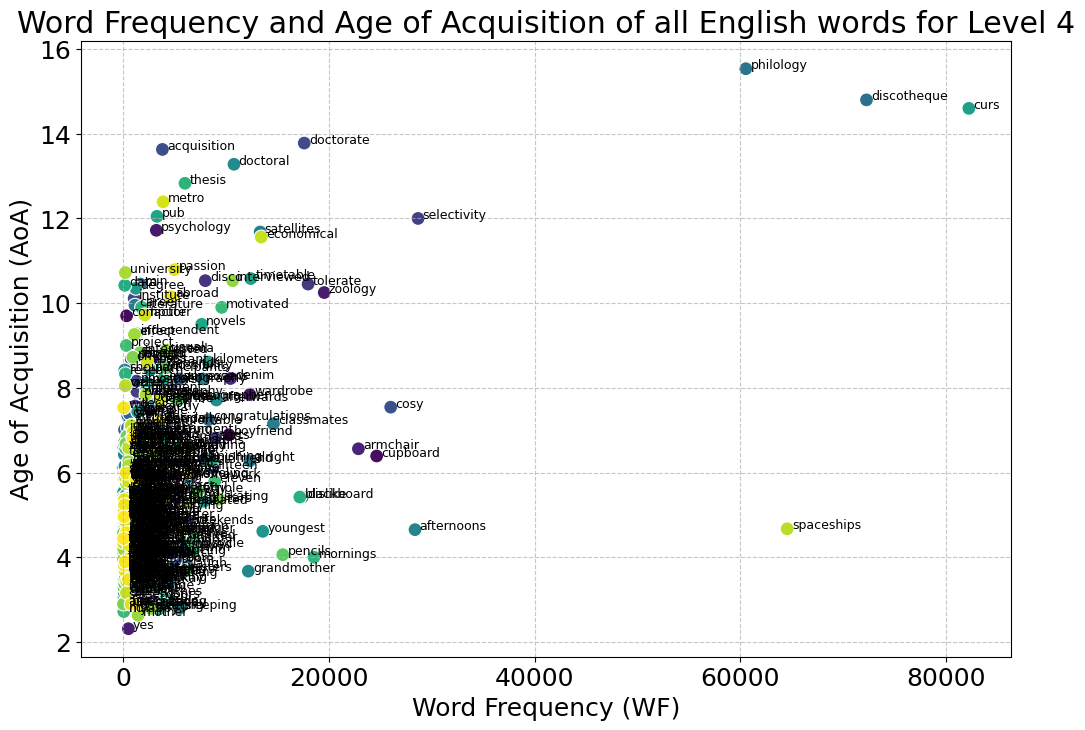

In [ ]:
# WF and AoA for all English words by level

for proficiency, group_df in english_words_stats_by_level_clean.items():

    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=group_df,

        x="WF",
        y="AoA",
        hue="Word",
        palette="viridis",

        s=100,
        legend=False,
    )


    plt.xlabel("Word Frequency (WF)")

    plt.ylabel("Age of Acquisition (AoA)")
    plt.title(

        "Word Frequency and Age of Acquisition of all English words for Level "
        + str(proficiency)
    )


    for i in range(group_df.shape[0]):

        plt.text(
            group_df["WF"].iloc[i] + 450,
            group_df["AoA"].iloc[i],
            group_df["Word"].iloc[i],
            fontsize=9,
        )


    plt.grid(True, linestyle="--", alpha=0.7)

    plt.show()

# Now, plotting surprisal


In [ ]:
# Obtained using an external script

topic_surprisals_per_level = pickle.load(
    open("pickle/topic_surprisals_per_level.pkl", "rb")
)

In [ ]:
# Print averages

[

    {"Proficiency": level, "Topic": topic, "Average surprisal": -np.mean(surprisals)}
    for level, topics in topic_surprisals_per_level.items()
    for topic, surprisals in topics.items()
    if len(surprisals) > 0
]

[{'Proficiency': 1,
  'Topic': 'Backchannel',
  'Average surprisal': np.float64(7.463419592741764)},
 {'Proficiency': 1,
  'Topic': 'Questions',
  'Average surprisal': np.float64(5.418913582960765)},
 {'Proficiency': 1,
  'Topic': 'Topics',
  'Average surprisal': np.float64(5.463802436019766)},
 {'Proficiency': 2,
  'Topic': 'Backchannel',
  'Average surprisal': np.float64(7.358295493009614)},
 {'Proficiency': 2,
  'Topic': 'Questions',
  'Average surprisal': np.float64(4.873882117478744)},
 {'Proficiency': 2,
  'Topic': 'Topics',
  'Average surprisal': np.float64(5.75774383327684)},
 {'Proficiency': 3,
  'Topic': 'Backchannel',
  'Average surprisal': np.float64(9.010511803627015)},
 {'Proficiency': 3,
  'Topic': 'Questions',
  'Average surprisal': np.float64(5.835901941571917)},
 {'Proficiency': 3,
  'Topic': 'Topics',
  'Average surprisal': np.float64(5.709042072296143)},
 {'Proficiency': 4,
  'Topic': 'Backchannel',
  'Average surprisal': np.float64(8.223319863450937)},
 {'Proficien

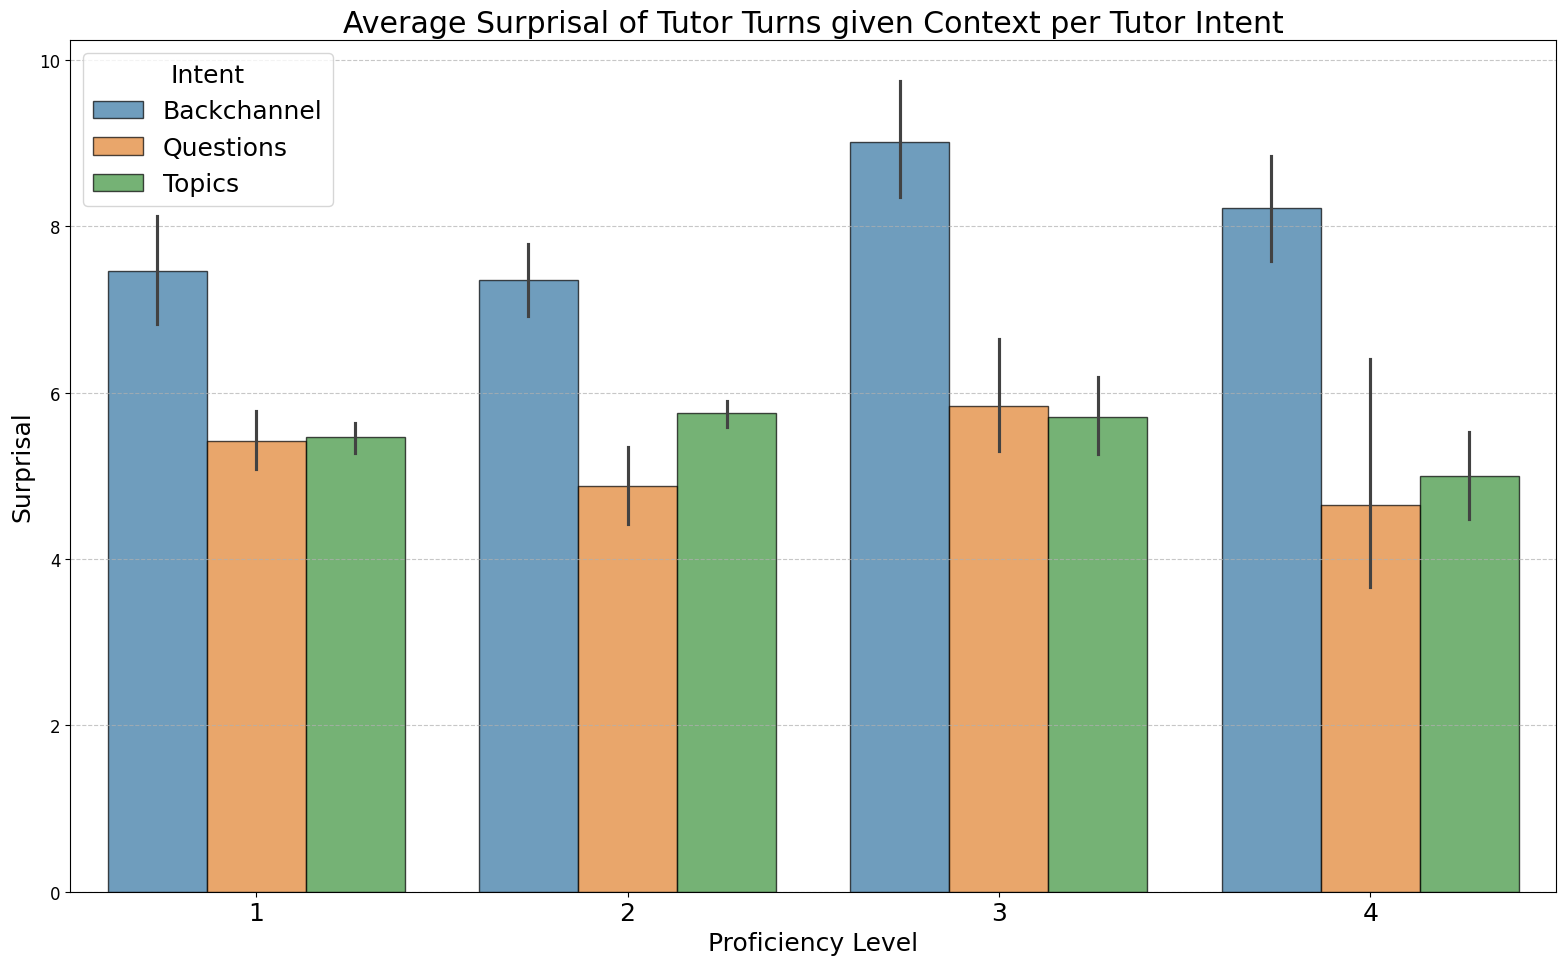

In [214]:
import seaborn as sns

# Plotting surprisal per intent per level
data = [
    {
        "Proficiency": level,
        "Tutor Intent": topic,
        "Surprisal": -surprisal,  # need to negate, since originally it is negative
    }
    for level, topics in topic_surprisals_per_level.items()
    for topic, surprisals in topics.items()
    for surprisal in surprisals
    if len(surprisals) > 0
]

df = pd.DataFrame(data)

plt.figure(figsize=(16, 10))
sns.barplot(
    x="Proficiency",
    y="Surprisal",
    hue="Tutor Intent",
    data=df,
    palette={"Questions": "#ff7f0e", "Backchannel": "#1f77b4", "Topics": "#2ca02c"},
    dodge=True,
    alpha=0.7,
    edgecolor="black",
    ci=95,
)

plt.xlabel("Proficiency Level")
plt.ylabel("Surprisal")
plt.title("Average Surprisal of Tutor Turns given Context per Tutor Intent")
plt.xticks(rotation=0, ha="center")
plt.yticks(fontsize=12)
plt.legend(title="Intent", loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

In [215]:
topic_surprisals_per_level

{1: {'Backchannel': [-4.147821426391602,
   -9.569165229797363,
   -6.0726189613342285,
   -8.320826530456543,
   -6.8071770668029785,
   -9.051704406738281,
   -6.338679790496826,
   -8.858022689819336,
   -5.279211044311523,
   -8.984800338745117,
   -6.699685096740723,
   -5.604737758636475,
   -7.359208106994629,
   -5.419943332672119,
   -7.171879291534424,
   -7.171879291534424,
   -4.508573532104492,
   -4.53695011138916,
   -4.740220546722412,
   -4.740220546722412,
   -4.740220546722412,
   -5.2369771003723145,
   -8.093403816223145,
   -4.899509429931641,
   -11.330299377441406,
   -7.080535411834717,
   -6.687603950500488,
   -6.063979625701904,
   -5.122344493865967,
   -7.0404510498046875,
   -5.581087112426758,
   -12.767035484313965,
   -9.047097206115723,
   -8.504918098449707,
   -9.58230972290039,
   -7.9331793785095215,
   -9.844768524169922,
   -8.341259956359863,
   -13.22665786743164,
   -6.898325443267822,
   -8.217060089111328,
   -8.343659400939941,
   -8.38830

In [ ]:
# T-tables for intent vs intent within levels

from scipy.stats import ttest_ind, sem


import numpy as np



surprisal_data = [
    {
        "Level": level,
        "Data": [
            {"Topic": topic, "Surprisal": -surp}
            for topic, surps in topic_surprisals_per_level[level].items()
            for surp in surps

        ],
    }
    for level in topic_surprisals_per_level.keys()
]



for level in surprisal_data:


    df_original = pd.DataFrame(level["Data"])


    latex_table_data = []

    unique_proficiencies = df_original["Topic"].unique()

    for i, prof1 in enumerate(unique_proficiencies):


        for prof2 in unique_proficiencies[i + 1 :]:

            group1 = df_original[df_original["Topic"] == prof1]["Surprisal"]

            group2 = df_original[df_original["Topic"] == prof2]["Surprisal"]

            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals


            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    prof1,
                    prof2,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

    print(
        pd.DataFrame(
            latex_table_data,
            columns=["Topic 1", "Topic 2", "T-statistic", "P-value", "95\% CI"],
        ).to_latex(
            index=False,
            caption=f"Pairwise t-tests for Surprisals Level {level['Level']}",
            position="h!",
            label=f'tab-stats-overlaps-trans-level-{level["Level"]}',
        )
    )

\begin{table}[h!]
\caption{Pairwise t-tests for Surprisals Level 1}
\label{tab-stats-overlaps-trans-level-1}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & 4.322 & 0.0000* & [1.295, 2.794] \\
Backchannel & Topics & 8.031 & 0.0000* & [1.323, 2.676] \\
Questions & Topics & -0.160 & 0.8732 & [-0.449, 0.359] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Surprisals Level 2}
\label{tab-stats-overlaps-trans-level-2}
\begin{tabular}{lllll}
\toprule
Topic 1 & Topic 2 & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & 4.660 & 0.0000* & [1.844, 3.124] \\
Backchannel & Topics & 8.345 & 0.0000* & [1.131, 2.070] \\
Questions & Topics & -2.514 & 0.0123* & [-1.372, -0.396] \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[h!]
\caption{Pairwise t-tests for Surprisals Level 3}
\label{tab-stats-overlaps-trans-level-3}
\begin{tabular}{lllll}
\toprule
Topic 1 & T

<>:77: SyntaxWarning:

invalid escape sequence '\%'

<>:77: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3431740659.py:77: SyntaxWarning:

invalid escape sequence '\%'



In [217]:
from scipy.stats import ttest_ind, sem
import numpy as np
import pandas as pd

# T-tables for level vs level within intents

all_topics = set()
for level_data in topic_surprisals_per_level.values():
    all_topics.update(level_data.keys())
all_topics = sorted(list(all_topics))

all_levels = sorted(list(topic_surprisals_per_level.keys()))

latex_table_data = []

for topic in all_topics:
    for i, level1 in enumerate(all_levels):
        for level2 in all_levels[i + 1 :]:
            try:
                group1 = [-surp for surp in topic_surprisals_per_level[level1][topic]]
                group2 = [-surp for surp in topic_surprisals_per_level[level2][topic]]
            except KeyError:
                continue

            t_stat, p_value = ttest_ind(group1, group2)

            mean_diff = np.mean(group1) - np.mean(group2)
            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
            ci_low = mean_diff - 1.96 * pooled_se
            ci_high = mean_diff + 1.96 * pooled_se

            latex_table_data.append(
                [
                    level1,
                    level2,
                    topic,
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(
    pd.DataFrame(
        latex_table_data,
        columns=["Level 1", "Level 2", "Topic", "T-statistic", "P-value", "95\% CI"],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for Surprisals across Levels (by Topic)",
        position="h!",
        label="tab-stats-surprisals-levels-by-topic",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Surprisals across Levels (by Topic)}
\label{tab-stats-surprisals-levels-by-topic}
\begin{tabular}{rrllll}
\toprule
Level 1 & Level 2 & Topic & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Backchannel & 0.267 & 0.7895 & [-0.684, 0.895] \\
1 & 3 & Backchannel & -3.006 & 0.0031* & [-2.535, -0.559] \\
1 & 4 & Backchannel & -1.584 & 0.1158 & [-1.698, 0.178] \\
2 & 3 & Backchannel & -3.995 & 0.0001* & [-2.515, -0.790] \\
2 & 4 & Backchannel & -2.139 & 0.0338* & [-1.670, -0.060] \\
3 & 4 & Backchannel & 1.482 & 0.1408 & [-0.213, 1.787] \\
1 & 2 & Questions & 1.817 & 0.0745 & [-0.044, 1.134] \\
1 & 3 & Questions & -0.913 & 0.3664 & [-1.258, 0.424] \\
1 & 4 & Questions & 1.317 & 0.1956 & [-0.969, 2.514] \\
2 & 3 & Questions & -2.010 & 0.0542 & [-1.849, -0.075] \\
2 & 4 & Questions & 0.357 & 0.7238 & [-1.537, 1.992] \\
3 & 4 & Questions & 1.390 & 0.1948 & [-0.674, 3.053] \\
1 & 2 & Topics & -2.474 & 0.0136* & [-0.527, -0.061] \\
1 & 3 & Topi

<>:46: SyntaxWarning:

invalid escape sequence '\%'

<>:46: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\833903148.py:46: SyntaxWarning:

invalid escape sequence '\%'



In [218]:
# updating master_df with previous turns for each turn

for i, utt in master_df.iterrows():
    full_turn = utt["Turn"]


    full_file = master_df[master_df["FileID"] == utt["FileID"]]

    if utt["TurnNo"] == 1:

        prev_turn = None

        prev_turn_trans = None

    else:

        prev_turn = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1]["Turn"].values[
            0
        ]


        prev_turn_trans = full_file[full_file["TurnNo"] == utt["TurnNo"] - 1][
            "TurnTranslation"

        ].values[0]


    master_df.at[i, "PrevTurn"] = prev_turn

    master_df.at[i, "PrevTurnTrans"] = prev_turn_trans

In [219]:
all_grouped_by_level = master_df.groupby("Proficiency")

In [220]:
with open("pickle/all_grouped_by_level.pkl", "wb") as f:
    pickle.dump(
        all_grouped_by_level, f
    )  # will be needed in an external file to calculate surprisals

In [221]:
# combining all surprisals for levels and intents into one list for analysis

all_switched_surprisal_values = [
    surprisal

    for level_surprisals in topic_surprisals_per_level.values()
    for topic_surprisals in level_surprisals.values()
    for surprisal in topic_surprisals

]

In [222]:
all_tutor_switched_utts["PrevTurn"].isnull().sum()

np.int64(11)

In [223]:
all_switched_surprisal_avg = -np.mean(all_switched_surprisal_values)
all_switched_surprisal_avg

np.float64(6.172644887429017)

In [224]:
all_tutor_surprisals_per_level = pickle.load(
    open("pickle/all_tutor_surprisals_per_level.pkl", "rb")
)  # surprisal of ALL tutor turns

In [ ]:
import itertools



# Grouping all CS surprisals by level


all_switched_tutor_surprisals_per_level = {}



for level in topic_surprisals_per_level.items():

    all_switched_tutor_surprisals_per_level[level[0]] = []

    for topic in level[1].items():


        all_switched_tutor_surprisals_per_level[level[0]] += topic[1]

len(
    list(

        itertools.chain.from_iterable(
            [x for x in all_switched_tutor_surprisals_per_level.values()]
        )
    )
)

1300

In [226]:
all_switched_surprisal_avg = -np.mean(
    list(
        itertools.chain.from_iterable(
            [x for x in all_switched_tutor_surprisals_per_level.values()]
        )
    )
)
all_switched_surprisal_avg

np.float64(6.172644887429017)

In [227]:
all_tutor_surprisal_avg = -np.mean(
    list(
        itertools.chain.from_iterable(
            [x for x in all_tutor_surprisals_per_level.values()]
        )
    )
)
all_tutor_surprisal_avg

np.float64(5.572095095955255)

### Surprisals for miami


In [228]:
# Preparing miami data for surprisal analysis (making turns)

miami_all_turns = []
curr_turn_no = 0
curr_file_id = None
for i, utt in master_df.iterrows():
    if utt["FileID"] != curr_file_id:
        curr_file_id = utt["FileID"]
        curr_turn_no = 0
    if utt["TurnNo"] == curr_turn_no:
        continue
    curr_turn_no = utt["TurnNo"]
    miami_all_turns.append(utt)

In [229]:
miami_all_turns = pd.DataFrame(miami_all_turns)

In [230]:
len(miami_all_turns)

10990

In [231]:
# Miami for surprisals - both files are needed by an external script

with open("pickle/miami_all_switched_utts.pkl", "wb") as file:
    pickle.dump(miami_all_switched_utts, file)
with open("pickle/miami_all_utts.pkl", "wb") as file:
    pickle.dump(miami_all_turns, file)

In [232]:
miami_all_surprisals = pickle.load(
    open("pickle/miami_all_surprisals.pkl", "rb")
)  # from an external script

In [233]:
miami_switched_surprisals = pickle.load(
    open("pickle/miami_switched_surprisals.pkl", "rb")
)  # from an external script

In [ ]:
# appending miami as the 5th level

all_tutor_surprisals_per_level[5] = miami_all_surprisals


all_switched_tutor_surprisals_per_level[5] = miami_switched_surprisals

In [235]:
all_avg_tutor_surprisals_per_level = {
    level: -np.mean(surprisals) if len(surprisals) > 0 else None
    for level, surprisals in all_tutor_surprisals_per_level.items()
}

all_avg_switched_tutor_surprisals_per_level = {
    level: -np.mean(surprisals) if len(surprisals) > 0 else None
    for level, surprisals in all_switched_tutor_surprisals_per_level.items()
}

all_avg_tutor_surprisals_per_level

{1: np.float64(5.402808447393949),
 2: np.float64(5.688917258125821),
 3: np.float64(5.6201511923586285),
 4: np.float64(5.542369588743037),
 5: np.float64(6.96976226270048)}

In [236]:
all_avg_switched_tutor_surprisals_per_level

{1: np.float64(5.752846191304751),
 2: np.float64(6.0595199609414125),
 3: np.float64(7.344879094465279),
 4: np.float64(6.815834616913515),
 5: np.float64(5.60039421653023)}

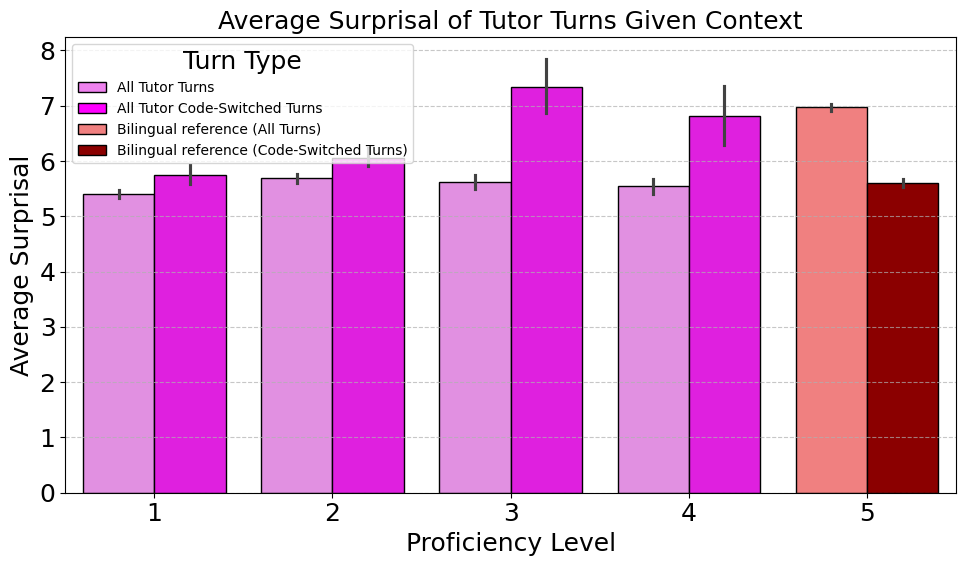

In [ ]:
# plot surprisal for all turns vs switched turns per level

import seaborn as sns


import matplotlib.pyplot as plt


import pandas as pd


import numpy as np


from matplotlib.patches import Patch



data = []


for level, surprisals in all_tutor_surprisals_per_level.items():

    data.extend(
        [
            {"Level": level, "Surprisal": -surprisal, "Type": "All Tutor Turns"}
            for surprisal in surprisals

        ]
    )



for level, surprisals in all_switched_tutor_surprisals_per_level.items():

    data.extend(
        [
            {"Level": level, "Surprisal": -surprisal, "Type": "Switched Tutor Turns"}
            for surprisal in surprisals

        ]
    )



df = pd.DataFrame(data)



plt.figure(figsize=(10, 6))


sns.barplot(
    x="Level",
    y="Surprisal",
    hue="Type",
    data=df,

    palette={"All Tutor Turns": "violet", "Switched Tutor Turns": "magenta"},
    edgecolor="black",
    ci=95,
    dodge=True,
)



for i, bar in enumerate(plt.gca().patches):


    if i == 4:

        bar.set_color("lightcoral")

        bar.set_edgecolor("black")

    elif i == 9:

        bar.set_color("darkred")

        bar.set_edgecolor("black")



legend_elements = [
    Patch(facecolor="violet", edgecolor="black", label="All Tutor Turns"),
    Patch(
        facecolor="magenta", edgecolor="black", label="All Tutor Code-Switched Turns"
    ),

    Patch(
        facecolor="lightcoral",

        edgecolor="black",
        label="Bilingual reference (All Turns)",
    ),

    Patch(
        facecolor="darkred",
        edgecolor="black",
        label="Bilingual reference (Code-Switched Turns)",
    ),

]


# Customize the plot


plt.xlabel("Proficiency Level")


plt.ylabel("Average Surprisal")


plt.title("Average Surprisal of Tutor Turns Given Context", fontsize=18)


plt.xticks(rotation=0)


plt.grid(axis="y", linestyle="--", alpha=0.7)


plt.legend(handles=legend_elements, title="Turn Type", loc="upper left", fontsize=10)


plt.tight_layout()



# Show the plot


plt.show()

In [238]:
all_avg_tutor_surprisals_per_level

{1: np.float64(5.402808447393949),
 2: np.float64(5.688917258125821),
 3: np.float64(5.6201511923586285),
 4: np.float64(5.542369588743037),
 5: np.float64(6.96976226270048)}

In [ ]:
# T-tests for surprisals for level vs level for all turns

from scipy.stats import ttest_ind, sem


import numpy as np
import pandas as pd



data = [
    {"Proficiency": level, "Surprisal": -surp}
    for level, surps in all_tutor_surprisals_per_level.items()
    for surp in surps

]



df = pd.DataFrame(data)



results = []


unique_proficiencies = df["Proficiency"].unique()


for i, prof1 in enumerate(unique_proficiencies):


    for prof2 in unique_proficiencies[i + 1 :]:

        group1 = df[df["Proficiency"] == prof1]["Surprisal"]

        group2 = df[df["Proficiency"] == prof2]["Surprisal"]

        t_stat, p_value = ttest_ind(group1, group2)


        # Calculate confidence intervals


        mean_diff = np.mean(group1) - np.mean(group2)

        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)

        ci_low = mean_diff - 1.96 * pooled_se

        ci_high = mean_diff + 1.96 * pooled_se


        results.append(
            {
                "Proficiency 1": prof1,
                "Proficiency 2": prof2,
                "T-statistic": f"{t_stat:.3f}",
                "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
                "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            }
        )



results_df = pd.DataFrame(results)


print(
    results_df.to_latex(
        index=False, caption="Pairwise t-tests for surprisals of all tutor turns"
    )
)

\begin{table}
\caption{Pairwise t-tests for surprisals of all tutor turns}
\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & -4.965 & 0.000* & [-0.398, -0.174] \\
1 & 3 & -2.871 & 0.004* & [-0.373, -0.062] \\
1 & 4 & -1.699 & 0.089 & [-0.308, 0.029] \\
1 & 5 & -24.970 & 0.000* & [-1.668, -1.466] \\
2 & 3 & 0.939 & 0.348 & [-0.083, 0.220] \\
2 & 4 & 1.810 & 0.070 & [-0.018, 0.311] \\
2 & 5 & -22.891 & 0.000* & [-1.376, -1.186] \\
3 & 4 & 0.767 & 0.443 & [-0.119, 0.275] \\
3 & 5 & -16.380 & 0.000* & [-1.493, -1.206] \\
4 & 5 & -14.851 & 0.000* & [-1.585, -1.270] \\
\bottomrule
\end{tabular}
\end{table}



<>:65: SyntaxWarning:

invalid escape sequence '\%'

<>:65: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\3004677824.py:65: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# T-tests for surprisals for level vs level for switched turns

from scipy.stats import ttest_ind, sem


import numpy as np
import pandas as pd



data = [
    {"Proficiency": level, "Surprisal": -surp}
    for level, surps in all_switched_tutor_surprisals_per_level.items()
    for surp in surps

]



df = pd.DataFrame(data)



results = []


unique_proficiencies = df["Proficiency"].unique()


for i, prof1 in enumerate(unique_proficiencies):


    for prof2 in unique_proficiencies[i + 1 :]:

        group1 = df[df["Proficiency"] == prof1]["Surprisal"]

        group2 = df[df["Proficiency"] == prof2]["Surprisal"]

        t_stat, p_value = ttest_ind(group1, group2)


        mean_diff = np.mean(group1) - np.mean(group2)

        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)

        ci_low = mean_diff - 1.96 * pooled_se

        ci_high = mean_diff + 1.96 * pooled_se


        results.append(
            {
                "Proficiency 1": prof1,
                "Proficiency 2": prof2,
                "T-statistic": f"{t_stat:.3f}",
                "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
                "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            }
        )



results_df = pd.DataFrame(results)


print(
    results_df.to_latex(
        index=False,
        caption="Pairwise t-tests for surprisals of code-switched tutor turns",
    )
)

\begin{table}
\caption{Pairwise t-tests for surprisals of code-switched tutor turns}
\begin{tabular}{rrlll}
\toprule
Proficiency 1 & Proficiency 2 & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & -2.495 & 0.013* & [-0.547, -0.066] \\
1 & 3 & -7.415 & 0.000* & [-2.119, -1.065] \\
1 & 4 & -4.579 & 0.000* & [-1.631, -0.495] \\
1 & 5 & 1.359 & 0.174 & [-0.041, 0.346] \\
2 & 3 & -6.285 & 0.000* & [-1.806, -0.765] \\
2 & 4 & -3.332 & 0.001* & [-1.319, -0.194] \\
2 & 5 & 4.596 & 0.000* & [0.283, 0.635] \\
3 & 4 & 1.370 & 0.172 & [-0.203, 1.261] \\
3 & 5 & 9.322 & 0.000* & [1.244, 2.245] \\
4 & 5 & 5.265 & 0.000* & [0.672, 1.759] \\
\bottomrule
\end{tabular}
\end{table}



<>:63: SyntaxWarning:

invalid escape sequence '\%'

<>:63: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2569442009.py:63: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# T-tests for surprisals for all vs switched turns per level


results = []


for level in all_switched_tutor_surprisals_per_level:


    group1 = [-x for x in all_tutor_surprisals_per_level[level]]

    group2 = [-x for x in all_switched_tutor_surprisals_per_level[level]]


    t_stat, p_value = ttest_ind(group1, group2)


    # Calculate confidence intervals


    mean_diff = np.mean(group1) - np.mean(group2)


    pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)

    ci_low = mean_diff - 1.96 * pooled_se

    ci_high = mean_diff + 1.96 * pooled_se


    results.append(
        {
            "Level": level,
            "T-statistic": f"{t_stat:.3f}",
            "P-value": f"{p_value:.3f}{"*" if p_value < 0.05 else ""}",
            "95\% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
        }
    )



results_df = pd.DataFrame(results)


print(
    results_df.to_latex(
        index=False,
        caption="Pairwise t-tests for surprisals of all vs switched turns within levels",
    )
)

\begin{table}
\caption{Pairwise t-tests for surprisals of all vs switched turns within levels}
\begin{tabular}{rlll}
\toprule
Level & T-statistic & P-value & 95\% CI \\
\midrule
1 & -3.166 & 0.002* & [-0.547, -0.153] \\
2 & -3.687 & 0.000* & [-0.548, -0.193] \\
3 & -7.780 & 0.000* & [-2.237, -1.212] \\
4 & -4.935 & 0.000* & [-1.832, -0.715] \\
5 & 25.027 & 0.000* & [1.276, 1.463] \\
\bottomrule
\end{tabular}
\end{table}



<>:37: SyntaxWarning:

invalid escape sequence '\%'

<>:37: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\280442260.py:37: SyntaxWarning:

invalid escape sequence '\%'



In [ ]:
# Preparing data for the overall analysis - negating

miami_all_surprisals = [-x for x in miami_all_surprisals]


miami_switched_surprisals = [-x for x in miami_switched_surprisals]

In [ ]:
# not interested in miami data in those dataframes anymore

del all_tutor_surprisals_per_level[5]


del all_switched_tutor_surprisals_per_level[5]

In [ ]:
# combining all surprisals for levels into one list for analysis and negating them to get positive values for plotting

all_tutor_surprisal = [
    -x
    for x in list(
        itertools.chain.from_iterable(
            [x for x in all_tutor_surprisals_per_level.values()]
        )
    )
]



all_switched_tutor_surprisal = [
    -x
    for x in list(
        itertools.chain.from_iterable(
            [x for x in all_switched_tutor_surprisals_per_level.values()]
        )
    )
]

In [245]:
np.mean(all_tutor_surprisal), np.mean(all_switched_tutor_surprisal), np.mean(
    miami_all_surprisals
), np.mean(miami_switched_surprisals)

(np.float64(5.572095095955255),
 np.float64(6.172644887429017),
 np.float64(6.96976226270048),
 np.float64(5.60039421653023))

In [246]:
[-np.mean(x) for x in all_tutor_surprisals_per_level.values()], [
    -np.mean(x) for x in all_switched_tutor_surprisals_per_level.values()
]

([np.float64(5.402808447393949),
  np.float64(5.688917258125821),
  np.float64(5.6201511923586285),
  np.float64(5.542369588743037)],
 [np.float64(5.752846191304751),
  np.float64(6.0595199609414125),
  np.float64(7.344879094465279),
  np.float64(6.815834616913515)])

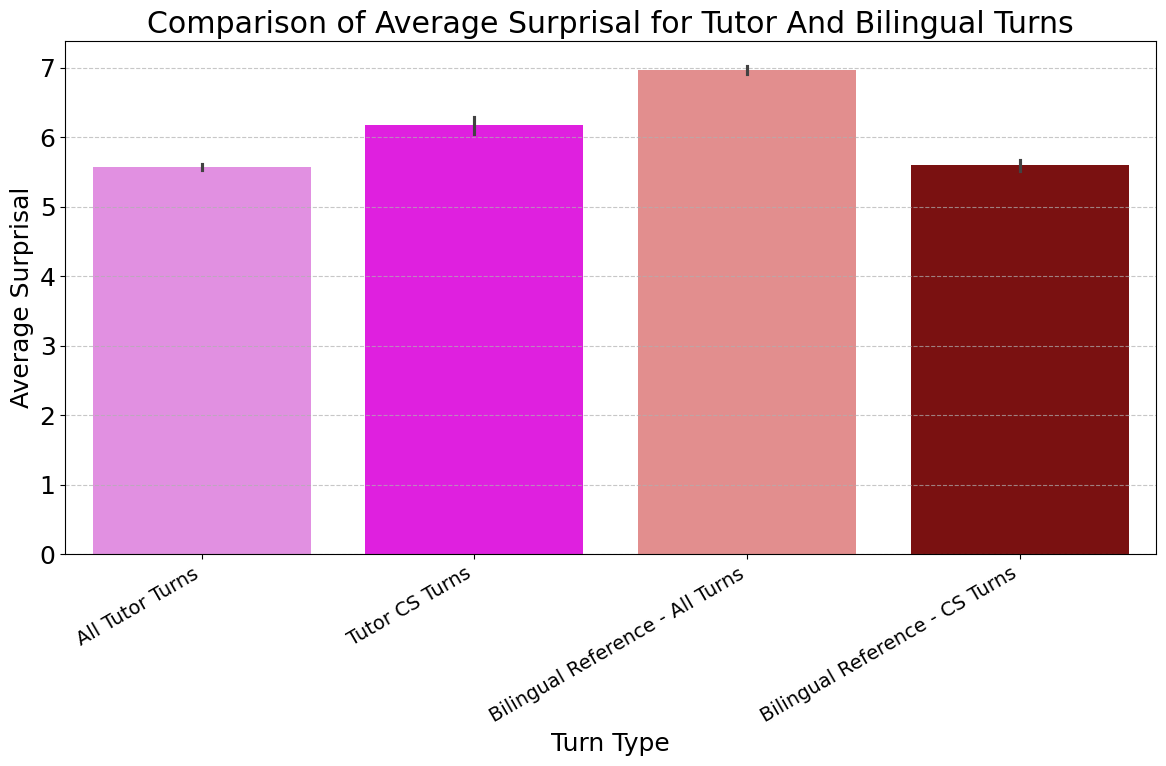

In [ ]:
# general plot for all vs switched for bilingual and tutoring dialogues

data = {
    "Category": ["All Tutor Turns"] * len(all_tutor_surprisal)
    + ["Tutor CS Turns"] * len(all_switched_tutor_surprisal)
    + ["Bilingual Reference - All Turns"] * len(miami_all_surprisals)
    + ["Bilingual Reference - CS Turns"] * len(miami_switched_surprisals),
    "Value": all_tutor_surprisal
    + all_switched_tutor_surprisal
    + miami_all_surprisals
    + miami_switched_surprisals,
}


df = pd.DataFrame(data)



plt.figure(figsize=(12, 8))


sns.barplot(
    x="Category",
    y="Value",
    data=df,

    ci=95,
    palette=["violet", "magenta", "lightcoral", "darkred"],
)



plt.title("Comparison of Average Surprisal for Tutor And Bilingual Turns")


plt.xlabel("Turn Type")


plt.ylabel("Average Surprisal")


plt.grid(axis="y", linestyle="--", alpha=0.7)


plt.xticks(rotation=30, ha="right", fontsize=14)



plt.tight_layout()


plt.show()

In [248]:
all_tutor_surprisal

[3.6686158180236816,
 3.6686158180236816,
 3.6686158180236816,
 3.6686158180236816,
 3.6686158180236816,
 3.6686158180236816,
 6.294196128845215,
 6.294196128845215,
 13.22665786743164,
 4.147518157958984,
 4.147518157958984,
 4.119771957397461,
 4.119771957397461,
 4.119771957397461,
 5.975432395935059,
 7.675605773925781,
 4.189126968383789,
 4.189126968383789,
 4.0529398918151855,
 4.0529398918151855,
 4.0529398918151855,
 4.0529398918151855,
 3.0761802196502686,
 3.2263360023498535,
 3.2263360023498535,
 3.2263360023498535,
 4.136411190032959,
 4.136411190032959,
 7.616443157196045,
 7.616443157196045,
 4.64055061340332,
 3.6597461700439453,
 3.6597461700439453,
 3.6597461700439453,
 14.362008094787598,
 6.383084774017334,
 11.266806602478027,
 11.266806602478027,
 4.062460899353027,
 4.062460899353027,
 4.062460899353027,
 4.062460899353027,
 8.857490539550781,
 10.789283752441406,
 7.042752742767334,
 5.5900654792785645,
 5.5900654792785645,
 3.7173428535461426,
 3.80306053161621

In [ ]:
# T-tests for surprisals for general categories


data = {
    "Category": ["All Tutor Turns"] * len(all_tutor_surprisal)
    + ["Tutor CS Turns"] * len(all_switched_tutor_surprisal)
    + ["Miami - All Turns"] * len(miami_all_surprisals)
    + ["Miami - CS Turns"] * len(miami_switched_surprisals),
    "Value": all_tutor_surprisal
    + all_switched_tutor_surprisal
    + miami_all_surprisals
    + miami_switched_surprisals,
}


df = pd.DataFrame(data)



categories = df["Category"].unique()


latex_table_data = []



for i, cat1 in enumerate(categories):


    for cat2 in categories[i + 1 :]:

        group1 = df[df["Category"] == cat1]["Value"]

        group2 = df[df["Category"] == cat2]["Value"]

        t_stat, p_value = ttest_ind(group1, group2)


        # Calculate confidence intervals


        mean_diff = np.mean(group1) - np.mean(group2)

        pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


        ci_low = mean_diff - 1.96 * pooled_se

        ci_high = mean_diff + 1.96 * pooled_se


        latex_table_data.append(
            [
                cat1,
                cat2,
                f"{t_stat:.3f}",
                f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                f"[{ci_low:.3f}, {ci_high:.3f}]",
            ]
        )



print(
    pd.DataFrame(
        latex_table_data,
        columns=["Category 1", "Category 2", "T-statistic", "P-value", "95\% CI"],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for Surprisal Values",
        position="h!",
        label="tab-stats-surprisal-categories",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for Surprisal Values}
\label{tab-stats-surprisal-categories}
\begin{tabular}{lllll}
\toprule
Category 1 & Category 2 & T-statistic & P-value & 95\% CI \\
\midrule
All Tutor Turns & Tutor CS Turns & -8.626 & 0.0000* & [-0.734, -0.467] \\
All Tutor Turns & Miami - All Turns & -35.265 & 0.0000* & [-1.473, -1.322] \\
All Tutor Turns & Miami - CS Turns & -0.623 & 0.5335 & [-0.116, 0.060] \\
Tutor CS Turns & Miami - All Turns & -9.066 & 0.0000* & [-0.934, -0.660] \\
Tutor CS Turns & Miami - CS Turns & 7.779 & 0.0000* & [0.428, 0.716] \\
Miami - All Turns & Miami - CS Turns & 25.027 & 0.0000* & [1.276, 1.463] \\
\bottomrule
\end{tabular}
\end{table}



<>:72: SyntaxWarning:

invalid escape sequence '\%'

<>:72: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\861798989.py:72: SyntaxWarning:

invalid escape sequence '\%'



### Inspecting an example dialogue


In [250]:
example_dialogue = master_df[master_df["FileID"] == "1AiL15"].reset_index()

# Group by 'Turn' and update 'InterSwitch' and 'IntraSwitch'
for turn, group in example_dialogue.groupby("Turn"):
    if group["InterSwitch"].any():
        example_dialogue.loc[group.index, "InterSwitch"] = True
    if group["IntraSwitch"].any():
        example_dialogue.loc[group.index, "IntraSwitch"] = True

example_dialogue

,index,UtteranceID,FileID,Corpus,Group,Proficiency,Participant,PrevPar,UtteranceLang,LangRole,...,LastCS,MatrixLangWords,EmbedLangWords,Translation,nWords,Turn,TurnTranslation,TurnLanguage,PrevTurn,PrevTurnTrans
0,13244,1AiL151,1AiL15,BELC,Group A,1,INV,,english,Matrix Language,...,False,and how old are you,,None,5,and how old are you how old are you nine ten e...,and how old are you how old are you nine ten e...,english,None,None
1,13245,1AiL152,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,how old are you,,None,4,and how old are you how old are you nine ten e...,and how old are you how old are you nine ten e...,english,None,None
2,13246,1AiL153,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,nine ten eleven,,None,3,and how old are you how old are you nine ten e...,and how old are you how old are you nine ten e...,english,None,None
3,13247,1AiL154,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,how old are you,,None,4,and how old are you how old are you nine ten e...,and how old are you how old are you nine ten e...,english,None,None
4,13248,1AiL155,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,no,,None,1,and how old are you how old are you nine ten e...,and how old are you how old are you nine ten e...,english,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,13336,1AiL1593,1AiL15,BELC,Group A,1,CAR,INV,spanish/catalan,Embedded Language,...,True,,tens fills,Ten children,2,tens fills,Ten children,spanish/catalan,my family yes I have two daughters and I have ...,my family yes I have two daughters and I have ...
93,13337,1AiL1594,1AiL15,BELC,Group A,1,INV,CAR,english,Matrix Language,...,True,in english,,None,2,in english yes I have two daughters two girls ...,in english yes I have two daughters two girls ...,english,tens fills,Ten children
94,13338,1AiL1595,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,yes I have two daughters two girls two girls,,None,9,in english yes I have two daughters two girls ...,in english yes I have two daughters two girls ...,english,tens fills,Ten children
95,13339,1AiL1596,1AiL15,BELC,Group A,1,INV,INV,english,Matrix Language,...,False,more questions,,None,2,in english yes I have two daughters two girls ...,in english yes I have two daughters two girls ...,english,tens fills,Ten children


In [251]:
example_dialogue = (
    example_dialogue[["Turn", "PrevTurn", "Participant", "InterSwitch", "IntraSwitch"]]
    .drop_duplicates()
    .reset_index()
)  # only retaining the pertinent data
example_dialogue

,index,Turn,PrevTurn,Participant,InterSwitch,IntraSwitch
0,0,and how old are you how old are you nine ten e...,None,INV,False,True
1,8,onze,and how old are you how old are you nine ten e...,CAR,True,False
2,9,onze and do you like this school do you like t...,onze,INV,True,False
3,12,sí,onze and do you like this school do you like t...,CAR,True,False
4,13,yes why do you like this school,sí,INV,True,False
5,15,reiscatòlics,yes why do you like this school,CAR,True,False
6,16,uhhuh and hm hm let's talk about your family y...,reiscatòlics,INV,True,False
7,19,Un hermano Un germà,uhhuh and hm hm let's talk about your family y...,CAR,True,False
8,20,in english,Un hermano Un germà,INV,True,False
9,21,brother,in english,CAR,False,False


In [252]:
example_dialogue[
    (
        (example_dialogue["IntraSwitch"] == True)
        | (example_dialogue["InterSwitch"] == True)
    )
    & (example_dialogue["Participant"] == "INV")
]

,index,Turn,PrevTurn,Participant,InterSwitch,IntraSwitch
0,0,and how old are you how old are you nine ten e...,None,INV,False,True
2,9,onze and do you like this school do you like t...,onze,INV,True,False
4,13,yes why do you like this school,sí,INV,True,False
6,16,uhhuh and hm hm let's talk about your family y...,reiscatòlics,INV,True,False
8,20,in english,Un hermano Un germà,INV,True,False
14,29,spanish and with with your parents and with yo...,castellà,INV,True,False
20,49,yes what's the name of this big city,sí,INV,True,False
26,69,have you four four rooms have you got a room y...,four,INV,True,False
30,93,in english yes I have two daughters two girls ...,tens fills,INV,True,False


In [253]:
with open("pickle/example_dialogue.pkl", "wb") as file:
    pickle.dump(
        example_dialogue, file
    )  # needeed to calculate surprial by an external script

In [254]:
example_dialogue = pickle.load(
    open("pickle/example_dialogue_with_surprisal_new.pkl", "rb")
)  # obtained from an external script

In [255]:
example_dialogue["Surprisal"] = -example_dialogue[
    "Surprisal"
]  # negating to get positive values

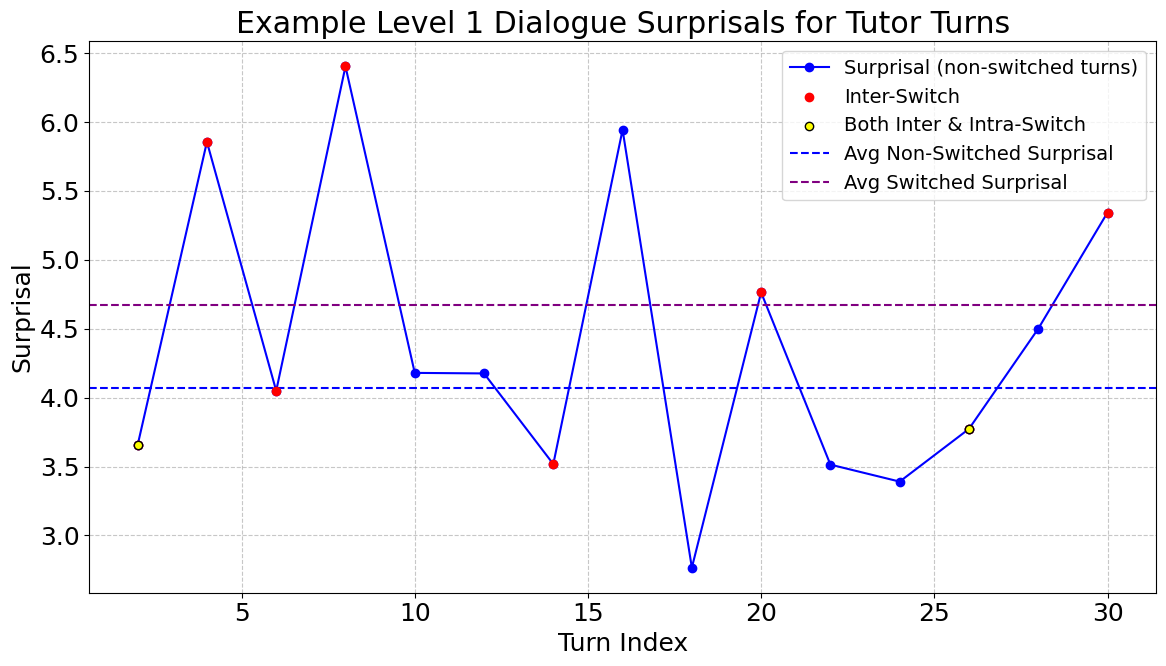

In [256]:
# Filter for tutor turns
tutor_turns = example_dialogue[example_dialogue["Participant"] == "INV"]

# Fix wrong annotations

tutor_turns.loc[2, "IntraSwitch"] = True
tutor_turns.loc[26, "IntraSwitch"] = True

turn_indices = tutor_turns.index
surprisals = tutor_turns["Surprisal"]
inter_switch = tutor_turns["InterSwitch"]
intra_switch = tutor_turns["IntraSwitch"]

avg_non_switched_surprisal = surprisals[~(inter_switch | intra_switch)].mean()
avg_switched_surprisal = surprisals[(inter_switch | intra_switch)].mean()

plt.figure(figsize=(12, 7))
plt.plot(
    turn_indices,
    surprisals,
    marker="o",
    label="Surprisal (non-switched turns)",
    color="blue",
)

plt.scatter(
    turn_indices[inter_switch],
    surprisals[inter_switch],
    color="red",
    label="Inter-Switch",
    zorder=5,
)


both_switch = inter_switch & intra_switch
plt.scatter(
    turn_indices[both_switch],
    surprisals[both_switch],
    color="yellow",
    edgecolor="black",
    label="Both Inter & Intra-Switch",
    zorder=6,
)

plt.axhline(
    avg_non_switched_surprisal,
    color="blue",
    linestyle="--",
    label="Avg Non-Switched Surprisal",
)
plt.axhline(
    avg_switched_surprisal,
    color="purple",
    linestyle="--",
    label="Avg Switched Surprisal",
)

plt.xlabel("Turn Index")
plt.ylabel("Surprisal")
plt.title("Example Level 1 Dialogue Surprisals for Tutor Turns")
plt.legend(fontsize=14, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [257]:
# highest surprisal examples analysis

print(
    example_dialogue[

        (example_dialogue["Surprisal"] > 5) & (example_dialogue["Participant"] == "INV")
    ]

    .reset_index()[["Turn", "PrevTurn", "Surprisal", "InterSwitch", "IntraSwitch"]]
    .to_latex(index=False)
)

\begin{tabular}{llrll}
\toprule
Turn & PrevTurn & Surprisal & InterSwitch & IntraSwitch \\
\midrule
yes why do you like this school & sí & 5.856043 & True & False \\
in english & Un hermano Un germà & 6.403968 & True & False \\
spanish and with your mother & spanish & 5.943982 & False & False \\
in english yes I have two daughters two girls two girls more questions now & tens fills & 5.343310 & True & False \\
\bottomrule
\end{tabular}



In [ ]:
# lowest surprisal examples analysis

print(
    example_dialogue[
        (example_dialogue["Surprisal"] < 4) & (example_dialogue["Participant"] == "INV")
    ]

    .reset_index()[["Turn", "PrevTurn", "Surprisal", "InterSwitch", "IntraSwitch"]]
    .to_latex(index=False)
)

\begin{tabular}{llrll}
\toprule
Turn & PrevTurn & Surprisal & InterSwitch & IntraSwitch \\
\midrule
onze and do you like this school do you like this school & onze & 3.655812 & True & False \\
spanish and with with your parents and with your father with your mother with your father which language do you speak with your father & castellà & 3.517586 & True & False \\
spanish too where do you live where do you live hm where do you live in a big city in a village where where do you live in a big city & spanish & 2.765843 & False & False \\
ah okay and how many people live in your house how many people your father your mother yes who else together in the family how many people your father your mother & Barcelona & 3.513655 & False & False \\
yes and that's all and you and you and hm how many rooms are there in your house how many rooms this is a room one two three four & your brother & 3.390375 & False & False \\
have you four four rooms have you got a room yes a room for you now tell me ab

# Survey results


In [ ]:
import pandas as pd

survey_results = pd.read_csv("Master+Students_28+April+2025_14.22/res.csv")

In [260]:
likert_mapping = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
}

In [ ]:
# having a look into the bacckground section results

background_ids = [f"QID{id}" for id in range(2, 11)]


background_section_results = survey_results[background_ids].copy()


background_section_results["QID10"] = background_section_results["QID10"].apply(
    lambda x: likert_mapping[x] if x in likert_mapping else x
)
background_section_results

In [262]:
background_section_results["QID10"][0]

'When learning a second language, do you like when the teacher uses your native language in the dialogue?'

In [263]:
avg_agr = background_section_results["QID10"][2:].mean()
print(
    f"Average agreement with the statement:\n{background_section_results['QID10'][0]}\nis {avg_agr:.2f} out of 5."
)

Average agreement with the statement:
When learning a second language, do you like when the teacher uses your native language in the dialogue?
is 2.88 out of 5.


In [ ]:
survey_results_full = survey_results.loc[
    survey_results["Progress"] == "100"
]  # filtering out incomplete surveys

# Gathering question information useful for analysis


question_meta = [
    {
        f"Group {i}": [
            {
                "QuestionNr": n,
                "Language": survey_results_full[f"Group_{i}_Language_{n}"].values[0],
                "Intent": survey_results_full[f"Group_{i}_Topic_{n}"].values[0],
                "QIDs": [
                    f"QID{id}"
                    for id in list(
                        range(
                            (108 * (i - 1) + 11 + (n - 1) * 9),
                            (108 * (i - 1) + 11 + n * 9),
                        )
                    )
                ],
            }
            for n in range(1, 13)
        ]
    }
    for i in range(1, 6)
]


question_meta

[{'Group 1': [{'QuestionNr': 1,
    'Language': 'tutor-es',
    'Intent': 'topics',
    'QIDs': ['QID11',
     'QID12',
     'QID13',
     'QID14',
     'QID15',
     'QID16',
     'QID17',
     'QID18',
     'QID19']},
   {'QuestionNr': 2,
    'Language': 'tutor-es',
    'Intent': 'backchannel',
    'QIDs': ['QID20',
     'QID21',
     'QID22',
     'QID23',
     'QID24',
     'QID25',
     'QID26',
     'QID27',
     'QID28']},
   {'QuestionNr': 3,
    'Language': 'tutor-en',
    'Intent': 'topics',
    'QIDs': ['QID29',
     'QID30',
     'QID31',
     'QID32',
     'QID33',
     'QID34',
     'QID35',
     'QID36',
     'QID37']},
   {'QuestionNr': 4,
    'Language': 'tutor-en',
    'Intent': 'backchannel',
    'QIDs': ['QID38',
     'QID39',
     'QID40',
     'QID41',
     'QID42',
     'QID43',
     'QID44',
     'QID45',
     'QID46']},
   {'QuestionNr': 5,
    'Language': 'tutor-en',
    'Intent': 'questions',
    'QIDs': ['QID47',
     'QID48',
     'QID49',
     'QID50',
   

In [265]:
def find_group_and_question(target_qid):
    for i in range(6):
        for group_name, questions in question_meta[i].items():
            for question in questions:
                if target_qid in question["QIDs"]:
                    return group_name, question["QuestionNr"]
    return None, None  # Return None if the QID is not found

In [ ]:
for col_name in survey_results.columns:

    if "QID" in col_name:

        if ((11 - int(col_name[3:])) % 9 == 0) and int(
            col_name[3:]
        ) > 10:  # mapping the QIDs to the questions

            tutor_utt = (
                survey_results[col_name][0]
                .split("Dialogue Fragment:\n\n")[1]
                .split("\n\n\n\n")[0]
                .strip()

                .split("Tutor: ")[1]
                .strip()

            )  # extracting the tutor utterance


            try:

                prev_utt = (
                    survey_results[col_name][0]
                    .split("Dialogue Fragment:\n\n")[1]
                    .split("\n\n\n\n")[0]
                    .strip()

                    .split("STUDENT: ")[3]
                    .split("\n")[0]
                    .strip()

                )  # extracting the previous utterance


            except:  # one of the questions needs to be tackled differently

                prev_utt = (
                    survey_results[col_name][0]
                    .split("Dialogue Fragment:\n\n")[1]
                    .split("\n\n\n\n")[0]
                    .strip()

                    .split("STUDENT: ")[2]
                    .split("\n")[0]
                    .strip()

                )

            # getting the proficiency level for analysis

            try:

                proficiency = all_tutor_switched_utts.loc[
                    (all_tutor_switched_utts["Turn"] == tutor_utt)
                    & (all_tutor_switched_utts["PrevTurn"] == prev_utt)
                ]["Proficiency"].values[0]

            except:

                proficiency = all_tutor_switched_utts.loc[
                    (all_tutor_switched_utts["Turn"] == tutor_utt.strip())
                ]["Proficiency"].values[0]

            group, question = find_group_and_question(col_name)

            group_nr = int(group.split(" ")[1])

            question_meta[group_nr - 1][group][question - 1][
                "Proficiency"
            ] = proficiency

In [267]:
survey_results = survey_results.loc[survey_results["Progress"] == "100"].reset_index(
    drop=True
)
# survey_res_grouped = survey_results.loc[survey_results["Progress"] == 100].groupby('group')

In [268]:
question_mapping = (
    {  # for each sample this is the order. Each sample starts with (11 + multiple of 9)
        1: "Clarity",
        2: "Intent",
        3: "intent_other",
        4: "Normalness",
        5: "Helpfulness",
        6: "Likeability",
        7: "improve_general",
        8: "Multilingualism",
        9: "improve_multilingual",
    }
)

In [269]:
answers_grouped = survey_results.groupby("group", sort=True)

In [ ]:
# making a mapping of question ids to metadata

qid_to_intent = {}


qid_to_level = {}


qid_to_language = {}
for group in question_meta:


    for item in group.values():
        for q_info in item:


            intent = q_info["Intent"]


            level = q_info["Proficiency"]

            language = q_info["Language"]

            for qid in q_info["QIDs"]:

                qid_to_intent[qid] = intent

                qid_to_level[qid] = level

                qid_to_language[qid] = language



intent_dfs = {
    "backchannel": pd.DataFrame(),
    "questions": pd.DataFrame(),

    "topics": pd.DataFrame(),
}


level_dfs = {
    1: pd.DataFrame(),
    2: pd.DataFrame(),
    3: pd.DataFrame(),
    4: pd.DataFrame(),
}


language_dfs = {
    "tutor-en": pd.DataFrame(),
    "tutor-es": pd.DataFrame(),
    "tutor-mixed": pd.DataFrame(),
}

In [271]:
for group, group_df in answers_grouped:
    non_nan_columns = group_df.columns[group_df.notna().all()].tolist()
    group_df = group_df[non_nan_columns].reset_index(drop=True)
    intent_grouped_df = {}
    level_grouped_df = {}
    language_grouped_df = {}
    for col in group_df.columns:
        if col in qid_to_intent.keys():
            intent = qid_to_intent[col]
            level = qid_to_level[col]
            language = qid_to_language[col]

            if intent not in intent_grouped_df:
                intent_grouped_df[intent] = []
            intent_grouped_df[intent].append(col)

            if level not in level_grouped_df:
                level_grouped_df[level] = []
            level_grouped_df[level].append(col)

            if language not in language_grouped_df:
                language_grouped_df[language] = []
            language_grouped_df[language].append(col)

    print(language_grouped_df)

    for intent, qids in intent_grouped_df.items():
        intent_dfs[intent] = pd.concat(
            [intent_dfs[intent], group_df[qids]], ignore_index=True
        )
    for level, qids in level_grouped_df.items():
        level_dfs[level] = pd.concat(
            [level_dfs[level], group_df[qids]], ignore_index=True
        )
    for language, qids in language_grouped_df.items():
        language_dfs[language] = pd.concat(
            [language_dfs[language], group_df[qids]], ignore_index=True
        )

{'tutor-es': ['QID119', 'QID120', 'QID122', 'QID123', 'QID124', 'QID125', 'QID126', 'QID191', 'QID192', 'QID194', 'QID195', 'QID196', 'QID197', 'QID198'], 'tutor-en': ['QID128', 'QID129', 'QID131', 'QID132', 'QID133', 'QID134', 'QID135', 'QID155', 'QID156', 'QID157', 'QID158', 'QID159', 'QID160', 'QID161', 'QID162', 'QID163', 'QID173', 'QID174', 'QID176', 'QID177', 'QID178', 'QID179', 'QID180', 'QID200', 'QID201', 'QID203', 'QID204', 'QID205', 'QID206', 'QID207', 'QID209', 'QID210', 'QID212', 'QID213', 'QID214', 'QID216', 'QID218', 'QID219', 'QID220', 'QID221', 'QID222', 'QID223', 'QID225'], 'tutor-mixed': ['QID137', 'QID138', 'QID139', 'QID140', 'QID141', 'QID142', 'QID143', 'QID144', 'QID145', 'QID146', 'QID147', 'QID148', 'QID149', 'QID150', 'QID151', 'QID152', 'QID153', 'QID154', 'QID164', 'QID165', 'QID167', 'QID168', 'QID169', 'QID170', 'QID171', 'QID182', 'QID183', 'QID185', 'QID186', 'QID187', 'QID189']}
{'tutor-en': ['QID227', 'QID228', 'QID229', 'QID230', 'QID231', 'QID232', 

In [272]:
intent_dfs["backchannel"]

,QID119,QID120,QID122,QID123,QID124,QID125,QID126,QID137,QID138,QID139,...,QID527,QID528,QID529,QID531,QID542,QID543,QID545,QID546,QID547,QID549
0,Somewhat disagree,Acknowlegment,Somewhat agree,Somewhat disagree,Strongly disagree,The tutor should be using longer and clearer s...,Neither agree nor disagree,Neither agree nor disagree,Other,Asking more questions for the student to keep ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree,Translation,Somewhat agree,Somewhat agree,Neither agree nor disagree,Somewhat agree
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Somewhat agree,Translation,Somewhat agree,Somewhat agree,Somewhat agree,Somewhat agree


In [273]:
formatted_intent_dfs = {intent: {} for intent in intent_dfs.keys()}
levels = []
languages = []
for intent, df in intent_dfs.items():
    new_df = {q: [] for q in question_mapping.values()}
    new_df["Language"] = []
    new_df["Level"] = []
    prev_qid = -999
    for i, column in enumerate(df.columns):
        qid = int(column[3:])
        mapped = question_mapping[(qid - 11) % 9 + 1]
        answers = df[column].dropna()
        if mapped not in [  # non-quantitative columns
            "Intent",
            "intent_other",
            "improve_general",
            "improve_multilingual",
        ]:
            answers = [likert_mapping[val] for val in answers]
        new_df[mapped].extend(answers)

        if mapped == "Multilingualism" and f"QID{qid+1}" not in df.columns:
            new_df[question_mapping[(qid - 10) % 9 + 1]].extend([None] * len(answers))

        if prev_qid == qid - 2 and mapped != "Clarity":
            new_df[question_mapping[(qid - 12) % 9 + 1]].extend([None] * len(answers))

        language = qid_to_language[column]
        level = qid_to_level[column]

        if (qid - 11) % 9 == 0:
            new_df["Language"].extend([language] * len(answers))
            new_df["Level"].extend([level] * len(answers))

        prev_qid = qid

    new_df = pd.DataFrame(new_df)
    formatted_intent_dfs[intent] = new_df

In [274]:
formatted_intent_dfs["backchannel"]

,Clarity,Intent,intent_other,Normalness,Helpfulness,Likeability,improve_general,Multilingualism,improve_multilingual,Language,Level
0,2,Acknowlegment,None,4,2,1,The tutor should be using longer and clearer s...,3,None,tutor-es,1
1,3,Other,Asking more questions for the student to keep ...,4,1,1,The teacher should be speaking English when as...,1,Inappropriate \nThe teacher should be speaking...,tutor-mixed,2
2,5,Other,Continuing the conversation,4,4,3,The teacher should be using longer sentences,5,The tutor should only be speaking English unle...,tutor-en,3
3,3,Clarification,None,4,4,3,Perhaps trying to reiterate the question in En...,4,None,tutor-en,2
4,4,Other,Suggestion,3,4,4,Difficult to say without broader context.,4,The tutor does not use multilinguality in this...,tutor-en,2
5,4,Other,Express misunderstanding,4,2,2,Try to express more comprehension,2,Try to understand better what the student is s...,tutor-es,1
6,5,Translation,None,2,2,2,It's a bit unclear what the teacher is answeri...,4,None,tutor-mixed,2
7,4,Acknowlegment,None,4,2,3,None,4,None,tutor-en,3
8,1,Other,corrected transcription\n\nSTUDENT: my hobby\n...,4,4,2,"so you do. What else, what other tv shows do y...",3,I think it's good to translate the title of th...,tutor-mixed,2
9,1,Other,The teacher is asking the student what other t...,1,1,1,What other tv programmes do you like?,1,I don't know.,tutor-mixed,2


In [275]:
formatted_level_dfs = {level: {} for level in level_dfs.keys()}

for level, df in level_dfs.items():
    new_df = {q: [] for q in question_mapping.values()}
    new_df["Language"] = []
    new_df["Intent_Real"] = []
    for column in df.columns:
        qid = int(column[3:])
        mapped = question_mapping[(qid - 11) % 9 + 1]
        answers = df[column].dropna()
        if mapped not in [
            "Intent",
            "intent_other",
            "improve_general",
            "improve_multilingual",
        ]:
            answers = [likert_mapping[val] for val in answers]
        new_df[mapped].extend(answers)

        language = qid_to_language[column]
        intent = qid_to_intent[column]

        if (qid - 11) % 9 == 0:
            new_df["Language"].extend([language] * len(answers))
            new_df["Intent_Real"].extend([intent] * len(answers))

    # Ensure all lists in new_df have the same length
    max_length = max(len(lst) for lst in new_df.values())
    for key in new_df:
        new_df[key].extend([None] * (max_length - len(new_df[key])))

    new_df = pd.DataFrame(new_df)
    formatted_level_dfs[level] = new_df

In [276]:
formatted_language_dfs = {language: {} for language in language_dfs.keys()}

for language, df in language_dfs.items():
    new_df = {q: [] for q in question_mapping.values()}
    new_df["Level"] = []
    new_df["Intent_Real"] = []
    for column in df.columns:
        qid = int(column[3:])
        mapped = question_mapping[(qid - 11) % 9 + 1]
        answers = df[column].dropna()
        if mapped not in [
            "Intent",
            "intent_other",
            "improve_general",
            "improve_multilingual",
        ]:
            answers = [likert_mapping[val] for val in answers]
        new_df[mapped].extend(answers)

        level = qid_to_level[column]
        intent = qid_to_intent[column]

        if (qid - 11) % 9 == 0:
            new_df["Level"].extend([level] * len(answers))
            new_df["Intent_Real"].extend([intent] * len(answers))

    # Ensure all lists in new_df have the same length
    max_length = max(len(lst) for lst in new_df.values())
    for key in new_df:
        new_df[key].extend([None] * (max_length - len(new_df[key])))

    new_df = pd.DataFrame(new_df)
    formatted_language_dfs[language] = new_df

In [277]:
for level in formatted_level_dfs.items():
    print(f"Level {level[0]} Length: {len(level[1])}")

Level 1 Length: 25
Level 2 Length: 37
Level 3 Length: 5
Level 4 Length: 5


In [278]:
for language in formatted_language_dfs.items():
    print(f"language {language[0]} Length: {len(language[1])}")

language tutor-en Length: 36
language tutor-es Length: 12
language tutor-mixed Length: 24


In [279]:
formatted_level_dfs[4]

,Clarity,Intent,intent_other,Normalness,Helpfulness,Likeability,improve_general,Multilingualism,improve_multilingual,Language,Intent_Real
0,5,Other,Continuing the conversation,5,5,4,None,5,None,tutor-en,topics
1,5,Other,change topic,5,5,5,None,5,None,tutor-en,questions
2,5,Other,Make the student engage more actively in the c...,4,4,4,None,4,None,tutor-en,questions
3,5,Acknowlegment,None,5,4,4,None,4,None,tutor-en,backchannel
4,5,Other,None,5,5,5,None,5,None,tutor-en,backchannel


In [280]:
formatted_intent_dfs["backchannel"]

,Clarity,Intent,intent_other,Normalness,Helpfulness,Likeability,improve_general,Multilingualism,improve_multilingual,Language,Level
0,2,Acknowlegment,None,4,2,1,The tutor should be using longer and clearer s...,3,None,tutor-es,1
1,3,Other,Asking more questions for the student to keep ...,4,1,1,The teacher should be speaking English when as...,1,Inappropriate \nThe teacher should be speaking...,tutor-mixed,2
2,5,Other,Continuing the conversation,4,4,3,The teacher should be using longer sentences,5,The tutor should only be speaking English unle...,tutor-en,3
3,3,Clarification,None,4,4,3,Perhaps trying to reiterate the question in En...,4,None,tutor-en,2
4,4,Other,Suggestion,3,4,4,Difficult to say without broader context.,4,The tutor does not use multilinguality in this...,tutor-en,2
5,4,Other,Express misunderstanding,4,2,2,Try to express more comprehension,2,Try to understand better what the student is s...,tutor-es,1
6,5,Translation,None,2,2,2,It's a bit unclear what the teacher is answeri...,4,None,tutor-mixed,2
7,4,Acknowlegment,None,4,2,3,None,4,None,tutor-en,3
8,1,Other,corrected transcription\n\nSTUDENT: my hobby\n...,4,4,2,"so you do. What else, what other tv shows do y...",3,I think it's good to translate the title of th...,tutor-mixed,2
9,1,Other,The teacher is asking the student what other t...,1,1,1,What other tv programmes do you like?,1,I don't know.,tutor-mixed,2


In [ ]:
# exploring other columns

for i, row in formatted_intent_dfs["backchannel"][
    ["Intent", "intent_other"]
].iterrows():

    if row["intent_other"] is not None:

        print(f"Row {i}: {row['Intent']}")

        print(f"Row {i}: {row['intent_other']}\n")

Row 1: Other
Row 1: Asking more questions for the student to keep replying 

Row 2: Other
Row 2: Continuing the conversation 

Row 4: Other
Row 4: Suggestion

Row 5: Other
Row 5: Express misunderstanding

Row 8: Other
Row 8: corrected transcription

STUDENT: my hobby
TUTOR: now yes, but what programmes tv programmes you like?
STUDENT: ah, "de todo" (de todo =  everything)
TUTOR: everything, bola de drac you like? (bola de drac = dragon ball)
STUDENT: yes
Tutor: you do. what else, what other programmes sensetítol? 

i don't understand why it says sensetítol. "sense títol" = untitled (without title). tutor seems to be following the conversation but that word doesn't make sense there

Row 9: Other
Row 9: The teacher is asking the student what other tv programmes he/she likes.



In [282]:
plt.rcParams.update({"font.size": 20})

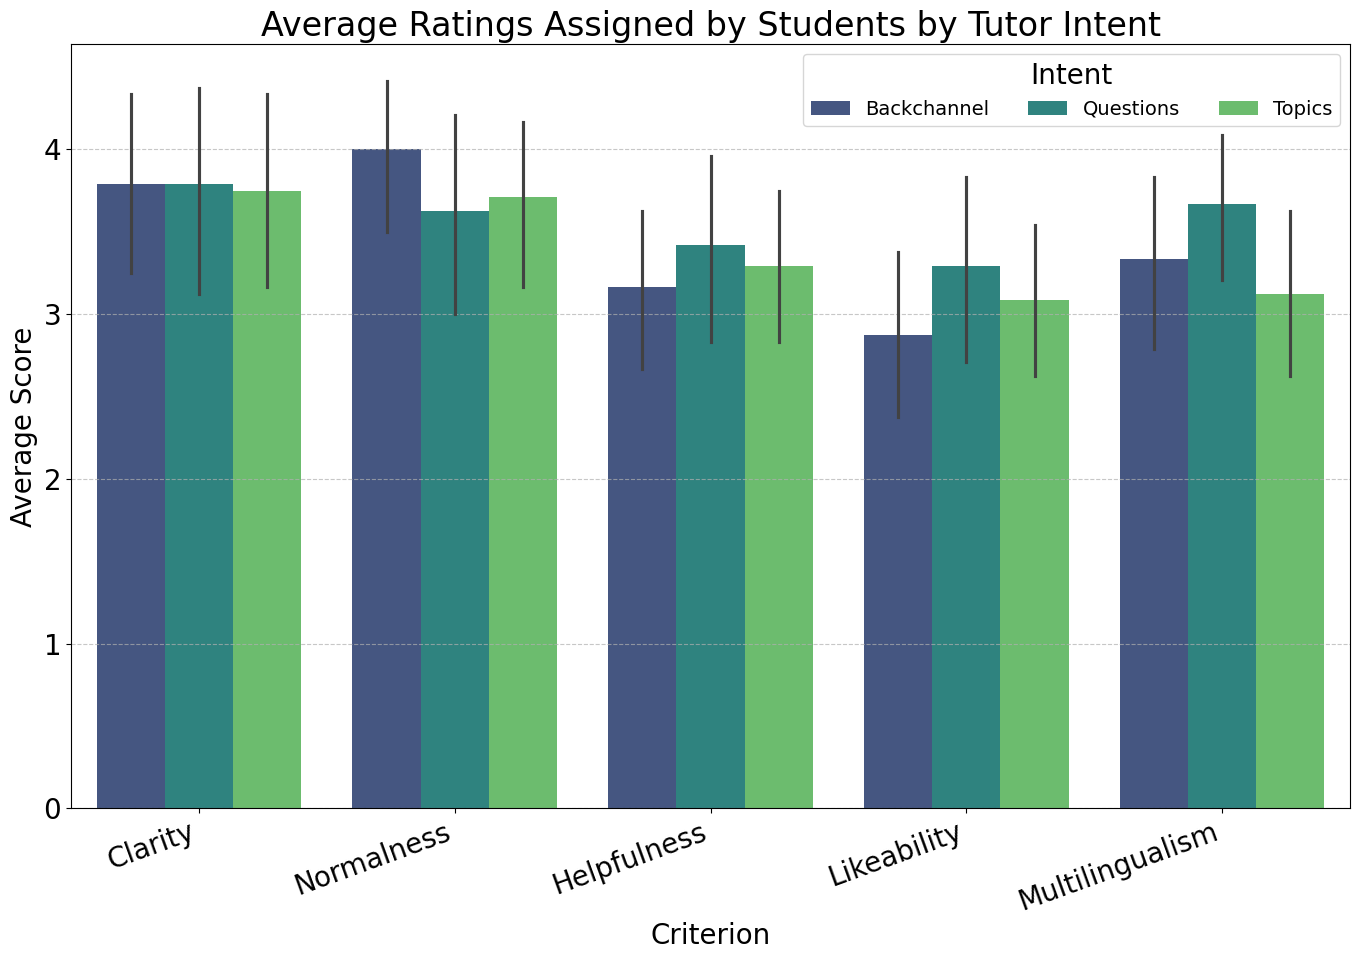

In [283]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# Plot numerical ratings per intent

plot_data = []
for intent, df in formatted_intent_dfs.items():
    for column in df.columns:
        if (
            df[column].dtype in [float, int] and column != "Level"
        ):  # Only considering numeric columns
            for value in df[column]:
                plot_data.append(
                    {
                        "Intent": intent.capitalize(),
                        "Question": column.capitalize(),
                        "Score": value,
                    }
                )

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 10))
sns.barplot(
    x="Question",
    y="Score",
    hue="Intent",
    data=plot_df,
    errorbar=("ci", 95),
    palette="viridis",
)

plt.title("Average Ratings Assigned by Students by Tutor Intent")
plt.xlabel("Criterion")
plt.ylabel("Average Score")
plt.xticks(
    rotation=20,
    ha="right",
)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Intent", loc="upper right", fontsize=14, ncol=len(df.columns))

plt.tight_layout()
plt.show()

In [ ]:
# T-tests

formatted_intent_dfs_numerical = {
    intent: df.select_dtypes(include=[float, int]).drop(columns=["Level"])
    for intent, df in formatted_intent_dfs.items()

}


all_criteria = set()


for intent_data in formatted_intent_dfs_numerical.values():

    all_criteria.update(intent_data.keys())


all_criteria = sorted(list(all_criteria))



all_intents = sorted(list(formatted_intent_dfs_numerical.keys()))



latex_table_data = []



for crit in all_criteria:

    for i, intent1 in enumerate(all_intents):


        for intent2 in all_intents[i + 1 :]:

            try:

                group1 = [sim for sim in formatted_intent_dfs_numerical[intent1][crit]]

                group2 = [sim for sim in formatted_intent_dfs_numerical[intent2][crit]]

            except KeyError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals

            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)

            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    intent1.capitalize(),
                    intent2.capitalize(),
                    crit.capitalize(),
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(

    pd.DataFrame(
        latex_table_data,
        columns=[
            "Intent 1",
            "Intent 2",
            "Criterion",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for scores assigned by students by tutor intent",
        position="h!",
        label="tab-stats-simrisals-levels-by-crit",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for scores assigned by students by tutor intent}
\label{tab-stats-simrisals-levels-by-crit}
\begin{tabular}{llllll}
\toprule
Intent 1 & Intent 2 & Criterion & T-statistic & P-value & 95\% CI \\
\midrule
Backchannel & Questions & Clarity & 0.000 & 1.0000 & [-0.834, 0.834] \\
Backchannel & Topics & Clarity & 0.101 & 0.9202 & [-0.769, 0.852] \\
Questions & Topics & Clarity & 0.097 & 0.9234 & [-0.803, 0.886] \\
Backchannel & Questions & Helpfulness & -0.629 & 0.5324 & [-1.029, 0.529] \\
Backchannel & Topics & Helpfulness & -0.355 & 0.7239 & [-0.814, 0.564] \\
Questions & Topics & Helpfulness & 0.335 & 0.7390 & [-0.606, 0.856] \\
Backchannel & Questions & Likeability & -1.012 & 0.3169 & [-1.224, 0.390] \\
Backchannel & Topics & Likeability & -0.583 & 0.5627 & [-0.909, 0.492] \\
Questions & Topics & Likeability & 0.551 & 0.5840 & [-0.532, 0.949] \\
Backchannel & Questions & Multilingualism & -0.945 & 0.3495 & [-1.025, 0.358] \\
Backchannel & Topics

<>:87: SyntaxWarning:

invalid escape sequence '\%'

<>:87: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2820114284.py:87: SyntaxWarning:

invalid escape sequence '\%'



In [287]:
formatted_intent_dfs_numerical = {
    intent: df.select_dtypes(include=[float, int]).drop(columns=["Level"])
    for intent, df in formatted_intent_dfs.items()
}
all_criteria = set()
for intent_data in formatted_intent_dfs_numerical.values():
    all_criteria.update(intent_data.keys())
all_criteria = sorted(list(all_criteria))

all_intents = sorted(list(formatted_intent_dfs_numerical.keys()))

latex_table_data = []

for intent in all_intents:
    for i, crit1 in enumerate(all_criteria):
        for intent2 in all_intents[i + 1 :]:
            try:
                group1 = [sim for sim in formatted_intent_dfs_numerical[crit1][crit]]
                group2 = [sim for sim in formatted_intent_dfs_numerical[intent2][crit]]
            except KeyError:
                continue
            t_stat, p_value = ttest_ind(group1, group2)

            # Calculate confidence intervals
            mean_diff = np.mean(group1) - np.mean(group2)
            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)
            ci_low = mean_diff - 1.96 * pooled_se
            ci_high = mean_diff + 1.96 * pooled_se

            latex_table_data.append(
                [
                    crit1.capitalize(),
                    intent2.capitalize(),
                    crit.capitalize(),
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(
    pd.DataFrame(
        latex_table_data,
        columns=[
            "Intent 1",
            "Intent 2",
            "Criterion",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for scores assigned by students by tutor intent",
        position="h!",
        label="tab-stats-simrisals-levels-by-crit",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for scores assigned by students by tutor intent}
\label{tab-stats-simrisals-levels-by-crit}
\begin{tabular}{llllll}
\toprule
Intent 1 & Intent 2 & Criterion & T-statistic & P-value & 95\% CI \\
\midrule
\bottomrule
\end{tabular}
\end{table}



<>:50: SyntaxWarning:

invalid escape sequence '\%'

<>:50: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2750154013.py:50: SyntaxWarning:

invalid escape sequence '\%'



In [288]:
language_mapping = {
    "tutor-en": "English",
    "tutor-es": "Catalan",
    "tutor-mixed": "Mixed",
}

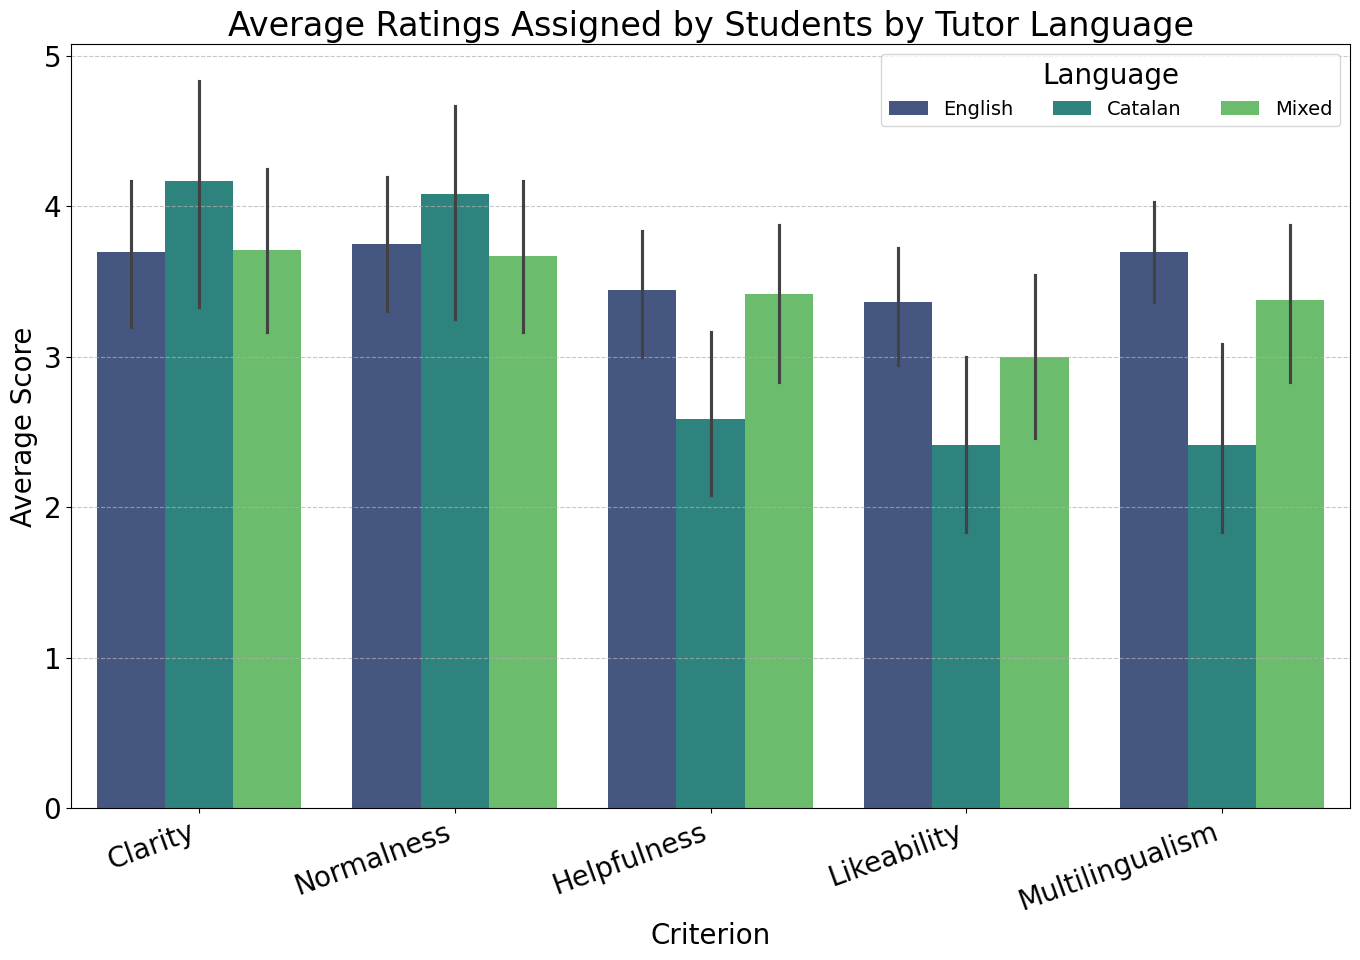

In [289]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# Plot answers by language
plot_data = []
for language, df in formatted_language_dfs.items():
    for column in df.columns:
        if (
            df[column].dtype in [float, int] and column != "Level"
        ):  # Only consider numeric columns
            mean = df[column].mean()
            for value in df[column]:
                plot_data.append(
                    {
                        "Language": language_mapping[language],
                        "Question": column,
                        "Score": value,
                    }
                )

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 10))
sns.barplot(
    x="Question",
    y="Score",
    hue="Language",
    data=plot_df,
    ci=95,
    palette="viridis",
)

plt.title("Average Ratings Assigned by Students by Tutor Language")
plt.xlabel("Criterion")
plt.ylabel("Average Score")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Language", loc="upper right", fontsize=14, ncol=len(df.columns))

plt.tight_layout()
plt.show()

In [ ]:
# T-tables

formatted_language_dfs_numerical = {
    language: df.select_dtypes(include=[float, int]).drop(columns=["Level"])
    for language, df in formatted_language_dfs.items()

}


all_criteria = set()


for language_data in formatted_language_dfs_numerical.values():

    all_criteria.update(language_data.keys())


all_criteria = sorted(list(all_criteria))



all_languages = sorted(list(formatted_language_dfs_numerical.keys()))



latex_table_data = []



for crit in all_criteria:

    for i, language1 in enumerate(all_languages):


        for language2 in all_languages[i + 1 :]:

            try:

                group1 = [
                    sim for sim in formatted_language_dfs_numerical[language1][crit]
                ]

                group2 = [
                    sim for sim in formatted_language_dfs_numerical[language2][crit]
                ]

            except KeyError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals

            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)

            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    language1.capitalize(),
                    language2.capitalize(),
                    crit.capitalize(),
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(

    pd.DataFrame(
        latex_table_data,
        columns=[
            "language 1",
            "language 2",
            "Criterion",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for scores assigned by students by tutor language",
        position="h!",
        label="tab-stats-simrisals-levels-by-crit",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for scores assigned by students by tutor language}
\label{tab-stats-simrisals-levels-by-crit}
\begin{tabular}{llllll}
\toprule
language 1 & language 2 & Criterion & T-statistic & P-value & 95\% CI \\
\midrule
Tutor-en & Tutor-es & Clarity & -0.964 & 0.3400 & [-1.375, 0.431] \\
Tutor-en & Tutor-mixed & Clarity & -0.036 & 0.9717 & [-0.769, 0.741] \\
Tutor-es & Tutor-mixed & Clarity & 0.926 & 0.3609 & [-0.490, 1.407] \\
Tutor-en & Tutor-es & Helpfulness & 2.097 & 0.0415* & [0.156, 1.566] \\
Tutor-en & Tutor-mixed & Helpfulness & 0.081 & 0.9359 & [-0.648, 0.704] \\
Tutor-es & Tutor-mixed & Helpfulness & -1.929 & 0.0621 & [-1.605, -0.062] \\
Tutor-en & Tutor-es & Likeability & 2.277 & 0.0275* & [0.166, 1.723] \\
Tutor-en & Tutor-mixed & Likeability & 1.042 & 0.3017 & [-0.330, 1.052] \\
Tutor-es & Tutor-mixed & Likeability & -1.253 & 0.2186 & [-1.444, 0.277] \\
Tutor-en & Tutor-es & Multilingualism & 3.520 & 0.0010* & [0.533, 2.023] \\
Tutor-en & T

<>:90: SyntaxWarning:

invalid escape sequence '\%'

<>:90: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2948302873.py:90: SyntaxWarning:

invalid escape sequence '\%'



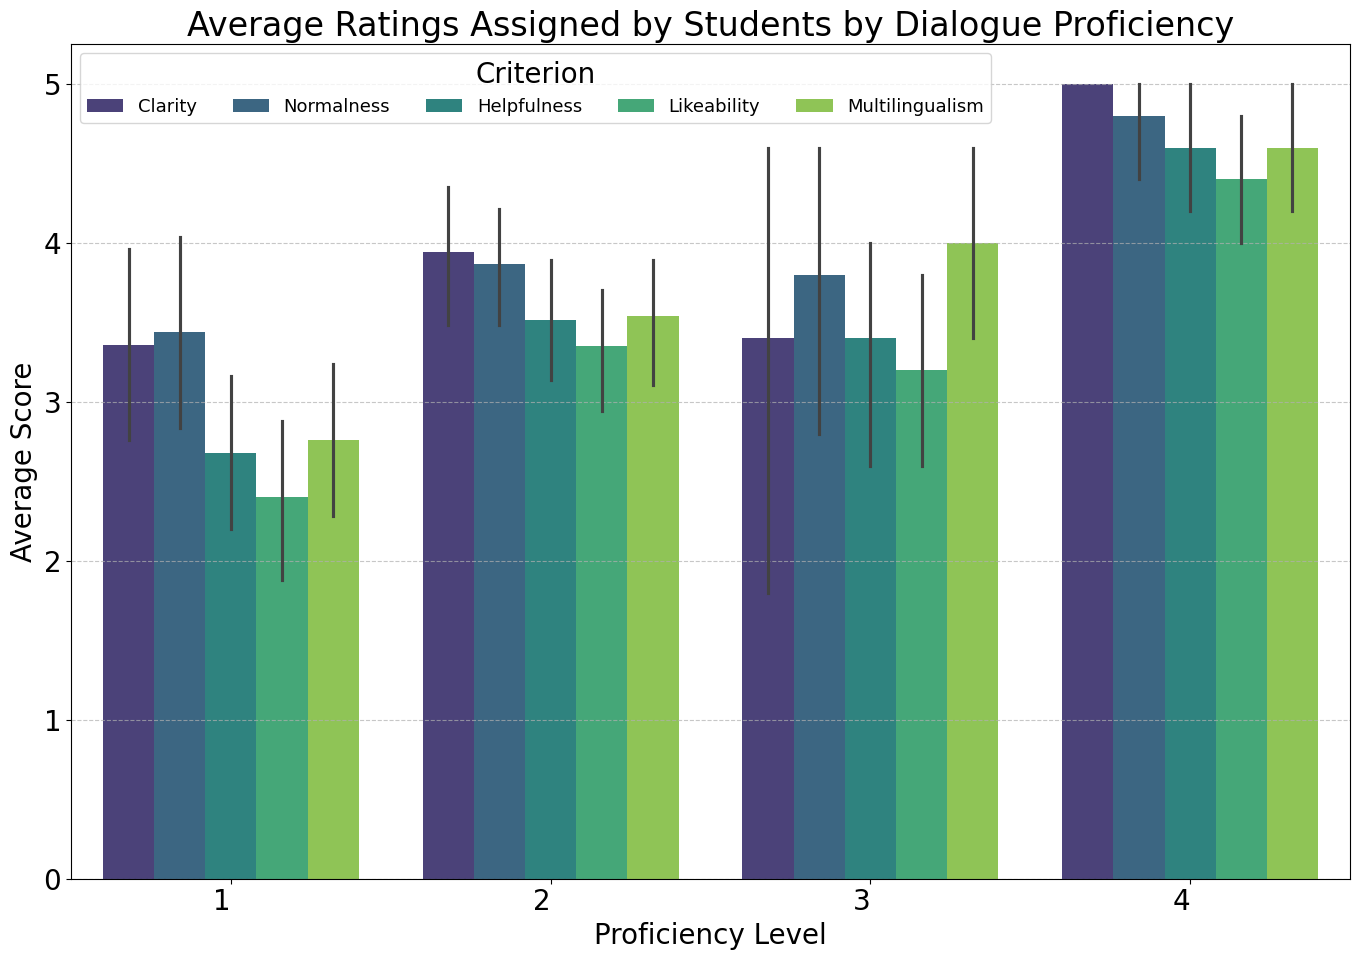

In [291]:
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# Plot answers by level

plot_data = []
for level, df in formatted_level_dfs.items():
    for column in df.columns:
        if df[column].dtype in [float, int]:  # Only consider numeric columns
            mean = df[column].mean()
            for value in df[column]:
                plot_data.append({"Level": level, "Question": column, "Score": value})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 10))
sns.barplot(
    x="Level",
    y="Score",
    hue="Question",
    data=plot_df,
    ci=95,
    palette="viridis",
)

plt.title("Average Ratings Assigned by Students by Dialogue Proficiency")
plt.xlabel("Proficiency Level")
plt.ylabel("Average Score")
plt.xticks(ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Criterion", loc="upper left", fontsize=13, ncol=len(df.columns))

plt.tight_layout()
plt.show()

In [ ]:
# T-tests

formatted_level_dfs_numerical = {
    level: df.select_dtypes(include=[float, int])
    for level, df in formatted_level_dfs.items()
}


all_criteria = set()


for level_data in formatted_level_dfs_numerical.values():

    all_criteria.update(level_data.keys())


all_criteria = sorted(list(all_criteria))



all_levels = sorted(list(formatted_level_dfs_numerical.keys()))



latex_table_data = []



for crit in all_criteria:

    for i, level1 in enumerate(all_levels):


        for level2 in all_levels[i + 1 :]:

            try:

                group1 = [sim for sim in formatted_level_dfs_numerical[level1][crit]]

                group2 = [sim for sim in formatted_level_dfs_numerical[level2][crit]]

            except KeyError:
                continue


            t_stat, p_value = ttest_ind(group1, group2)


            # Calculate confidence intervals

            mean_diff = np.mean(group1) - np.mean(group2)


            pooled_se = np.sqrt(sem(group1) ** 2 + sem(group2) ** 2)


            ci_low = mean_diff - 1.96 * pooled_se

            ci_high = mean_diff + 1.96 * pooled_se


            latex_table_data.append(
                [
                    level1,
                    level2,
                    crit.capitalize(),
                    f"{t_stat:.3f}",
                    f"{p_value:.4f}{"*" if p_value < 0.05 else ""}",
                    f"[{ci_low:.3f}, {ci_high:.3f}]",
                ]
            )

print(

    pd.DataFrame(
        latex_table_data,
        columns=[
            "level 1",
            "level 2",
            "Criterion",
            "T-statistic",
            "P-value",
            "95\% CI",
        ],
    ).to_latex(
        index=False,
        caption="Pairwise t-tests for scores assigned by students by tutor level",
        position="h!",
        label="tab-stats-simrisals-levels-by-crit",
    )
)

\begin{table}[h!]
\caption{Pairwise t-tests for scores assigned by students by tutor level}
\label{tab-stats-simrisals-levels-by-crit}
\begin{tabular}{rrllll}
\toprule
level 1 & level 2 & Criterion & T-statistic & P-value & 95\% CI \\
\midrule
1 & 2 & Clarity & -1.589 & 0.1172 & [-1.335, 0.163] \\
1 & 3 & Clarity & -0.051 & 0.9600 & [-1.748, 1.668] \\
1 & 4 & Clarity & -2.291 & 0.0297* & [-2.259, -1.021] \\
2 & 3 & Clarity & 0.836 & 0.4080 & [-1.101, 2.193] \\
2 & 4 & Clarity & -1.778 & 0.0829 & [-1.477, -0.632] \\
3 & 4 & Clarity & -1.969 & 0.0844 & [-3.192, -0.008] \\
1 & 2 & Helpfulness & -2.590 & 0.0120* & [-1.465, -0.202] \\
1 & 3 & Helpfulness & -1.220 & 0.2327 & [-1.644, 0.204] \\
1 & 4 & Helpfulness & -3.336 & 0.0024* & [-2.606, -1.234] \\
2 & 3 & Helpfulness & 0.197 & 0.8448 & [-0.766, 0.993] \\
2 & 4 & Helpfulness & -1.920 & 0.0621 & [-1.711, -0.462] \\
3 & 4 & Helpfulness & -2.558 & 0.0337* & [-2.119, -0.281] \\
1 & 2 & Likeability & -2.899 & 0.0052* & [-1.599, -0.304] \\
1 

<>:87: SyntaxWarning:

invalid escape sequence '\%'

<>:87: SyntaxWarning:

invalid escape sequence '\%'

C:\Users\szach\AppData\Local\Temp\ipykernel_17256\2861660640.py:87: SyntaxWarning:

invalid escape sequence '\%'

c:\Users\szach\OneDrive - University of Aberdeen\Desktop\studies\year 5\thesis\TutorCodeSwitchThesisPublic\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning:

Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.



In [ ]:
# calculating and printing average values
for intent in formatted_intent_dfs.keys():

    print("Intent: ", intent)

    for question in question_mapping.values():

        if question in [
            "Intent",
            "intent_other",
            "improve_general",
            "improve_multilingual",
        ]:

            continue

        formatted_intent_dfs[intent][question] = formatted_intent_dfs[intent][
            question
        ].astype(float)

        print(
            f"Average {question}: {formatted_intent_dfs[intent][question].mean():.3f}"
        )

    print(f"\n")

Intent:  backchannel
Average Clarity: 3.792
Average Normalness: 4.000
Average Helpfulness: 3.167
Average Likeability: 2.875
Average Multilingualism: 3.333


Intent:  questions
Average Clarity: 3.792
Average Normalness: 3.625
Average Helpfulness: 3.417
Average Likeability: 3.292
Average Multilingualism: 3.667


Intent:  topics
Average Clarity: 3.750
Average Normalness: 3.708
Average Helpfulness: 3.292
Average Likeability: 3.083
Average Multilingualism: 3.125




### Checking intents labelled by respondents


In [ ]:
# Inspecting the intent labels assigned by respondents

for intent in formatted_intent_dfs.keys():

    print("\nIntent:", intent)
    print(

        "Intent according to respondent:",
        formatted_intent_dfs[intent]["Intent"].value_counts(),
    )


Intent: backchannel
Intent according to respondent: Intent
Other            9
Clarification    7
Translation      5
Acknowlegment    3
Name: count, dtype: int64

Intent: questions
Intent according to respondent: Intent
Translation      9
Clarification    7
Other            7
Acknowlegment    1
Name: count, dtype: int64

Intent: topics
Intent according to respondent: Intent
Clarification    12
Other             5
Translation       5
Acknowlegment     2
Name: count, dtype: int64


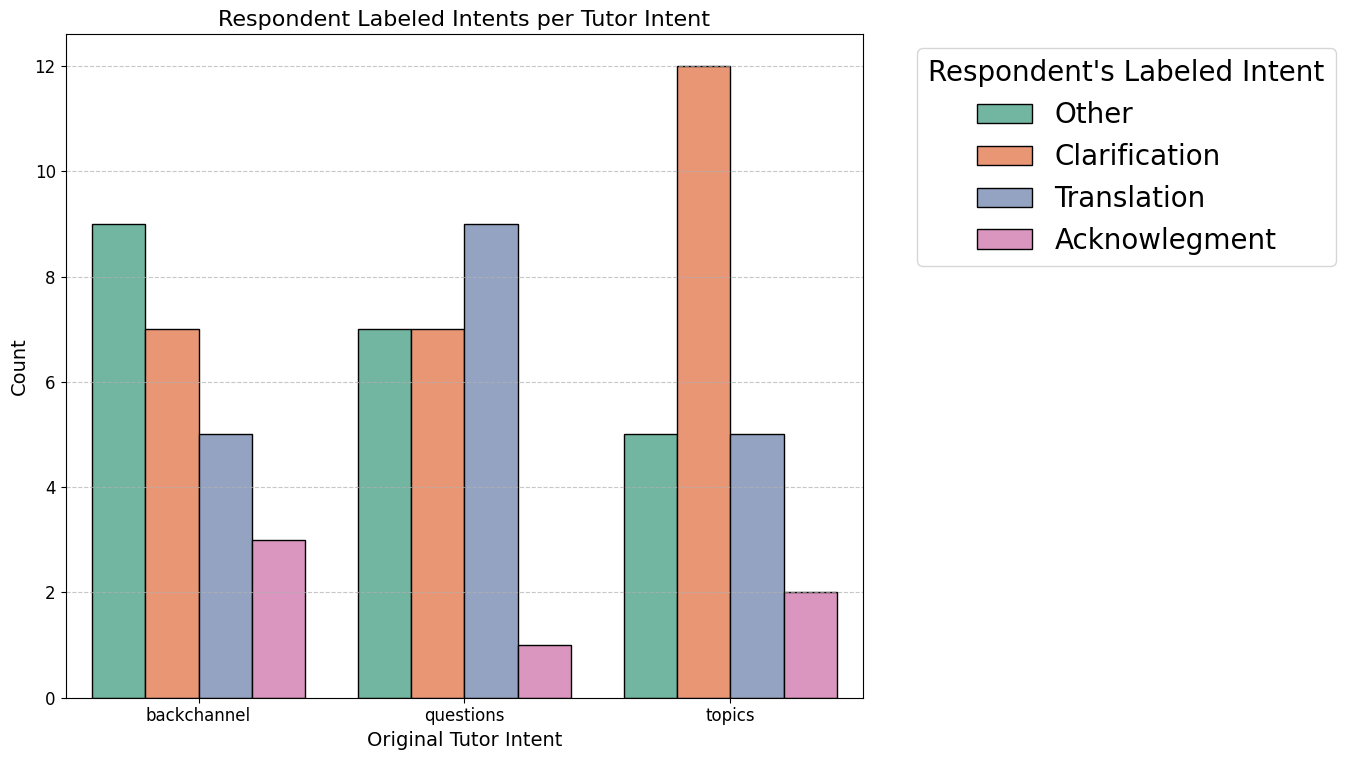

In [295]:
records = []
for original_intent, df in formatted_intent_dfs.items():
    value_counts = df["Intent"].value_counts()
    for respondent_intent, count in value_counts.items():
        records.append(
            {
                "Original Intent": original_intent,
                "Respondent Intent": respondent_intent,
                "Count": count,
            }
        )

df_plot = pd.DataFrame(records)

# Plotting original intent labels against the respondent intents
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_plot,
    x="Original Intent",
    y="Count",
    hue="Respondent Intent",
    edgecolor="black",
    palette="Set2",
)

plt.title("Respondent Labeled Intents per Tutor Intent", fontsize=16)
plt.xlabel("Original Tutor Intent", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=0, ha="center", fontsize=12)
plt.yticks(fontsize=12)
plt.legend(
    title="Respondent's Labeled Intent", bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

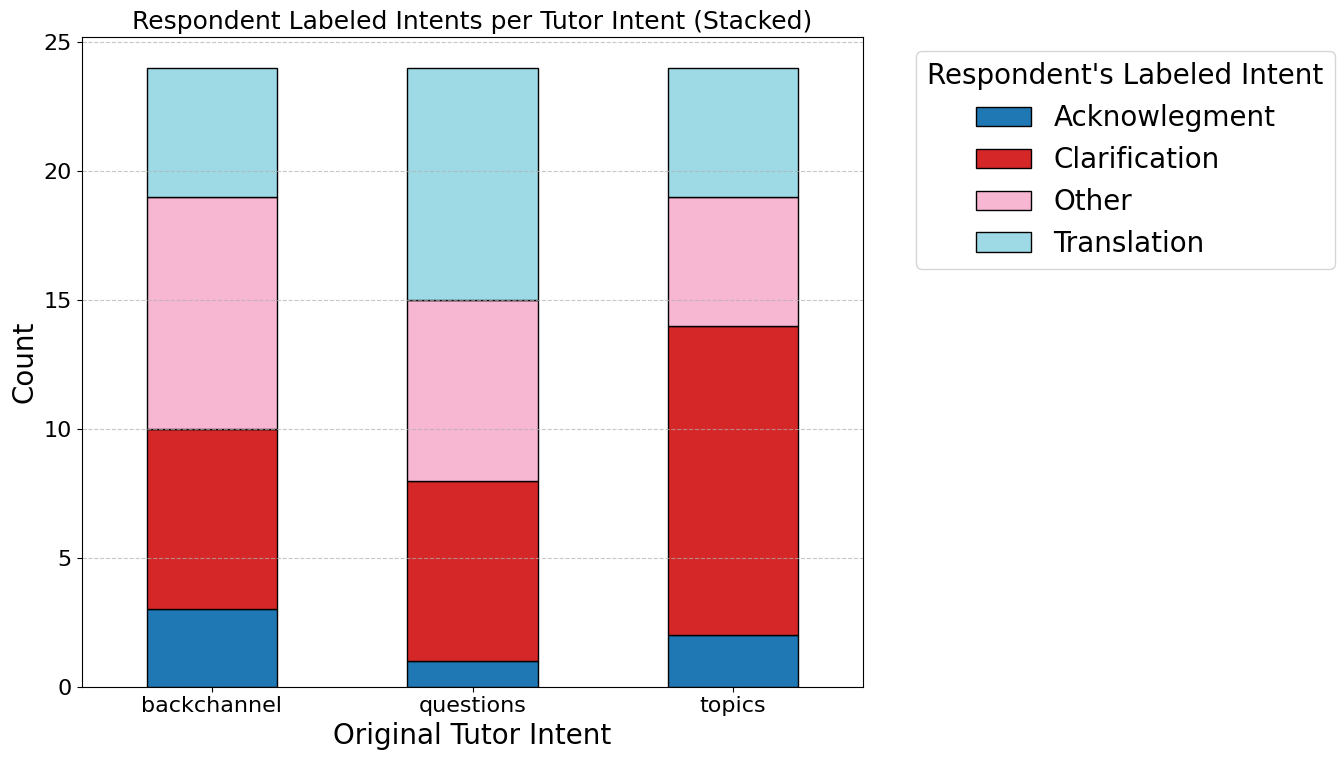

In [ ]:
# Same but as a stacked bar plot



records = []


for original_intent, df in formatted_intent_dfs.items():

    value_counts = df["Intent"].value_counts()

    for respondent_intent, count in value_counts.items():
        records.append(

            {
                "Original Intent": original_intent,
                "Respondent Intent": respondent_intent,
                "Count": count,
            }
        )



df_plot = pd.DataFrame(records)



pivot_df = df_plot.pivot(
    index="Original Intent", columns="Respondent Intent", values="Count"
).fillna(0)



pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    edgecolor="black",
    colormap="tab20",
)



plt.title("Respondent Labeled Intents per Tutor Intent (Stacked)", fontsize=18)


plt.xlabel("Original Tutor Intent")


plt.ylabel("Count")


plt.xticks(rotation=0, ha="center", fontsize=16)


plt.yticks(fontsize=16)


plt.legend(
    title="Respondent's Labeled Intent", bbox_to_anchor=(1.05, 1), loc="upper left"
)



plt.grid(axis="y", linestyle="--", alpha=0.7)


plt.tight_layout()


plt.show()

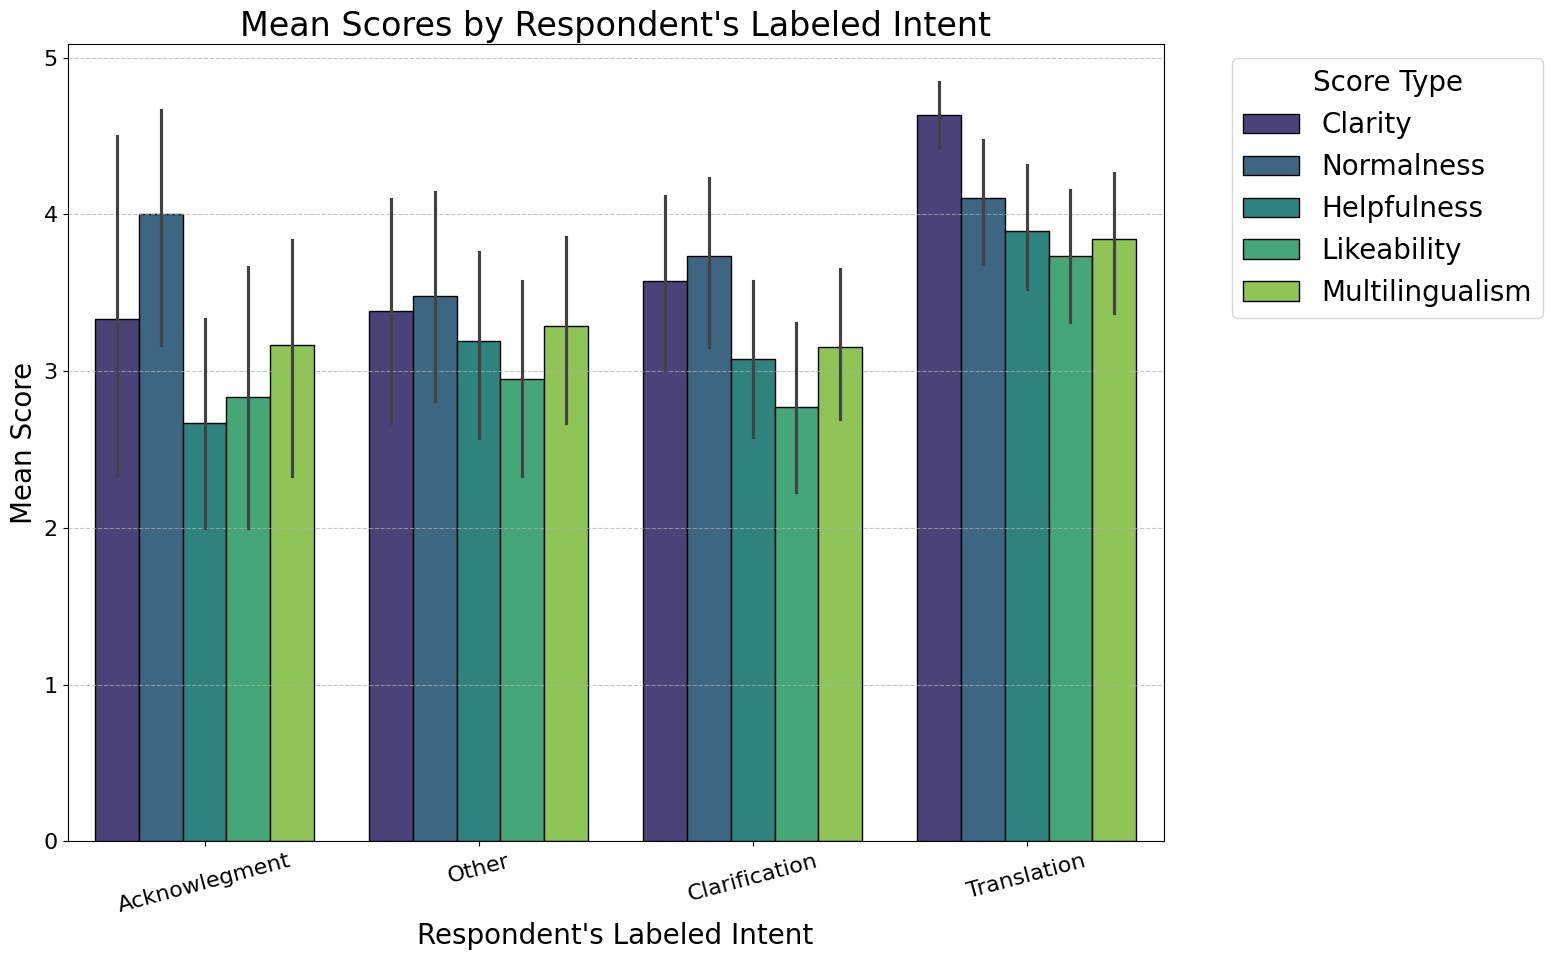

In [ ]:
# Plot ratings by assigned intent


records = []


for original_intent, df in formatted_intent_dfs.items():

    for _, row in df.iterrows():
        records.append(

            {
                "Original Intent": original_intent,
                "Respondent Intent": row["Intent"],
                "Clarity": row.get("Clarity"),
                "Normalness": row.get("Normalness"),
                "Helpfulness": row.get("Helpfulness"),
                "Likeability": row.get("Likeability"),
                "Multilingualism": row.get("Multilingualism"),
            }
        )



df_scores = pd.DataFrame(records)



df_scores = df_scores.dropna(subset=["Respondent Intent"])

df_melted = df_scores.melt(

    id_vars=["Original Intent", "Respondent Intent"],
    value_vars=[
        "Clarity",
        "Normalness",
        "Helpfulness",
        "Likeability",
        "Multilingualism",
    ],
    var_name="Score Type",
    value_name="Score",
)



df_scores = pd.DataFrame(records)



df_scores = df_scores.dropna(subset=["Respondent Intent"])

df_melted = df_scores.melt(

    id_vars=["Original Intent", "Respondent Intent"],
    value_vars=[
        "Clarity",
        "Normalness",
        "Helpfulness",
        "Likeability",
        "Multilingualism",
    ],
    var_name="Score Type",
    value_name="Score",
)



df_melted = df_melted.dropna(subset=["Score"])



plt.figure(figsize=(16, 10))


sns.barplot(
    data=df_melted,

    x="Respondent Intent",
    y="Score",
    hue="Score Type",
    estimator="mean",

    ci=95,
    palette="viridis",
    edgecolor="black",
    dodge=True,
)



plt.title("Mean Scores by Respondent's Labeled Intent")


plt.xlabel("Respondent's Labeled Intent")


plt.ylabel("Mean Score")


plt.xticks(rotation=15, ha="center", fontsize=16)


plt.yticks(fontsize=16)


plt.legend(title="Score Type", bbox_to_anchor=(1.05, 1), loc="upper left")


plt.grid(axis="y", linestyle="--", alpha=0.7)


plt.tight_layout()


plt.show()

## Surprisal vs survey criteria


Analysing surprisal assigned by the model to the ratings


In [ ]:
surprisal_eval_dfs = {
    level: {
        intent: {
            "Clarity": [],
            "Normalness": [],
            "Helpfulness": [],
            "Likeability": [],
            "Multilingualism": [],
            "Surprisal": [],
        }
        for intent in formatted_intent_dfs.keys()
    }
    for level in formatted_level_dfs.keys()
}
surprisal_eval_dfs[1]

{'backchannel': {'Clarity': [],
  'Normalness': [],
  'Helpfulness': [],
  'Likeability': [],
  'Multilingualism': [],
  'Surprisal': []},
 'questions': {'Clarity': [],
  'Normalness': [],
  'Helpfulness': [],
  'Likeability': [],
  'Multilingualism': [],
  'Surprisal': []},
 'topics': {'Clarity': [],
  'Normalness': [],
  'Helpfulness': [],
  'Likeability': [],
  'Multilingualism': [],
  'Surprisal': []}}

In [ ]:
# putting all in one dataframe
for level in formatted_level_dfs.keys():
    # ratings

    for i, row in formatted_level_dfs[level].iterrows():
        intent = row["Intent_Real"]
        surprisal_eval_dfs[level][intent]["Clarity"].append(row["Clarity"])
        surprisal_eval_dfs[level][intent]["Normalness"].append(row["Normalness"])
        surprisal_eval_dfs[level][intent]["Helpfulness"].append(row["Helpfulness"])
        surprisal_eval_dfs[level][intent]["Likeability"].append(row["Likeability"])
        surprisal_eval_dfs[level][intent]["Multilingualism"].append(
            row["Multilingualism"]
        )

    # surprisal

    surprisal_eval_dfs[level]["backchannel"]["Surprisal"] = [
        -x for x in topic_surprisals_per_level[level]["Backchannel"]
    ]
    surprisal_eval_dfs[level]["topics"]["Surprisal"] = [
        -x for x in topic_surprisals_per_level[level]["Topics"]
    ]
    surprisal_eval_dfs[level]["questions"]["Surprisal"] = [
        -x for x in topic_surprisals_per_level[level]["Questions"]
    ]

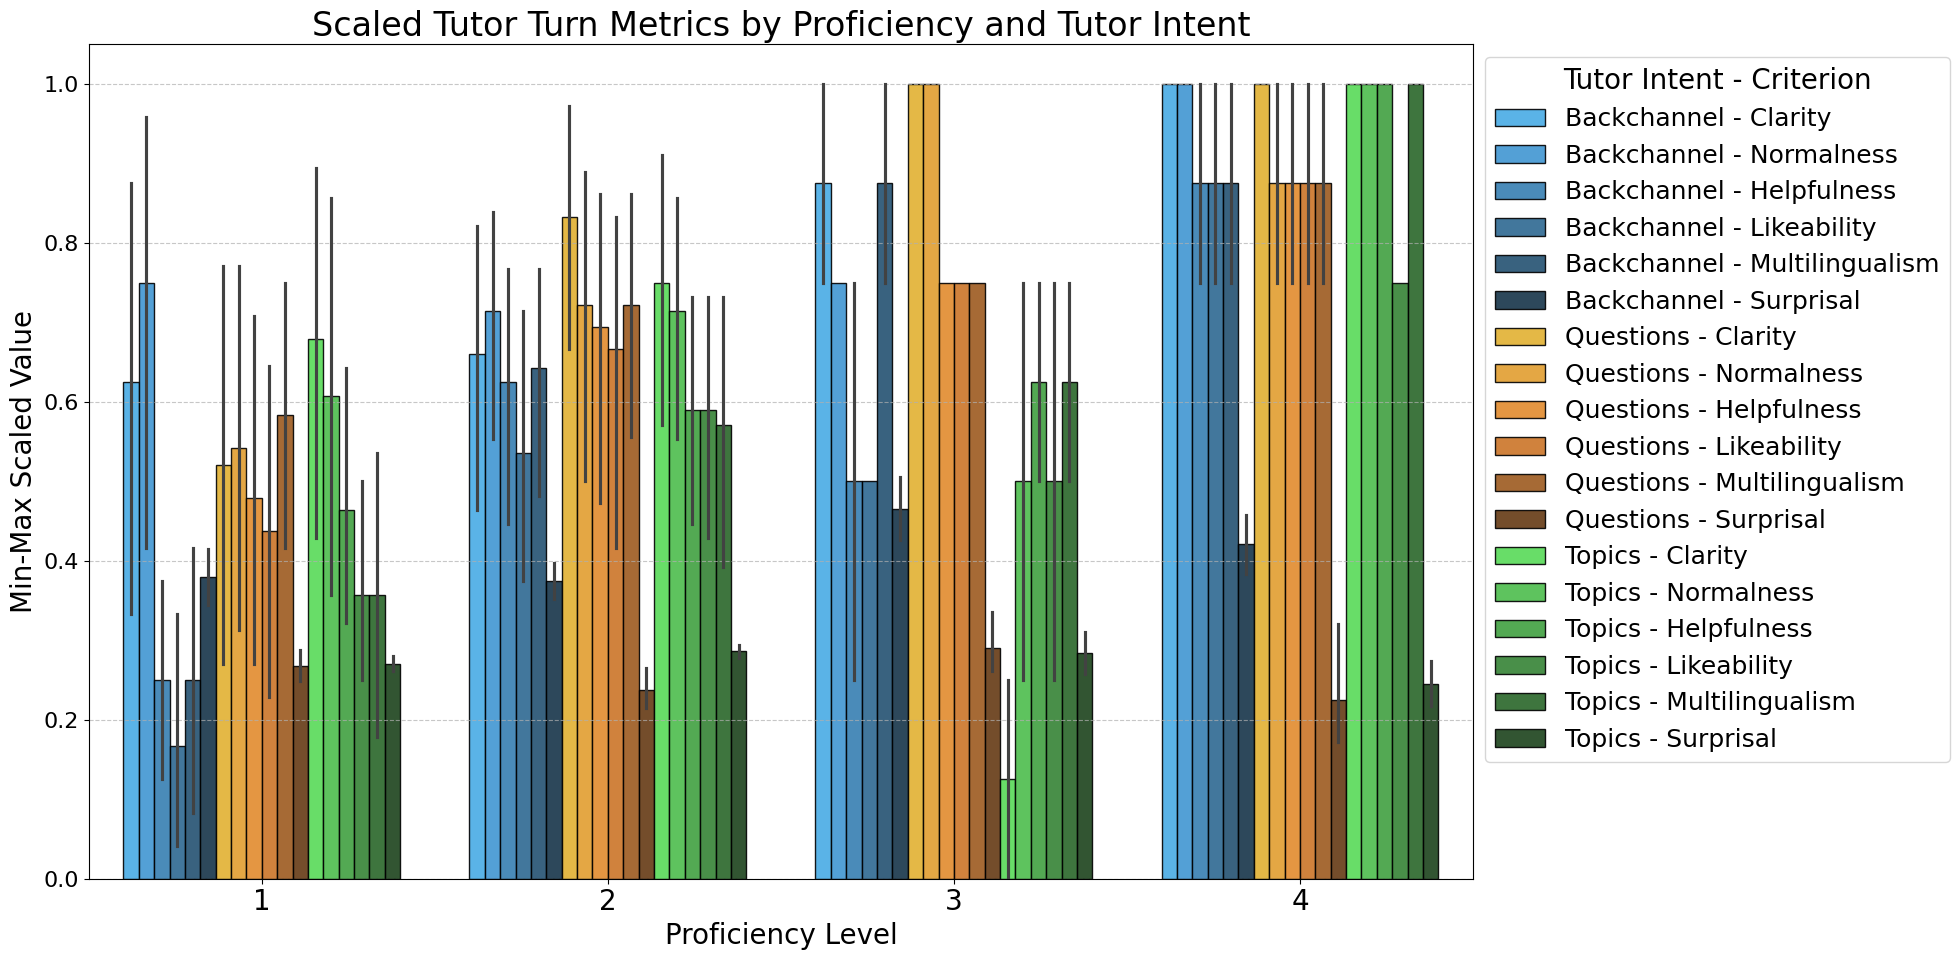

In [324]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler

# plotting surprisal against all criteria
data = [
    {
        "Proficiency": level,
        "Tutor Intent": topic.capitalize(),
        "Criterion": criterion,
        "Value": value,
    }
    for level, topics in surprisal_eval_dfs.items()
    for topic, criteria in topics.items()
    for criterion, values in criteria.items()
    for value in values
    if len(values) > 0
]

df = pd.DataFrame(data)

df["Tutor Intent + Criterion"] = df["Tutor Intent"] + " - " + df["Criterion"]

df_scaled = df.copy()

# scale independently so that the values can be compared

for crit in df_scaled["Criterion"].unique():
    scaler = MinMaxScaler()

    mask = df_scaled["Criterion"] == crit
    df_scaled.loc[mask, "Value"] = scaler.fit_transform(df_scaled.loc[mask, ["Value"]])


base_palette = {"Backchannel": "#1f77b4", "Questions": "#ff7f0e", "Topics": "#2ca02c"}


def adjust_lightness(color, amount=1.2):
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = mcolors.to_rgb(c)
    return mcolors.to_hex([min(1, max(0, x * amount)) for x in c])


unique_intent_criteria = df_scaled["Tutor Intent + Criterion"].unique()
palette = {}
for uc in unique_intent_criteria:
    intent, criterion = uc.split(" - ")
    if criterion == "Clarity":
        color = adjust_lightness(base_palette[intent], 1.5)
    elif criterion == "Normalness":
        color = adjust_lightness(base_palette[intent], 1.3)
    elif criterion == "Helpfulness":
        color = adjust_lightness(base_palette[intent], 1.1)
    elif criterion == "Likeability":
        color = adjust_lightness(base_palette[intent], 0.9)
    elif criterion == "Multilingualism":
        color = adjust_lightness(base_palette[intent], 0.7)
    elif criterion == "Surprisal":
        color = adjust_lightness(base_palette[intent], 0.45)

    else:
        color = base_palette[intent]
    palette[uc] = color

plt.figure(figsize=(20, 10))
sns.barplot(
    x="Proficiency",
    y="Value",
    hue="Tutor Intent + Criterion",
    data=df_scaled,
    dodge=True,
    palette=palette,
    alpha=0.9,
    edgecolor="black",
    ci=95,
)

plt.xlabel("Proficiency Level")
plt.ylabel("Min-Max Scaled Value")
plt.title("Scaled Tutor Turn Metrics by Proficiency and Tutor Intent")
plt.xticks(rotation=0, ha="center")
plt.yticks(fontsize=16)
plt.legend(
    title="Tutor Intent - Criterion",
    bbox_to_anchor=(1, 1),
    loc="upper left",
    fontsize=18,
)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [325]:
df_scaled[df_scaled["Criterion"] != "Surprisal"]

,Proficiency,Tutor Intent,Criterion,Value,Tutor Intent + Criterion
0,1,Backchannel,Clarity,0.25,Backchannel - Clarity
1,1,Backchannel,Clarity,0.75,Backchannel - Clarity
2,1,Backchannel,Clarity,1.00,Backchannel - Clarity
3,1,Backchannel,Clarity,1.00,Backchannel - Clarity
4,1,Backchannel,Clarity,0.75,Backchannel - Clarity
...,...,...,...,...,...
1616,4,Topics,Clarity,1.00,Topics - Clarity
1617,4,Topics,Normalness,1.00,Topics - Normalness
1618,4,Topics,Helpfulness,1.00,Topics - Helpfulness
1619,4,Topics,Likeability,0.75,Topics - Likeability


## Measure the inter-annotator agreement


In [326]:
import krippendorff

# Filtering out groups with only one or zero annotators

multiple_annotaor_groups = (
    survey_results["group"]
    .value_counts()[survey_results["group"].value_counts() > 1]
    .index
)
survey_res_for_agreement = survey_results[
    survey_results["group"].isin(multiple_annotaor_groups)
]

In [ ]:
# Mission abandoned for now

# survey_res_for_agreement_grouped = survey_res_for_agreement.groupby("group")



# # Calculating Krippendorff's alpha for each group



# for group, group_df in survey_res_for_agreement_grouped:


#     agreements_per_question = []


#     group_df = group_df[[col for col in group_df.columns if "QID" in col]]


#     group_df = group_df[[col for col in group_df.columns[9:]]]  # delete background info


#     group_df = group_df.dropna(axis=1, how="all")  # Drop columns with all NaN values



#     for col in group_df.columns:


#         if group_df[col].values[0] in likert_mapping.keys():


#             group_df[col] = group_df[col].map(likert_mapping)


#         question_type = question_mapping[(int(col[3:]) - 11) % 9 + 1]


#         if question_type in ["intent_other", "improve_general", "improve_multilingual"]:
#             continue



#         print(list(group_df[col].values))


#         agreements_per_question.append(
#             {


#                 "QID": col,


#                 "Question Type": question_type,


#                 "Krippendorff's Alpha": krippendorff.alpha(
#                     reliability_data=list(group_df[col].values),
#                     level_of_measurement="nominal",
#                 ),


#             }
#         )


# agreements_per_question

## Now, I consider only the turns from survey samples for surprisal analysis


In [328]:
survey_samples = json.load(open("selected_samples_final_first.json", "rb"))

In [329]:
survey_samples_formatted = {}

for intent, langs in survey_samples.items():
    survey_samples_formatted[intent] = []

    # Getting the tutor and the previous student turn

    for lang, samples in langs.items():
        for sample in samples:
            survey_samples_formatted[intent].append(
                {"Tutor": sample["Tutor"], "Context": sample["Context"][-1]["Turn"]}
            )

In [330]:
with open("pickle/survey_samples_formatted.pkl", "wb") as file:
    pickle.dump(survey_samples_formatted, file)  # Needed by an external script

In [ ]:
survey_samples_surprisals = pickle.load(
    open("pickle/survey_samples_surprisals.pkl", "rb")
)  # From the external script


survey_samples_surprisals

{'backchannel': [{'Context': 'sí',
   'Tutor': 'because hm classes',
   'Surprisal': -12.519377708435059},
  {'Context': 'es a ver I play in juveniles',
   'Tutor': 'okay okay',
   'Surprisal': -9.061792373657227},
  {'Context': 'pues',
   'Tutor': "it's difficult or it's easy",
   'Surprisal': -4.416084289550781},
  {'Context': 'hm and bueno the sundays I make homework',
   'Tutor': 'yeah okay',
   'Surprisal': -8.083955764770508},
  {'Context': 'sí',
   'Tutor': 'homework okay do you watch tv',
   'Surprisal': -7.888766288757324},
  {'Context': 'hm pues no',
   'Tutor': 'you understand did you understand what I said no',
   'Surprisal': -4.8757853507995605},
  {'Context': 'si tinc germans',
   'Tutor': 'yes',
   'Surprisal': -10.976543426513672},
  {'Context': 'hm no a ver espera hm pelí bueno películas',
   'Tutor': 'films',
   'Surprisal': -7.940053939819336},
  {'Context': 'well I bueno es que estoy saturado',
   'Tutor': "don't worry little by little",
   'Surprisal': -4.75543737

In [332]:
samples_surprisals_comp_df = {}

In [ ]:
survey_results_all = pd.read_csv(
    "Master+Students_28+April+2025_14.22/res.csv"
)  # Reading again to get full data


survey_results_all["QID11"][0]

"Please read the following fragment of a dialogue between a student learning English as a second language and a teacher. The last teacher response, marked with a bold font, replies to the student's utterance directly above it. The tutor may or may not have used the student's mother tongue in the response. You are asked to evaluate this response.\n\n\n\nDialogue Fragment:\n\nSTUDENT: old\n\nTUTOR: how old is he\n\nSTUDENT: hm two years\n\nTUTOR: uhhuh so he's eighteen\n\nSTUDENT: yes\n\nTutor: té divuit anys\n\n\n\nThe teacher's response is clear."

In [ ]:
for intent, samples in survey_samples_surprisals.items():

    # Findng tutor and prev utterances in survey samples and matching the surprisal

    for sample in samples:

        for col in survey_results_all.columns:


            if col.startswith("QID") and "Tutor" in survey_results_all[col][0]:

                tutor_utt = (
                    survey_results_all[col][0]
                    .split("Dialogue Fragment:\n\n")[1]
                    .split("\n\n\n\n")[0]
                    .strip()

                    .split("Tutor: ")[1]
                    .strip()
                )


                try:

                    prev_utt = (
                        survey_results_all[col][0]
                        .split("Dialogue Fragment:\n\n")[1]
                        .split("\n\n\n\n")[0]
                        .strip()

                        .split("STUDENT: ")[3]
                        .split("\n")[0]
                        .strip()
                    )


                except:

                    prev_utt = (
                        survey_results_all[col][0]
                        .split("Dialogue Fragment:\n\n")[1]
                        .split("\n\n\n\n")[0]
                        .strip()

                        .split("STUDENT: ")[2]
                        .split("\n")[0]
                        .strip()
                    )


                if tutor_utt == sample["Tutor"] and prev_utt == sample["Context"]:

                    samples_surprisals_comp_df[col] = sample["Surprisal"]

                    for i in range(1, 9):

                        qid = int(col[3:])

                        qid += i


                        samples_surprisals_comp_df[f"QID{qid}"] = sample["Surprisal"]

In [335]:
len(samples_surprisals_comp_df)

540

In [ ]:
formatted_intent_dfs_with_surprisal = {intent: {} for intent in intent_dfs.keys()}

# Merging surprisal and the other columns together


levels = []
languages = []



for intent, df in intent_dfs.items():


    new_df = {q: [] for q in question_mapping.values()}

    new_df["Language"] = []

    new_df["Level"] = []

    new_df["Surprisal"] = []

    for i, column in enumerate(df.columns):

        qid = int(column[3:])

        mapped = question_mapping[(qid - 11) % 9 + 1]

        answers = df[column].dropna()
        if mapped not in [

            "Intent",
            "intent_other",
            "improve_general",
            "improve_multilingual",
        ]:

            answers = [likert_mapping[val] for val in answers]


            new_df[mapped].extend(answers)


        language = qid_to_language[column]

        level = qid_to_level[column]

        surprisal = -samples_surprisals_comp_df[column]


        if (qid - 11) % 9 == 0:

            print(qid, column, language, level, surprisal)

            new_df["Language"].extend([language] * len(answers))

            new_df["Level"].extend([level] * len(answers))

            new_df["Surprisal"].extend([surprisal] * len(answers))


    # Ensure all lists in new_df have the same length


    max_length = max(len(lst) for lst in new_df.values())


    for key in new_df:

        new_df[key].extend([None] * (max_length - len(new_df[key])))


    new_df = pd.DataFrame(new_df)

    formatted_intent_dfs_with_surprisal[intent] = new_df.drop(
        columns=["Intent", "intent_other", "improve_general", "improve_multilingual"]
    )

119 QID119 tutor-es 1 3.324817180633545
137 QID137 tutor-mixed 2 7.790853023529053
155 QID155 tutor-en 3 5.3058881759643555
200 QID200 tutor-en 2 4.8757853507995605
227 QID227 tutor-en 2 4.416084289550781
272 QID272 tutor-es 1 9.047097206115723
290 QID290 tutor-mixed 2 6.225655555725098
326 QID326 tutor-en 3 9.061792373657227
335 QID335 tutor-mixed 2 7.503466606140137
380 QID380 tutor-en 2 7.888766288757324
389 QID389 tutor-en 2 7.940053939819336
398 QID398 tutor-es 1 8.337347030639648
443 QID443 tutor-es 1 9.569165229797363
515 QID515 tutor-en 2 12.519377708435059
524 QID524 tutor-en 4 4.75543737411499
542 QID542 tutor-mixed 2 8.159401893615723
128 QID128 tutor-en 2 4.353054523468018
146 QID146 tutor-mixed 1 6.206549167633057
173 QID173 tutor-en 1 4.742740154266357
182 QID182 tutor-mixed 1 4.750311374664307
245 QID245 tutor-mixed 1 6.545555591583252
299 QID299 tutor-en 3 5.101571083068848
308 QID308 tutor-mixed 1 5.467779636383057
317 QID317 tutor-en 1 4.714206218719482
353 QID353 tut

In [337]:
samples_surprisals_comp_df["QID139"]

-7.790853023529053

In [338]:
formatted_intent_dfs_with_surprisal["backchannel"]

,Clarity,Normalness,Helpfulness,Likeability,Multilingualism,Language,Level,Surprisal
0,2,4,2,1,3,tutor-es,1,3.324817
1,3,4,1,1,1,tutor-mixed,2,7.790853
2,5,4,4,3,5,tutor-en,3,5.305888
3,3,4,4,3,4,tutor-en,2,4.875785
4,4,3,4,4,4,tutor-en,2,4.416084
5,4,4,2,2,2,tutor-es,1,9.047097
6,5,2,2,2,4,tutor-mixed,2,6.225656
7,4,4,2,3,4,tutor-en,3,9.061792
8,1,4,4,2,3,tutor-mixed,2,7.503467
9,1,1,1,1,1,tutor-mixed,2,7.503467


### Now, I am ready to perform linear regression


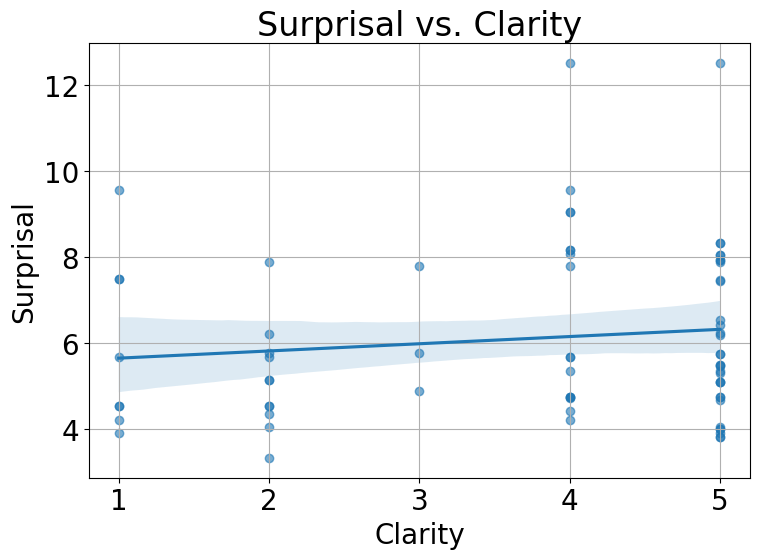

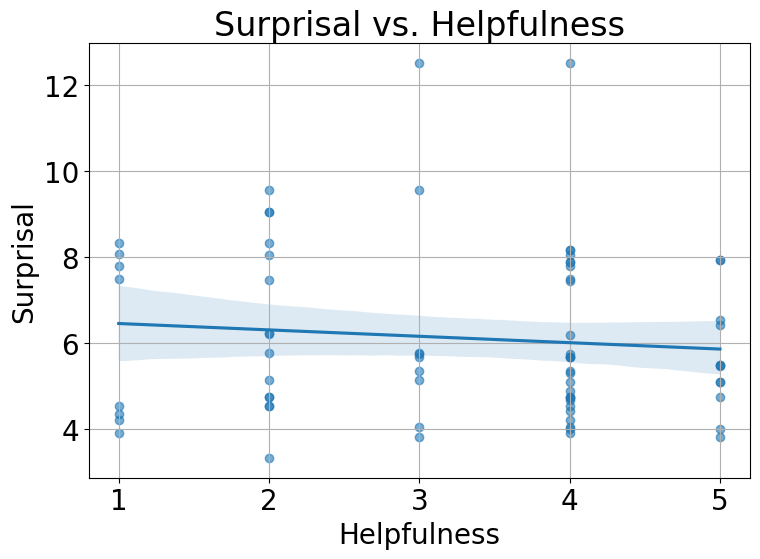

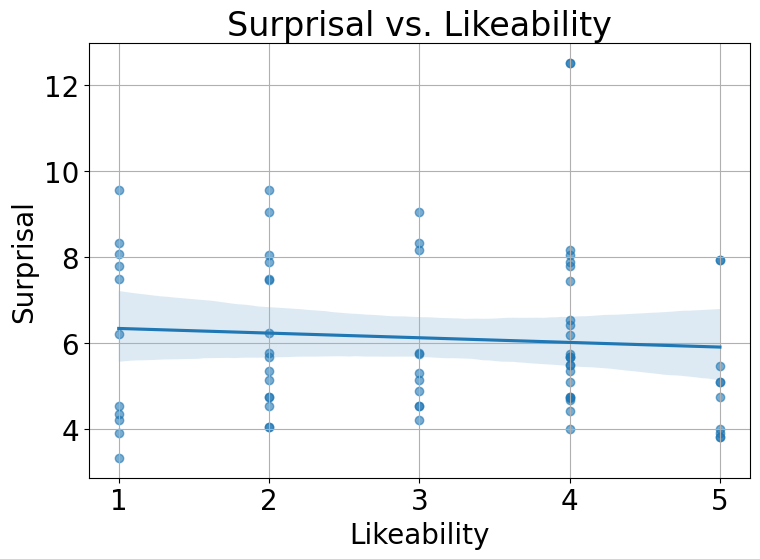

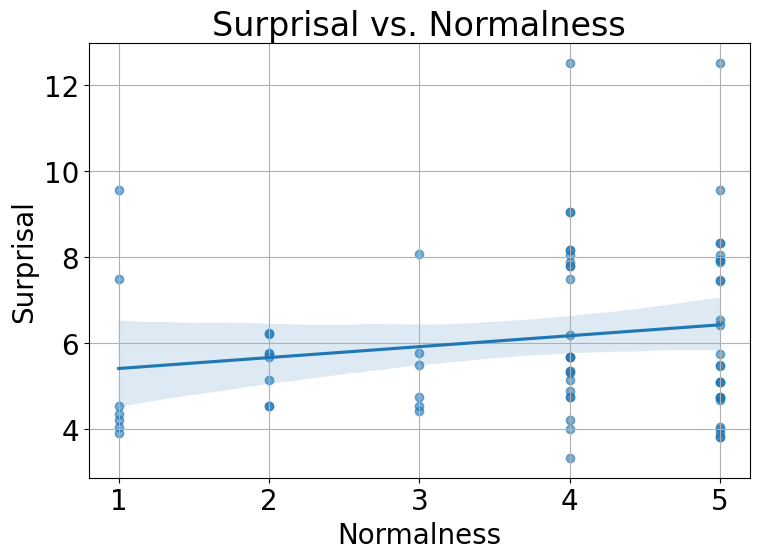

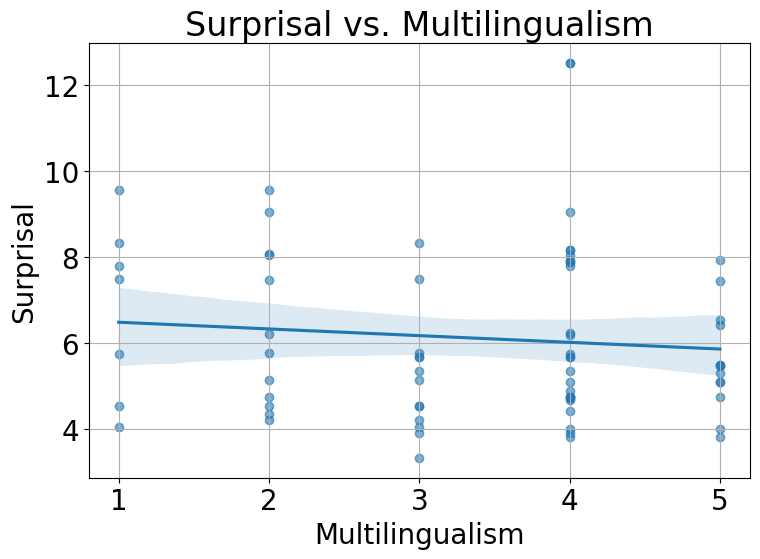

In [339]:
formatted_df_with_surprisal = pd.concat(
    formatted_intent_dfs_with_surprisal.values(), ignore_index=True
)


# Plotting and analysing surprisal vs other criteria (not grouped by intent)


variables_to_evaluate = [
    "Clarity",
    "Helpfulness",
    "Likeability",
    "Normalness",
    "Multilingualism",
]


for var in variables_to_evaluate:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        x=var,
        y="Surprisal",
        data=formatted_df_with_surprisal,
        scatter_kws={"alpha": 0.6},
    )

    plt.title(f"Surprisal vs. {var}")

    plt.xlabel(var)

    plt.ylabel("Surprisal")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [ ]:
import statsmodels.formula.api as smf

# statistical testing



model = smf.ols(
    f"Surprisal ~{' + '.join(list(variables_to_evaluate))}",
    data=formatted_df_with_surprisal,
)


results = model.fit()


print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Surprisal   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.333
Date:                Wed, 30 Apr 2025   Prob (F-statistic):              0.261
Time:                        17:11:43   Log-Likelihood:                -146.55
No. Observations:                  72   AIC:                             305.1
Df Residuals:                      66   BIC:                             318.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           5.6922      0.804     

In [ ]:
significant_predictors_per_intent = {}
# Statistical testing per intent


for intent, df in formatted_intent_dfs_with_surprisal.items():

    significant_predictors_per_intent[intent] = {}

    significant_predictors = {}

    print(f"\n\nIntent: {intent}")


    model = smf.ols(f"Surprisal ~{' + '.join(list(variables_to_evaluate))}", data=df)

    results = model.fit()


    print(results.summary())


    for variable in variables_to_evaluate:

        p_value = results.pvalues[variable]


        if p_value < 0.05:

            significant_predictors[variable] = p_value


    significant_predictors_per_intent[intent] = significant_predictors



Intent: backchannel
                            OLS Regression Results                            
Dep. Variable:              Surprisal   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                 -0.034
Method:                 Least Squares   F-statistic:                    0.8481
Date:                Wed, 30 Apr 2025   Prob (F-statistic):              0.534
Time:                        17:11:43   Log-Likelihood:                -50.996
No. Observations:                  24   AIC:                             114.0
Df Residuals:                      18   BIC:                             121.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           

In [342]:
significant_predictors_per_intent

{'backchannel': {},
 'questions': {'Helpfulness': np.float64(0.013198768528556976),
  'Likeability': np.float64(0.018271878925977546)},
 'topics': {'Clarity': np.float64(0.042456150903909445),
  'Helpfulness': np.float64(0.03302096021382619),
  'Multilingualism': np.float64(0.029709298314520224)}}

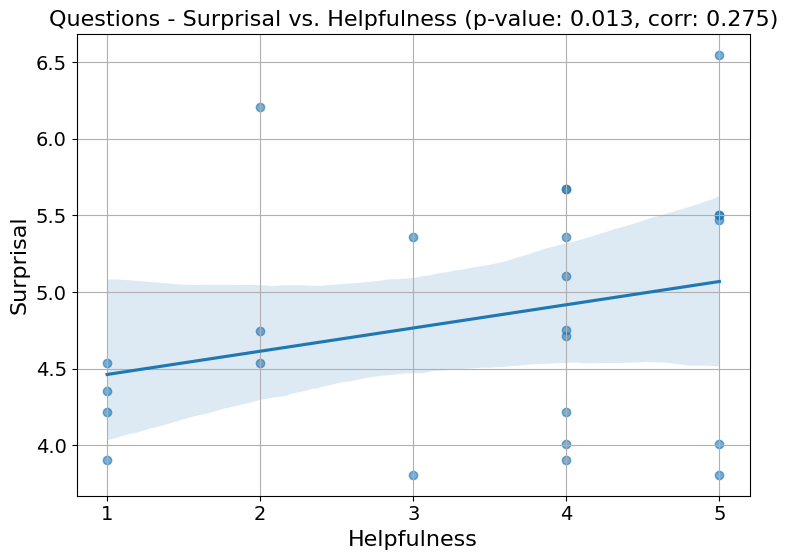

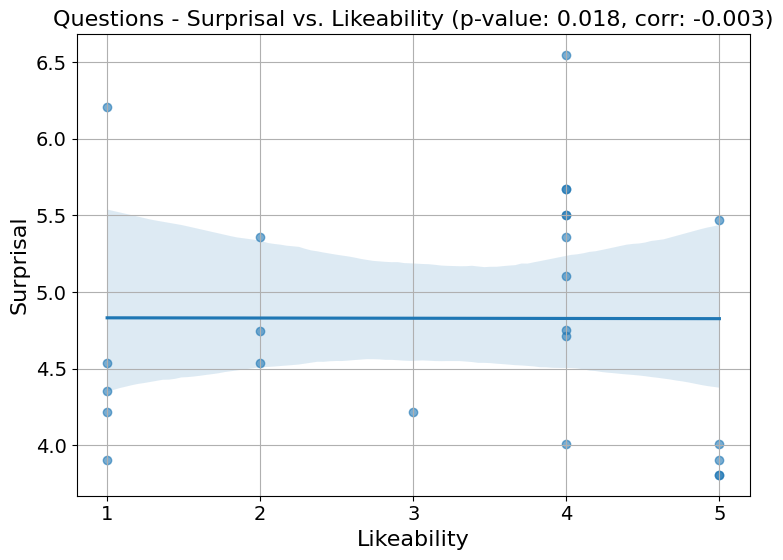

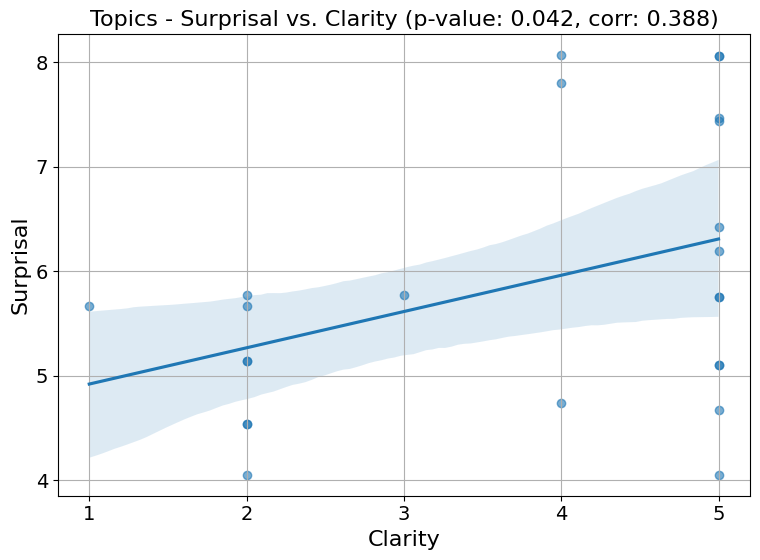

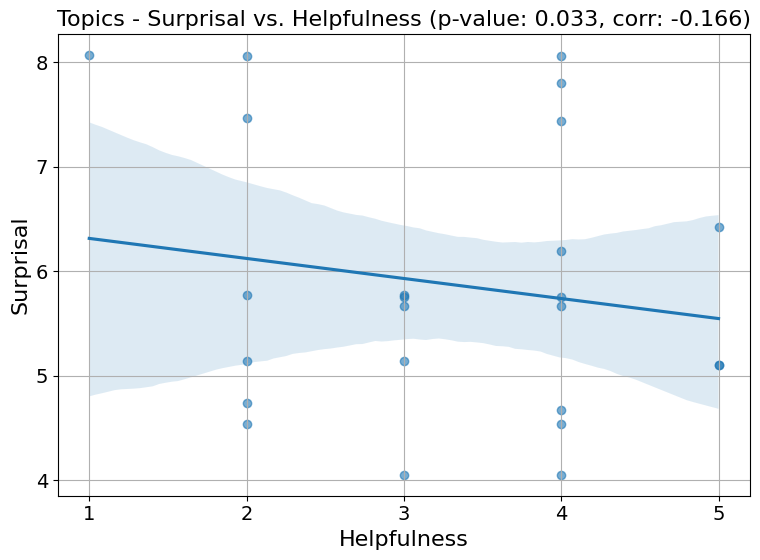

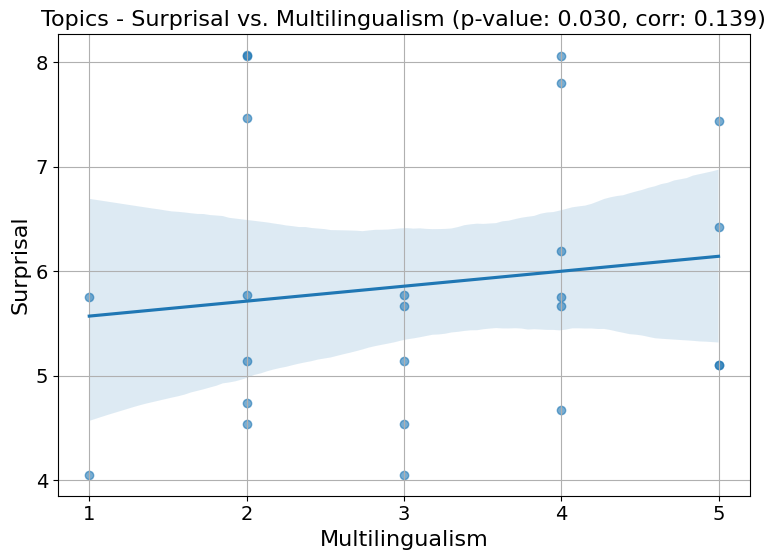

In [343]:
for intent, predictors in significant_predictors_per_intent.items():
    for var, p_val in predictors.items():
        # Plotting significant predictors against surprisal
        correlation = formatted_intent_dfs_with_surprisal[intent]["Surprisal"].corr(
            formatted_intent_dfs_with_surprisal[intent][var]
        )
        plt.figure(figsize=(8, 6))
        sns.regplot(
            x=var,
            y="Surprisal",
            data=formatted_intent_dfs_with_surprisal[intent],
            scatter_kws={"alpha": 0.6},
        )
        plt.title(
            f"{intent.capitalize()} - Surprisal vs. {var} (p-value: {p_val:.3f}, corr: {correlation:.3f})",
            fontsize=16,
        )
        plt.xlabel(var, fontsize=16)
        plt.ylabel("Surprisal", fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.grid(True)
        plt.tight_layout()
        plt.show()